In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

# Konfigurasi agar GPU digunakan secara efisien
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("GPU Terdeteksi: ", physical_devices[0])
else:
    print("Peringatan: GPU tidak terdeteksi. Training akan lambat.")

GPU Terdeteksi:  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move the kaggle.json file to the .kaggle directory
# IMPORTANT: Make sure you have uploaded kaggle.json to your Colab session's /content/ directory first.
# If you uploaded it somewhere else, adjust the source path accordingly.
!mv /content/kaggle.json ~/.kaggle/

# Set read-only permissions for the kaggle.json file for security
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API credentials set up successfully!")

Kaggle API credentials set up successfully!


In [4]:
# Install kaggle if not already installed
!pip install -q kaggle

# Make sure your Kaggle API credentials (kaggle.json) are set up in ~/.kaggle/
# If you haven't done this, please refer to the previous instructions.

# Download the dataset
!kaggle datasets download -d joosthazelzet/lego-brick-images

# Unzip the downloaded dataset to the specified directory
# The zip file will be downloaded to the current working directory (/content/)
!unzip -q /content/lego-brick-images.zip -d /content/dataset/

# Clean up the zip file after extraction
!rm /content/lego-brick-images.zip

print("Dataset downloaded and extracted to /content/dataset/")

Dataset URL: https://www.kaggle.com/datasets/joosthazelzet/lego-brick-images
License(s): GPL-2.0
 98% 0.98G/1.00G [00:16<00:00, 132MB/s]
100% 1.00G/1.00G [00:16<00:00, 65.1MB/s]
Dataset downloaded and extracted to /content/dataset/


In [5]:
# Parameter Konfigurasi
BATCH_SIZE = 64
IMG_HEIGHT = 64  # Menggunakan 64x64 agar detail LEGO cukup terlihat
IMG_WIDTH = 64
CHANNELS = 3     # RGB


# --- OPSI B: Membuat Dataset Loader ---
# Ganti 'path/to/images' dengan path folder dataset Anda
dataset_dir = '/content/dataset/LEGO brick images v1'

# Jika folder kosong/tidak ada, kita buat dummy data agar kode tetap jalan (untuk testing)
if not os.path.exists(dataset_dir) or not os.listdir(dataset_dir):
    print("Dataset tidak ditemukan. Membuat data dummy untuk demonstrasi struktur kode.")
    os.makedirs(dataset_dir, exist_ok=True)
    # Membuat 100 gambar random noise sebagai placeholder
    for i in range(100):
        img = np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8)
        tf.keras.utils.save_img(f"{dataset_dir}/dummy_{i}.png", img)

# Memuat dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    label_mode=None, # Kita tidak butuh label untuk GAN
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Normalisasi ke [-1, 1]
train_dataset = train_dataset.map(lambda x: (x - 127.5) / 127.5)

# Optimasi performa (Caching & Prefetching)
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

Found 6379 files.


In [6]:
latent_dim = 128

def build_generator():
    model = keras.Sequential(name="generator")

    # Input: Latent Vector
    # Mulai dengan dense layer yang cukup besar untuk di-reshape
    # Kita ingin mulai dari ukuran 8x8 dengan 512 filter
    model.add(layers.Dense(8 * 8 * 512, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    # Reshape menjadi tensor 3D
    model.add(layers.Reshape((8, 8, 512)))

    # Upsampling 1: 8x8 -> 16x16
    model.add(layers.Conv2DTranspose(256, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    # Upsampling 2: 16x16 -> 32x32
    model.add(layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    # Upsampling 3: 32x32 -> 64x64
    model.add(layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    # Output Layer: 64x64 -> 64x64x3 (RGB)
    # Aktivasi TANH penting agar output di range [-1, 1]
    model.add(layers.Conv2D(CHANNELS, (3, 3), padding='same', activation='tanh'))

    return model

def build_discriminator():
    model = keras.Sequential(name="discriminator")

    # Input: Gambar 64x64x3
    # Downsampling 1: 64 -> 32
    model.add(layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Downsampling 2: 32 -> 16
    model.add(layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Downsampling 3: 16 -> 8
    model.add(layers.Conv2D(256, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Flatten dan Output
    model.add(layers.Flatten())
    model.add(layers.Dense(1)) # Output berupa logit (skor real/fake)

    return model

# Inisialisasi Model
generator = build_generator()
discriminator = build_discriminator()

generator.summary()
# discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32768)          │     4,194,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32768)          │       131,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 256)    │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,081,411 (27.01 MB)

 Trainable params: 7,014,979 (26.76 MB)

 Non-trainable params: 66,432 (259.50 KB)

In [7]:
class DCGAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super(DCGAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(DCGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        # Metric trackers
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        # 1. Sample random points in the latent space
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        # 2. Decode them to fake images
        generated_images = self.generator(random_latent_vectors)

        # 3. Combine them with real images
        combined_images = tf.concat([generated_images, real_images], axis=0)

        # 4. Assemble labels discriminating real from fake images
        # Label 1 untuk fake, 0 untuk real (atau sebaliknya, teknik ini menggunakan label smoothing)
        # Di sini kita pakai standar: 1=Real, 0=Fake.
        # Namun, karena kita concat [Fake, Real], maka labelnya: [0...0, 1...1]
        labels = tf.concat(
            [tf.zeros((batch_size, 1)), tf.ones((batch_size, 1))], axis=0
        )

        # Tambahkan sedikit noise pada label (Label Smoothing) untuk stabilitas
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        # 5. Train the Discriminator
        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)

        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # 6. Sample random points in the latent space (lagi, untuk Generator)
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        # 7. Assemble labels that say "all real images" (We want to fool the discriminator)
        misleading_labels = tf.ones((batch_size, 1))

        # 8. Train the Generator
        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)

        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(
            zip(grads, self.generator.trainable_weights)
        )

        # Update metrics
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }

In [8]:
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal(shape=(self.num_img, self.latent_dim))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images *= 127.5
        generated_images += 127.5
        generated_images.numpy()

        fig = plt.figure(figsize=(10, 4))
        for i in range(self.num_img):
            plt.subplot(1, self.num_img, i+1)
            img = keras.utils.array_to_img(generated_images[i])
            plt.imshow(img)
            plt.axis('off')

        plt.suptitle(f"Epoch {epoch+1}")
        plt.show() # Tampilkan inline di Colab

        # Opsional: Simpan ke file
        # plt.savefig(f"generated_lego_epoch_{epoch}.png")
        # plt.close()

Mulai Training...
Epoch 1/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - d_loss: 0.5084 - g_loss: 0.7265

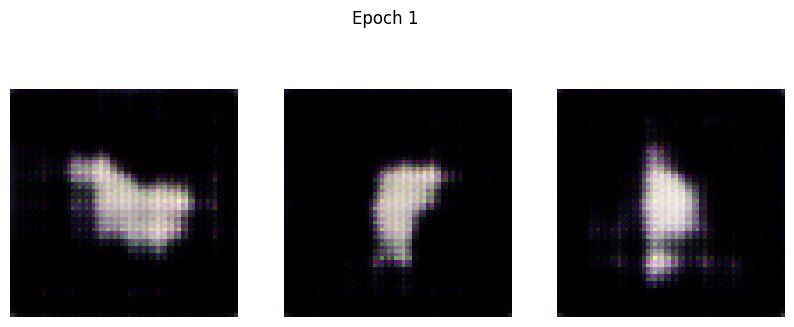

100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 204ms/step - d_loss: 0.5089 - g_loss: 0.7268
Epoch 2/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - d_loss: 0.6743 - g_loss: 0.7260

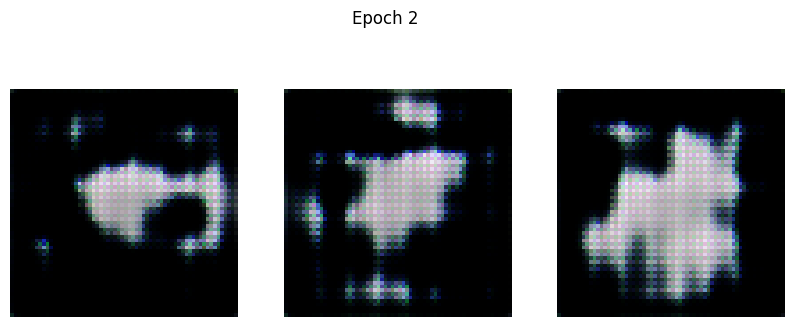

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - d_loss: 0.6744 - g_loss: 0.7259
Epoch 3/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - d_loss: 0.6671 - g_loss: 0.7078

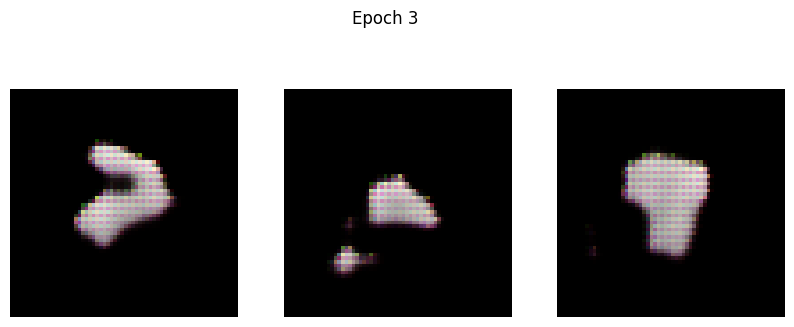

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - d_loss: 0.6670 - g_loss: 0.7080
Epoch 4/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - d_loss: 0.6539 - g_loss: 0.7848

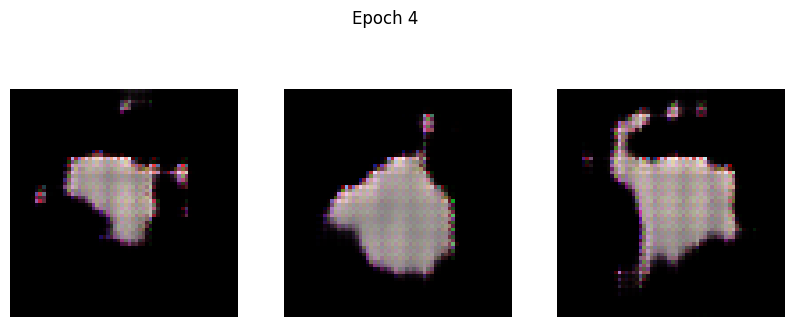

100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - d_loss: 0.6539 - g_loss: 0.7848
Epoch 5/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - d_loss: 0.6560 - g_loss: 0.7990

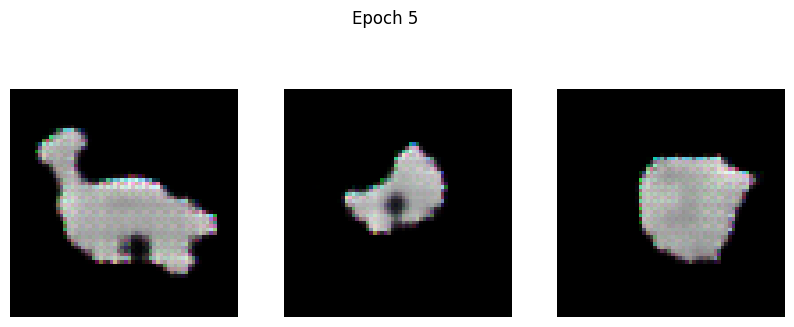

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - d_loss: 0.6560 - g_loss: 0.7991
Epoch 6/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - d_loss: 0.6745 - g_loss: 0.7970

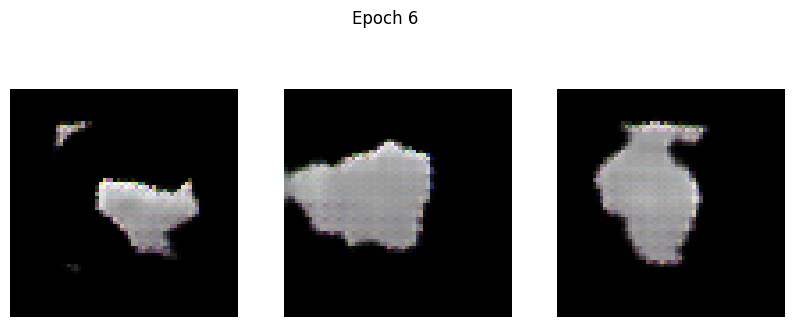

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - d_loss: 0.6744 - g_loss: 0.7969
Epoch 7/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - d_loss: 0.6605 - g_loss: 0.7729

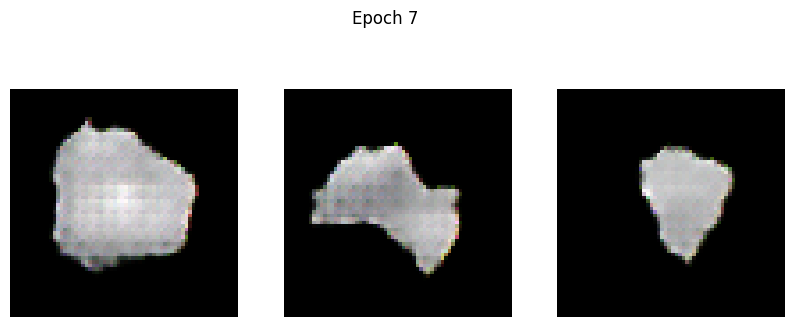

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - d_loss: 0.6604 - g_loss: 0.7729
Epoch 8/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - d_loss: 0.6591 - g_loss: 0.7731

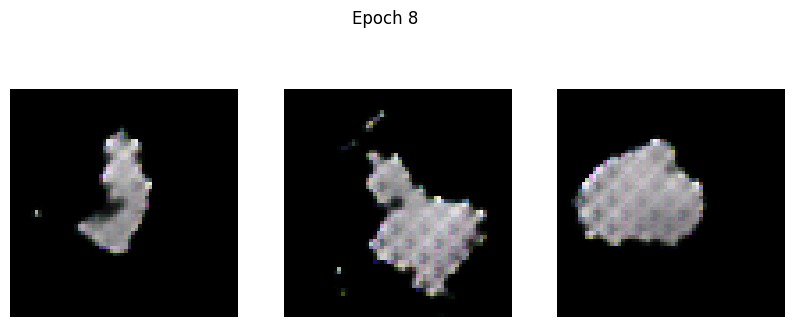

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - d_loss: 0.6591 - g_loss: 0.7730
Epoch 9/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - d_loss: 0.6542 - g_loss: 0.7708

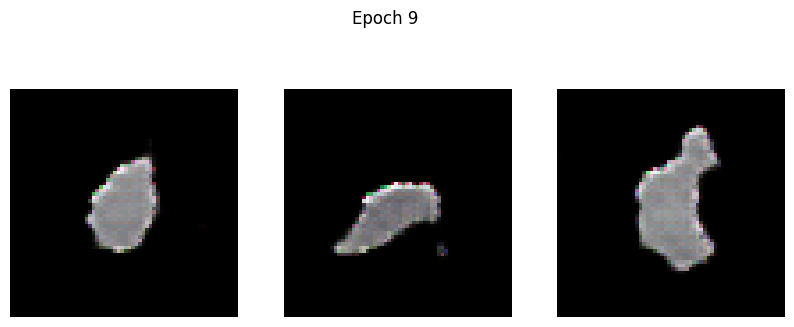

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - d_loss: 0.6542 - g_loss: 0.7707
Epoch 10/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - d_loss: 0.6583 - g_loss: 0.7659

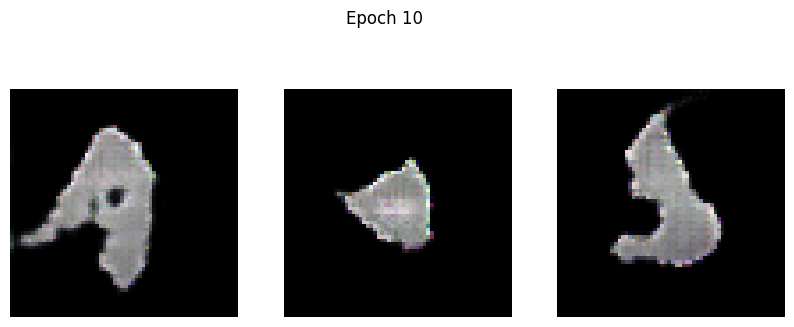

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - d_loss: 0.6583 - g_loss: 0.7658
Epoch 11/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - d_loss: 0.6561 - g_loss: 0.7735

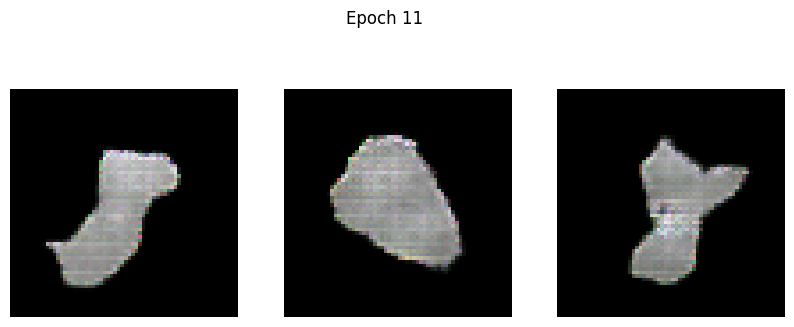

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - d_loss: 0.6561 - g_loss: 0.7735
Epoch 12/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - d_loss: 0.6525 - g_loss: 0.7739

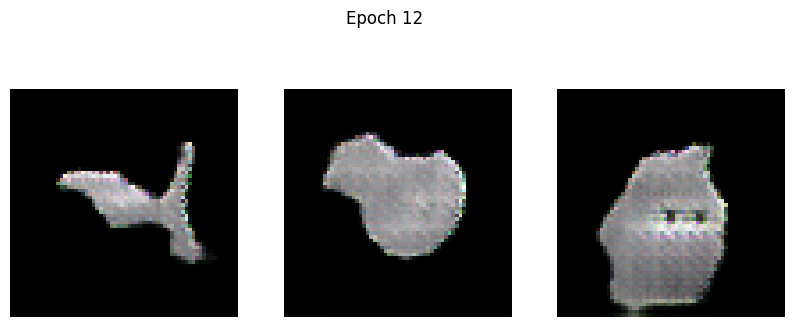

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - d_loss: 0.6525 - g_loss: 0.7741
Epoch 13/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - d_loss: 0.6377 - g_loss: 0.8028

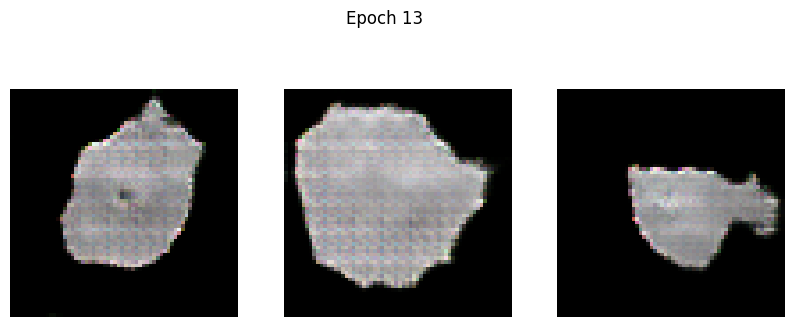

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - d_loss: 0.6377 - g_loss: 0.8032
Epoch 14/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - d_loss: 0.6266 - g_loss: 0.8576

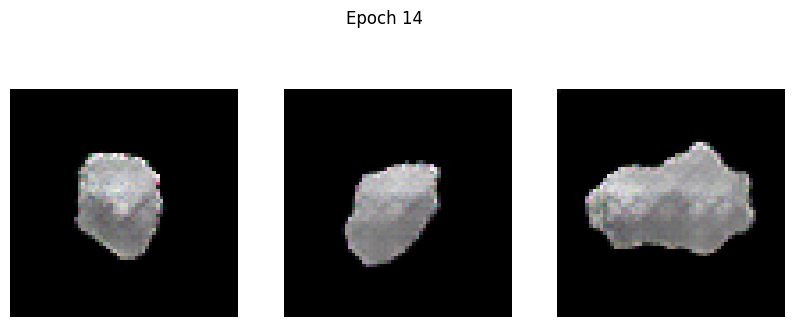

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - d_loss: 0.6266 - g_loss: 0.8575
Epoch 15/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - d_loss: 0.6040 - g_loss: 0.8469

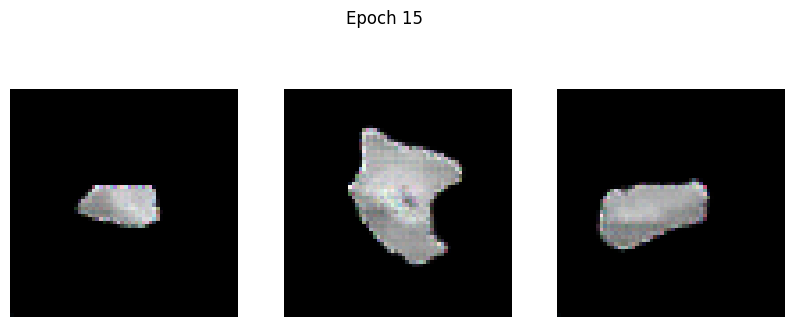

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - d_loss: 0.6041 - g_loss: 0.8472
Epoch 16/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - d_loss: 0.6073 - g_loss: 0.9244

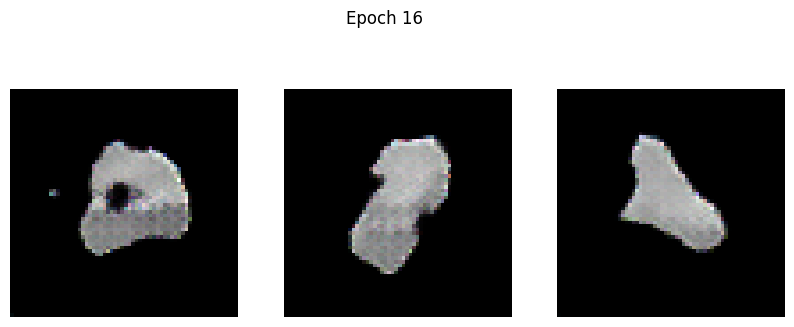

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - d_loss: 0.6073 - g_loss: 0.9246
Epoch 17/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.5892 - g_loss: 0.9489

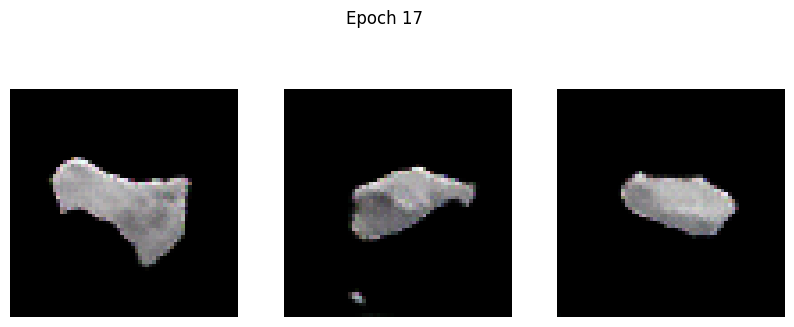

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.5892 - g_loss: 0.9489
Epoch 18/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.5753 - g_loss: 0.9054

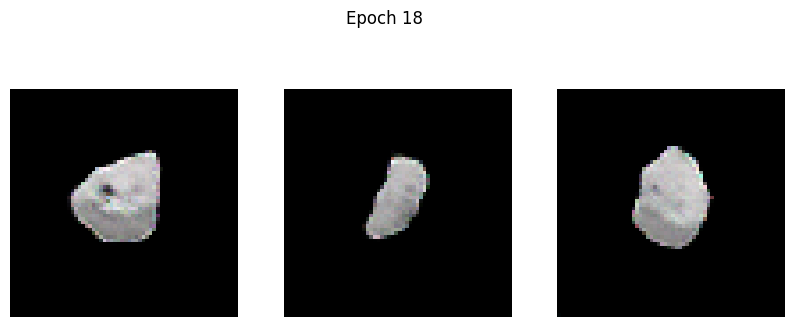

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.5753 - g_loss: 0.9054
Epoch 19/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.5722 - g_loss: 0.9104

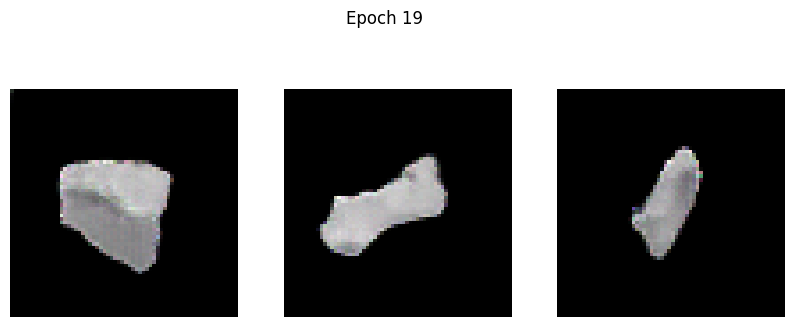

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.5722 - g_loss: 0.9106
Epoch 20/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.5525 - g_loss: 0.9753

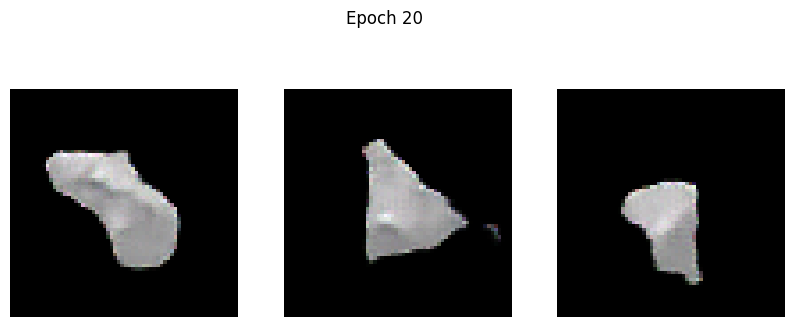

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.5526 - g_loss: 0.9752
Epoch 21/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.5470 - g_loss: 0.9794

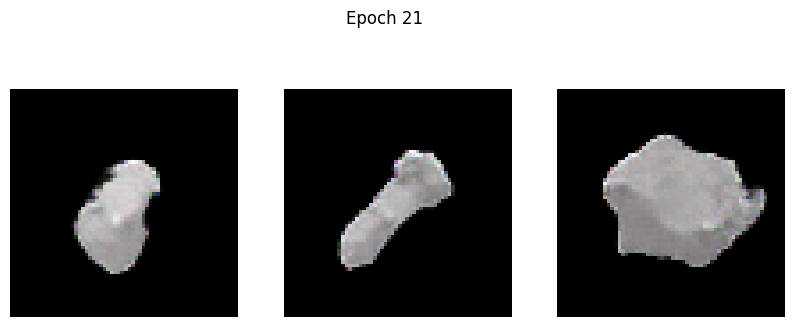

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.5470 - g_loss: 0.9795
Epoch 22/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.5523 - g_loss: 1.0145

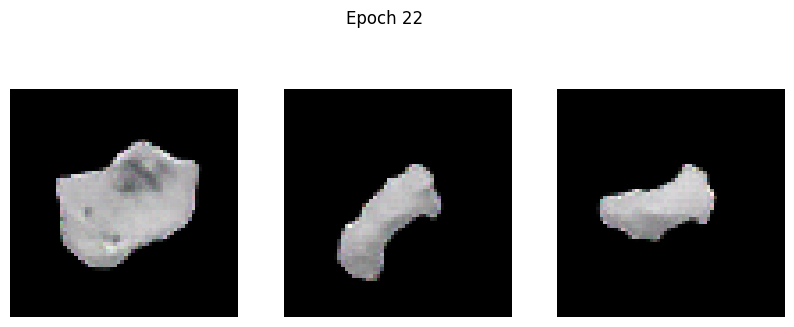

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.5523 - g_loss: 1.0145
Epoch 23/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.5316 - g_loss: 1.0302

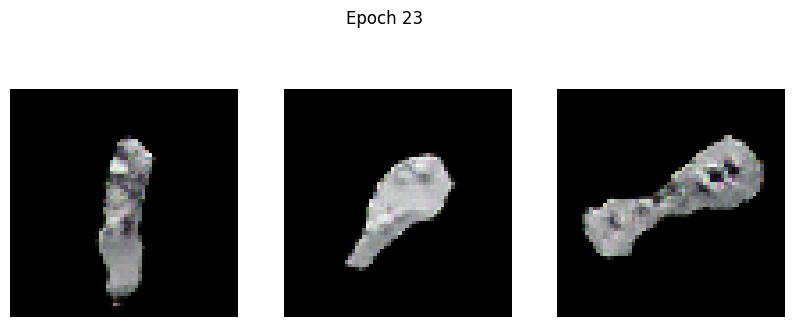

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.5317 - g_loss: 1.0305
Epoch 24/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.5229 - g_loss: 1.0671

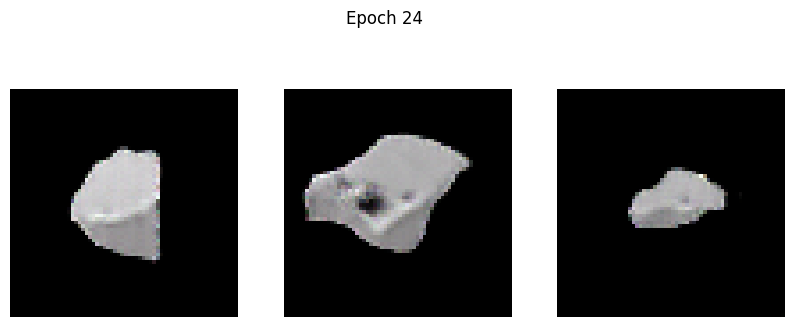

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.5228 - g_loss: 1.0673
Epoch 25/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.5117 - g_loss: 1.0906

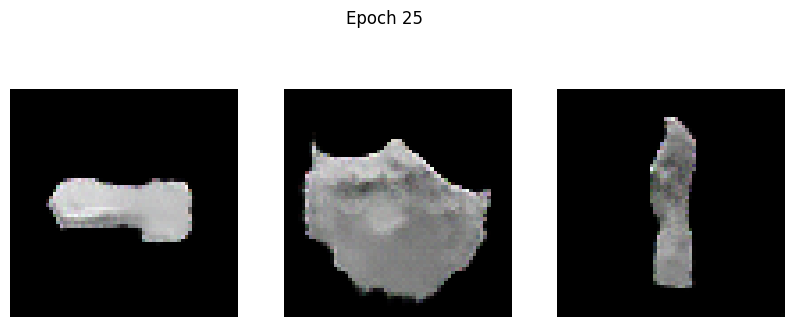

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.5116 - g_loss: 1.0908
Epoch 26/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.5092 - g_loss: 1.1444

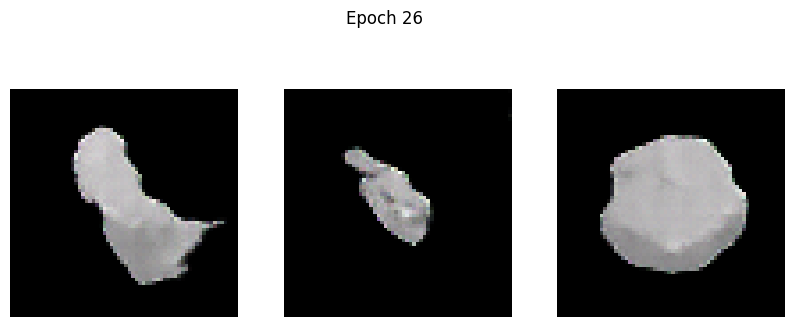

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.5091 - g_loss: 1.1446
Epoch 27/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.4893 - g_loss: 1.1660

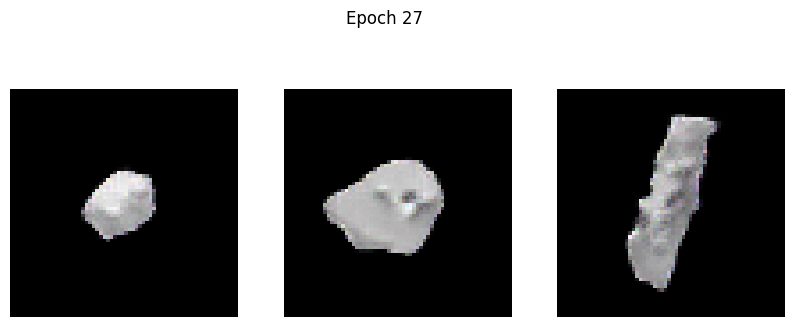

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.4892 - g_loss: 1.1662
Epoch 28/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.4790 - g_loss: 1.2362

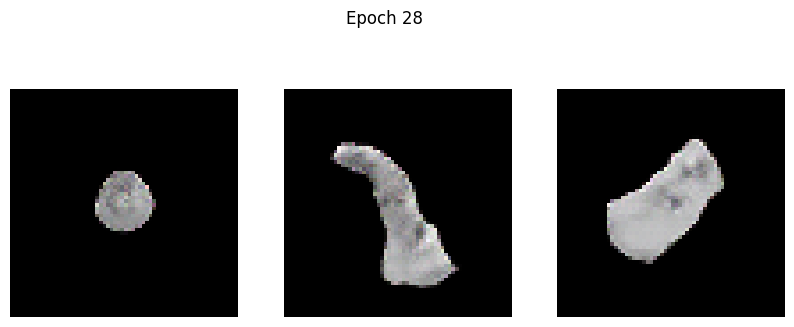

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4790 - g_loss: 1.2362
Epoch 29/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.4521 - g_loss: 1.2304

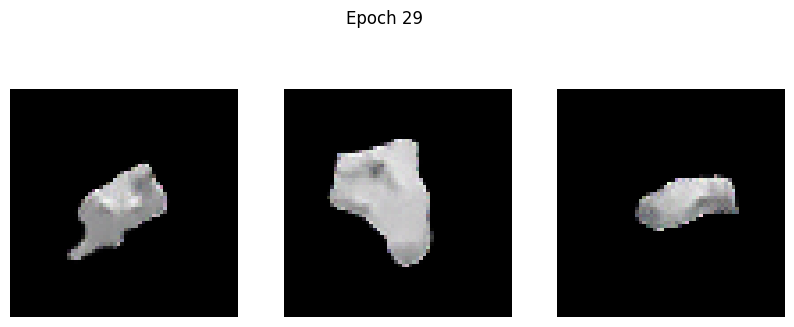

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4522 - g_loss: 1.2305
Epoch 30/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.4864 - g_loss: 1.3322

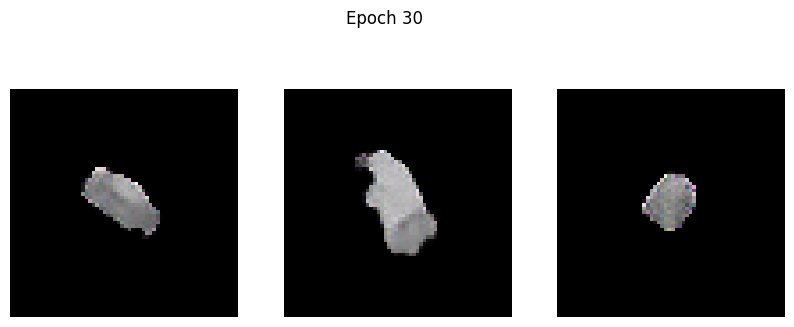

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4866 - g_loss: 1.3321
Epoch 31/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.4210 - g_loss: 1.2487

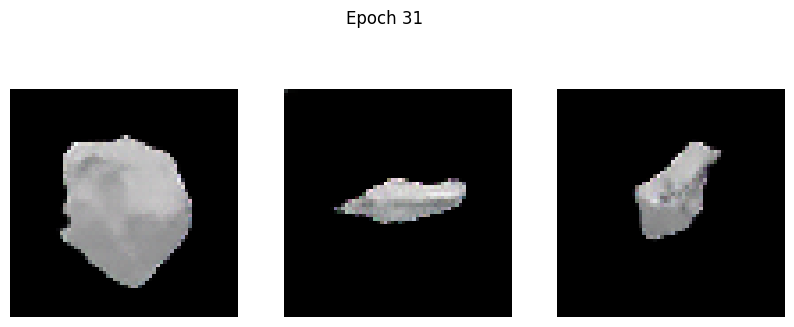

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4211 - g_loss: 1.2489
Epoch 32/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.4206 - g_loss: 1.3872

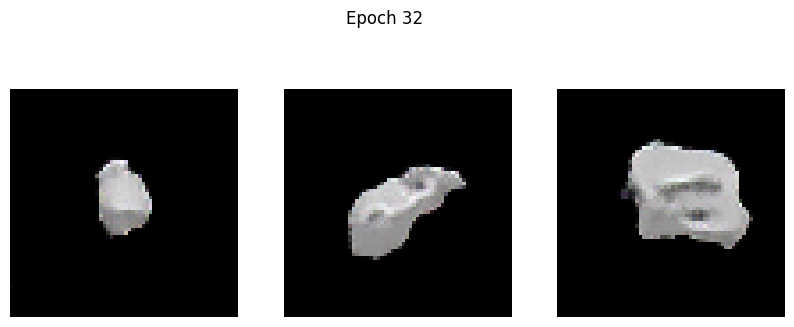

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4206 - g_loss: 1.3868
Epoch 33/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.4216 - g_loss: 1.4389

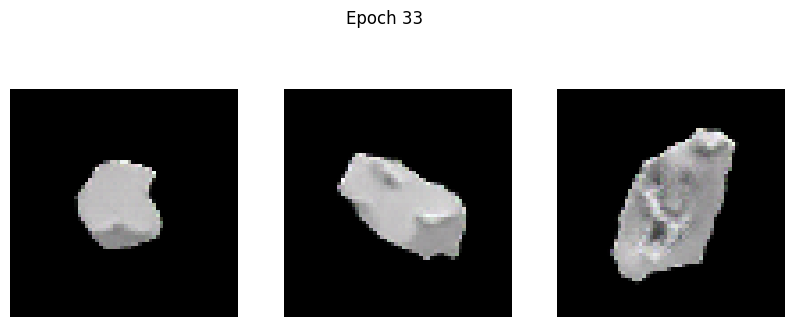

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4216 - g_loss: 1.4385
Epoch 34/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.4254 - g_loss: 1.4677

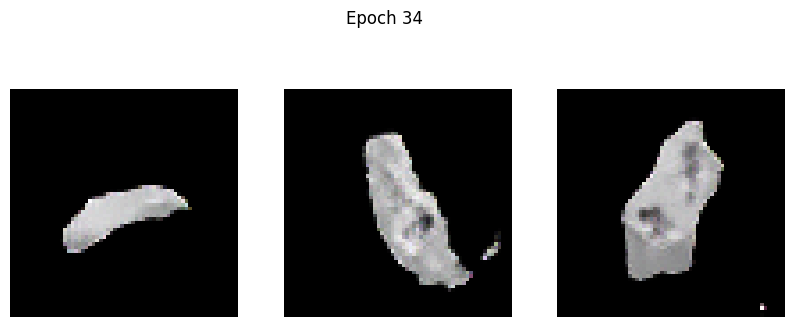

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4252 - g_loss: 1.4675
Epoch 35/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.4093 - g_loss: 1.4810

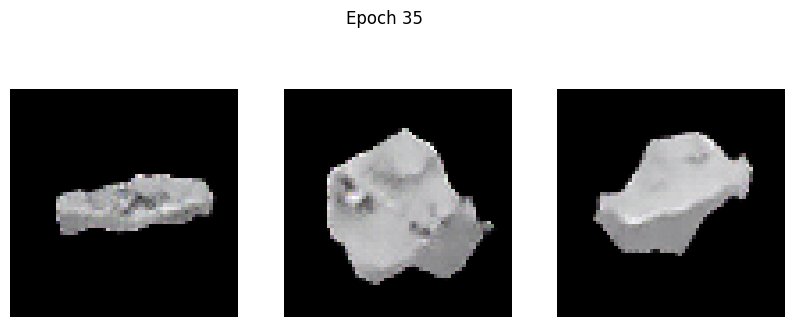

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4093 - g_loss: 1.4809
Epoch 36/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3687 - g_loss: 1.4988

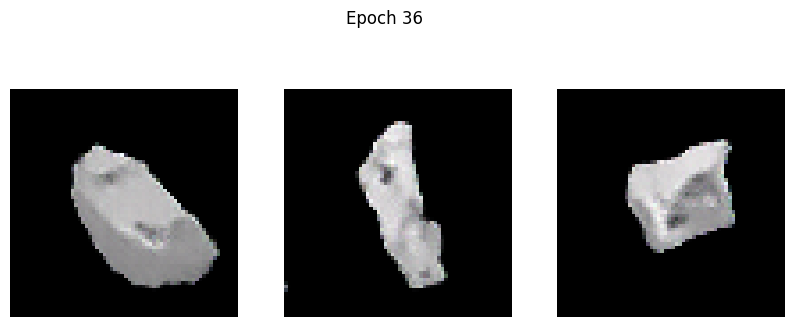

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3688 - g_loss: 1.4992
Epoch 37/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3887 - g_loss: 1.4985

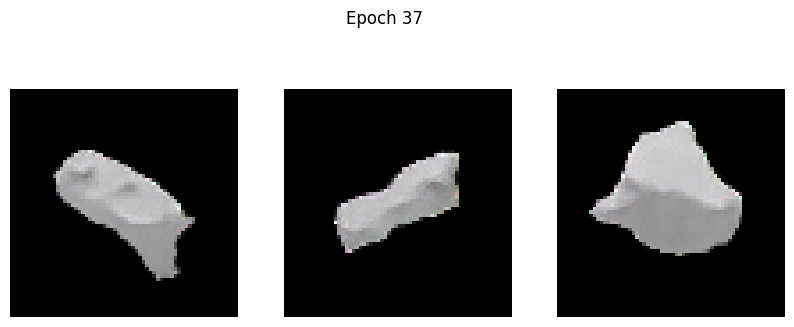

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.3887 - g_loss: 1.4990
Epoch 38/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.3770 - g_loss: 1.6376

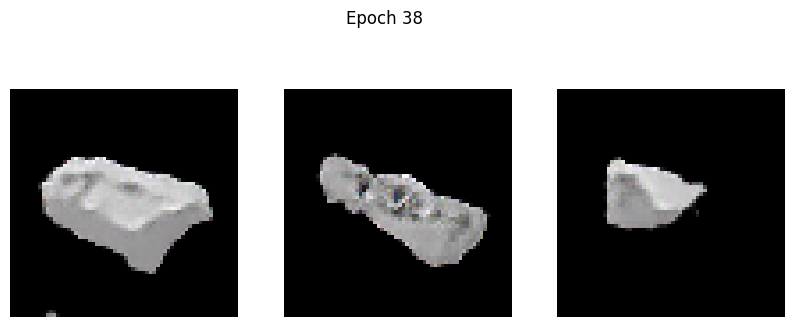

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.3773 - g_loss: 1.6382
Epoch 39/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.3605 - g_loss: 1.5188

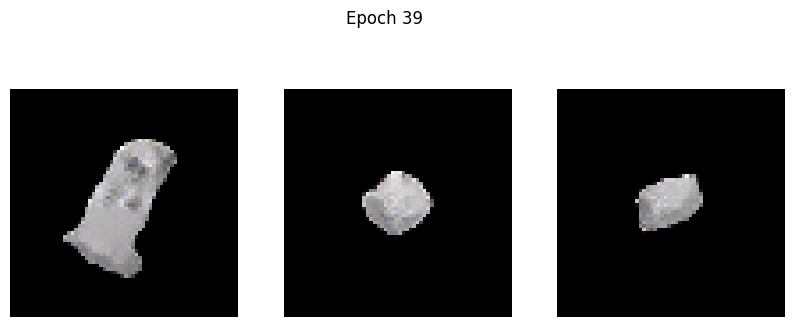

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.3605 - g_loss: 1.5192
Epoch 40/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.3628 - g_loss: 1.6871

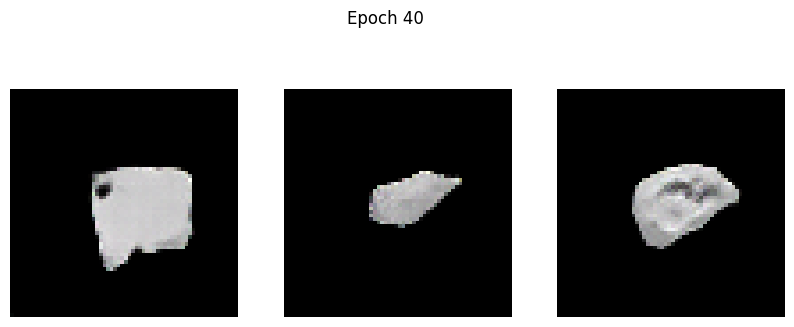

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.3628 - g_loss: 1.6868
Epoch 41/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.3875 - g_loss: 1.6899

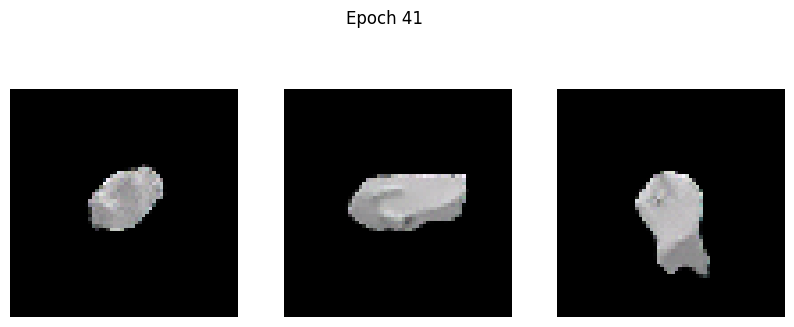

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.3872 - g_loss: 1.6900
Epoch 42/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.3356 - g_loss: 1.7536

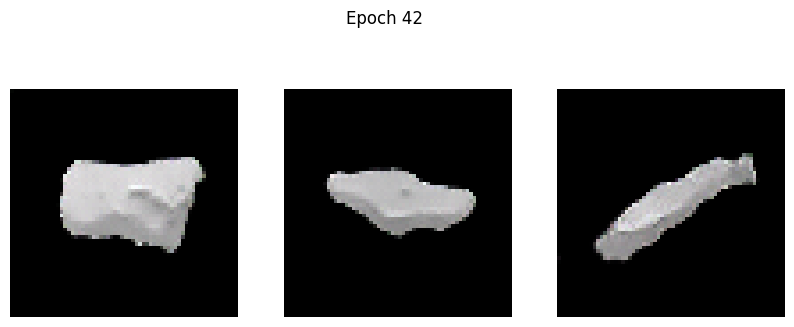

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.3355 - g_loss: 1.7536
Epoch 43/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.3441 - g_loss: 1.7515

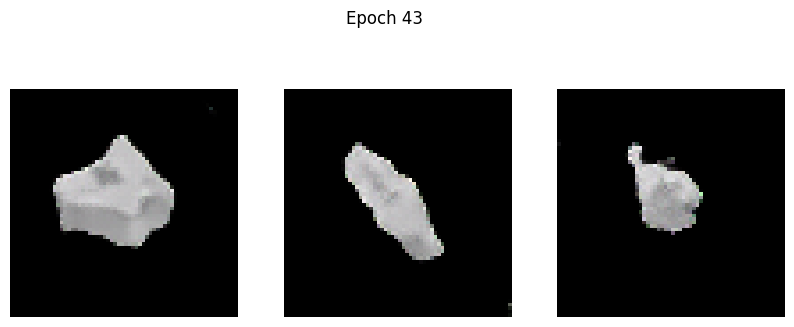

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.3442 - g_loss: 1.7519
Epoch 44/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3574 - g_loss: 1.8711

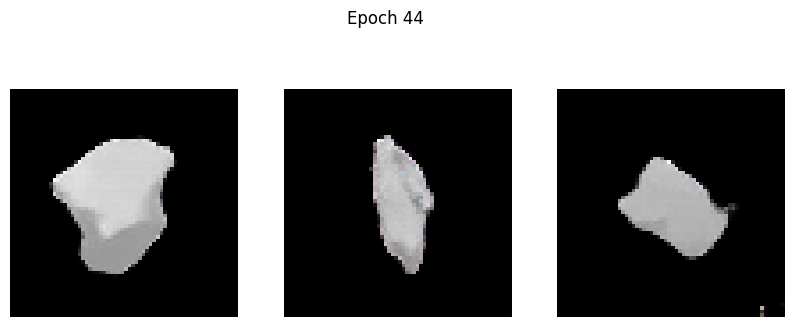

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.3571 - g_loss: 1.8706
Epoch 45/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.4079 - g_loss: 1.9251

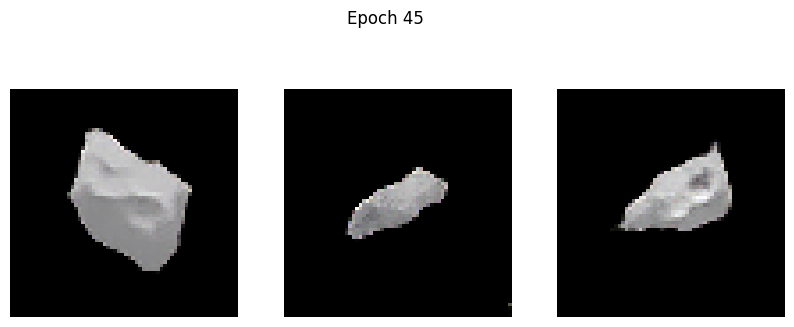

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4075 - g_loss: 1.9242
Epoch 46/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3128 - g_loss: 1.8101

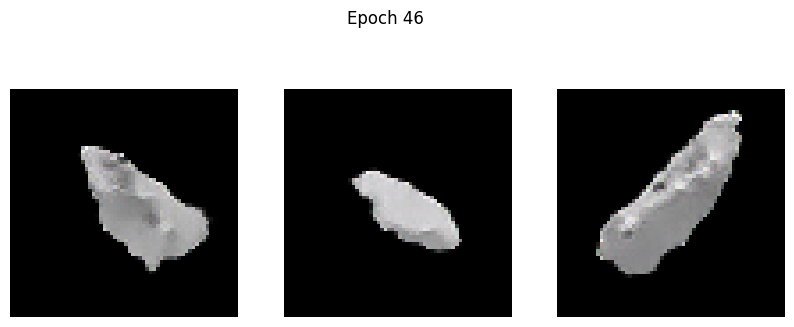

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.3127 - g_loss: 1.8103
Epoch 47/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3720 - g_loss: 1.9474

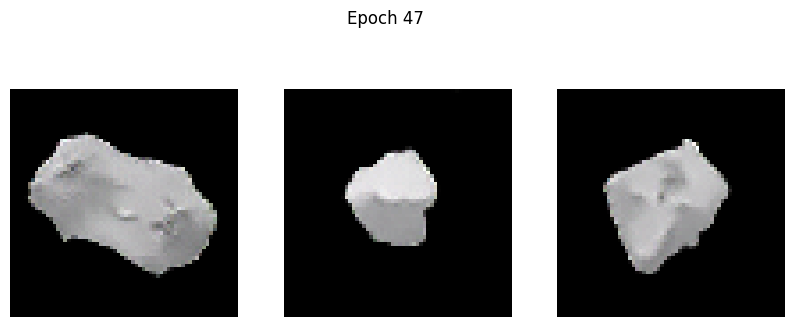

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3717 - g_loss: 1.9466
Epoch 48/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.5676 - g_loss: 2.3489

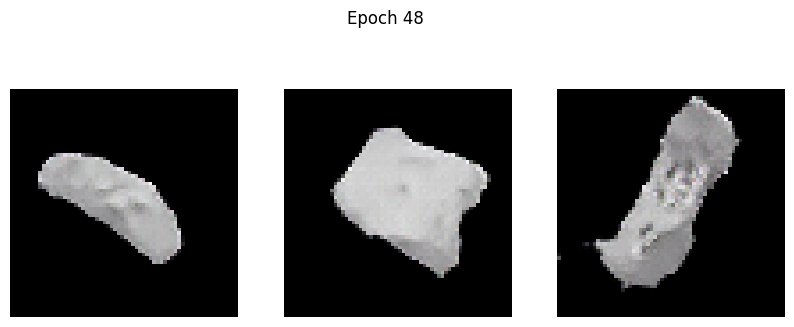

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.5686 - g_loss: 2.3483
Epoch 49/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3423 - g_loss: 1.4939

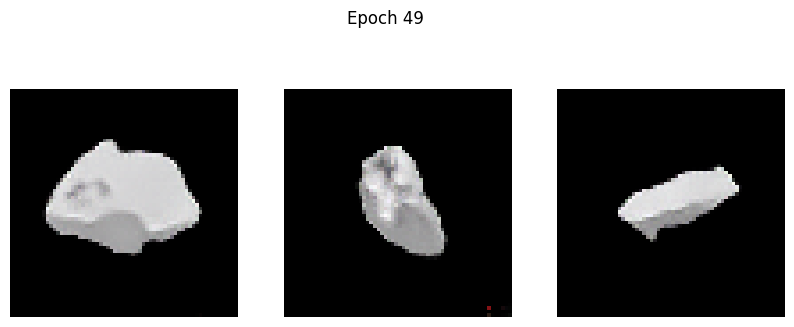

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3422 - g_loss: 1.4944
Epoch 50/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3051 - g_loss: 1.6483

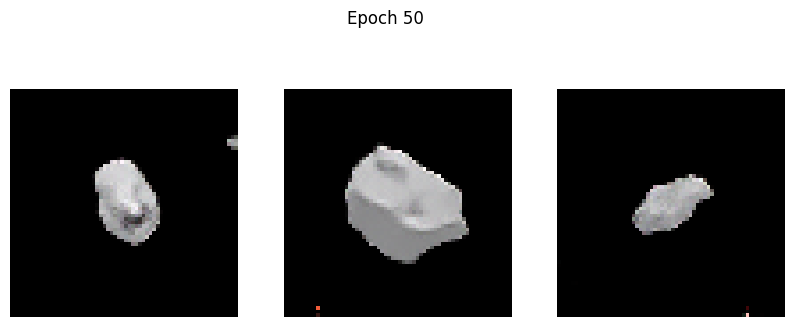

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3050 - g_loss: 1.6486
Epoch 51/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2853 - g_loss: 1.7736

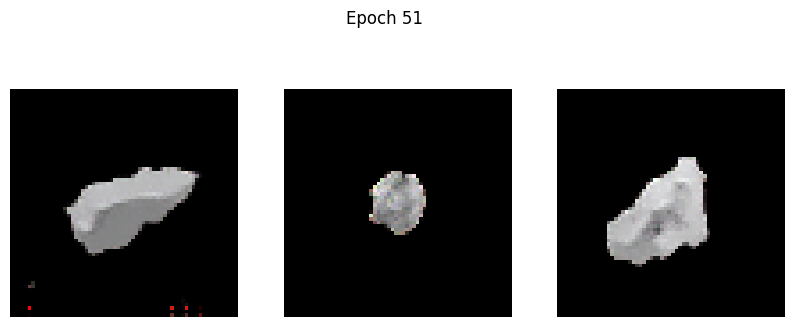

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2854 - g_loss: 1.7738
Epoch 52/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2957 - g_loss: 1.8938

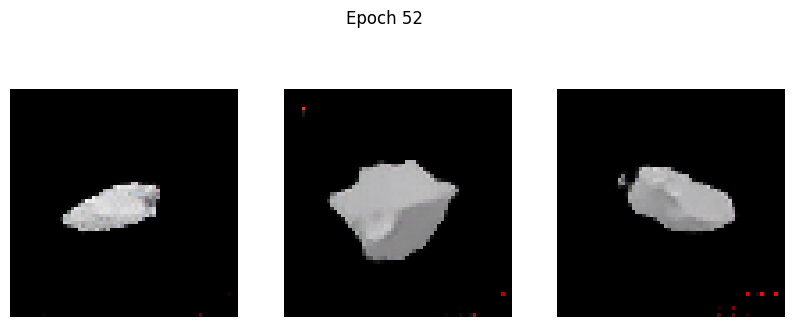

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2957 - g_loss: 1.8936
Epoch 53/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3424 - g_loss: 1.9751

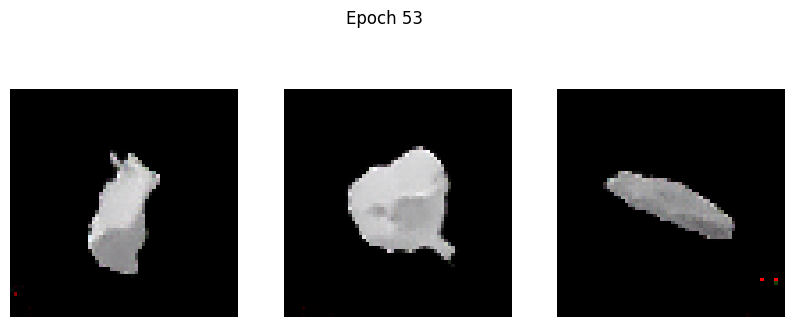

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - d_loss: 0.3425 - g_loss: 1.9747
Epoch 54/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2982 - g_loss: 1.8597

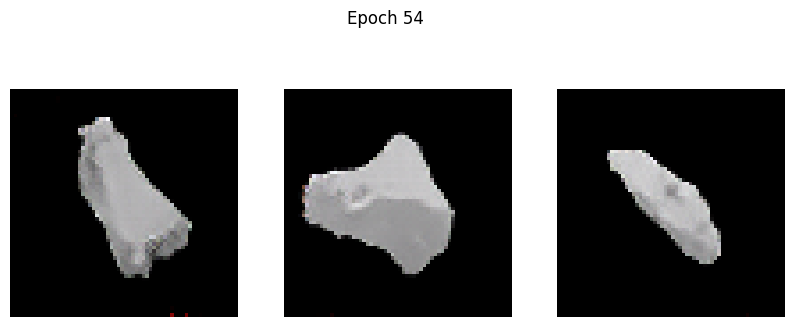

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2983 - g_loss: 1.8597
Epoch 55/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3188 - g_loss: 1.8945

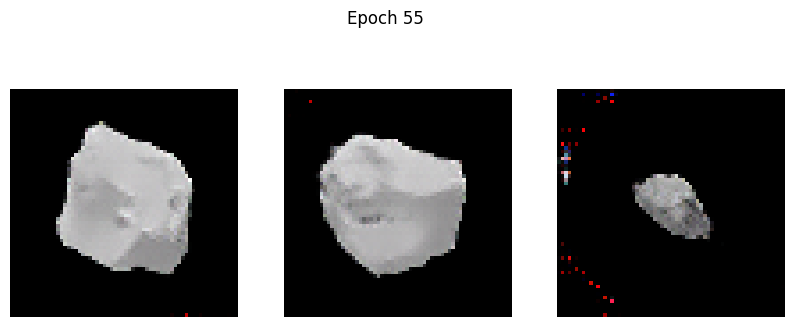

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3187 - g_loss: 1.8945
Epoch 56/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3333 - g_loss: 1.9318

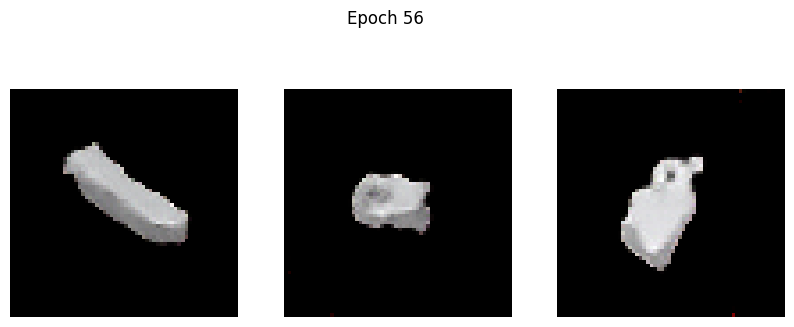

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3331 - g_loss: 1.9316
Epoch 57/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3012 - g_loss: 1.9361

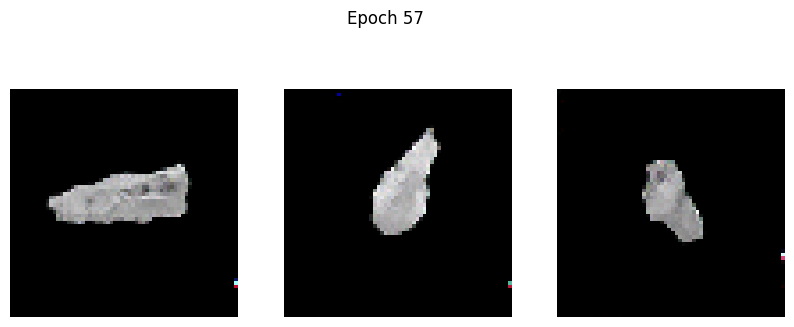

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3013 - g_loss: 1.9362
Epoch 58/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2920 - g_loss: 1.9571

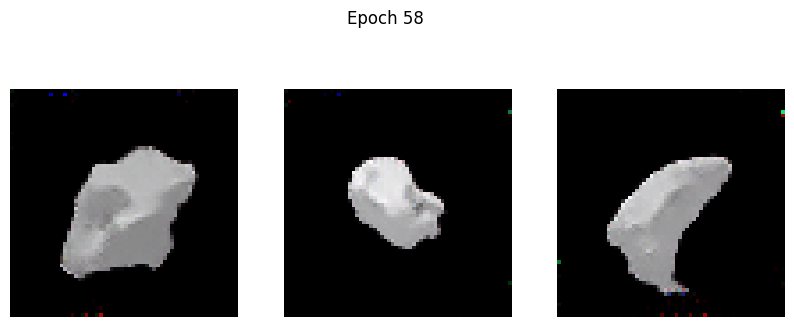

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2921 - g_loss: 1.9574
Epoch 59/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2999 - g_loss: 1.9847

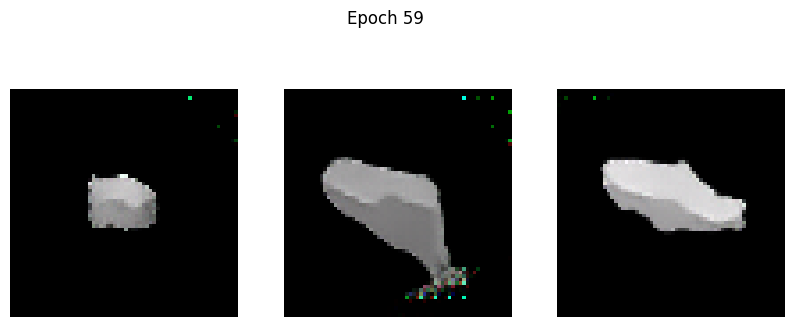

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3002 - g_loss: 1.9857
Epoch 60/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2861 - g_loss: 1.9453

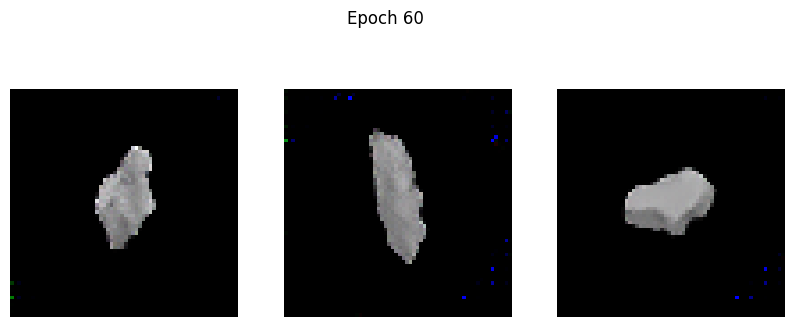

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2862 - g_loss: 1.9454
Epoch 61/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2873 - g_loss: 2.0601

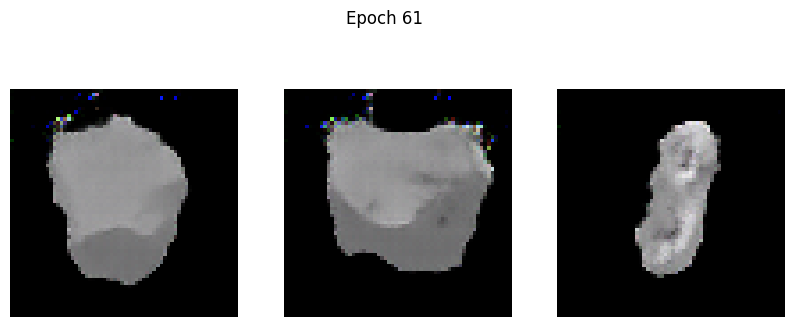

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2876 - g_loss: 2.0600
Epoch 62/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2863 - g_loss: 2.0285

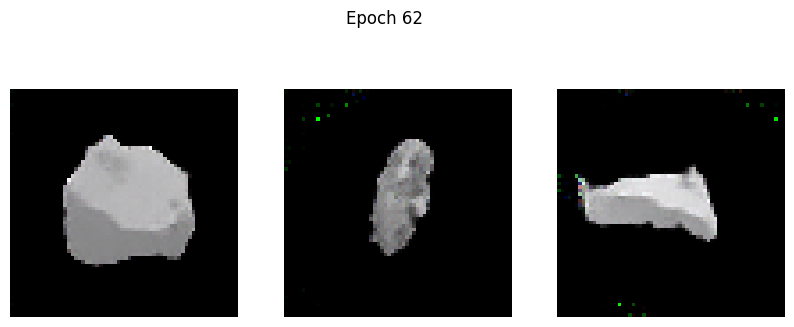

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2862 - g_loss: 2.0284
Epoch 63/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3083 - g_loss: 2.0725

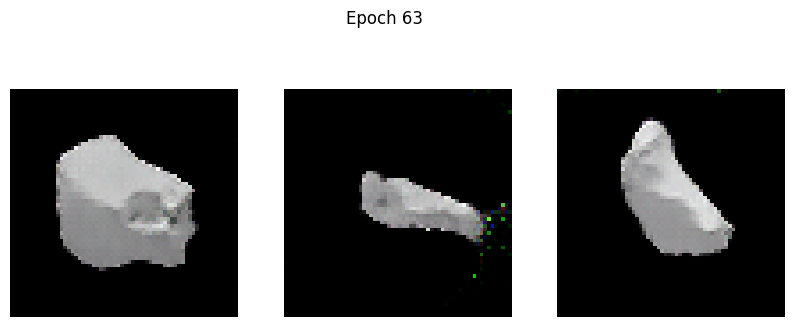

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3087 - g_loss: 2.0730
Epoch 64/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2650 - g_loss: 1.9192

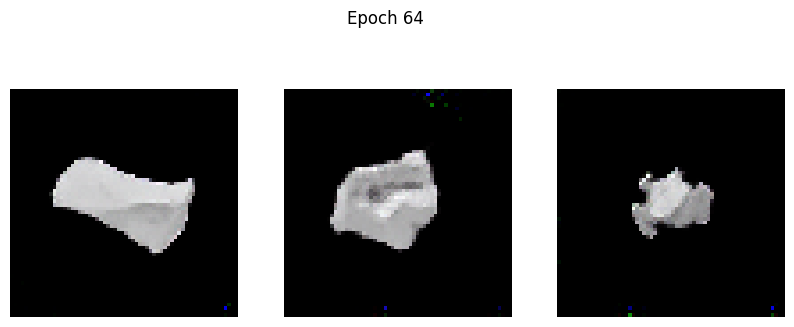

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2650 - g_loss: 1.9198
Epoch 65/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3812 - g_loss: 2.1645

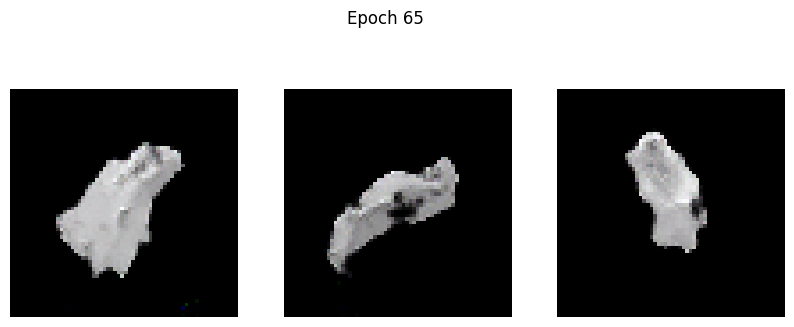

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3813 - g_loss: 2.1638
Epoch 66/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2368 - g_loss: 1.9822

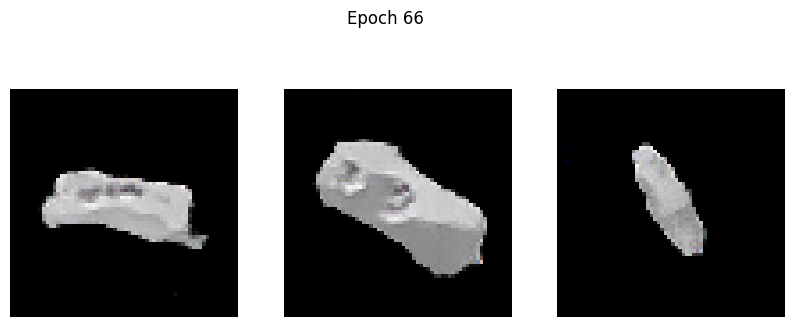

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2370 - g_loss: 1.9823
Epoch 67/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2632 - g_loss: 2.0782

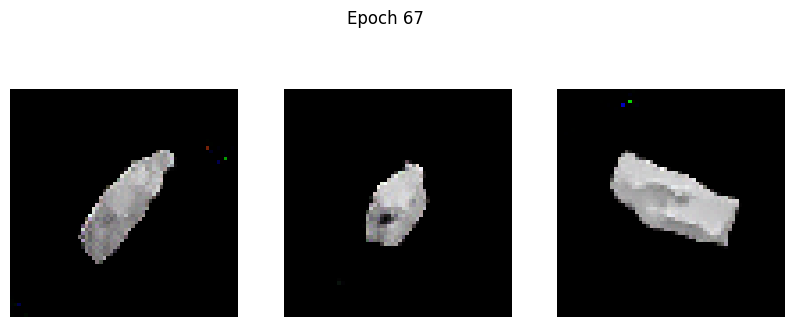

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2632 - g_loss: 2.0779
Epoch 68/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2576 - g_loss: 2.0966

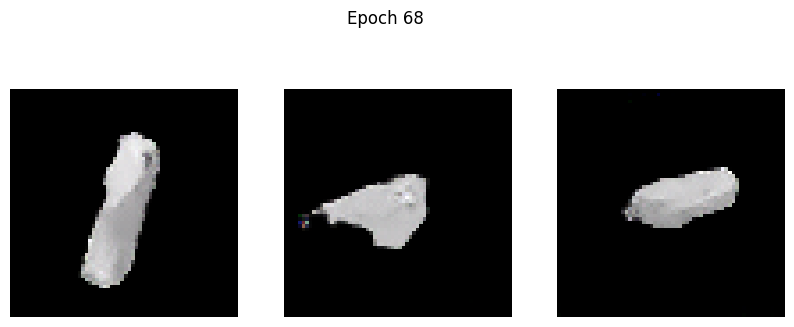

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2577 - g_loss: 2.0967
Epoch 69/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3718 - g_loss: 2.3107

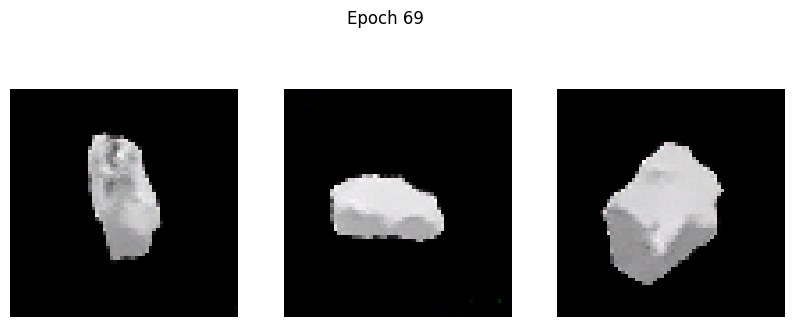

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3709 - g_loss: 2.3090
Epoch 70/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2638 - g_loss: 2.1419

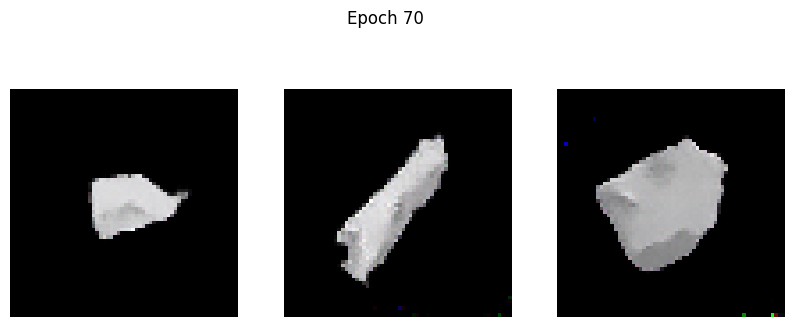

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2640 - g_loss: 2.1423
Epoch 71/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2570 - g_loss: 2.0581

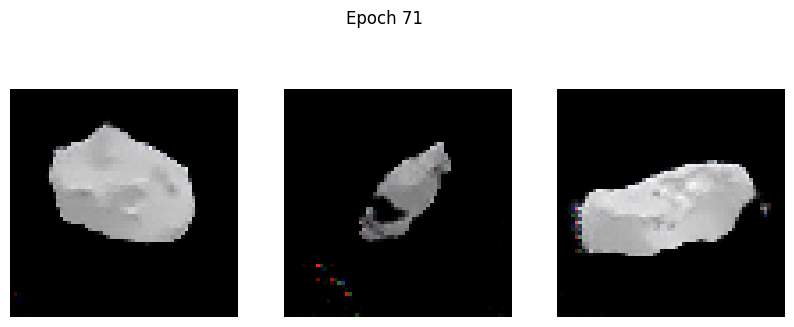

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2569 - g_loss: 2.0586
Epoch 72/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2485 - g_loss: 2.1911

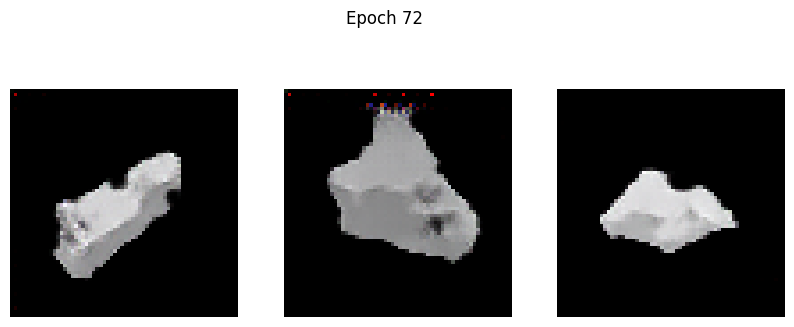

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2486 - g_loss: 2.1911
Epoch 73/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.4116 - g_loss: 2.4489

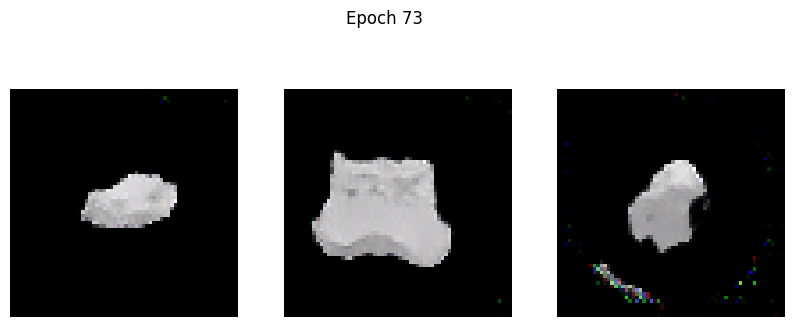

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4109 - g_loss: 2.4467
Epoch 74/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2319 - g_loss: 2.1361

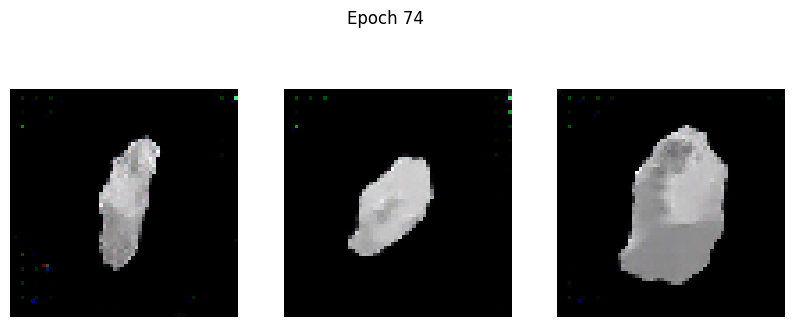

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2320 - g_loss: 2.1363
Epoch 75/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2520 - g_loss: 2.2119

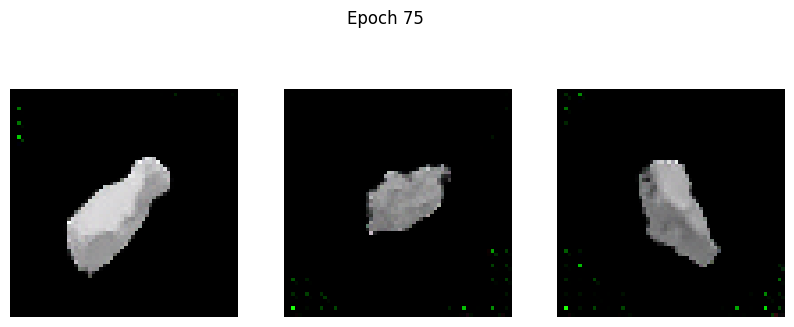

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2520 - g_loss: 2.2121
Epoch 76/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2681 - g_loss: 2.1986

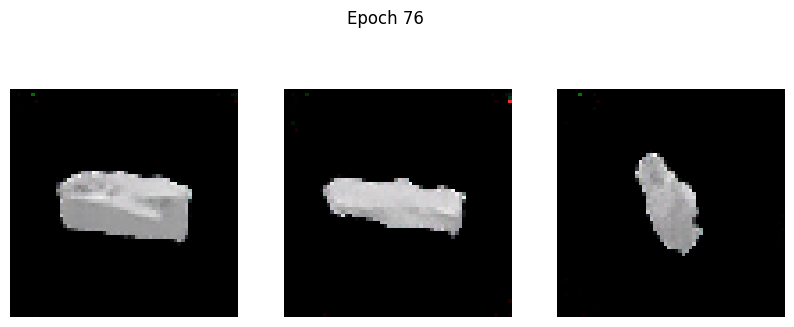

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2683 - g_loss: 2.1992
Epoch 77/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2384 - g_loss: 2.1486

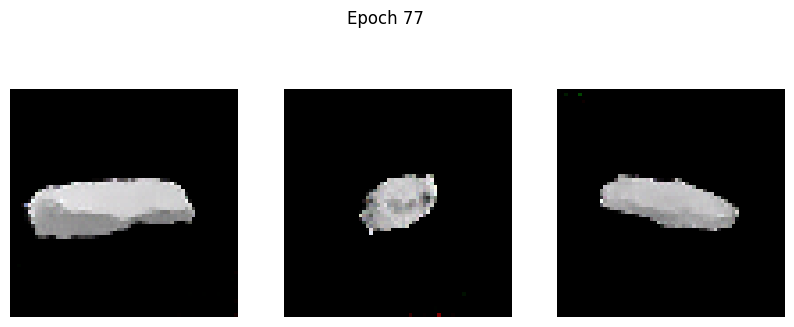

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2384 - g_loss: 2.1493
Epoch 78/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2404 - g_loss: 2.2874

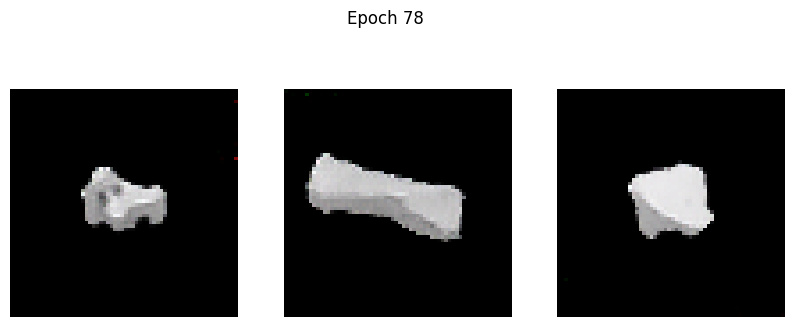

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2404 - g_loss: 2.2869
Epoch 79/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2319 - g_loss: 2.3609

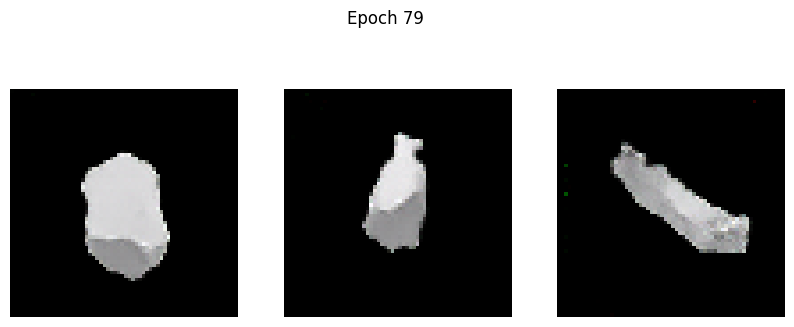

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2321 - g_loss: 2.3609
Epoch 80/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2898 - g_loss: 2.3994

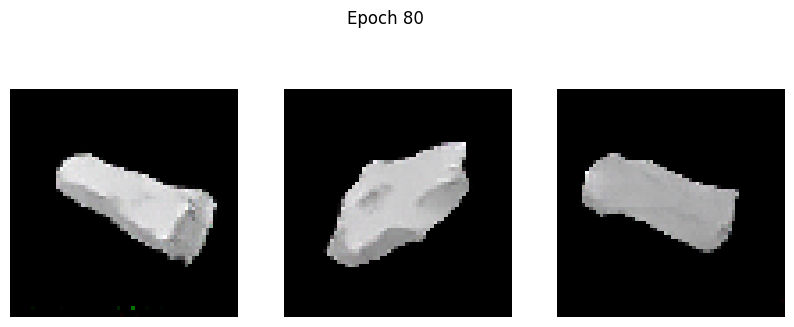

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2895 - g_loss: 2.3987
Epoch 81/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2238 - g_loss: 2.3022

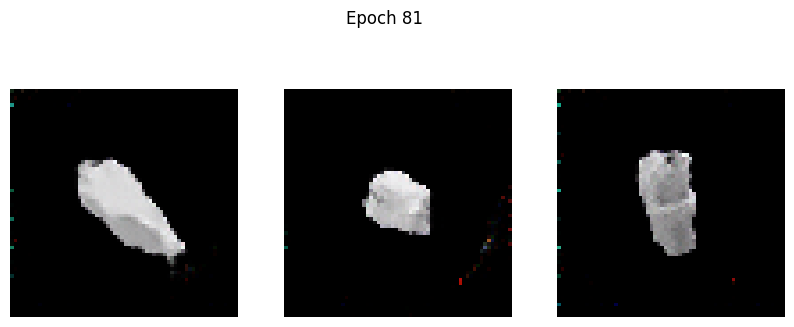

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2240 - g_loss: 2.3025
Epoch 82/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2912 - g_loss: 2.3613

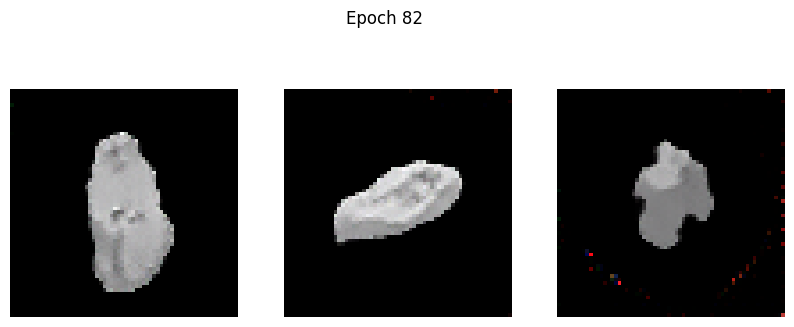

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2909 - g_loss: 2.3611
Epoch 83/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2075 - g_loss: 2.2932

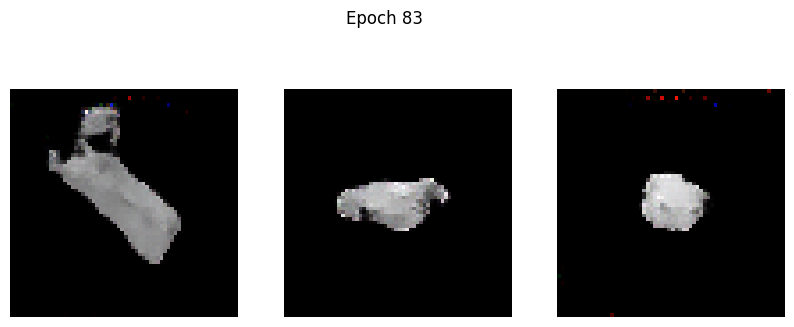

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2078 - g_loss: 2.2934
Epoch 84/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2283 - g_loss: 2.3209

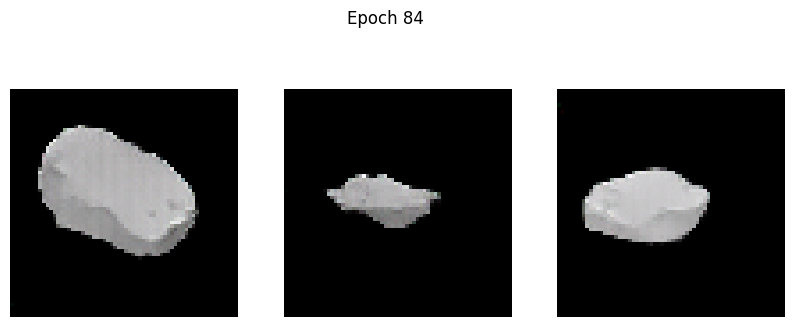

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2283 - g_loss: 2.3214
Epoch 85/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2238 - g_loss: 2.4084

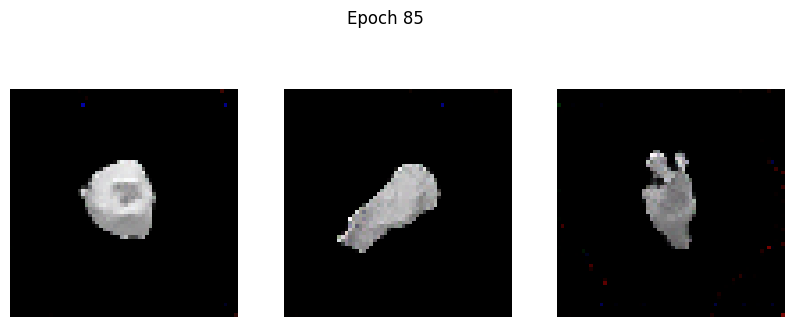

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2238 - g_loss: 2.4085
Epoch 86/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2706 - g_loss: 2.4807

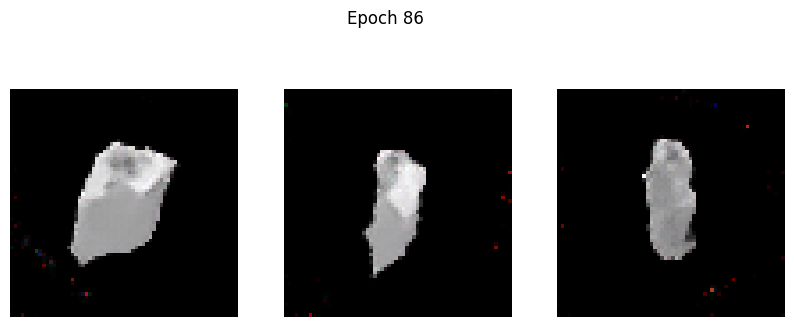

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2709 - g_loss: 2.4805
Epoch 87/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2007 - g_loss: 2.3606

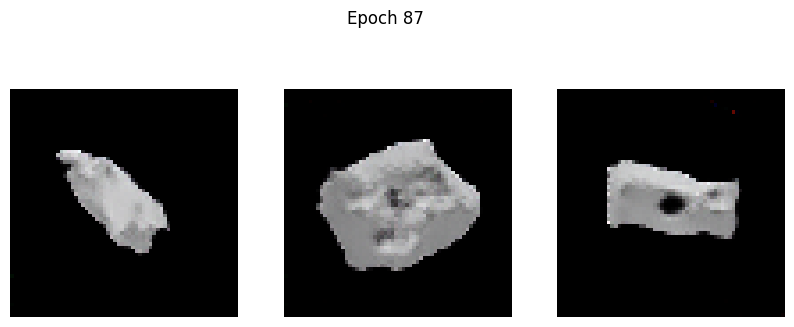

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2006 - g_loss: 2.3607
Epoch 88/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2369 - g_loss: 2.4460

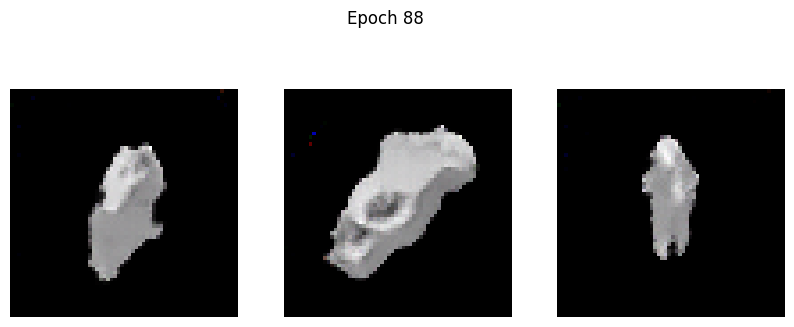

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2367 - g_loss: 2.4458
Epoch 89/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.5083 - g_loss: 3.0892

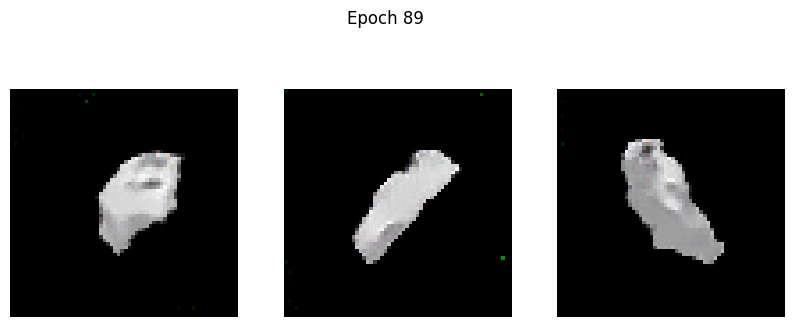

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.5081 - g_loss: 3.0874
Epoch 90/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2171 - g_loss: 2.1970

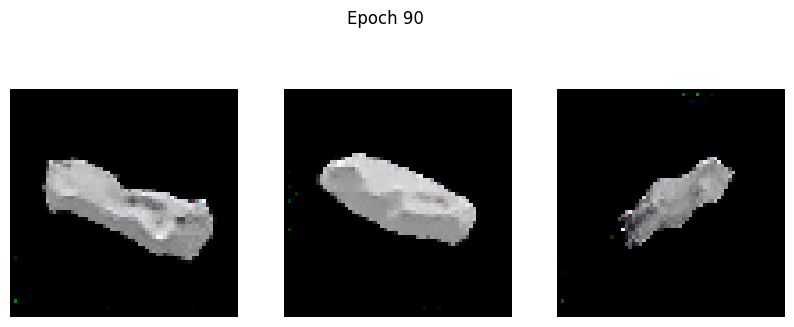

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2171 - g_loss: 2.1972
Epoch 91/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2203 - g_loss: 2.2601

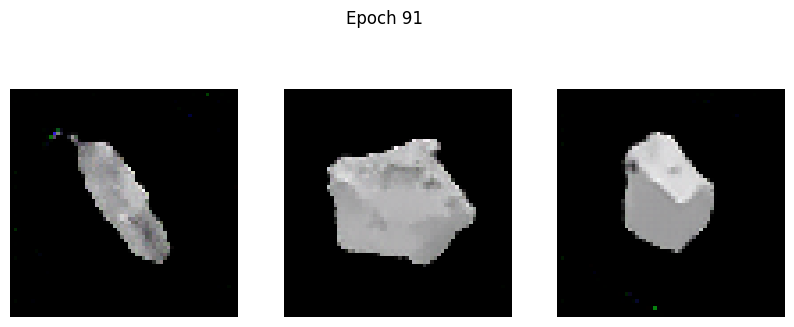

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2203 - g_loss: 2.2604
Epoch 92/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2108 - g_loss: 2.4042

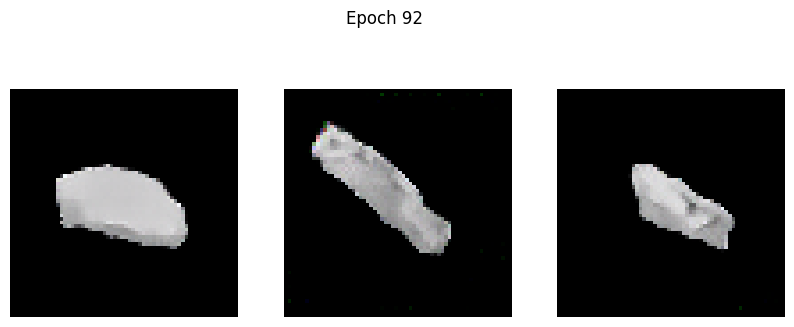

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2107 - g_loss: 2.4038
Epoch 93/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1896 - g_loss: 2.3487

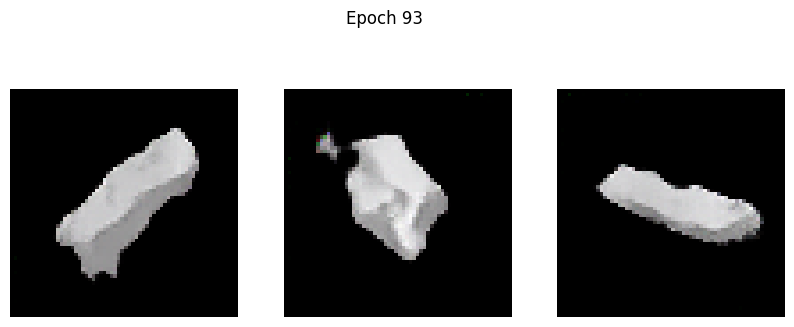

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1898 - g_loss: 2.3492
Epoch 94/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1834 - g_loss: 2.4003

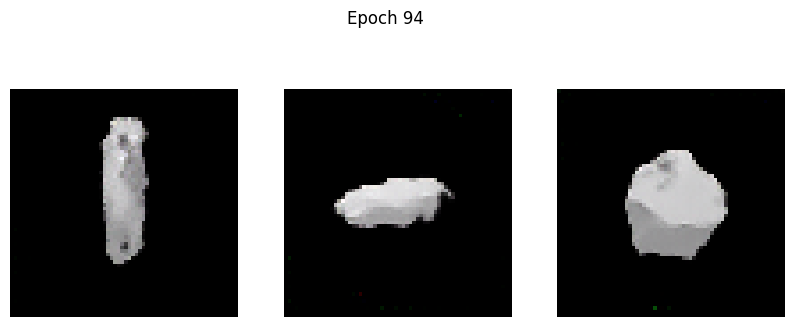

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1834 - g_loss: 2.4003
Epoch 95/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.4327 - g_loss: 2.6124

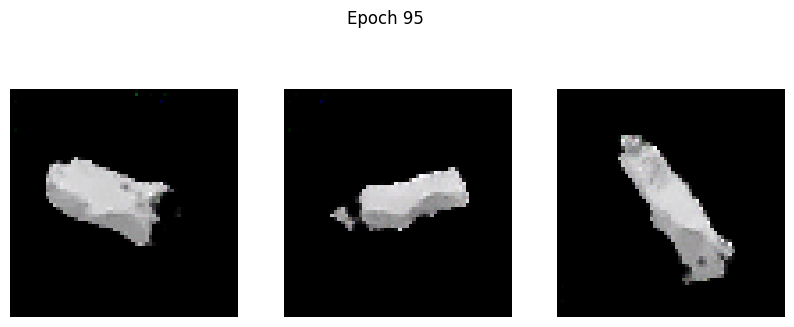

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4316 - g_loss: 2.6106
Epoch 96/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2052 - g_loss: 2.4258

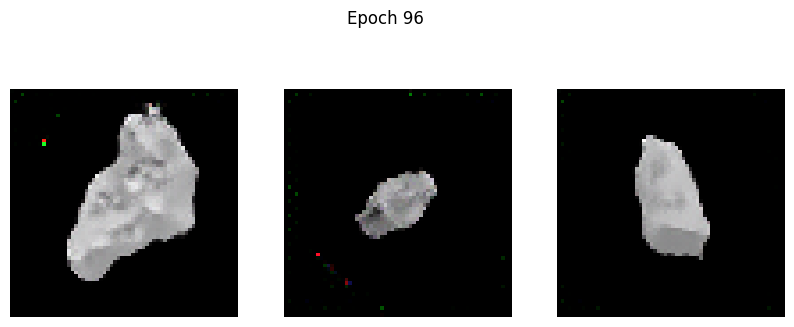

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2052 - g_loss: 2.4257
Epoch 97/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2120 - g_loss: 2.4980

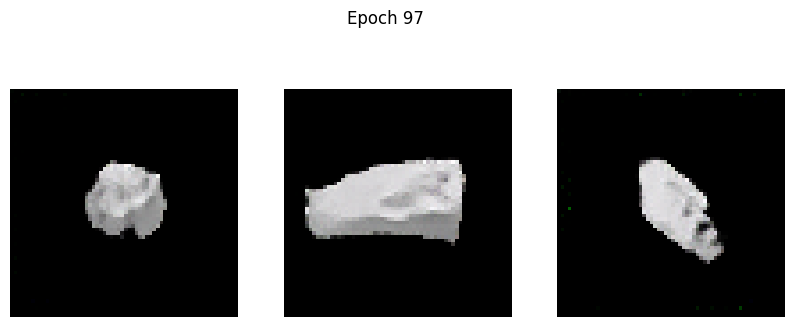

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2127 - g_loss: 2.4993
Epoch 98/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1917 - g_loss: 2.3852

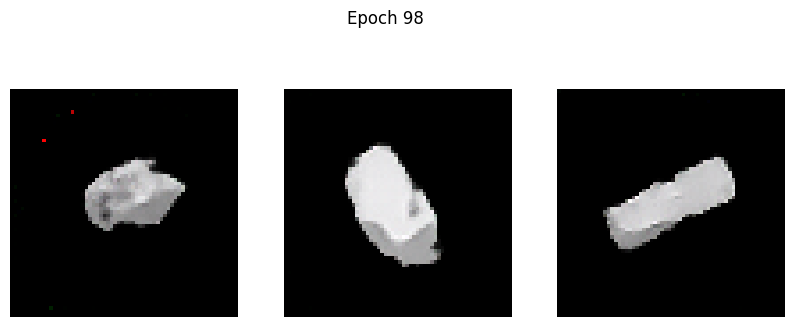

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1918 - g_loss: 2.3852
Epoch 99/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2131 - g_loss: 2.4906

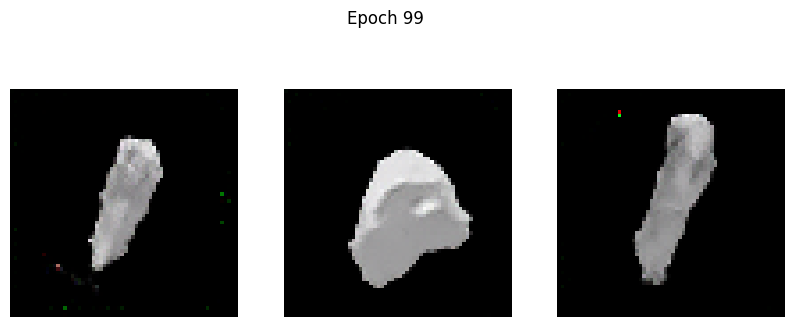

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2129 - g_loss: 2.4905
Epoch 100/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2114 - g_loss: 2.5727

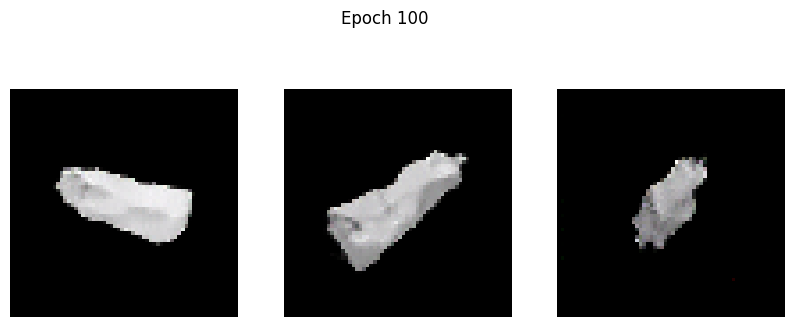

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2115 - g_loss: 2.5727
Epoch 101/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2227 - g_loss: 2.5446

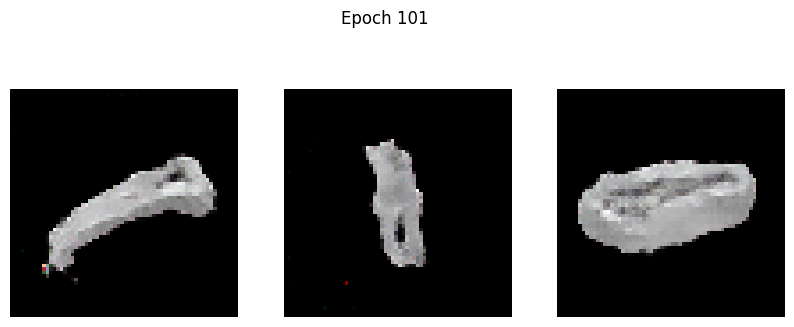

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2227 - g_loss: 2.5450
Epoch 102/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2650 - g_loss: 2.7336

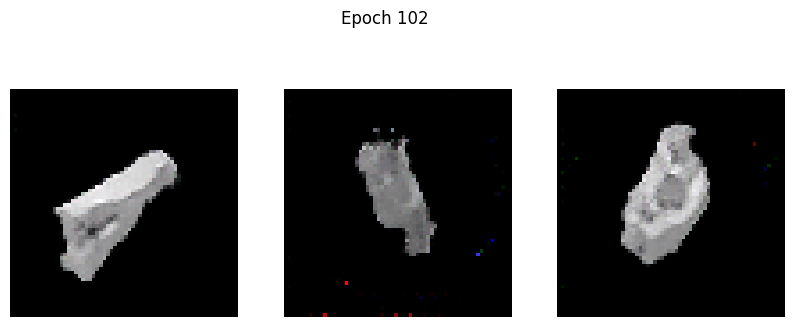

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2652 - g_loss: 2.7328
Epoch 103/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1686 - g_loss: 2.4831

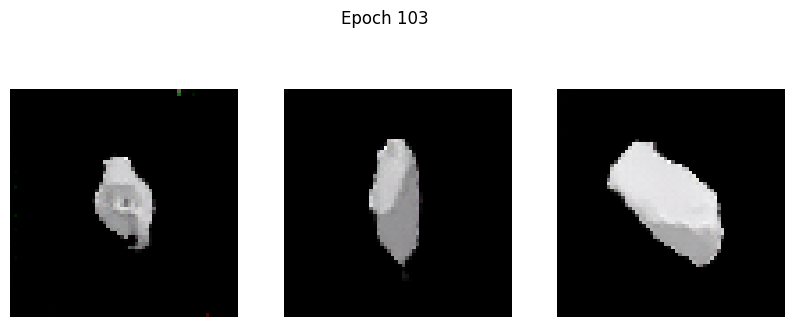

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1686 - g_loss: 2.4830
Epoch 104/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2235 - g_loss: 2.6485

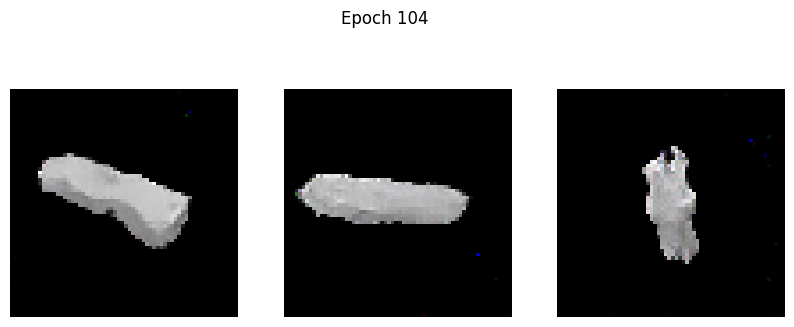

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2237 - g_loss: 2.6478
Epoch 105/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1874 - g_loss: 2.5382

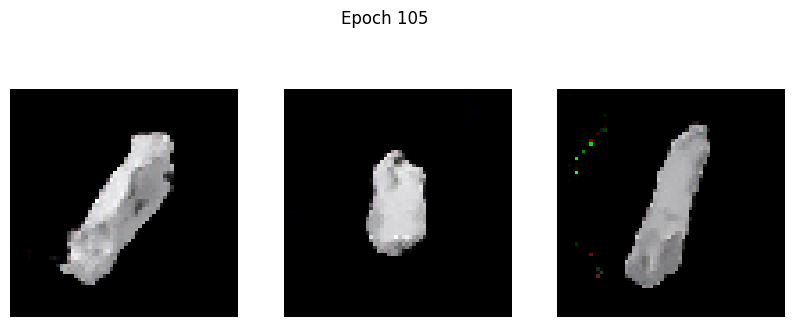

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1872 - g_loss: 2.5382
Epoch 106/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1768 - g_loss: 2.6109

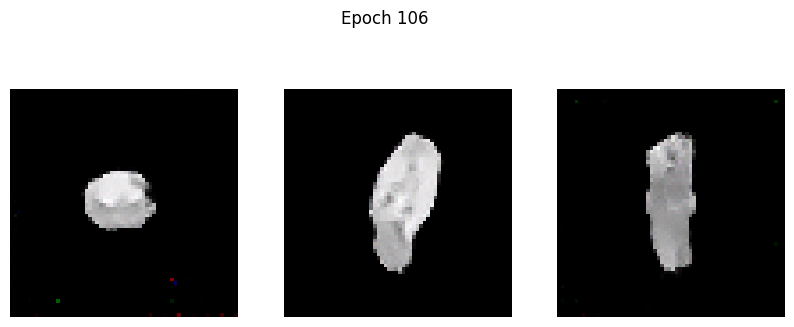

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1771 - g_loss: 2.6113
Epoch 107/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2026 - g_loss: 2.6678

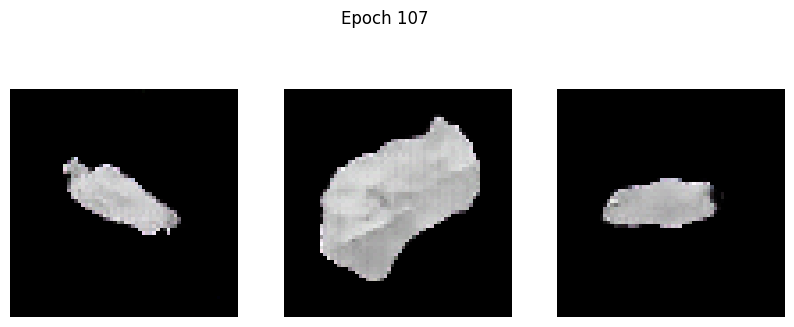

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2033 - g_loss: 2.6702
Epoch 108/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.9917 - g_loss: 2.8664

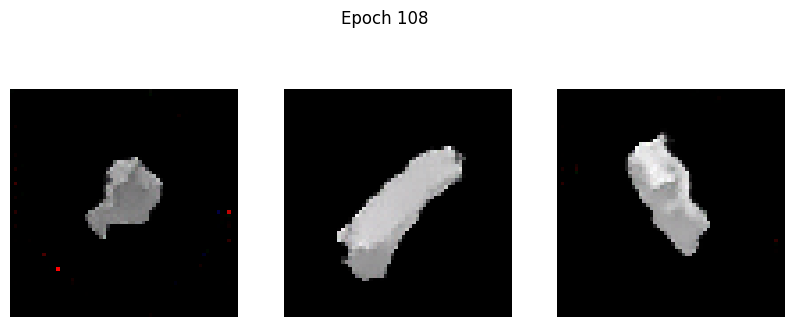

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.9863 - g_loss: 2.8626
Epoch 109/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1876 - g_loss: 2.4341

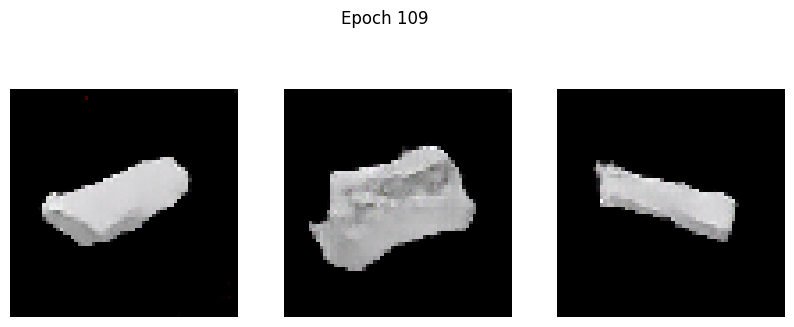

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1875 - g_loss: 2.4342
Epoch 110/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1638 - g_loss: 2.4528

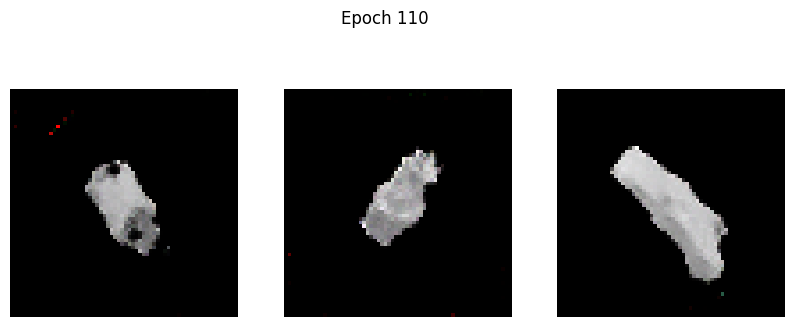

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1638 - g_loss: 2.4533
Epoch 111/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1786 - g_loss: 2.5314

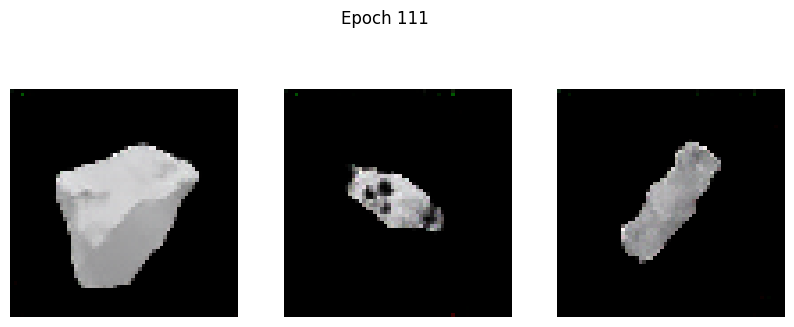

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1785 - g_loss: 2.5320
Epoch 112/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1803 - g_loss: 2.6053

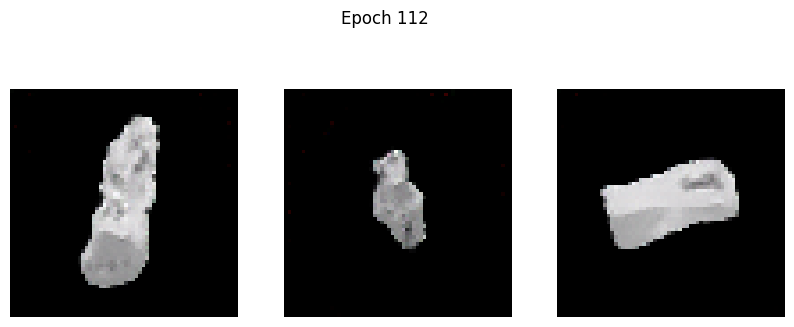

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1804 - g_loss: 2.6057
Epoch 113/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3038 - g_loss: 2.7235

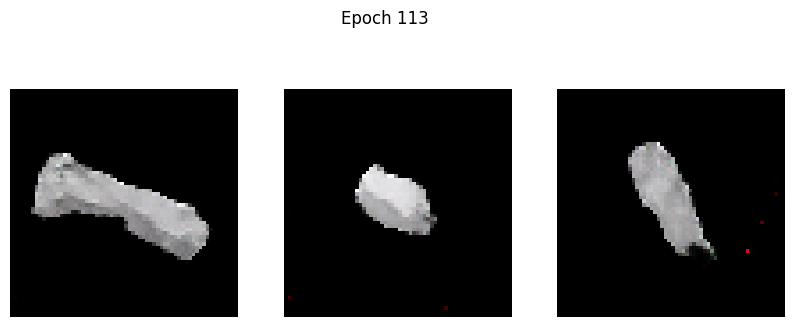

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3048 - g_loss: 2.7250
Epoch 114/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1945 - g_loss: 2.3949

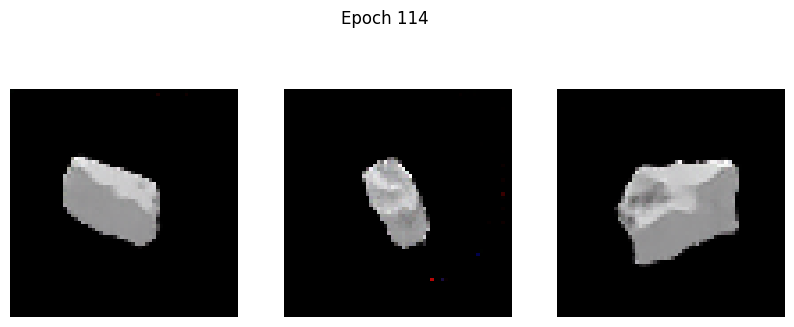

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1945 - g_loss: 2.3954
Epoch 115/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1794 - g_loss: 2.5457

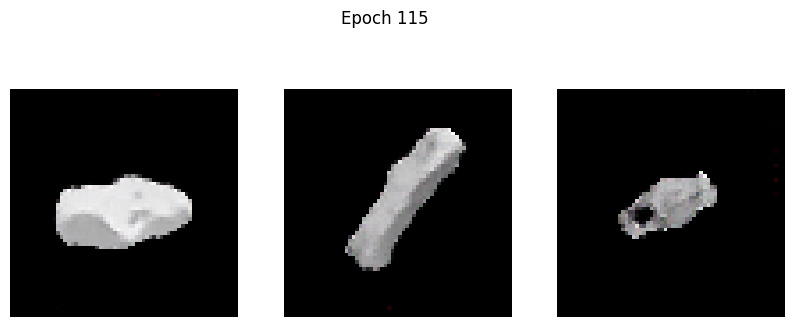

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1795 - g_loss: 2.5455
Epoch 116/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1777 - g_loss: 2.5689

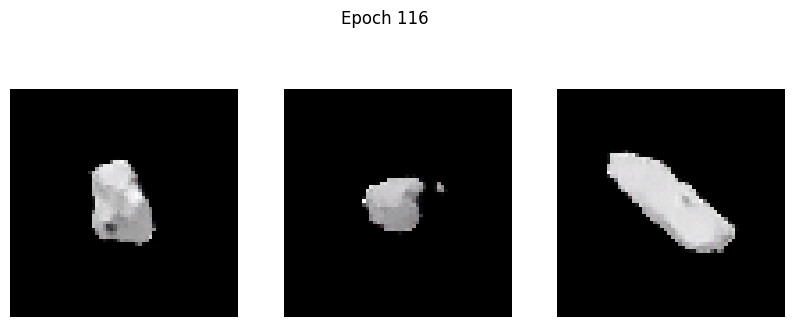

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1779 - g_loss: 2.5694
Epoch 117/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1787 - g_loss: 2.7690

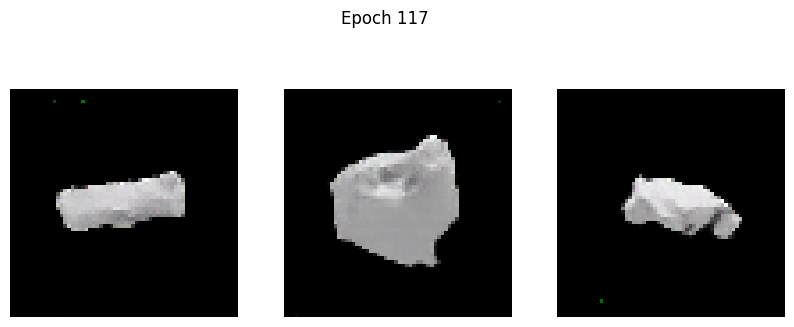

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1788 - g_loss: 2.7685
Epoch 118/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2147 - g_loss: 2.6707

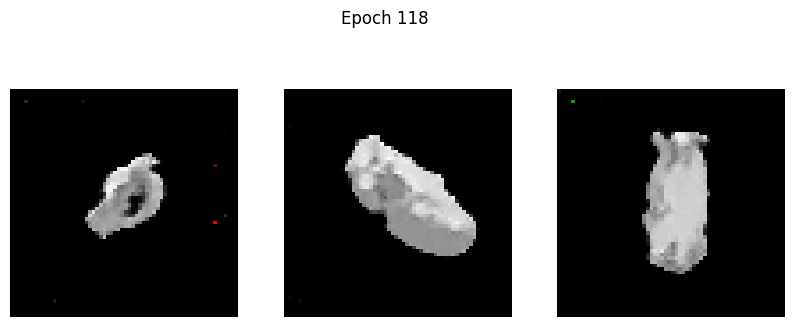

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2145 - g_loss: 2.6708
Epoch 119/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1801 - g_loss: 2.7250

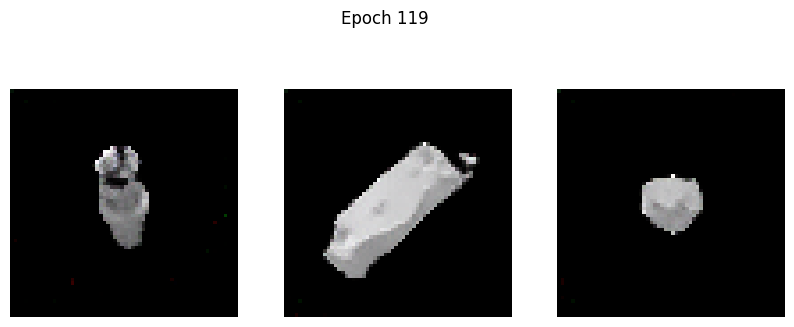

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1800 - g_loss: 2.7245
Epoch 120/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1840 - g_loss: 2.7996

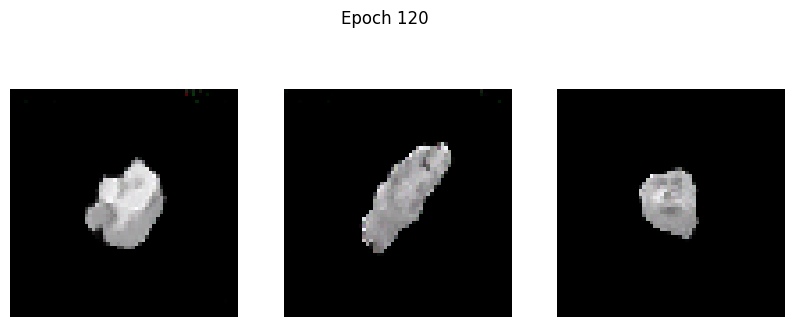

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - d_loss: 0.1842 - g_loss: 2.7994
Epoch 121/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1657 - g_loss: 2.7309

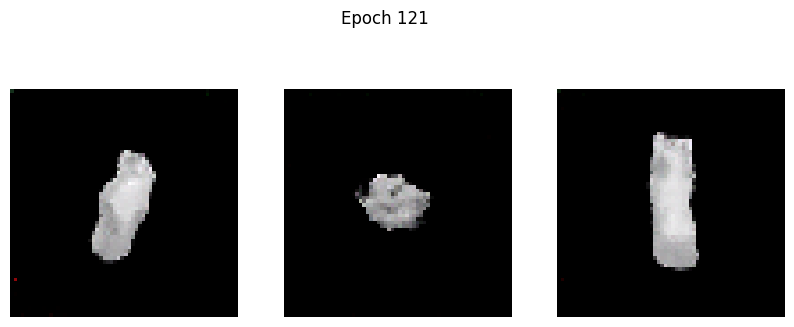

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1657 - g_loss: 2.7311
Epoch 122/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2150 - g_loss: 2.8163

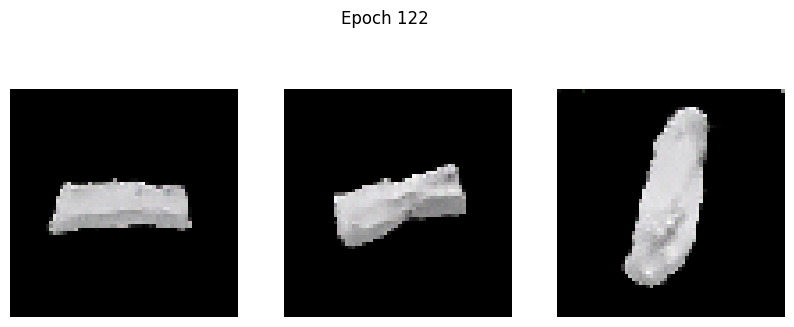

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2152 - g_loss: 2.8166
Epoch 123/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1778 - g_loss: 2.7764

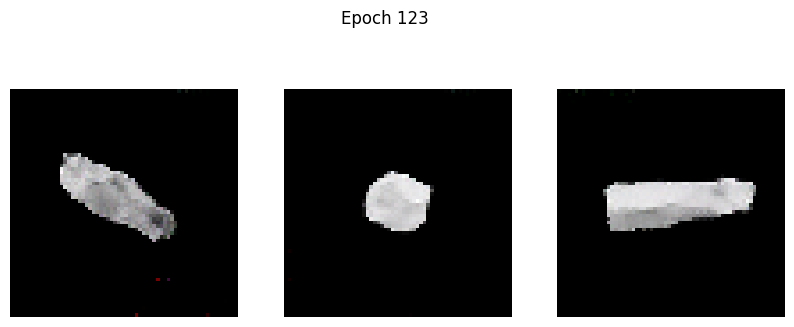

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1777 - g_loss: 2.7761
Epoch 124/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2911 - g_loss: 2.8122

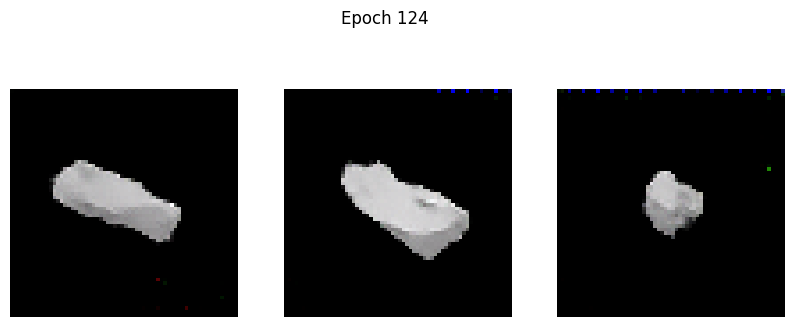

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2906 - g_loss: 2.8117
Epoch 125/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1788 - g_loss: 2.8437

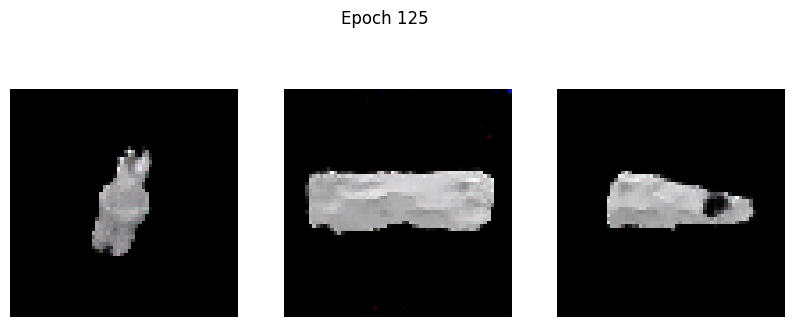

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.1792 - g_loss: 2.8439
Epoch 126/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1898 - g_loss: 2.7268

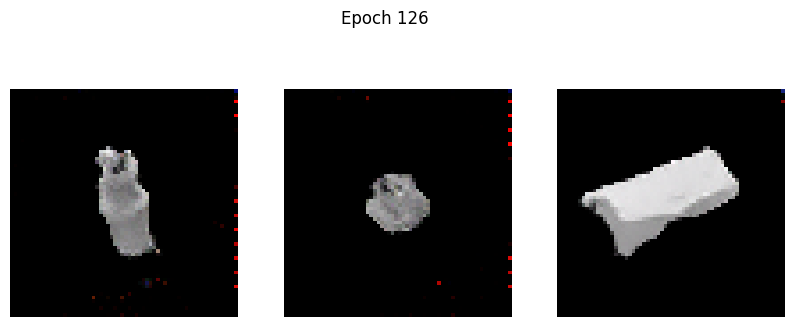

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1901 - g_loss: 2.7276
Epoch 127/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1414 - g_loss: 2.7298

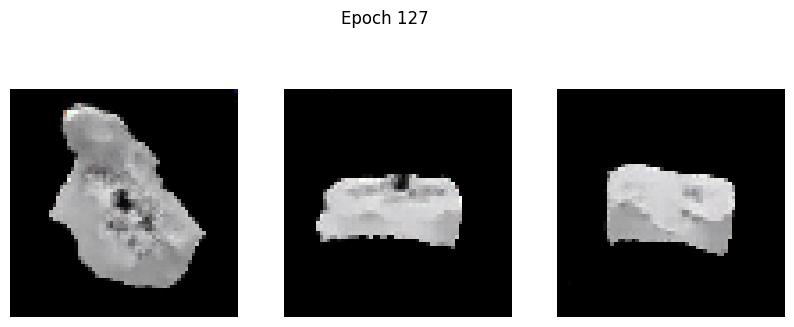

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1414 - g_loss: 2.7301
Epoch 128/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1651 - g_loss: 2.8264

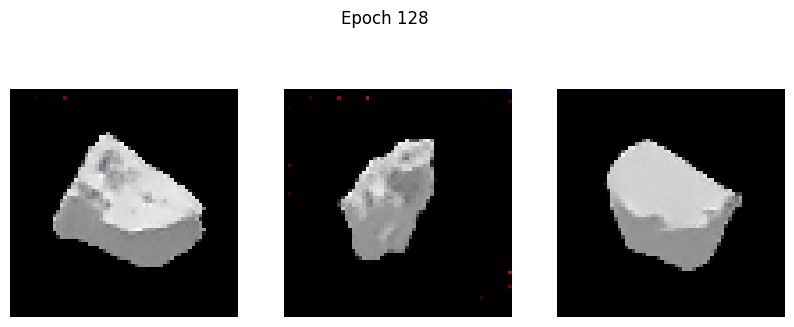

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1652 - g_loss: 2.8261
Epoch 129/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1727 - g_loss: 2.9170

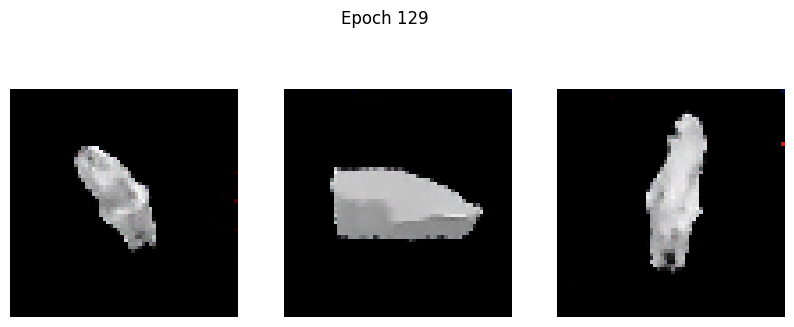

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1725 - g_loss: 2.9163
Epoch 130/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3233 - g_loss: 3.1245

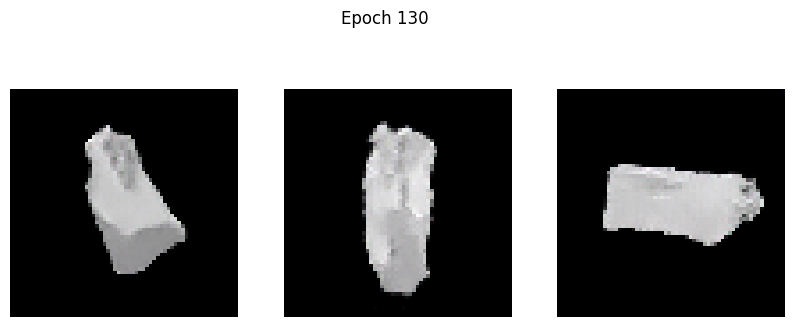

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.3241 - g_loss: 3.1247
Epoch 131/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1514 - g_loss: 2.6551

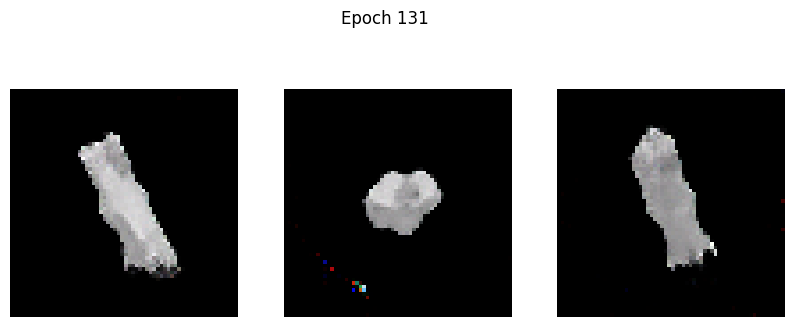

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.1514 - g_loss: 2.6554
Epoch 132/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1599 - g_loss: 2.7677

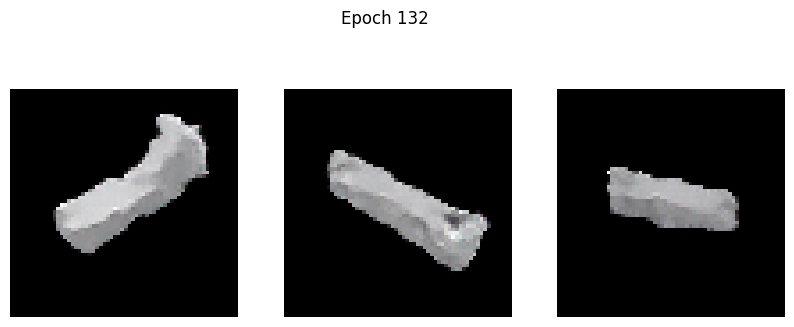

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1599 - g_loss: 2.7678
Epoch 133/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1587 - g_loss: 2.8929

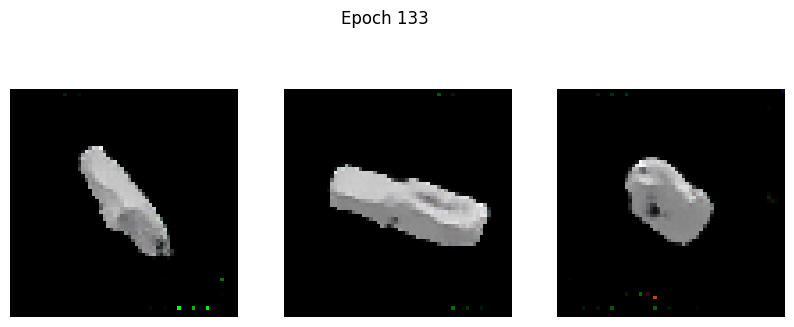

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1586 - g_loss: 2.8925
Epoch 134/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2165 - g_loss: 2.8965

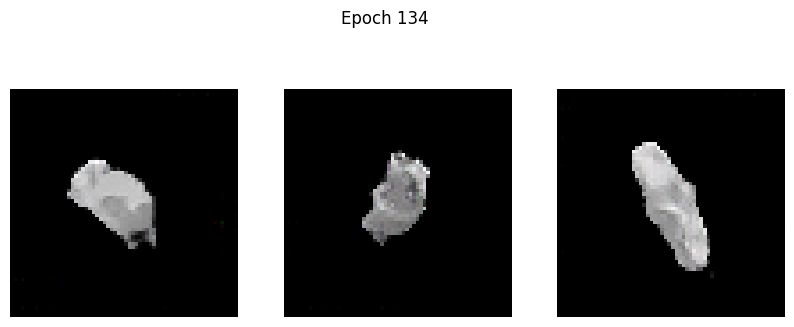

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2162 - g_loss: 2.8960
Epoch 135/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2511 - g_loss: 2.9873

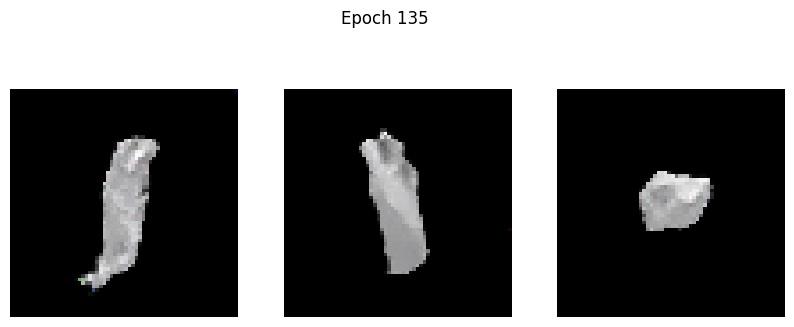

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2517 - g_loss: 2.9887
Epoch 136/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1536 - g_loss: 2.7647

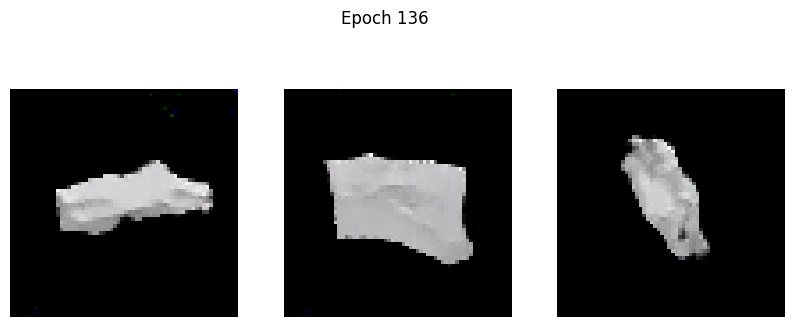

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1536 - g_loss: 2.7648
Epoch 137/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1801 - g_loss: 2.8272

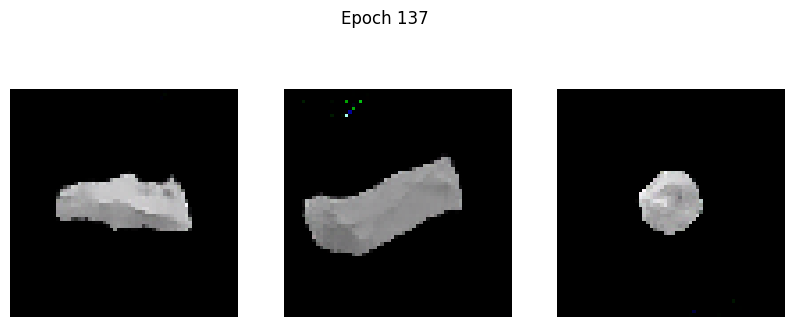

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1799 - g_loss: 2.8268
Epoch 138/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1630 - g_loss: 2.9277

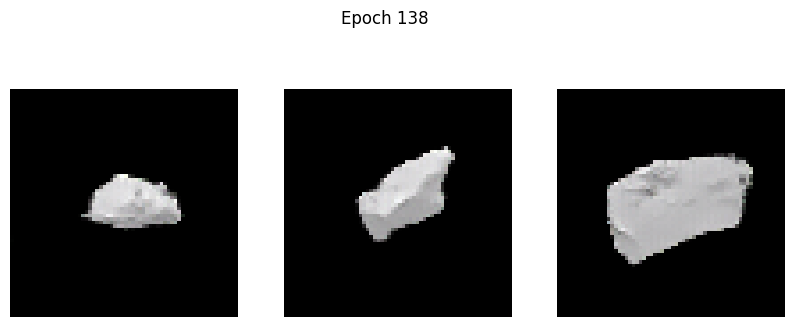

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1633 - g_loss: 2.9281
Epoch 139/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.2104 - g_loss: 2.9037

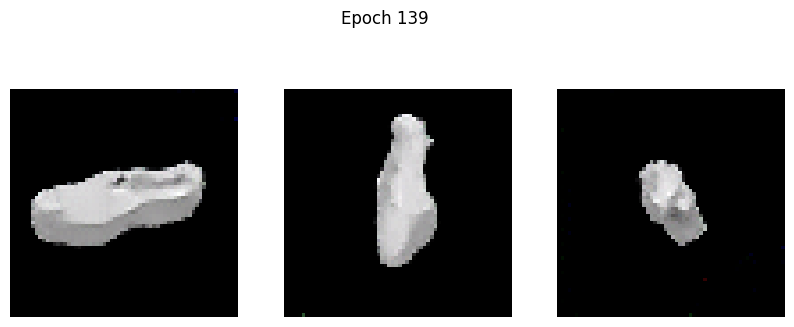

100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - d_loss: 0.2100 - g_loss: 2.9037
Epoch 140/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - d_loss: 0.1478 - g_loss: 2.9014

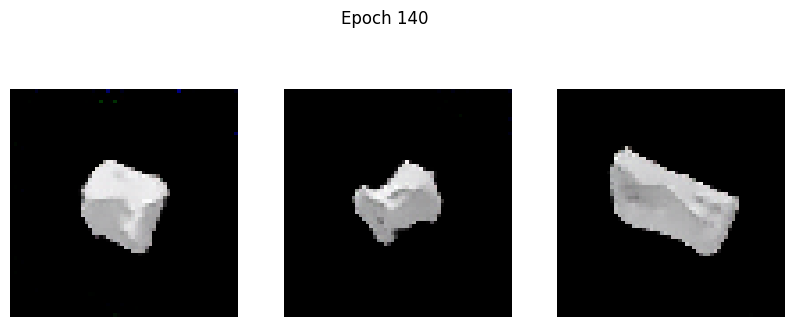

100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - d_loss: 0.1479 - g_loss: 2.9021
Epoch 141/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - d_loss: 0.1816 - g_loss: 2.9466

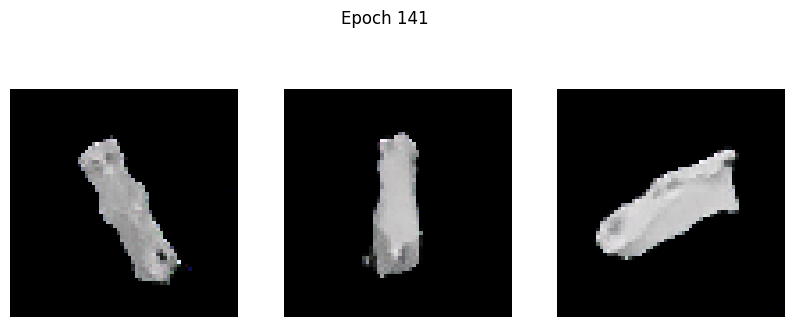

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - d_loss: 0.1819 - g_loss: 2.9469
Epoch 142/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - d_loss: 0.1617 - g_loss: 2.9679

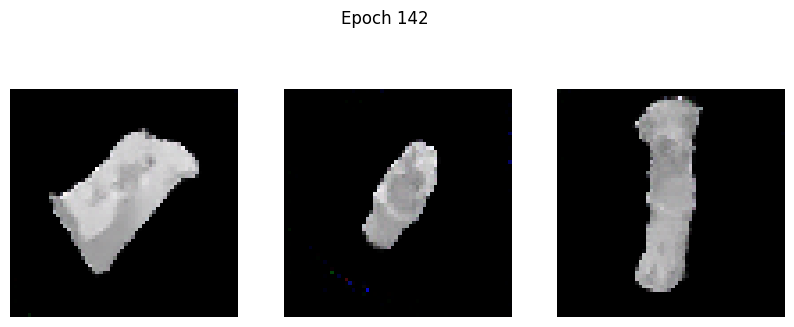

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - d_loss: 0.1616 - g_loss: 2.9674
Epoch 143/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1640 - g_loss: 3.0261

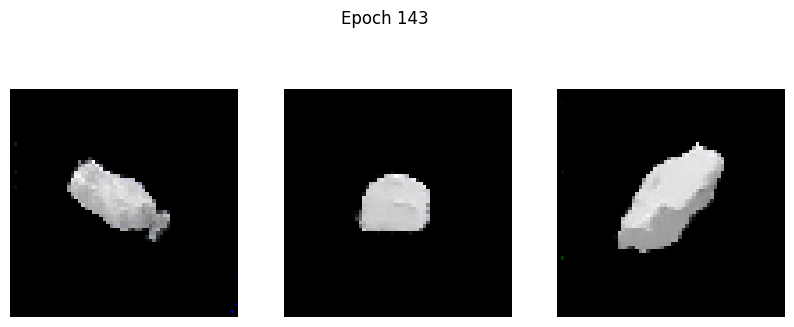

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1642 - g_loss: 3.0268
Epoch 144/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1676 - g_loss: 2.9567

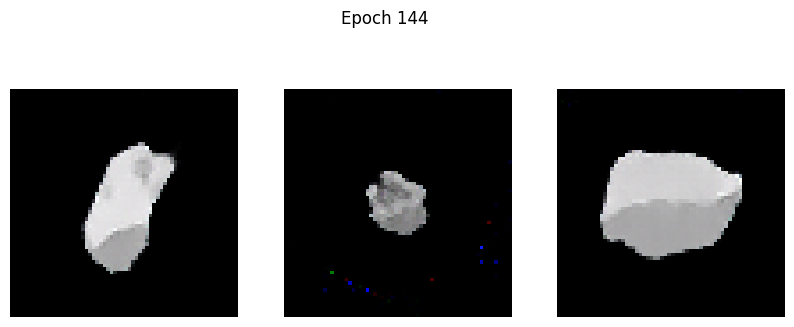

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1676 - g_loss: 2.9572
Epoch 145/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.2187 - g_loss: 3.0029

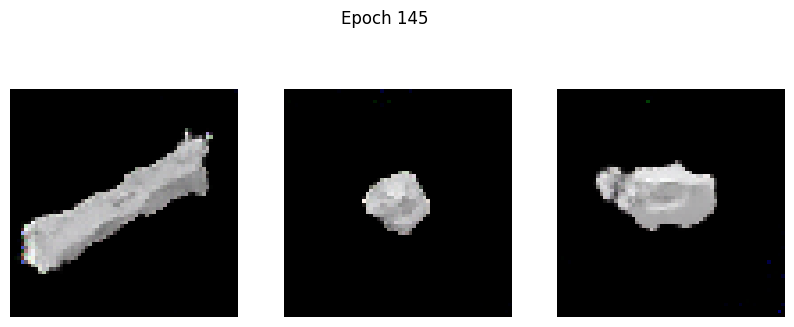

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.2182 - g_loss: 3.0028
Epoch 146/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1661 - g_loss: 3.2167

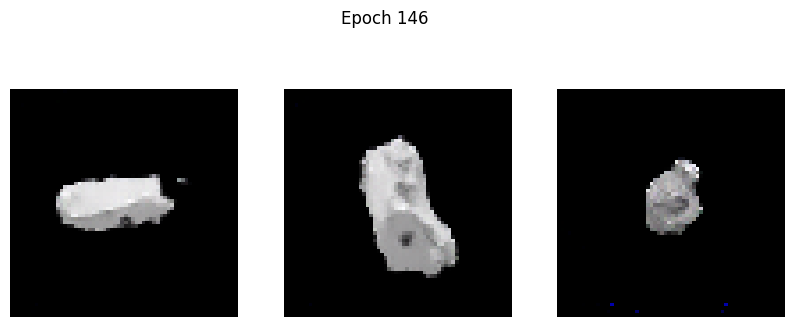

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.1662 - g_loss: 3.2158
Epoch 147/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1714 - g_loss: 3.0365

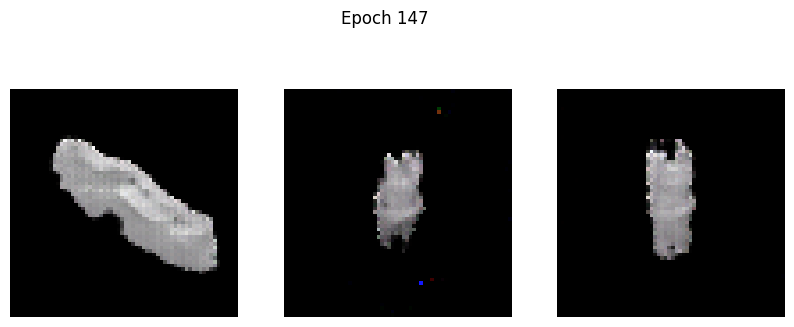

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1736 - g_loss: 3.0414
Epoch 148/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2402 - g_loss: 2.9736

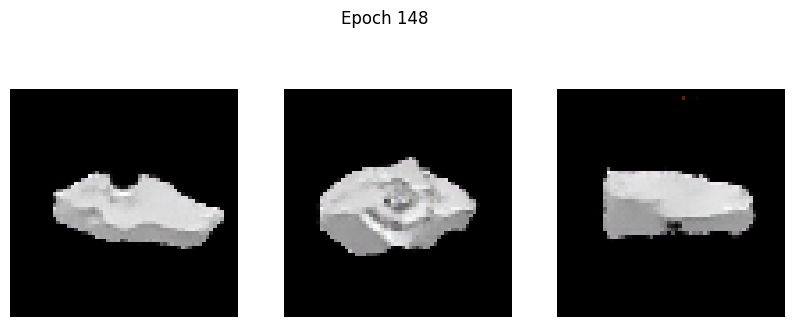

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.2396 - g_loss: 2.9729
Epoch 149/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2061 - g_loss: 2.8553

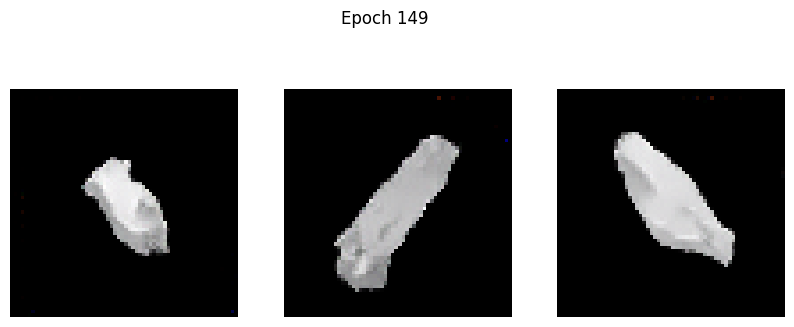

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2057 - g_loss: 2.8557
Epoch 150/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1433 - g_loss: 2.8953

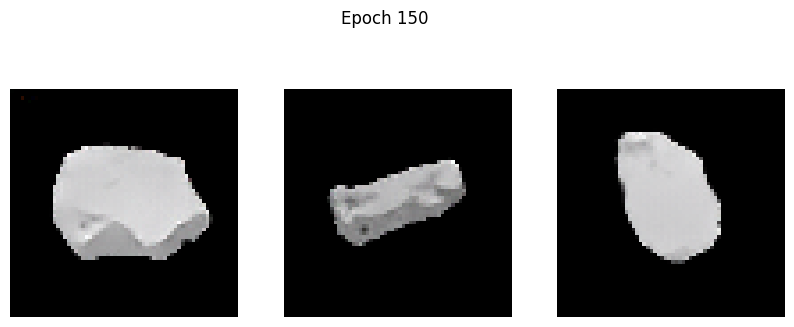

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1433 - g_loss: 2.8958
Epoch 151/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1396 - g_loss: 2.9676

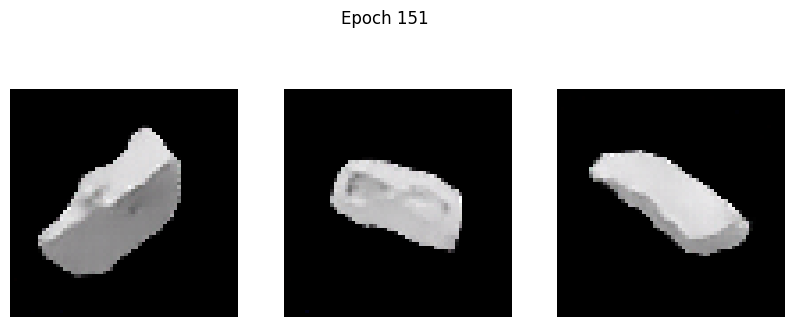

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1398 - g_loss: 2.9681
Epoch 152/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1270 - g_loss: 3.0394

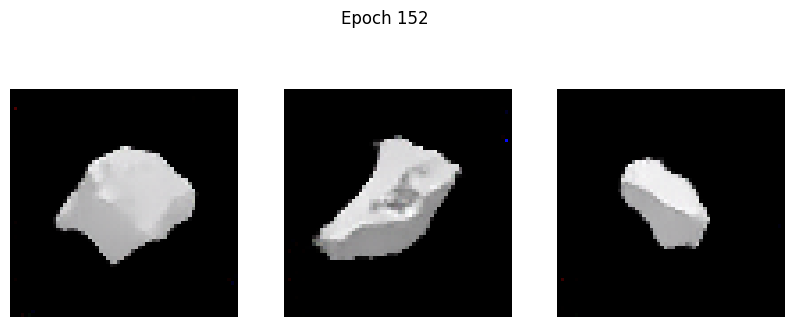

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1272 - g_loss: 3.0392
Epoch 153/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2217 - g_loss: 3.1016

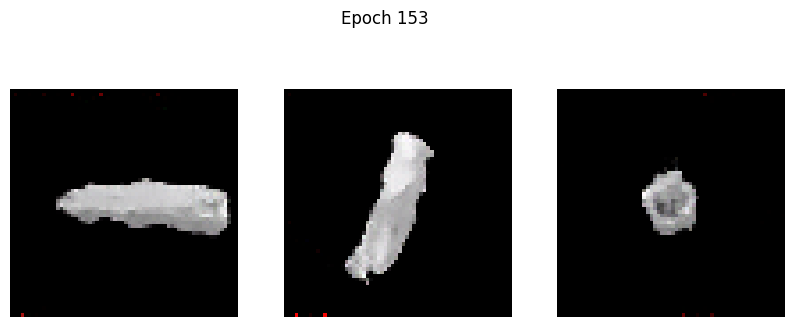

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2218 - g_loss: 3.1014
Epoch 154/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1355 - g_loss: 3.0782

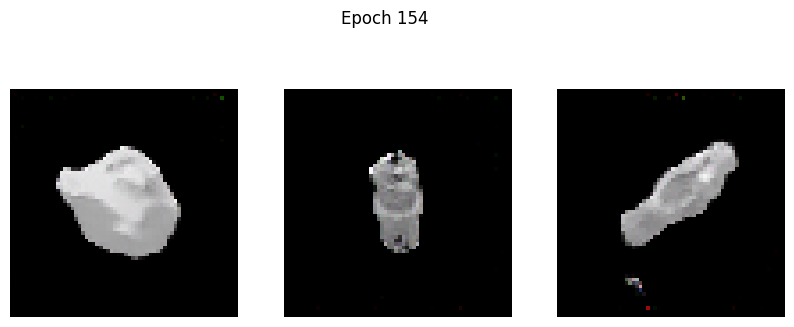

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1354 - g_loss: 3.0777
Epoch 155/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1352 - g_loss: 3.1116

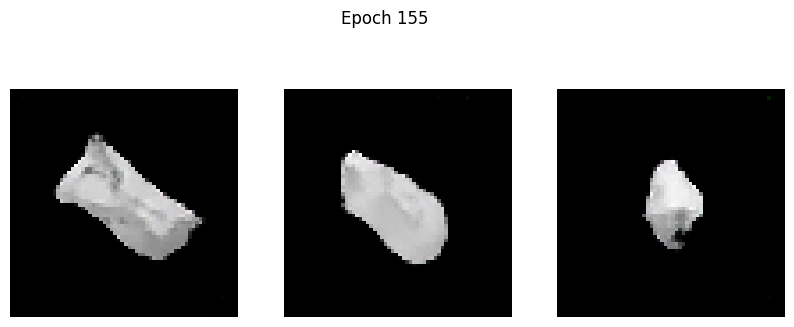

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1353 - g_loss: 3.1115
Epoch 156/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2532 - g_loss: 3.2164

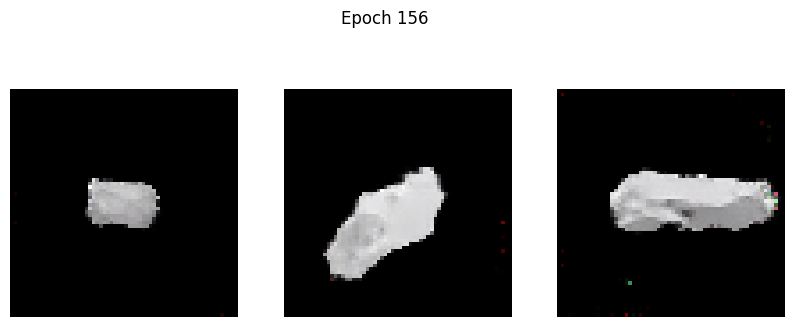

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2542 - g_loss: 3.2169
Epoch 157/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1408 - g_loss: 2.8936

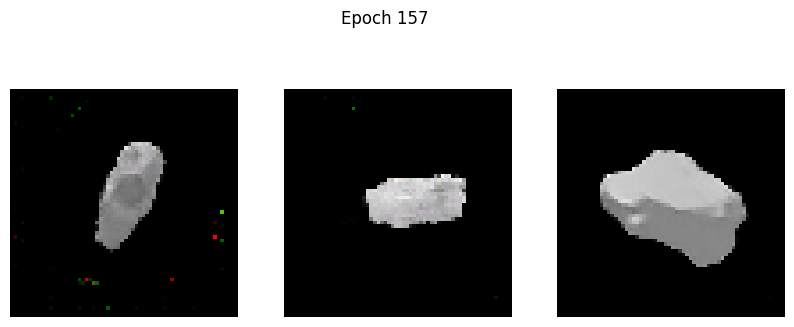

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1407 - g_loss: 2.8938
Epoch 158/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1230 - g_loss: 3.0044

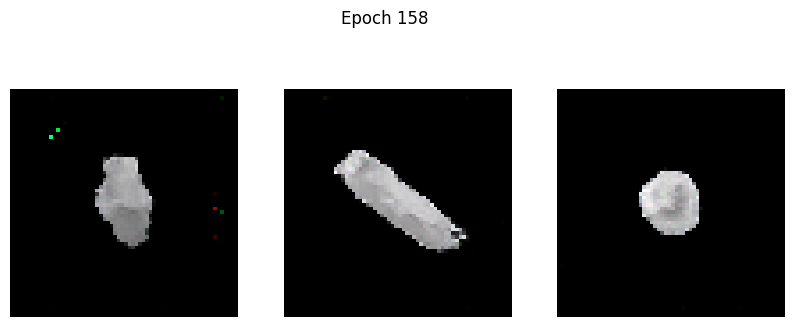

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1230 - g_loss: 3.0049
Epoch 159/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1715 - g_loss: 3.1928

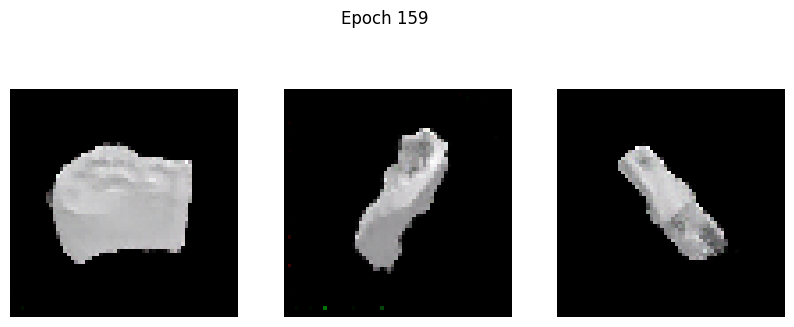

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1725 - g_loss: 3.1943
Epoch 160/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1498 - g_loss: 2.9866

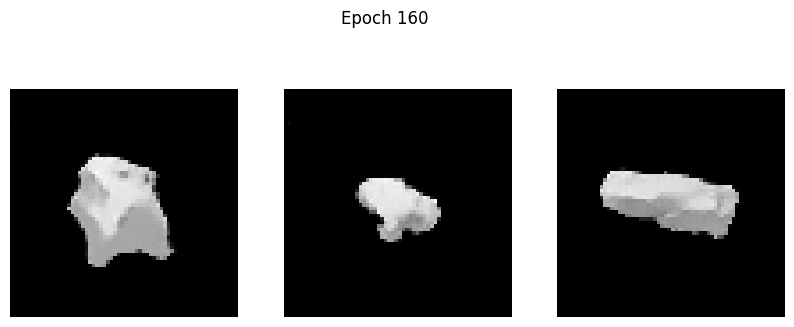

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1497 - g_loss: 2.9864
Epoch 161/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1189 - g_loss: 3.1030

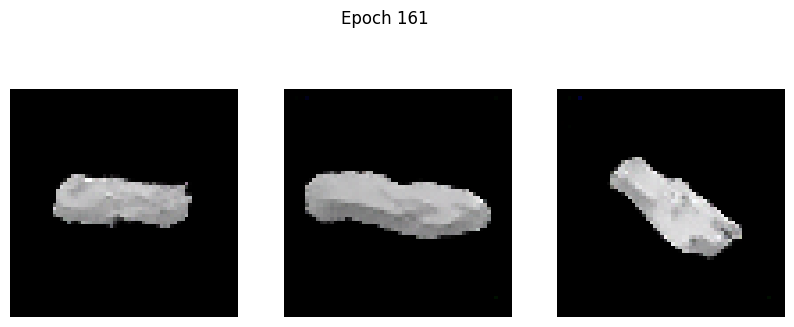

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1190 - g_loss: 3.1029
Epoch 162/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2413 - g_loss: 3.2380

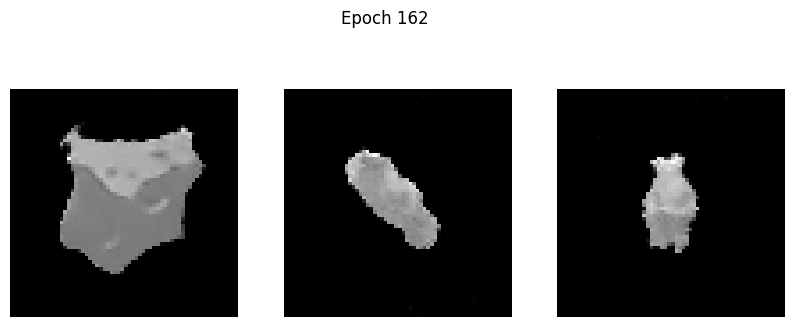

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2414 - g_loss: 3.2377
Epoch 163/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1391 - g_loss: 3.1596

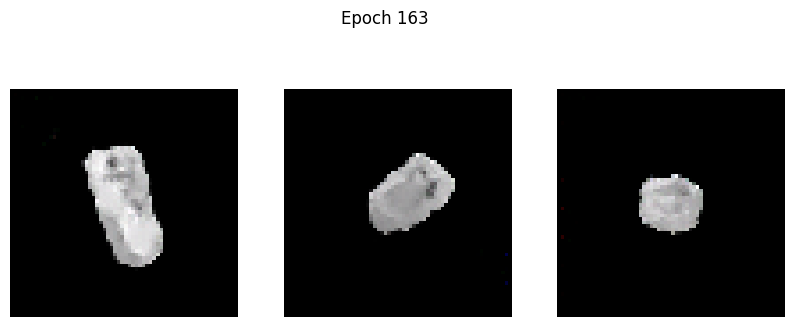

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1390 - g_loss: 3.1588
Epoch 164/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1416 - g_loss: 3.1281

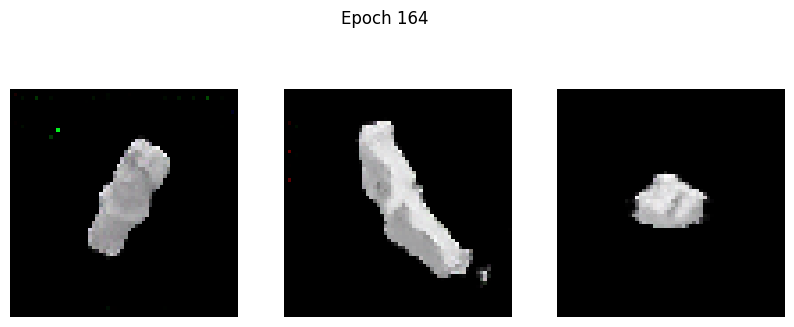

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1416 - g_loss: 3.1282
Epoch 165/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1276 - g_loss: 3.1391

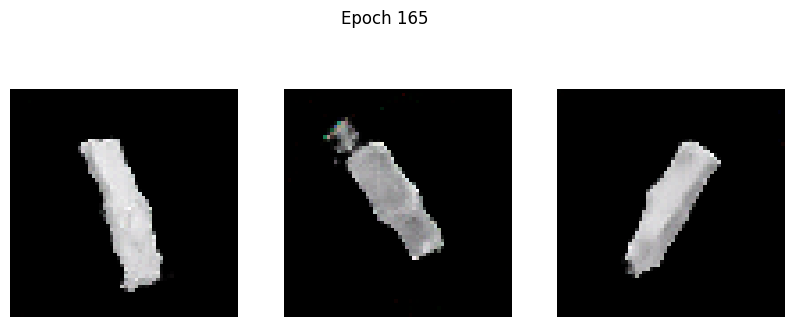

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1276 - g_loss: 3.1393
Epoch 166/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2223 - g_loss: 3.3043

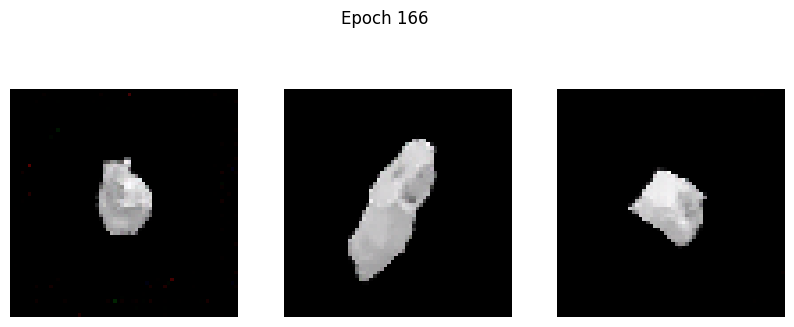

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2227 - g_loss: 3.3040
Epoch 167/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1389 - g_loss: 3.1575

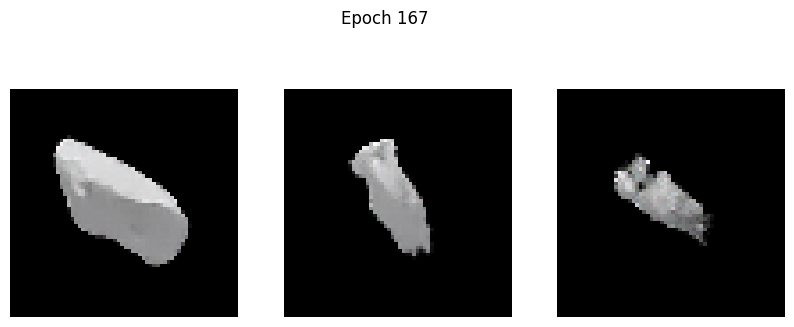

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1390 - g_loss: 3.1582
Epoch 168/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1289 - g_loss: 3.0415

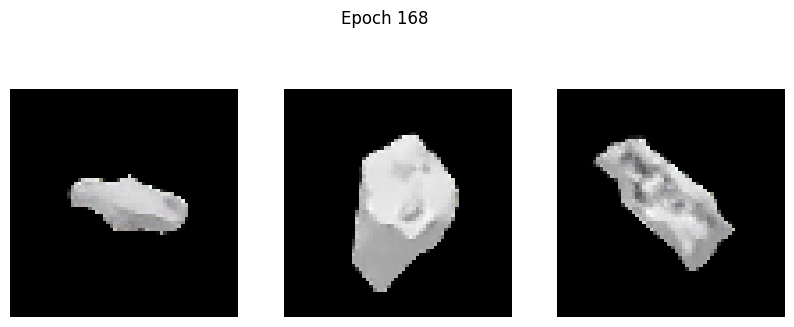

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1289 - g_loss: 3.0420
Epoch 169/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1400 - g_loss: 3.1767

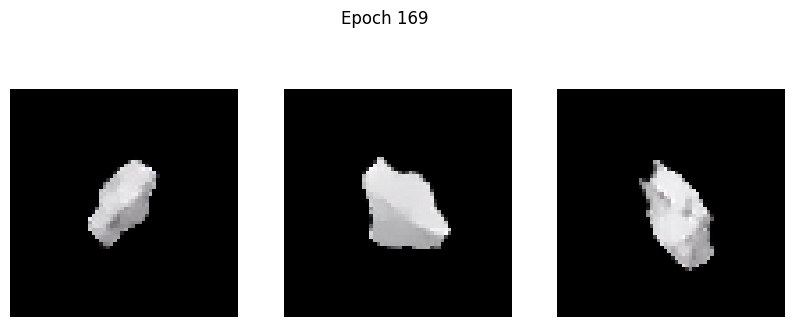

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1399 - g_loss: 3.1772
Epoch 170/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2766 - g_loss: 3.3831

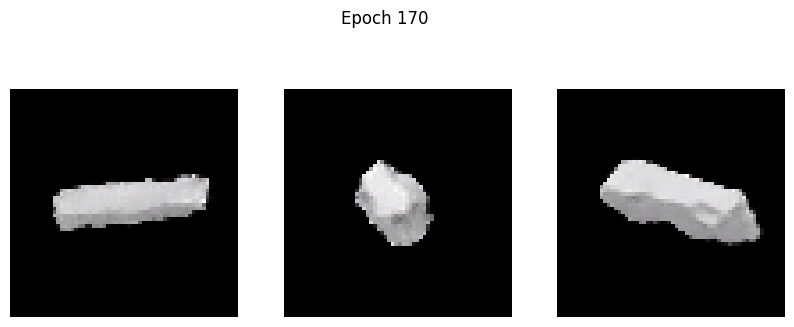

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2773 - g_loss: 3.3829
Epoch 171/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1142 - g_loss: 3.0172

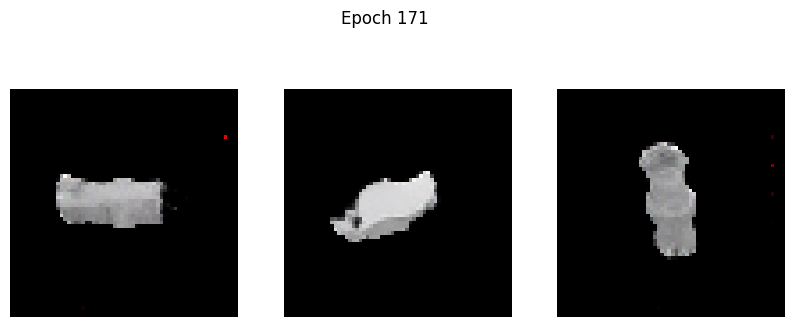

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.1141 - g_loss: 3.0174
Epoch 172/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1078 - g_loss: 3.1928

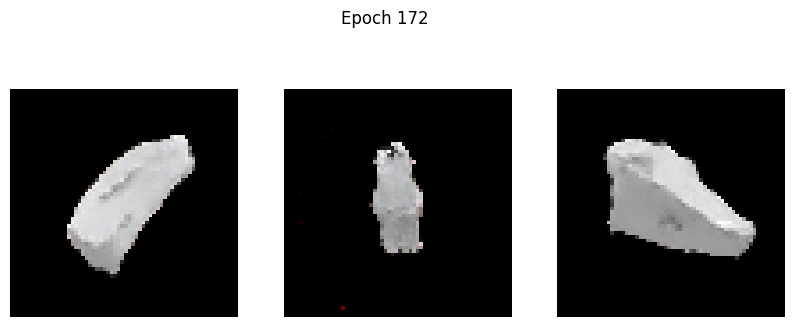

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1079 - g_loss: 3.1925
Epoch 173/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1841 - g_loss: 3.1830

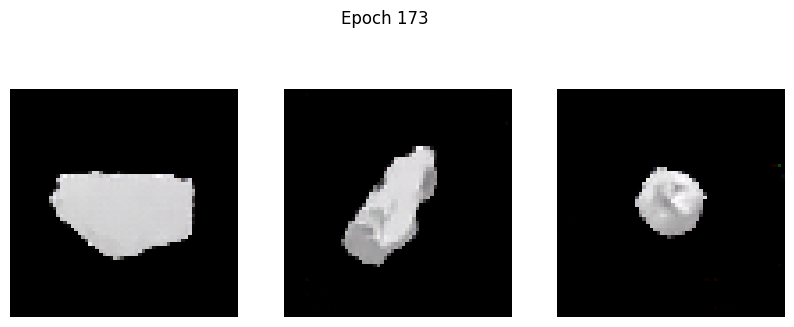

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1837 - g_loss: 3.1833
Epoch 174/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1489 - g_loss: 3.2364

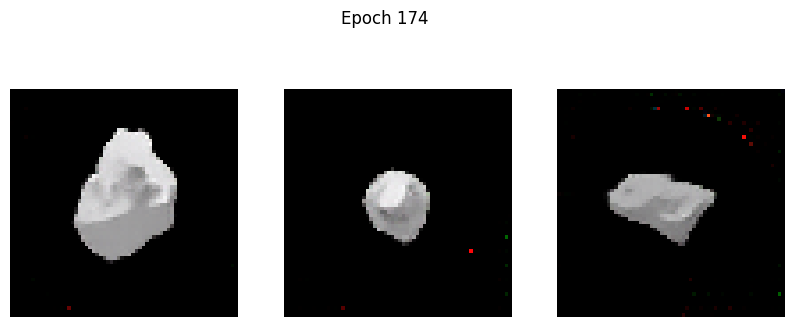

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1490 - g_loss: 3.2366
Epoch 175/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1270 - g_loss: 3.3077

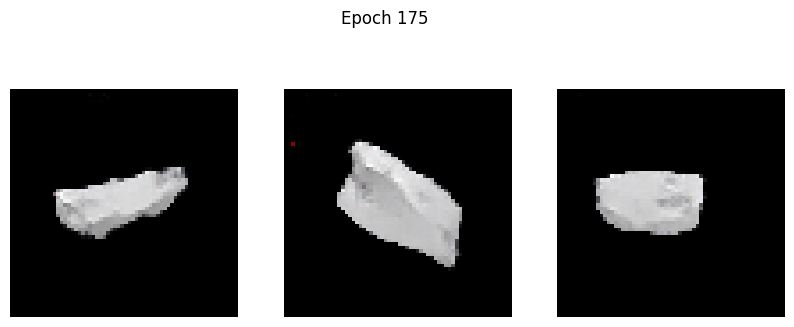

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1270 - g_loss: 3.3074
Epoch 176/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2022 - g_loss: 3.3933

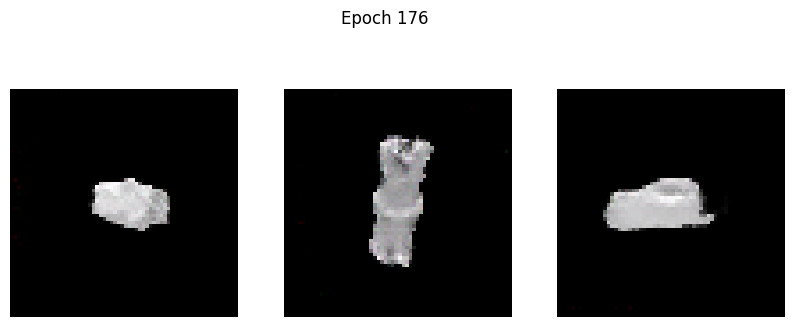

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2023 - g_loss: 3.3931
Epoch 177/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1335 - g_loss: 3.2505

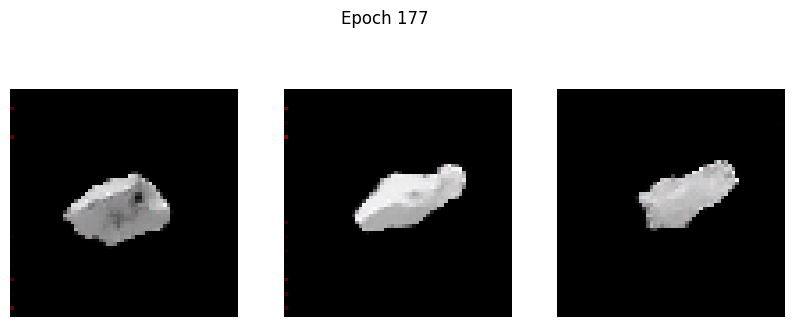

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1334 - g_loss: 3.2503
Epoch 178/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1113 - g_loss: 3.2129

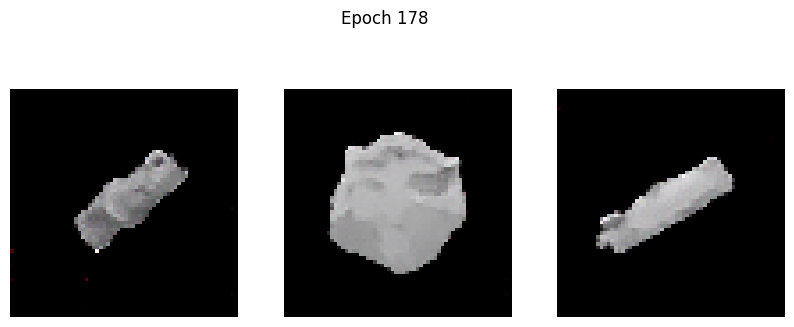

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1113 - g_loss: 3.2135
Epoch 179/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1289 - g_loss: 3.4037

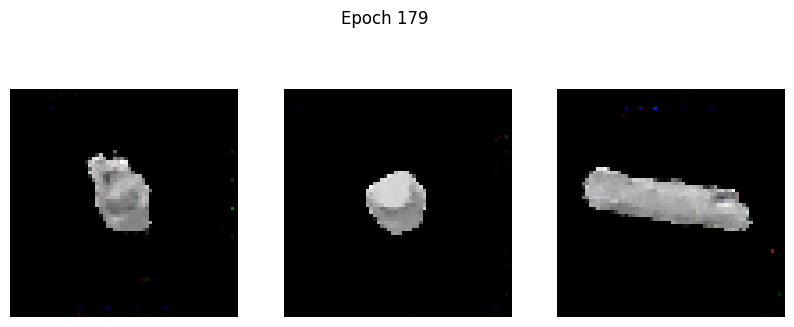

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1293 - g_loss: 3.4035
Epoch 180/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1183 - g_loss: 3.2902

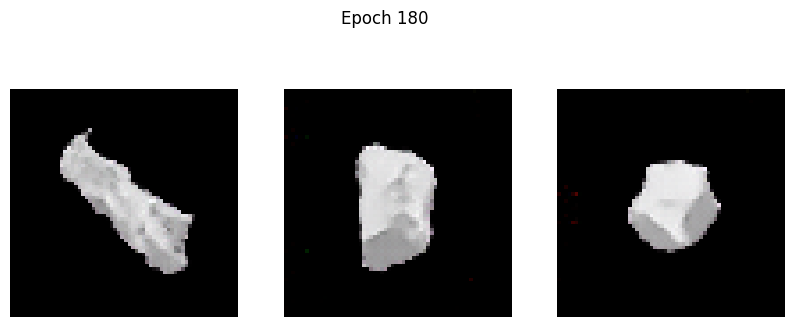

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1193 - g_loss: 3.2918
Epoch 181/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1618 - g_loss: 3.2364

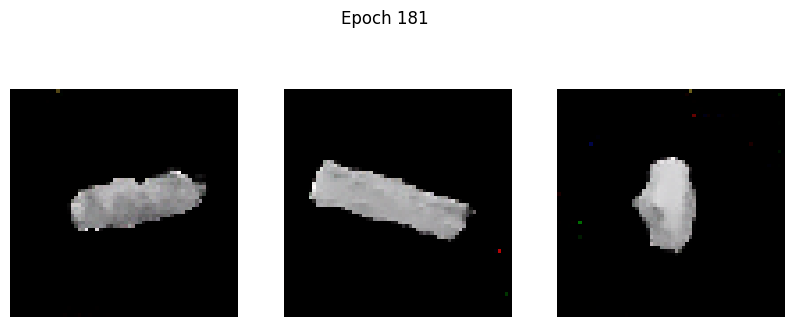

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.1616 - g_loss: 3.2362
Epoch 182/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1220 - g_loss: 3.2365

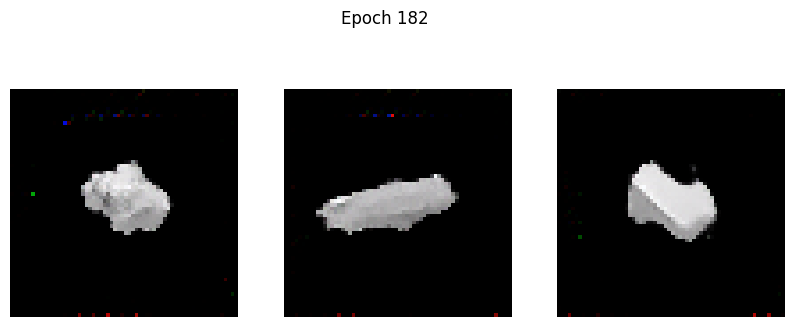

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1222 - g_loss: 3.2371
Epoch 183/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1212 - g_loss: 3.3992

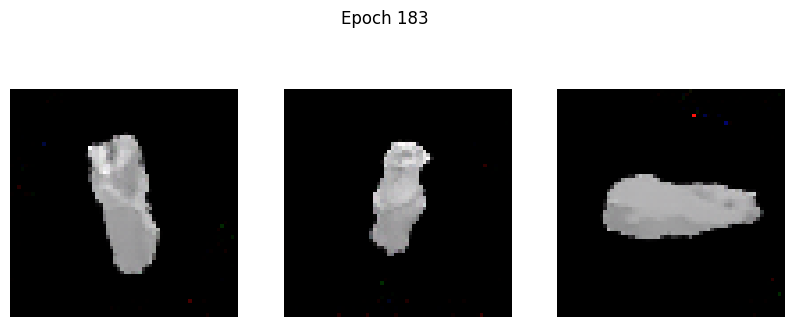

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.1213 - g_loss: 3.3990
Epoch 184/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2092 - g_loss: 3.3888

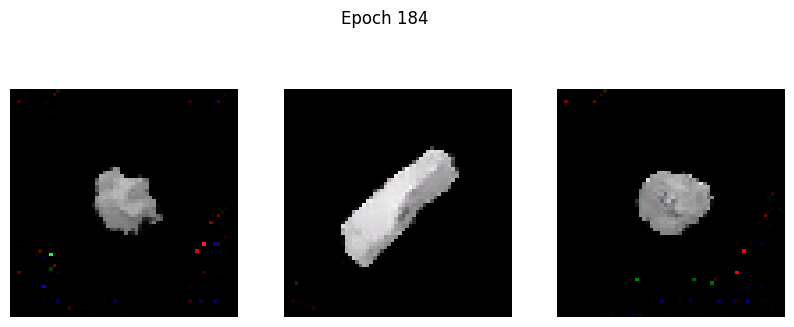

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - d_loss: 0.2101 - g_loss: 3.3887
Epoch 185/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - d_loss: 0.1315 - g_loss: 3.2678

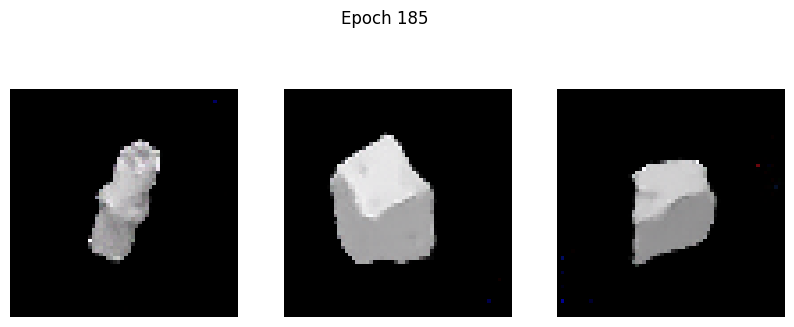

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - d_loss: 0.1315 - g_loss: 3.2677
Epoch 186/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0955 - g_loss: 3.2888

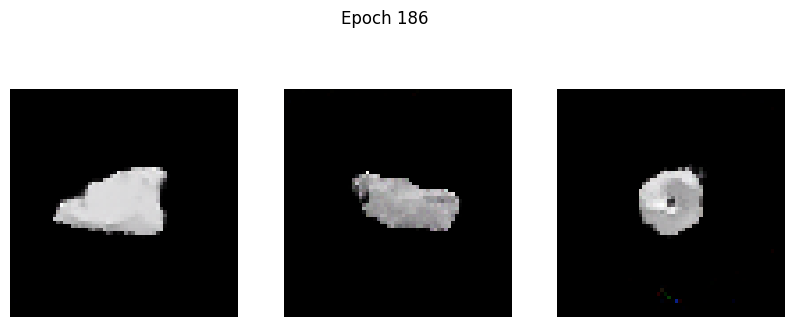

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.0956 - g_loss: 3.2887
Epoch 187/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1181 - g_loss: 3.4204

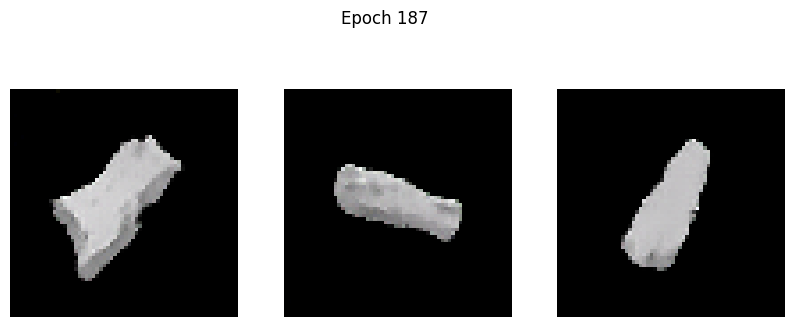

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - d_loss: 0.1186 - g_loss: 3.4203
Epoch 188/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1376 - g_loss: 3.4187

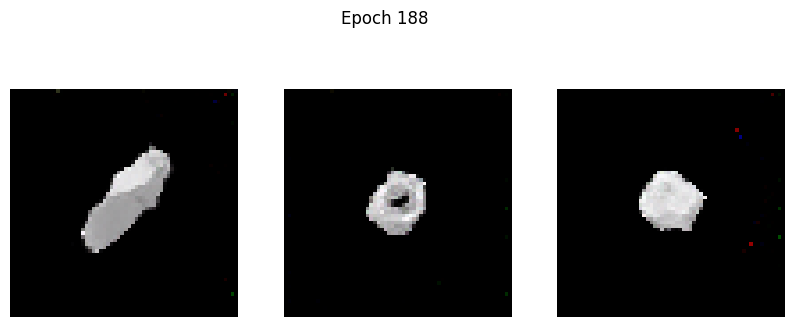

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1375 - g_loss: 3.4186
Epoch 189/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1412 - g_loss: 3.3741

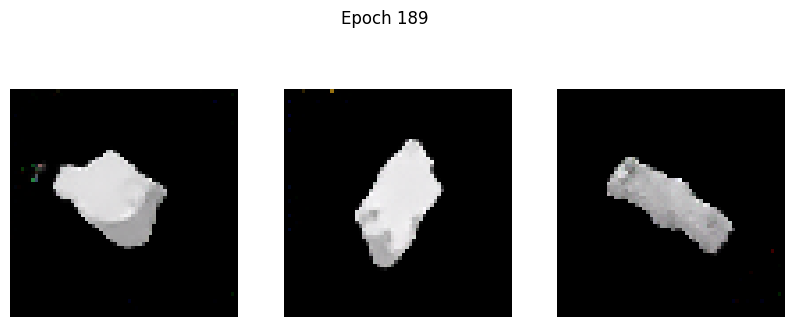

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1410 - g_loss: 3.3739
Epoch 190/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0992 - g_loss: 3.3871

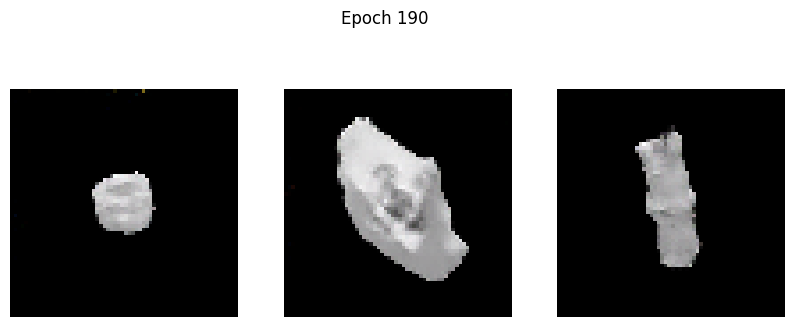

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0993 - g_loss: 3.3873
Epoch 191/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1341 - g_loss: 3.5090

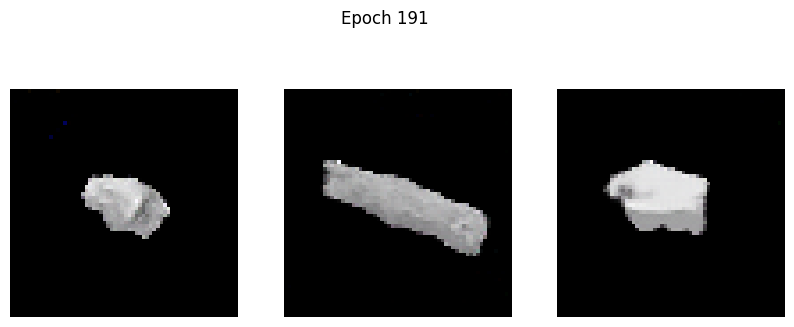

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1343 - g_loss: 3.5092
Epoch 192/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3975 - g_loss: 3.7369

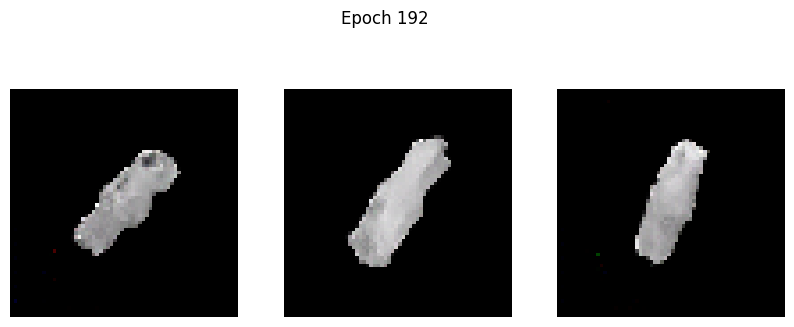

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3962 - g_loss: 3.7346
Epoch 193/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0887 - g_loss: 3.3988

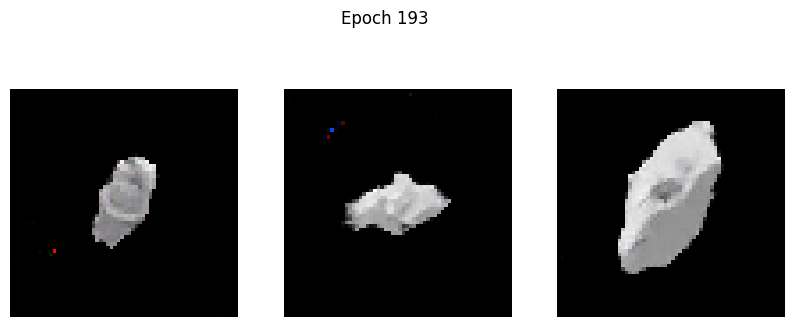

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0888 - g_loss: 3.3985
Epoch 194/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1135 - g_loss: 3.3592

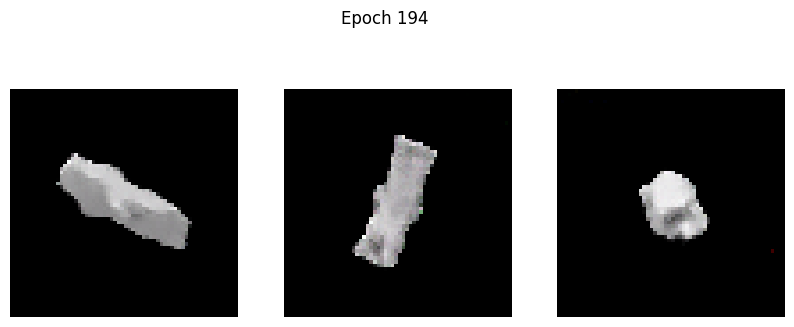

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1139 - g_loss: 3.3595
Epoch 195/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1537 - g_loss: 3.4985

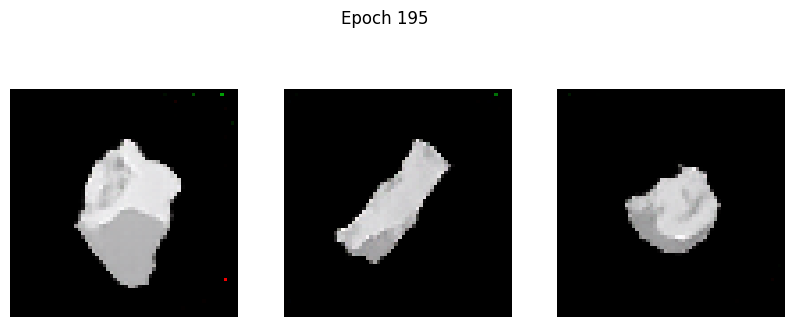

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1536 - g_loss: 3.4980
Epoch 196/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0877 - g_loss: 3.4348

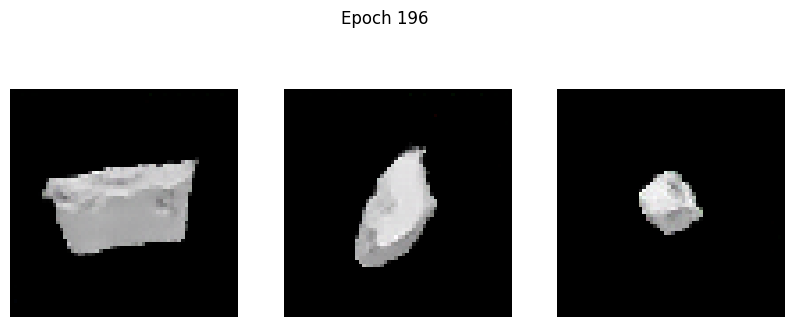

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0878 - g_loss: 3.4348
Epoch 197/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1010 - g_loss: 3.4660

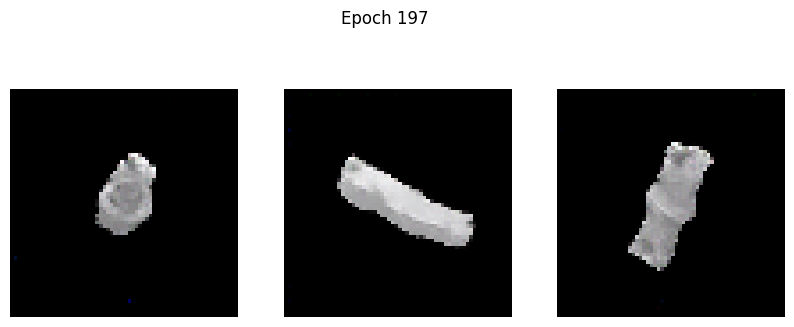

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.1009 - g_loss: 3.4660
Epoch 198/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1099 - g_loss: 3.5781

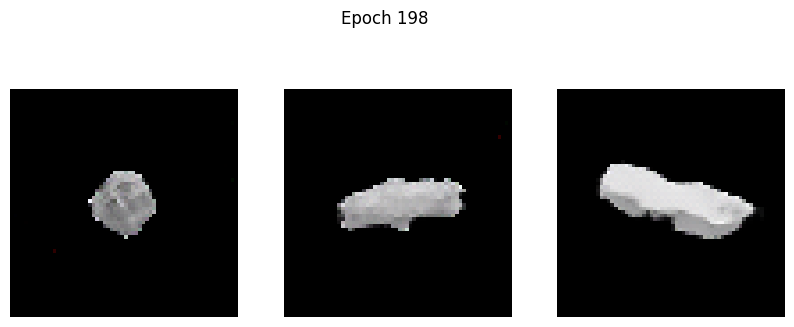

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1101 - g_loss: 3.5781
Epoch 199/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.5013 - g_loss: 3.9547

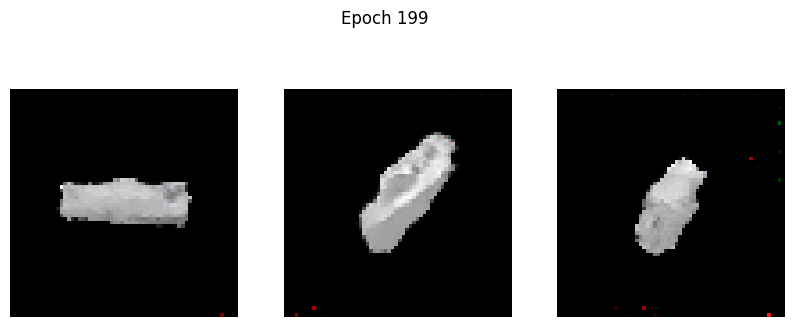

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.5006 - g_loss: 3.9524
Epoch 200/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1025 - g_loss: 3.3069

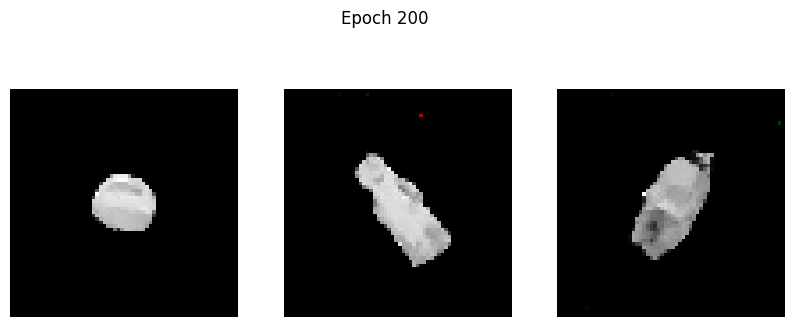

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1025 - g_loss: 3.3070
Epoch 201/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1042 - g_loss: 3.3662

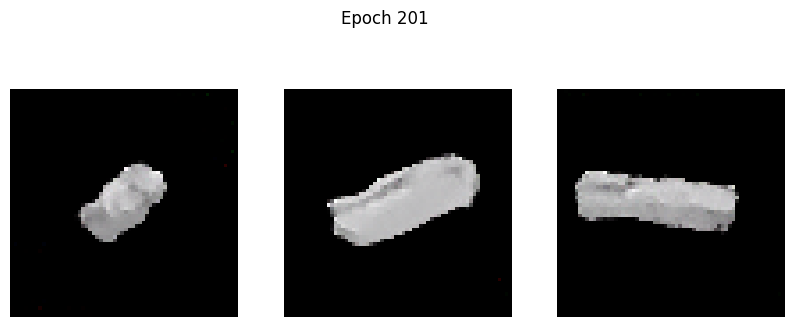

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1043 - g_loss: 3.3669
Epoch 202/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0863 - g_loss: 3.4270

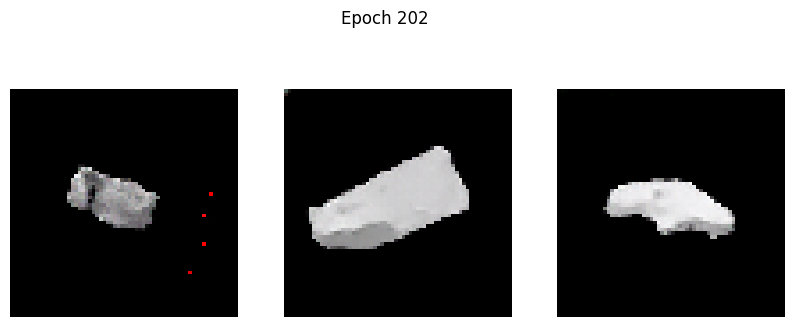

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0864 - g_loss: 3.4271
Epoch 203/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0907 - g_loss: 3.4159

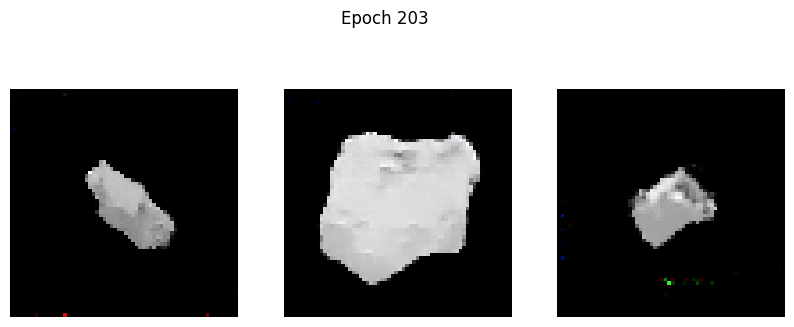

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0909 - g_loss: 3.4164
Epoch 204/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1000 - g_loss: 3.5585

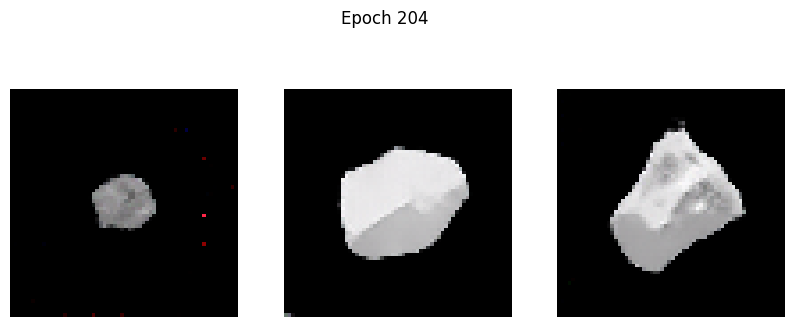

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0999 - g_loss: 3.5588
Epoch 205/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1445 - g_loss: 3.6245

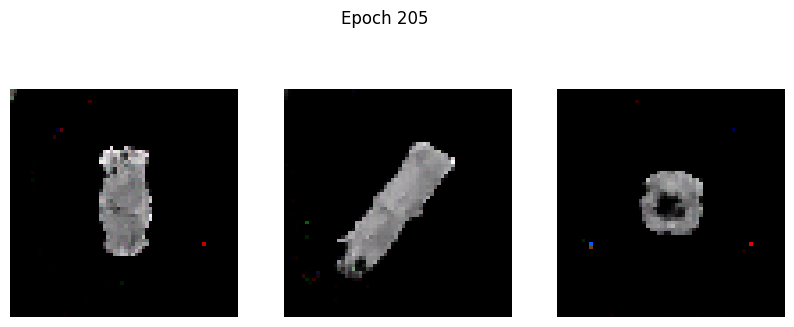

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1467 - g_loss: 3.6286
Epoch 206/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2454 - g_loss: 3.6599

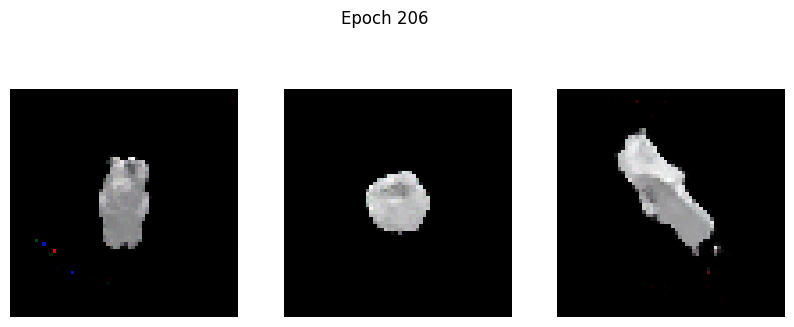

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2446 - g_loss: 3.6581
Epoch 207/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0977 - g_loss: 3.4213

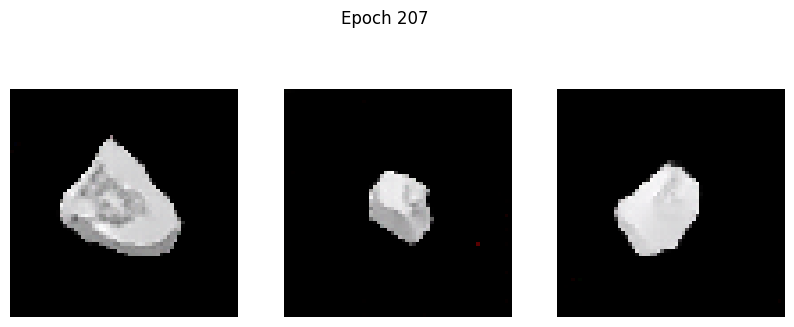

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0977 - g_loss: 3.4213
Epoch 208/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.0928 - g_loss: 3.4347

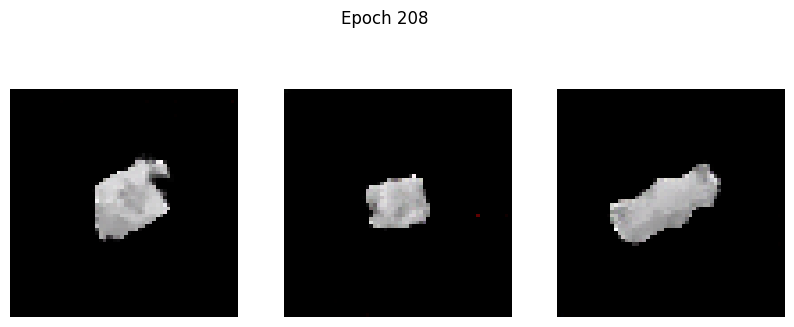

100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - d_loss: 0.0928 - g_loss: 3.4350
Epoch 209/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - d_loss: 0.0841 - g_loss: 3.4119

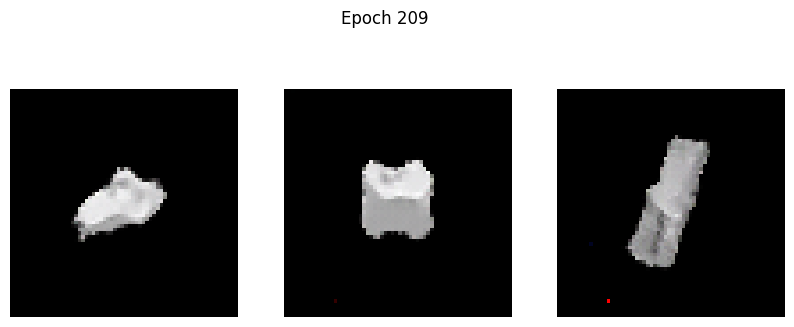

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - d_loss: 0.0842 - g_loss: 3.4125
Epoch 210/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - d_loss: 0.0936 - g_loss: 3.5762

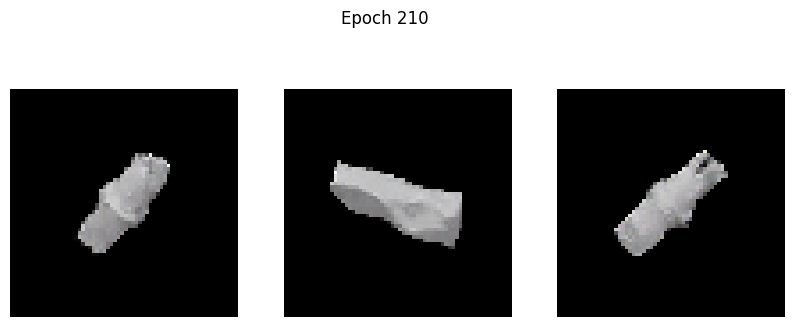

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - d_loss: 0.0936 - g_loss: 3.5762
Epoch 211/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - d_loss: 0.1091 - g_loss: 3.5960

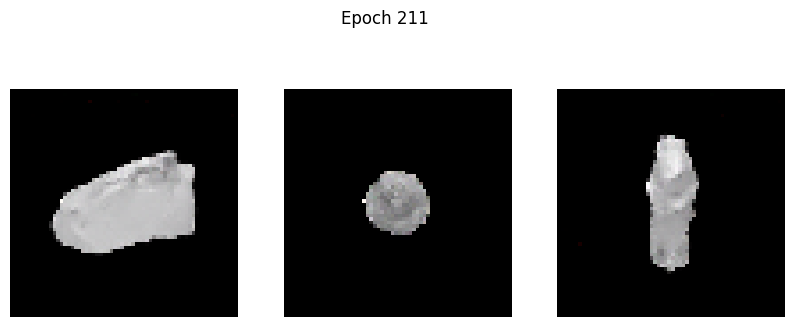

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - d_loss: 0.1092 - g_loss: 3.5961
Epoch 212/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1089 - g_loss: 3.6440

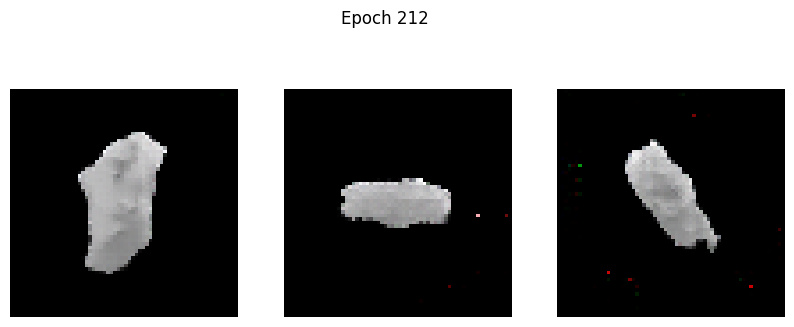

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1104 - g_loss: 3.6474
Epoch 213/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 1.0265 - g_loss: 6.8142

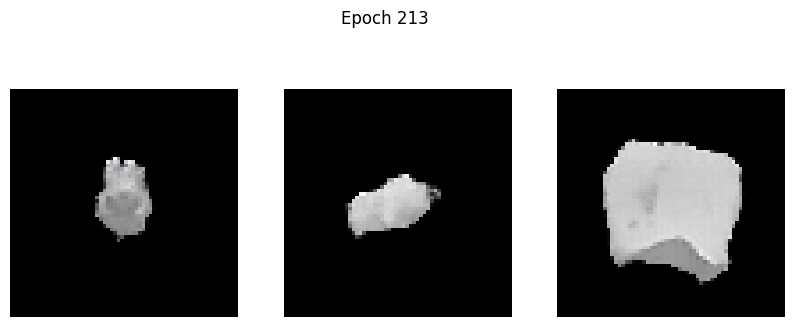

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 1.0203 - g_loss: 6.7926
Epoch 214/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.1027 - g_loss: 3.3586

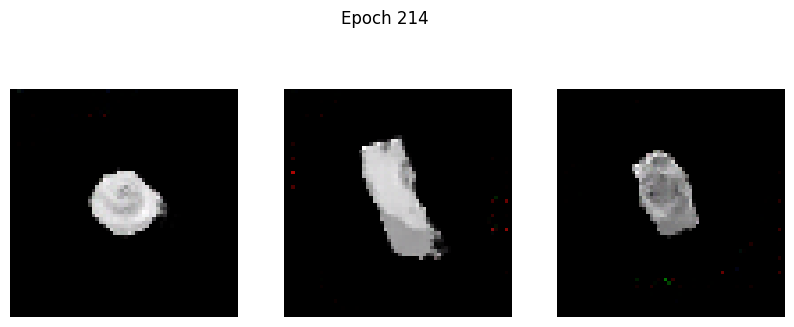

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.1027 - g_loss: 3.3585
Epoch 215/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0958 - g_loss: 3.4517

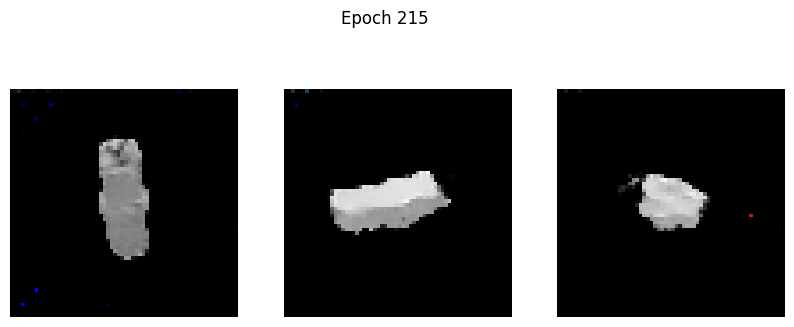

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0959 - g_loss: 3.4519
Epoch 216/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - d_loss: 0.0901 - g_loss: 3.5068

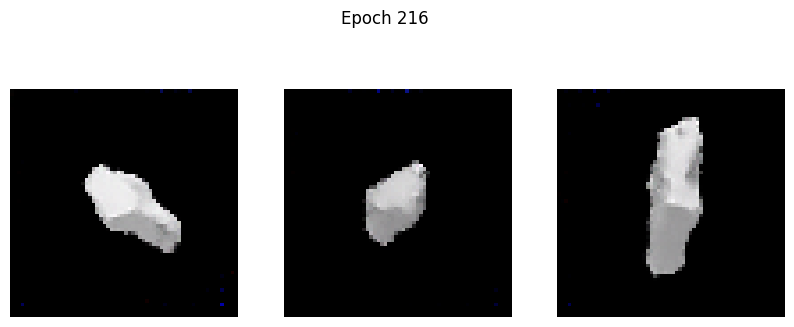

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - d_loss: 0.0901 - g_loss: 3.5065
Epoch 217/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1355 - g_loss: 3.5383

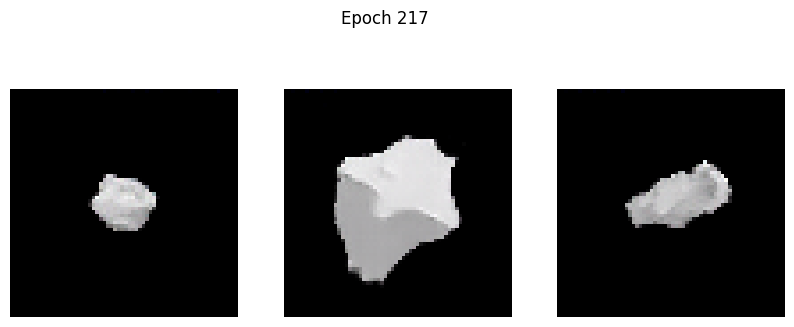

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.1353 - g_loss: 3.5386
Epoch 218/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0956 - g_loss: 3.4444

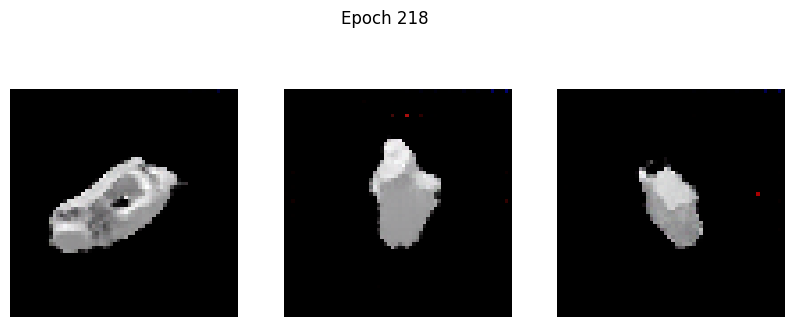

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0955 - g_loss: 3.4448
Epoch 219/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1122 - g_loss: 3.7454

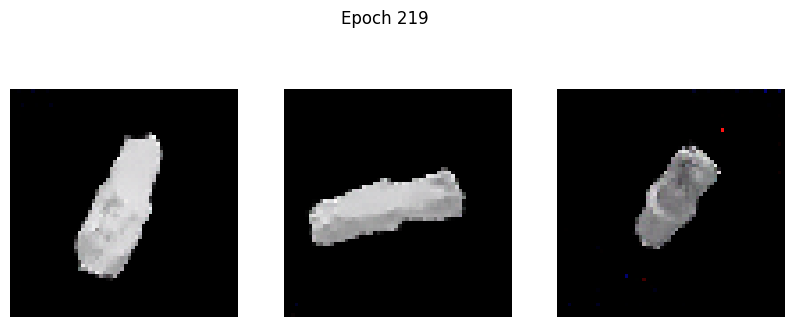

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1124 - g_loss: 3.7448
Epoch 220/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0780 - g_loss: 3.5833

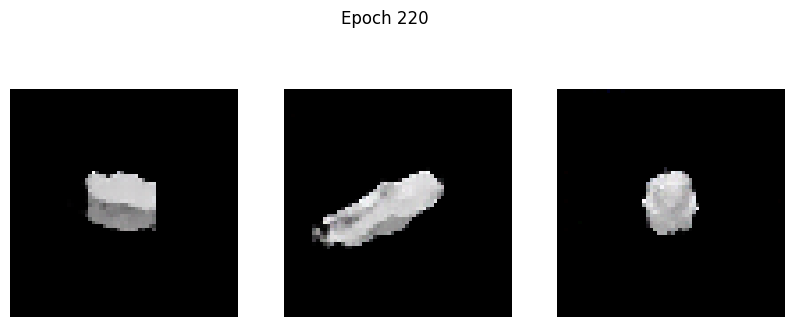

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0780 - g_loss: 3.5834
Epoch 221/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1340 - g_loss: 3.8068

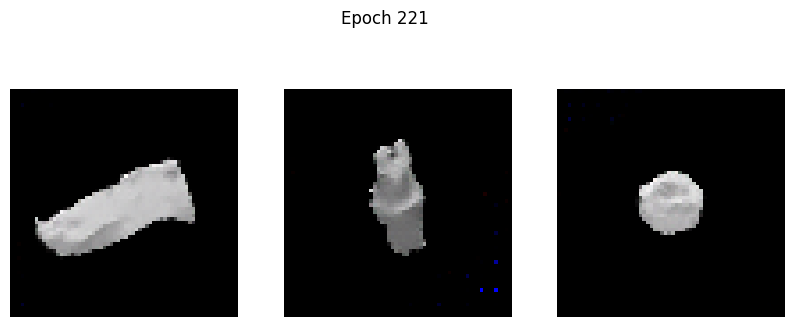

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1343 - g_loss: 3.8069
Epoch 222/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1346 - g_loss: 3.7852

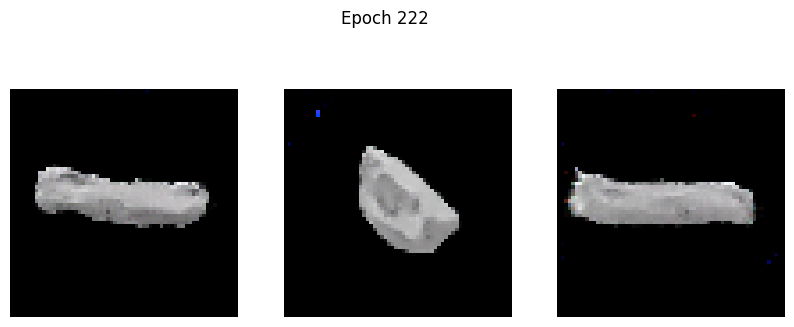

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1343 - g_loss: 3.7843
Epoch 223/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.2998 - g_loss: 3.9176

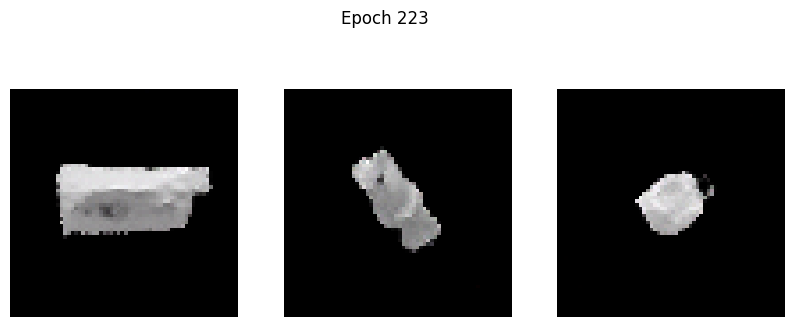

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2992 - g_loss: 3.9161
Epoch 224/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0699 - g_loss: 3.5456

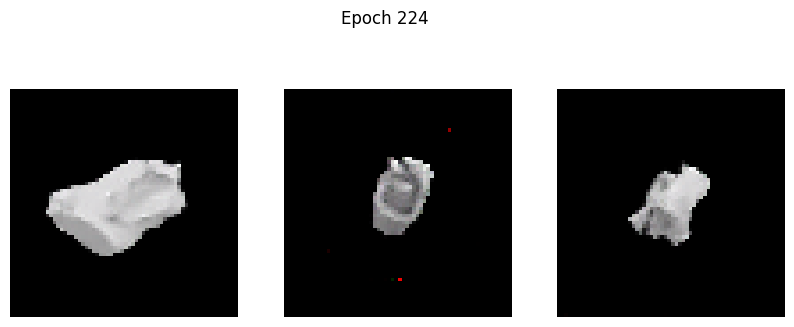

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0699 - g_loss: 3.5460
Epoch 225/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0839 - g_loss: 3.6905

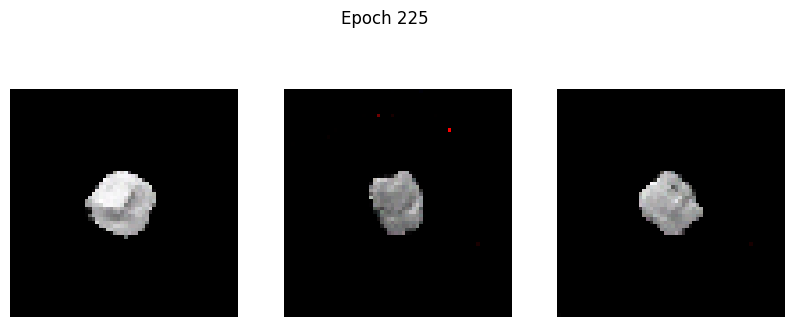

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0839 - g_loss: 3.6905
Epoch 226/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0621 - g_loss: 3.6415

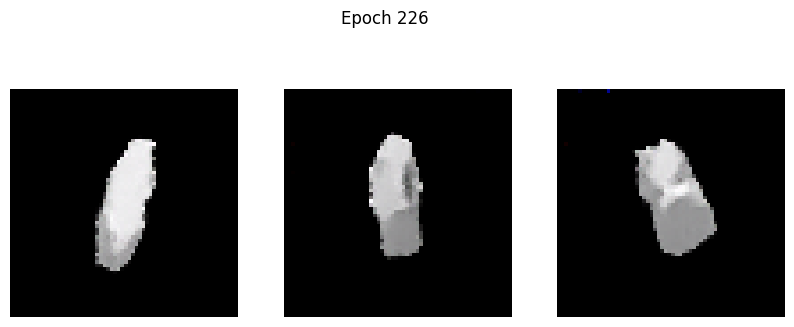

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0622 - g_loss: 3.6420
Epoch 227/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1715 - g_loss: 3.7931

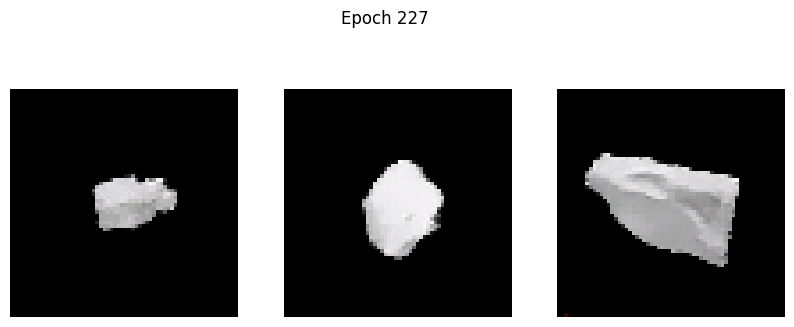

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1722 - g_loss: 3.7934
Epoch 228/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1059 - g_loss: 3.7352

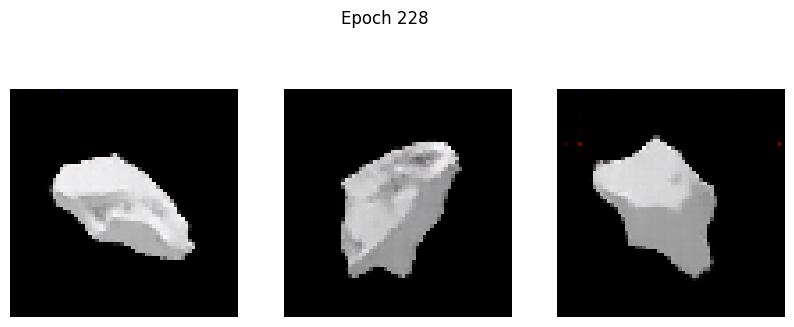

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1061 - g_loss: 3.7349
Epoch 229/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0864 - g_loss: 3.6324

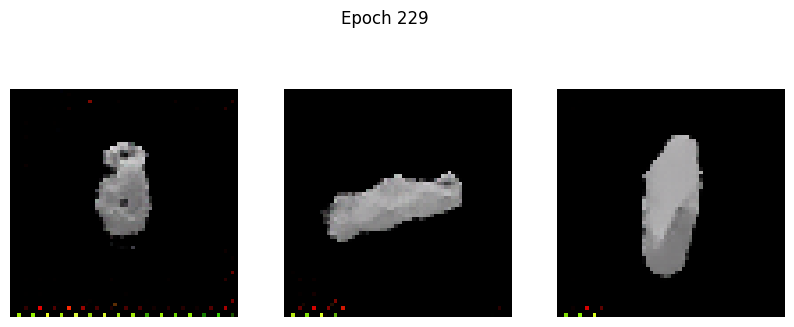

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0865 - g_loss: 3.6330
Epoch 230/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0995 - g_loss: 3.6541

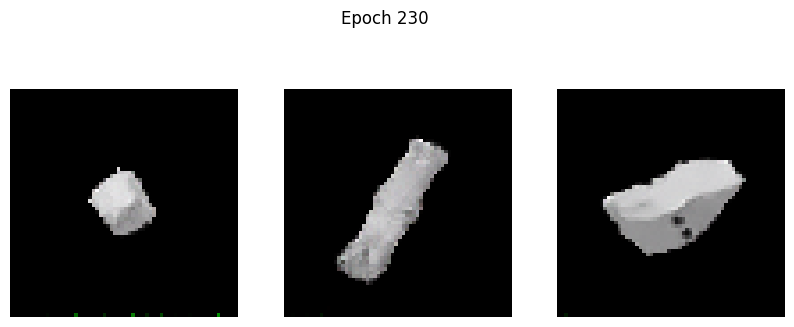

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0994 - g_loss: 3.6539
Epoch 231/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0899 - g_loss: 3.7234

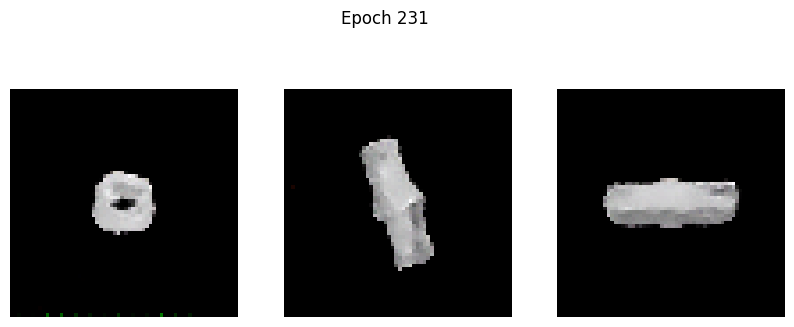

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0899 - g_loss: 3.7237
Epoch 232/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1241 - g_loss: 3.7530

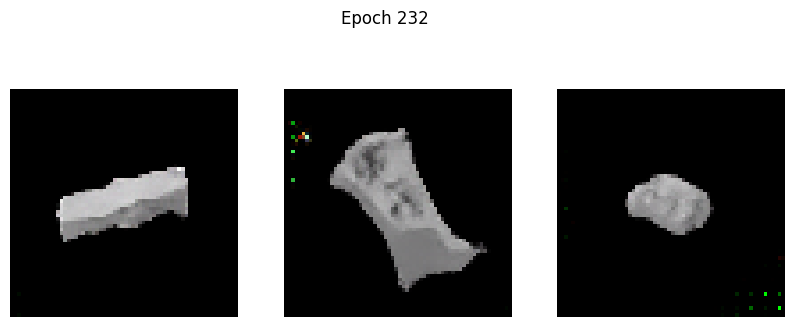

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1246 - g_loss: 3.7542
Epoch 233/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1172 - g_loss: 3.6780

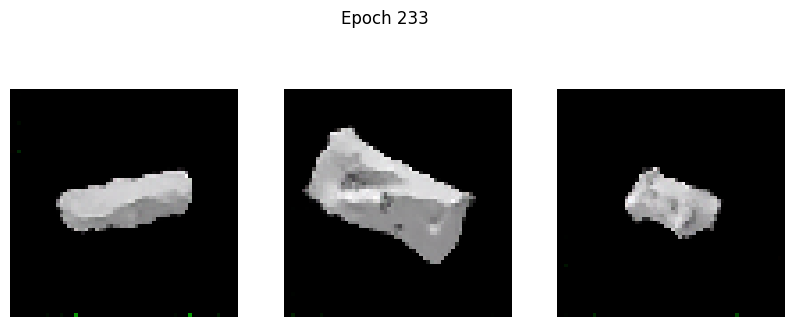

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1172 - g_loss: 3.6782
Epoch 234/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1738 - g_loss: 3.8333

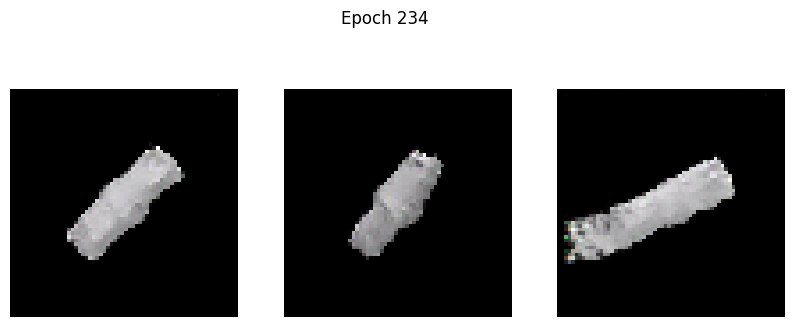

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1735 - g_loss: 3.8329
Epoch 235/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1011 - g_loss: 3.6960

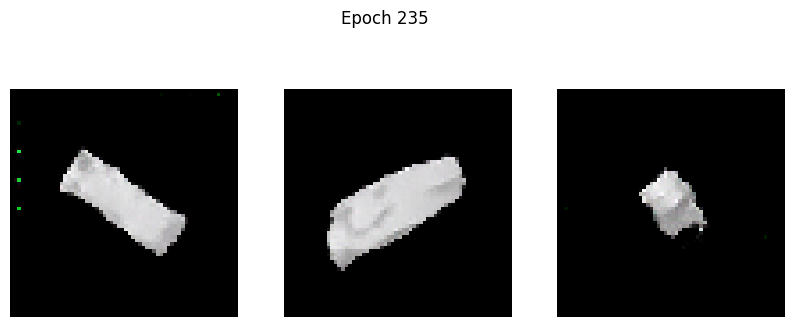

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1013 - g_loss: 3.6966
Epoch 236/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0821 - g_loss: 3.6601

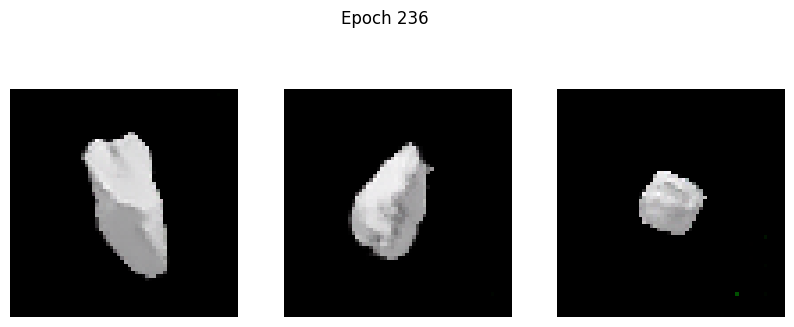

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0821 - g_loss: 3.6609
Epoch 237/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0658 - g_loss: 3.8600

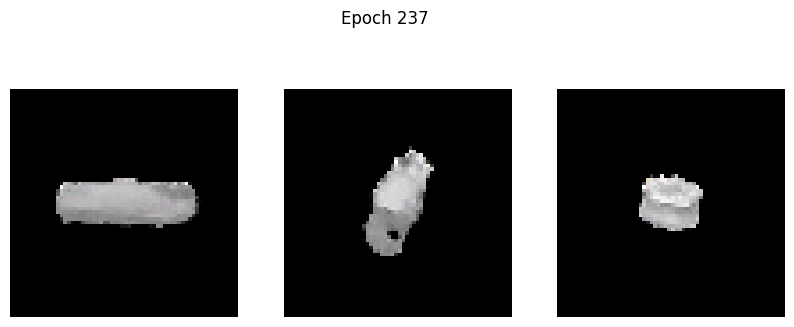

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0659 - g_loss: 3.8589
Epoch 238/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1871 - g_loss: 4.0167

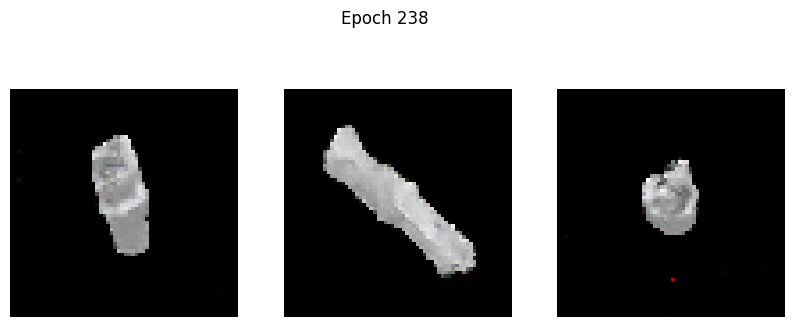

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1871 - g_loss: 4.0166
Epoch 239/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3259 - g_loss: 3.7765

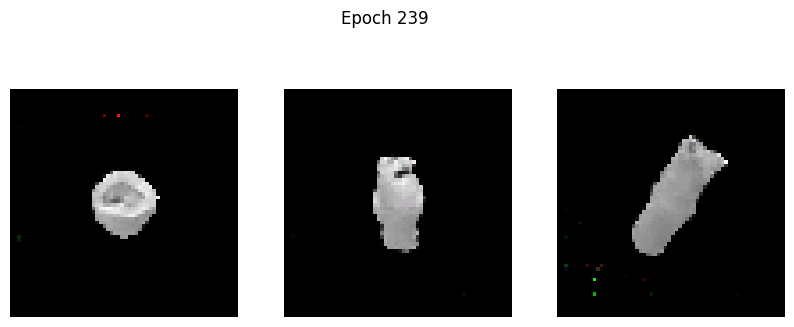

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3246 - g_loss: 3.7767
Epoch 240/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0701 - g_loss: 3.7545

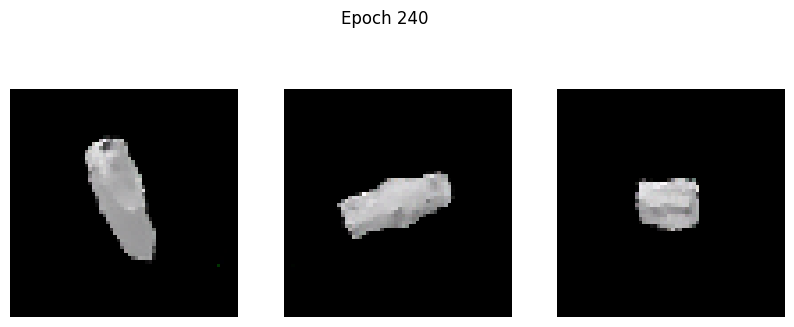

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0702 - g_loss: 3.7544
Epoch 241/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0783 - g_loss: 3.7075

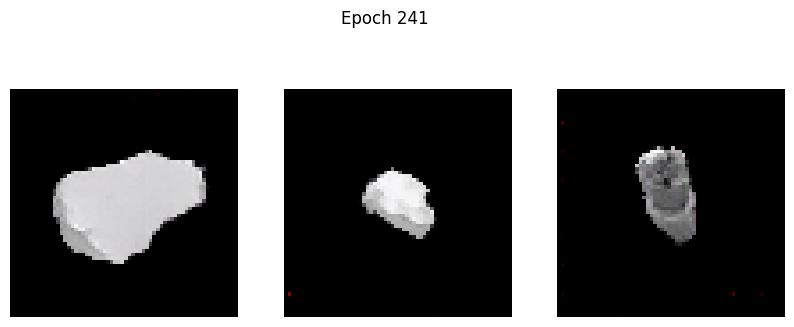

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0791 - g_loss: 3.7091
Epoch 242/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0894 - g_loss: 3.7150

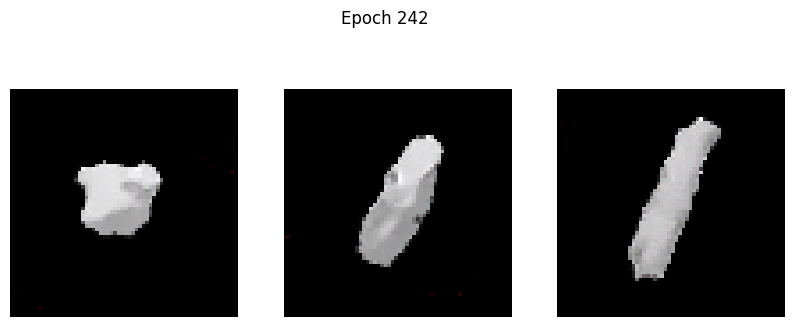

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0894 - g_loss: 3.7155
Epoch 243/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0683 - g_loss: 3.7129

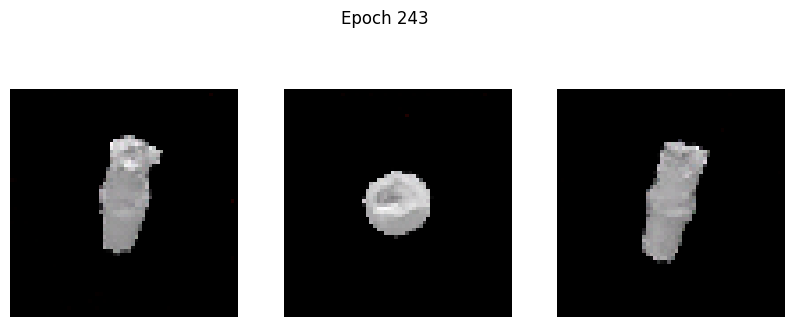

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0686 - g_loss: 3.7141
Epoch 244/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.4707 - g_loss: 4.3758

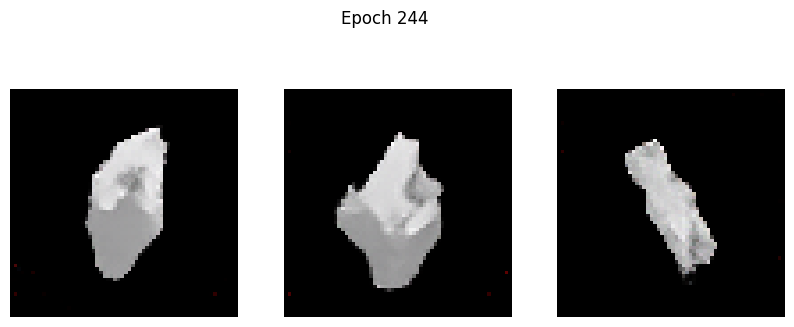

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.4682 - g_loss: 4.3709
Epoch 245/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0617 - g_loss: 3.7755

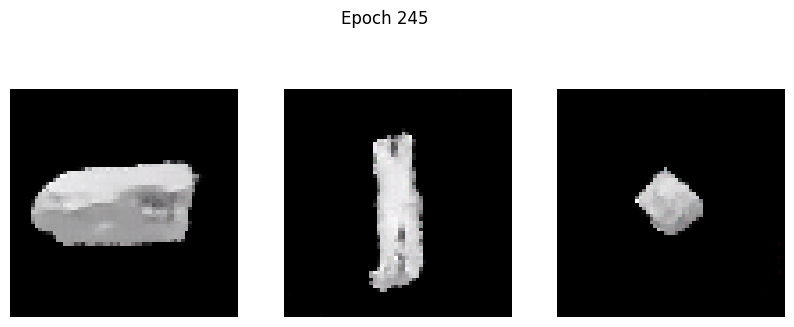

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0617 - g_loss: 3.7753
Epoch 246/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0667 - g_loss: 3.7072

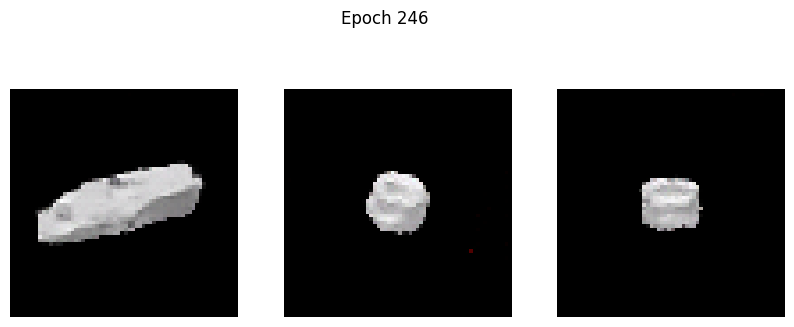

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0667 - g_loss: 3.7076
Epoch 247/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1355 - g_loss: 3.9033

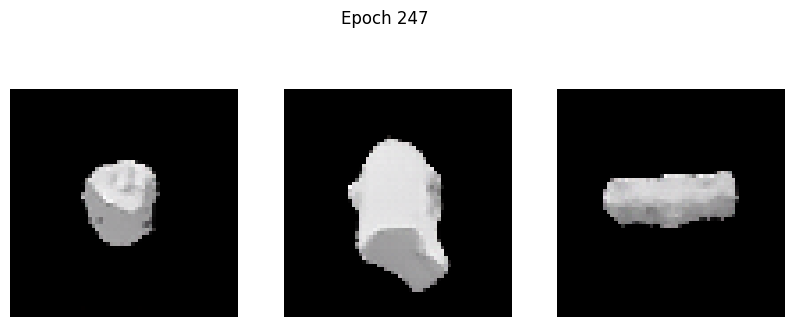

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1358 - g_loss: 3.9039
Epoch 248/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0695 - g_loss: 3.7882

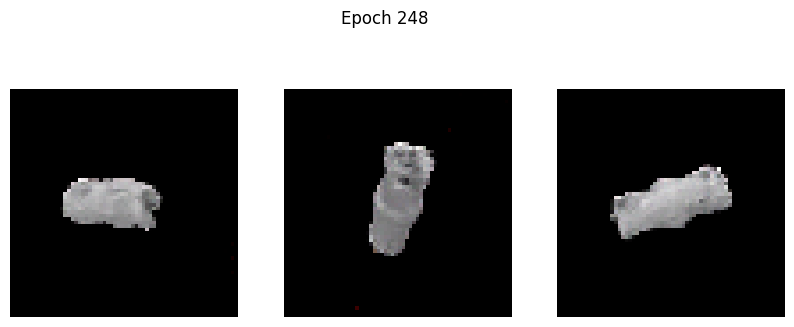

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0695 - g_loss: 3.7880
Epoch 249/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0778 - g_loss: 3.9628

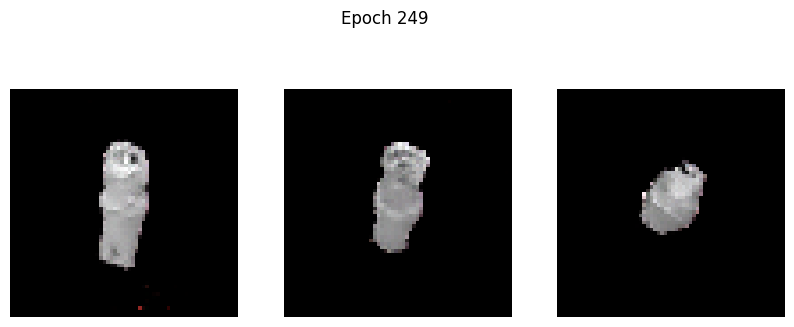

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0783 - g_loss: 3.9633
Epoch 250/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1117 - g_loss: 3.9449

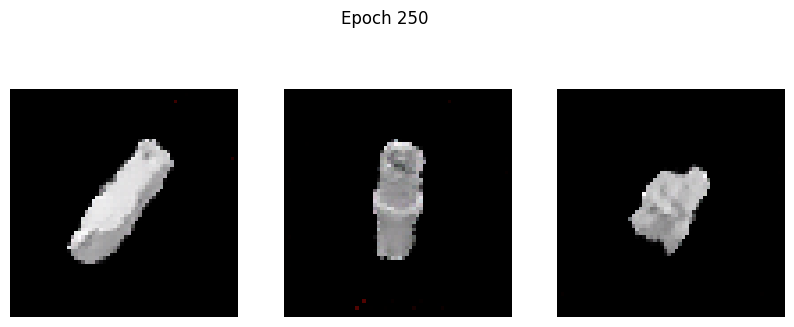

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1116 - g_loss: 3.9442
Epoch 251/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0928 - g_loss: 3.8806

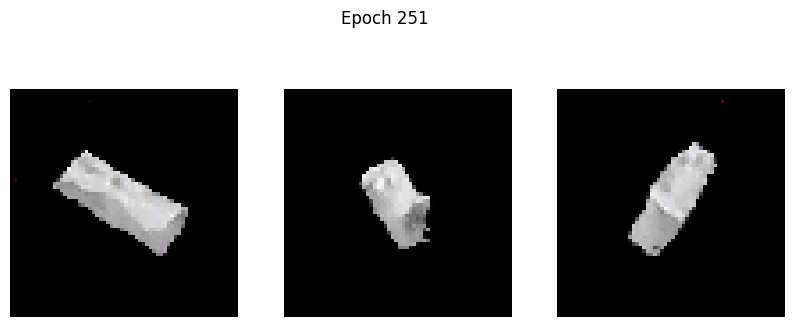

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0928 - g_loss: 3.8806
Epoch 252/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0886 - g_loss: 3.8882

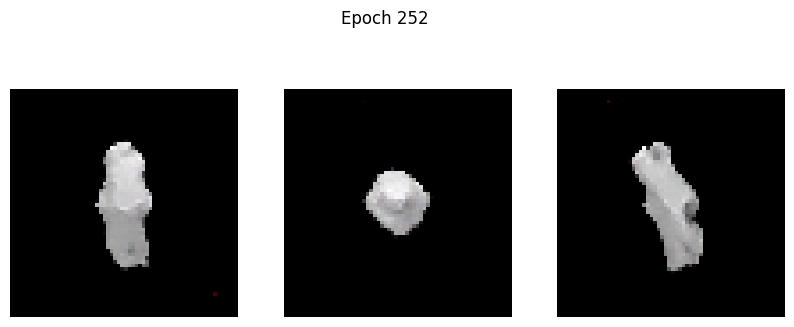

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0888 - g_loss: 3.8886
Epoch 253/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0830 - g_loss: 3.9050

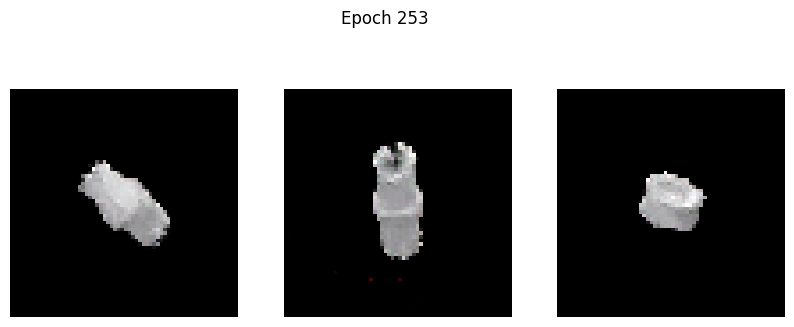

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0830 - g_loss: 3.9053
Epoch 254/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0747 - g_loss: 3.9353

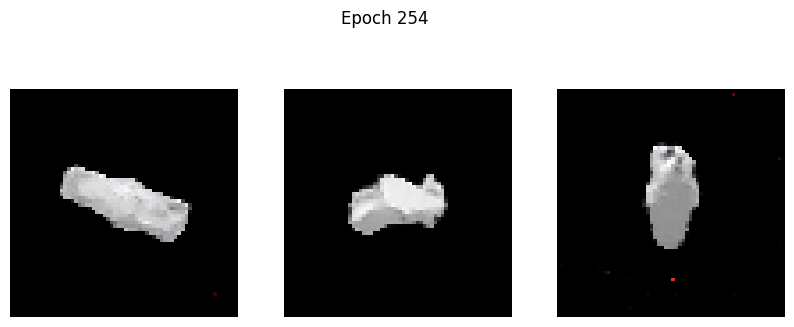

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - d_loss: 0.0747 - g_loss: 3.9358
Epoch 255/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1267 - g_loss: 4.1469

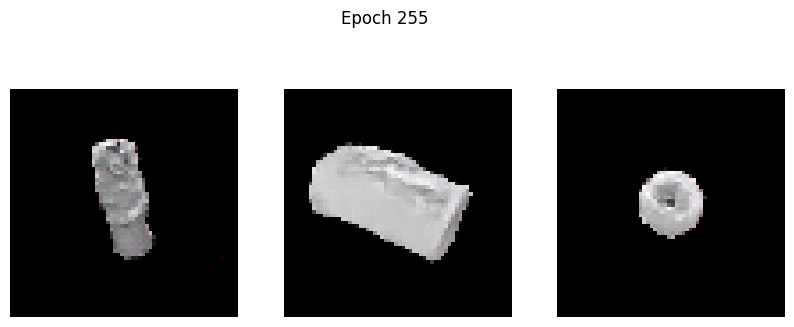

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1280 - g_loss: 4.1488
Epoch 256/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1238 - g_loss: 3.6858

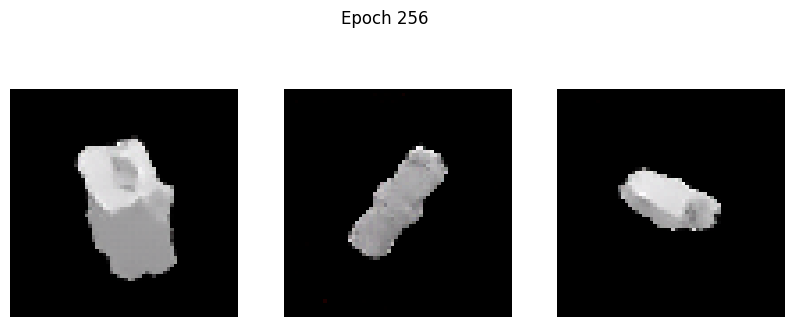

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1233 - g_loss: 3.6870
Epoch 257/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0556 - g_loss: 3.8583

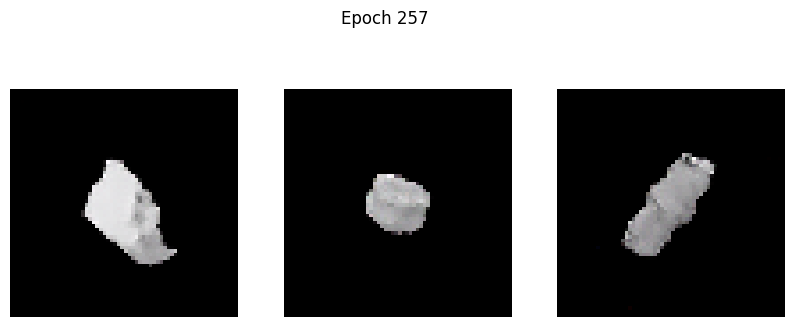

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0557 - g_loss: 3.8588
Epoch 258/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1266 - g_loss: 4.0703

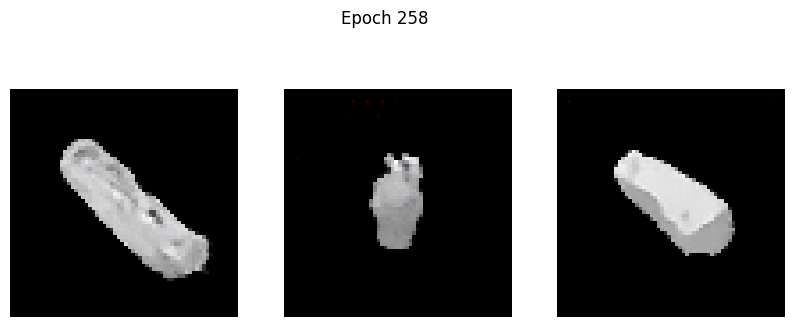

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1264 - g_loss: 4.0694
Epoch 259/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0605 - g_loss: 3.9771

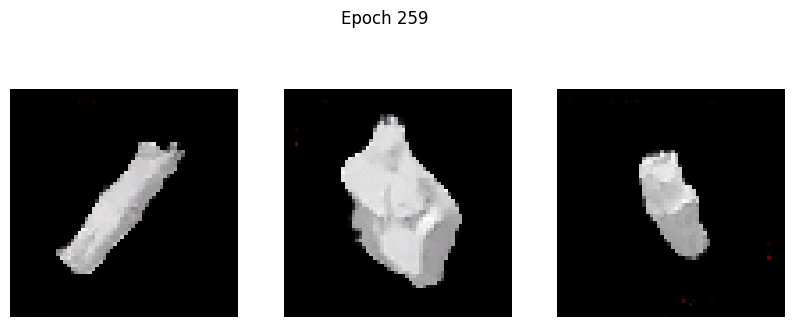

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0606 - g_loss: 3.9770
Epoch 260/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0590 - g_loss: 3.9670

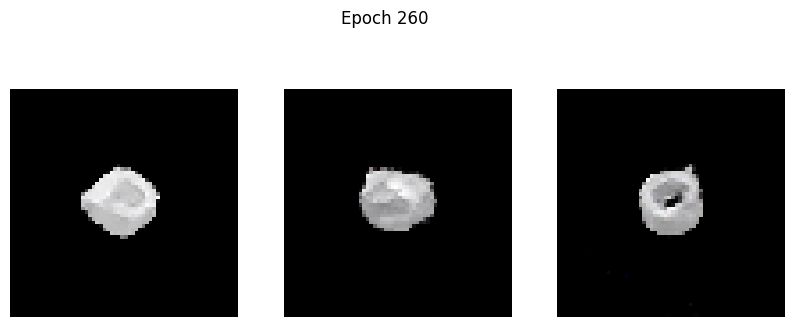

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0591 - g_loss: 3.9673
Epoch 261/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0529 - g_loss: 4.0685

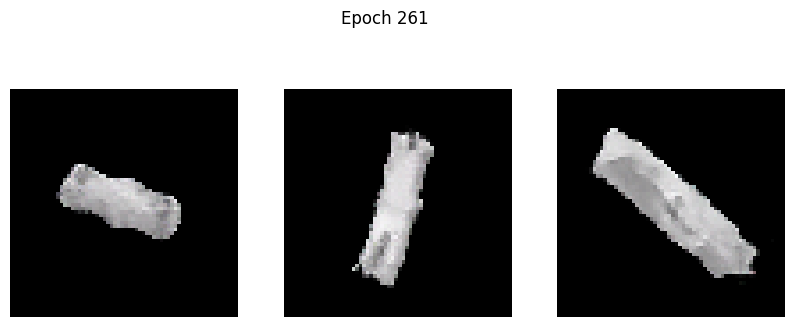

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0529 - g_loss: 4.0683
Epoch 262/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.4217 - g_loss: 4.5827

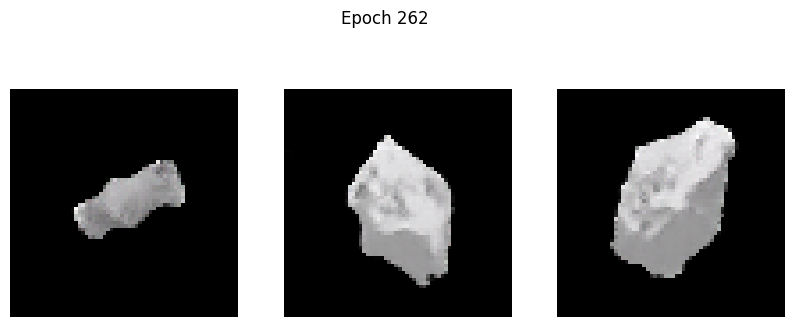

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.4226 - g_loss: 4.5811
Epoch 263/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0931 - g_loss: 3.7653

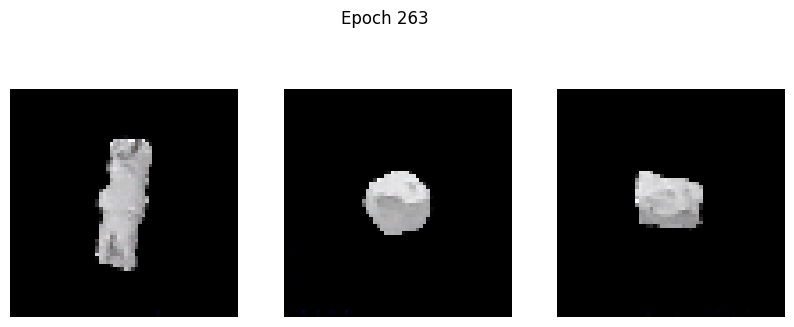

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0931 - g_loss: 3.7649
Epoch 264/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0805 - g_loss: 3.9211

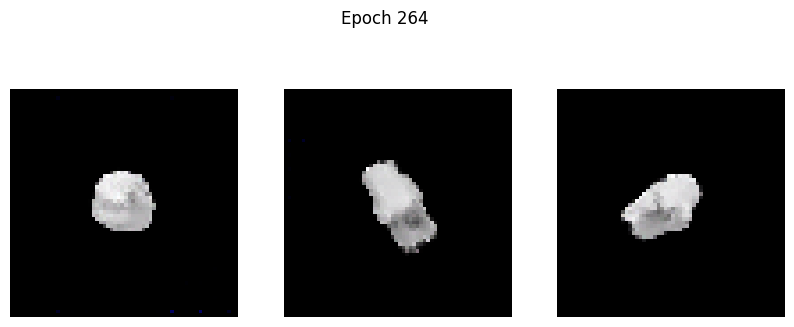

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0804 - g_loss: 3.9209
Epoch 265/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0581 - g_loss: 3.9639

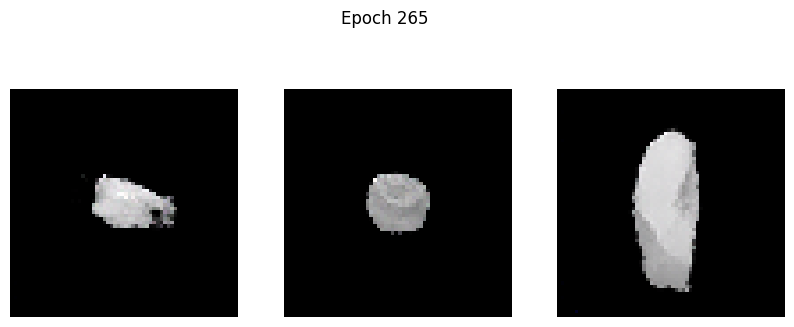

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0581 - g_loss: 3.9636
Epoch 266/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0678 - g_loss: 3.9428

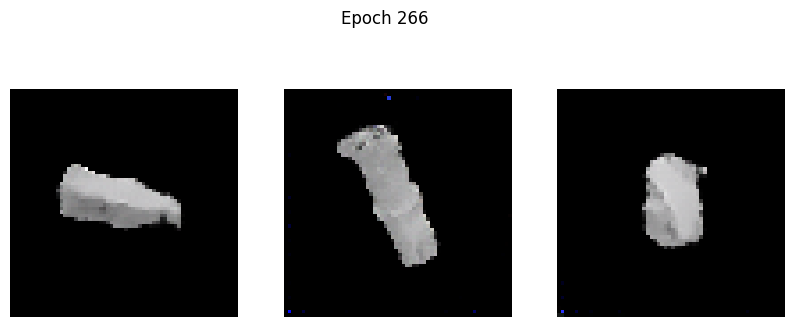

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0678 - g_loss: 3.9427
Epoch 267/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0623 - g_loss: 4.0244

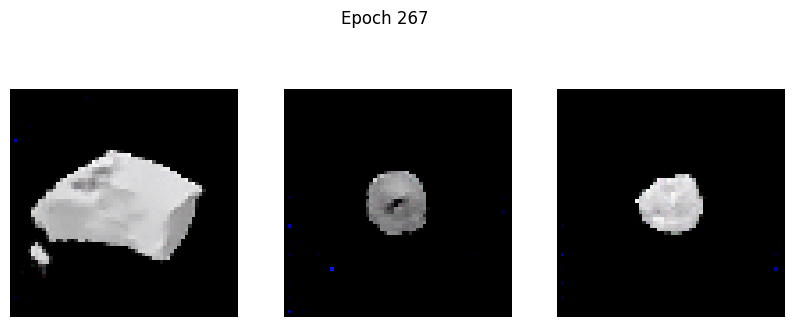

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0628 - g_loss: 4.0256
Epoch 268/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0668 - g_loss: 3.9780

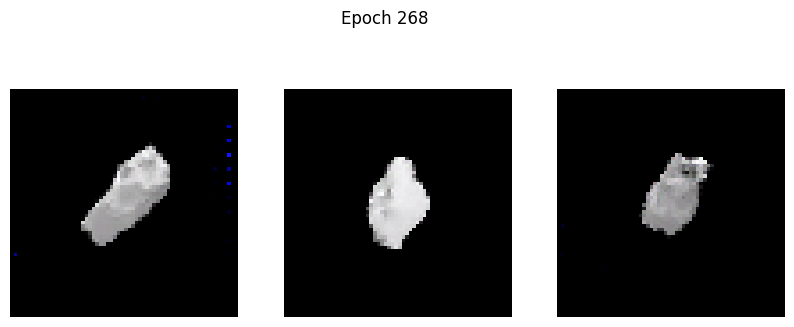

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.0667 - g_loss: 3.9783
Epoch 269/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0974 - g_loss: 4.2150

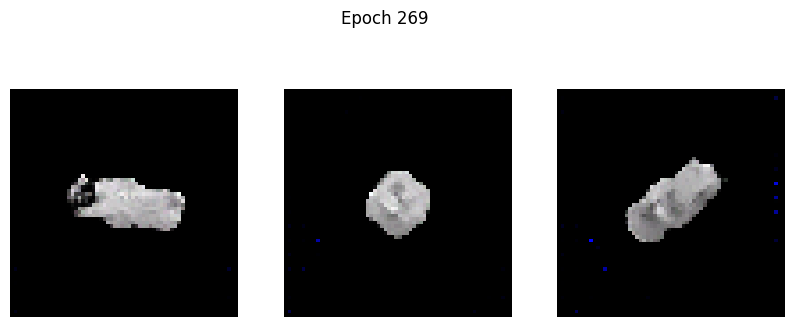

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.0976 - g_loss: 4.2147
Epoch 270/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0633 - g_loss: 4.0036

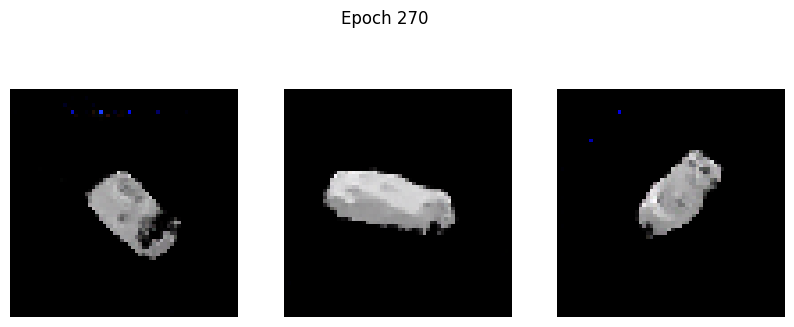

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0633 - g_loss: 4.0038
Epoch 271/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1293 - g_loss: 4.2423

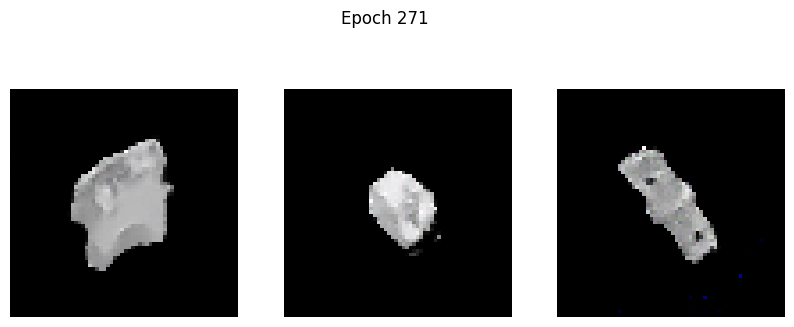

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.1291 - g_loss: 4.2414
Epoch 272/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0801 - g_loss: 4.3180

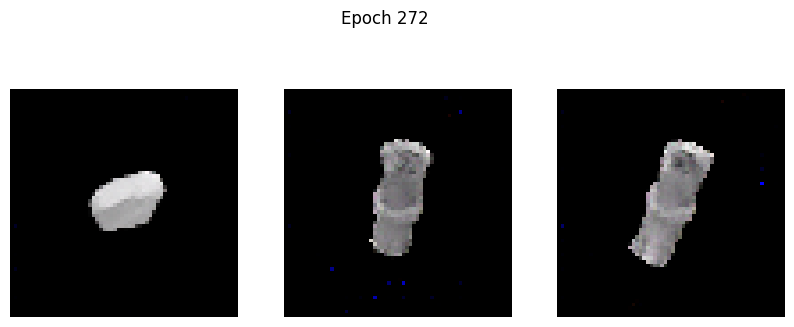

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.0800 - g_loss: 4.3166
Epoch 273/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0772 - g_loss: 4.1312

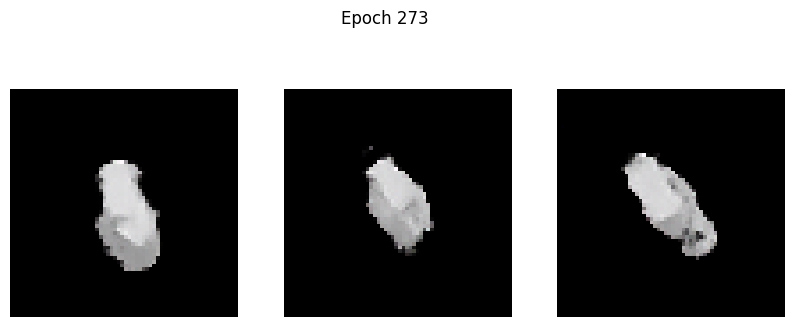

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0783 - g_loss: 4.1333
Epoch 274/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2308 - g_loss: 4.2496

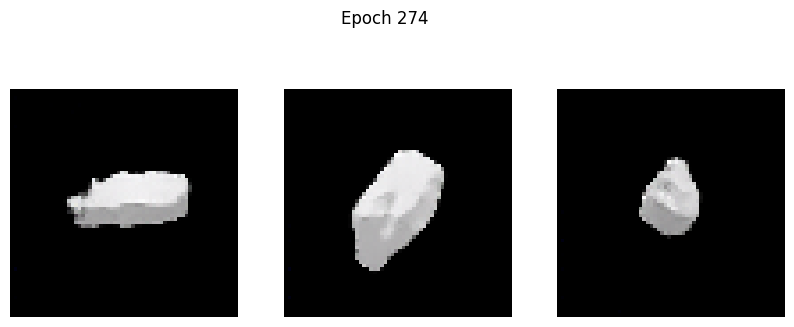

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.2298 - g_loss: 4.2482
Epoch 275/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0632 - g_loss: 4.0063

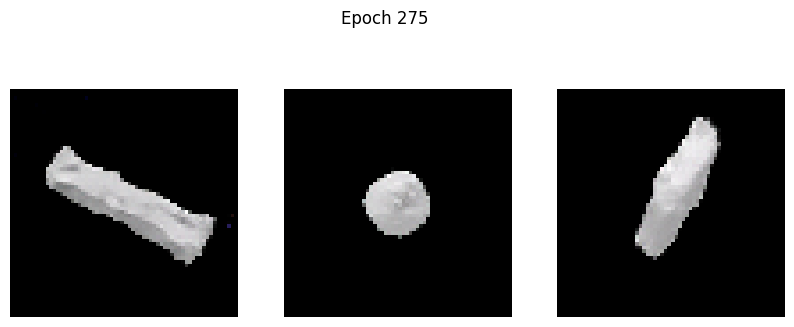

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0634 - g_loss: 4.0068
Epoch 276/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0508 - g_loss: 4.1257

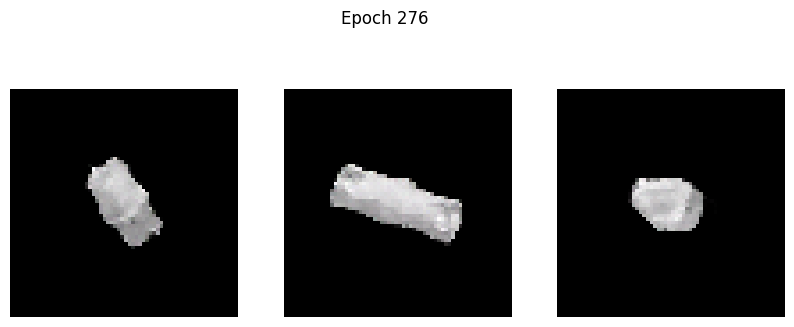

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0508 - g_loss: 4.1254
Epoch 277/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0566 - g_loss: 3.9969

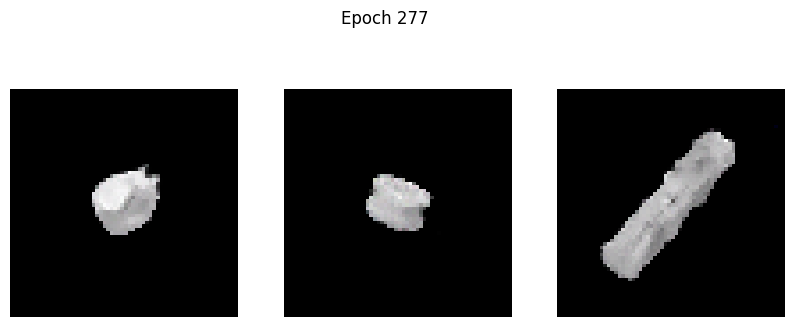

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0566 - g_loss: 3.9976
Epoch 278/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0655 - g_loss: 4.1316

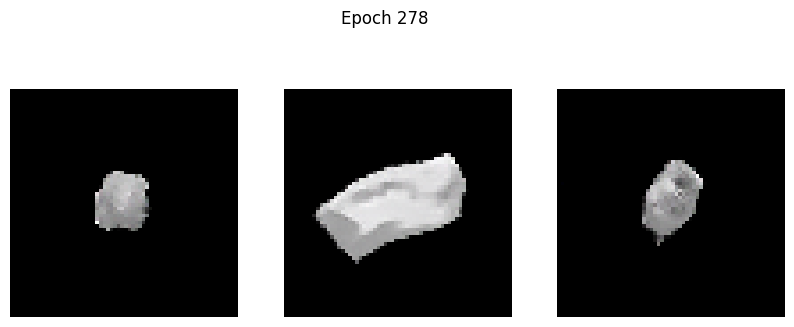

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.0662 - g_loss: 4.1337
Epoch 279/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0853 - g_loss: 4.2146

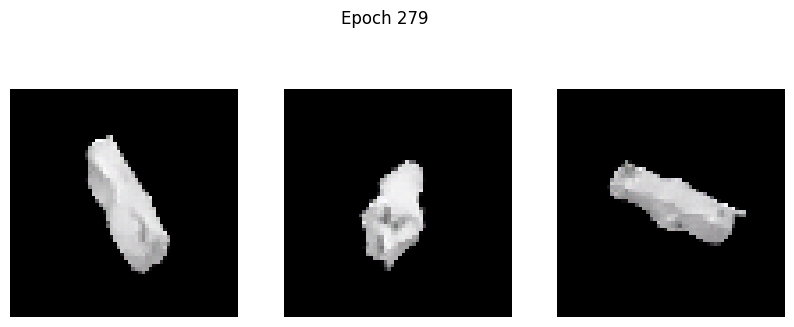

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0854 - g_loss: 4.2144
Epoch 280/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1248 - g_loss: 4.2205

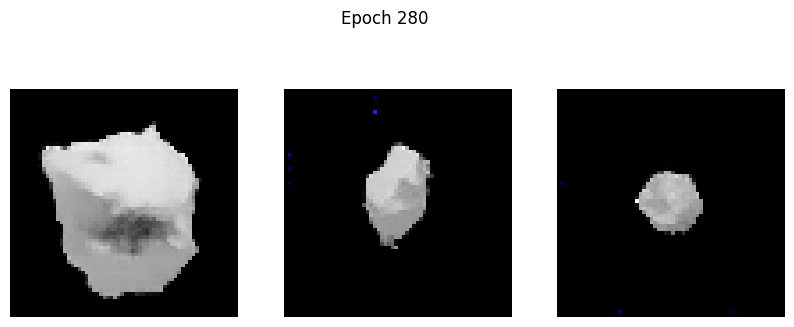

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1245 - g_loss: 4.2200
Epoch 281/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0721 - g_loss: 4.2263

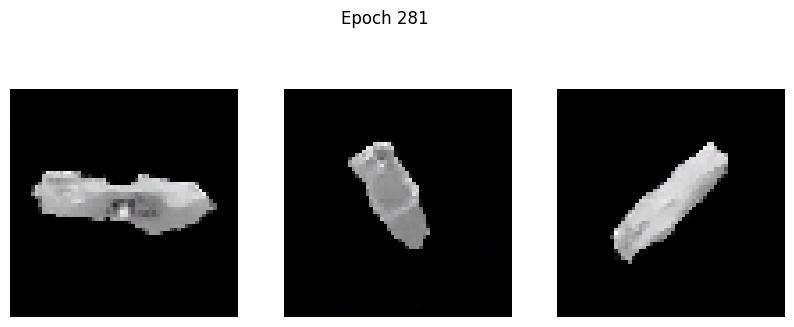

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0722 - g_loss: 4.2265
Epoch 282/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0607 - g_loss: 4.2706

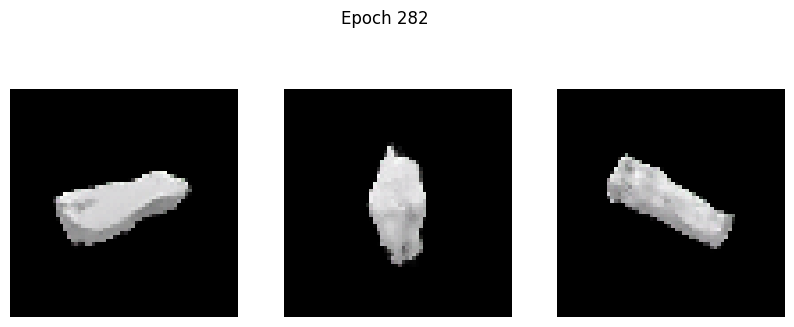

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0608 - g_loss: 4.2700
Epoch 283/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0654 - g_loss: 4.0911

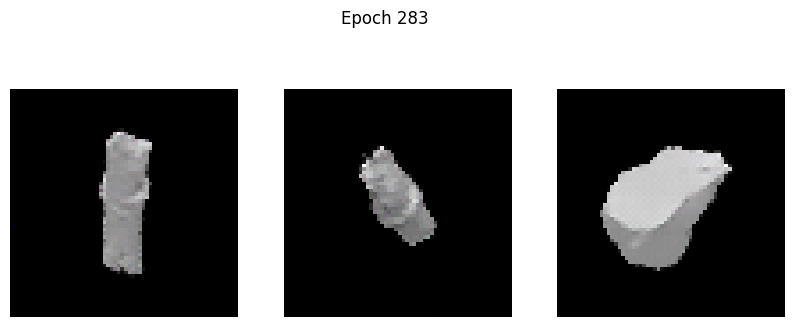

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0656 - g_loss: 4.0924
Epoch 284/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0873 - g_loss: 4.4595

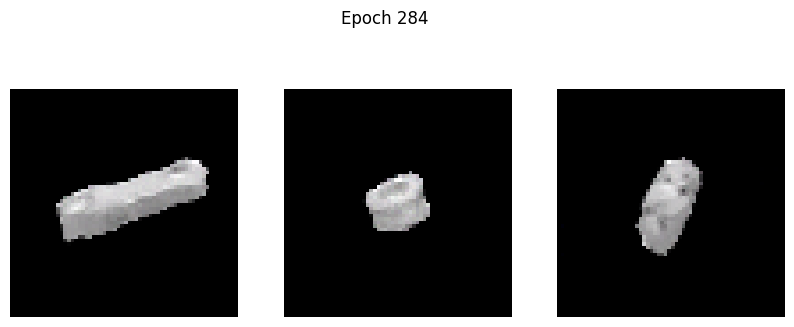

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0871 - g_loss: 4.4576
Epoch 285/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0385 - g_loss: 4.2313

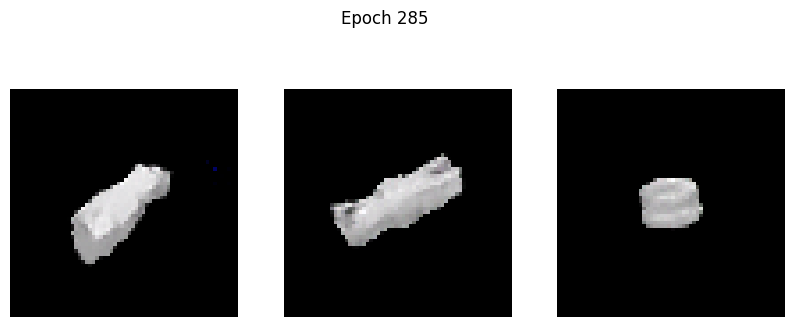

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0387 - g_loss: 4.2320
Epoch 286/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3853 - g_loss: 4.8821

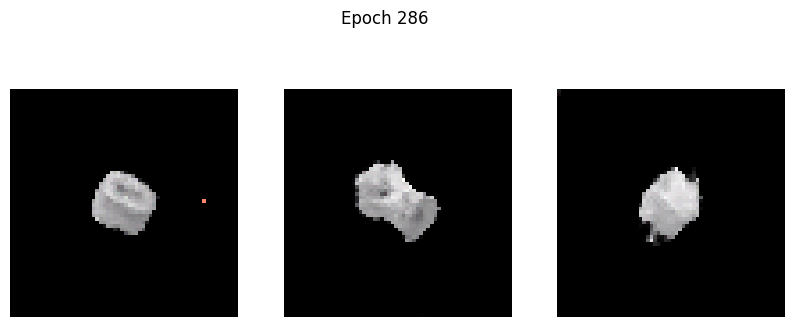

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3866 - g_loss: 4.8828
Epoch 287/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0868 - g_loss: 3.9175

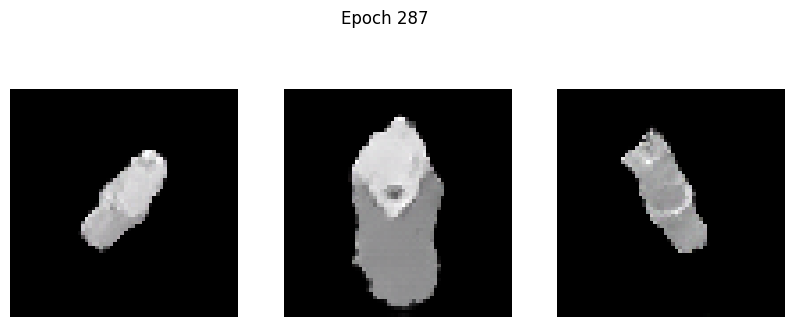

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0866 - g_loss: 3.9174
Epoch 288/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0681 - g_loss: 4.0735

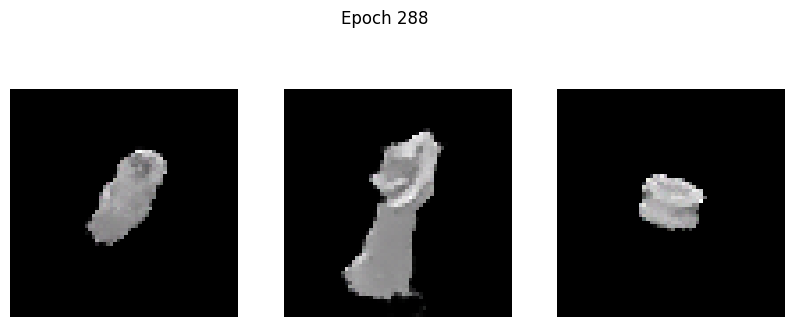

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0683 - g_loss: 4.0737
Epoch 289/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0608 - g_loss: 4.1652

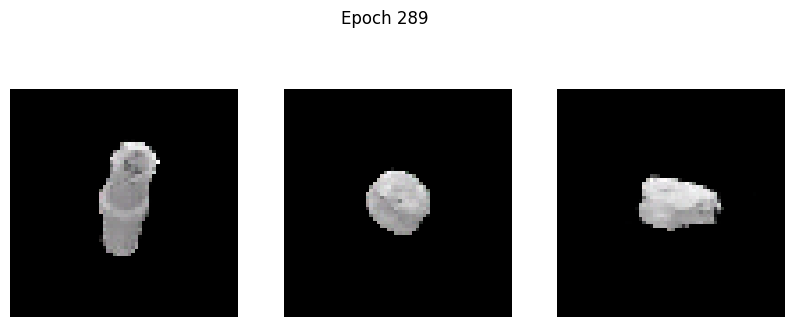

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0607 - g_loss: 4.1645
Epoch 290/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0611 - g_loss: 4.2000

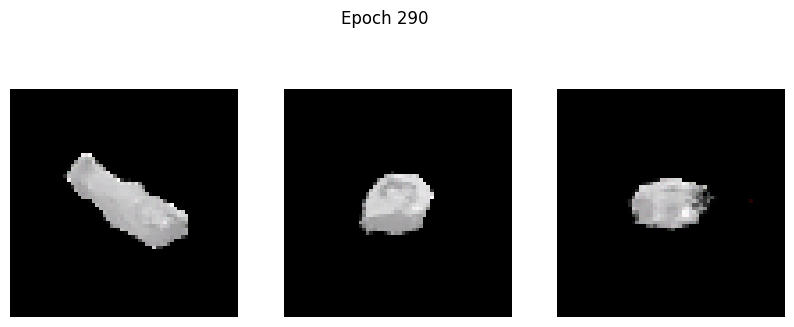

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0611 - g_loss: 4.2001
Epoch 291/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0560 - g_loss: 4.2503

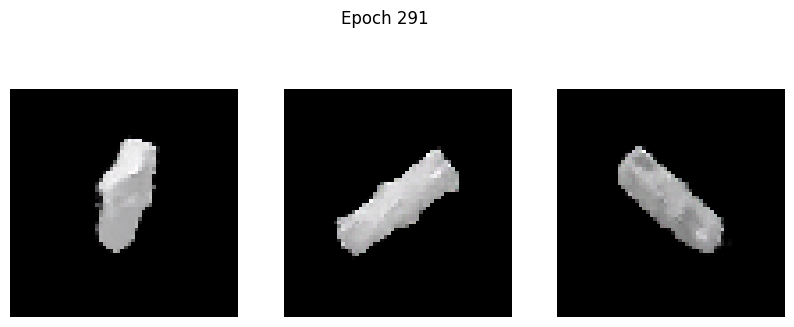

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0560 - g_loss: 4.2501
Epoch 292/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0495 - g_loss: 4.1026

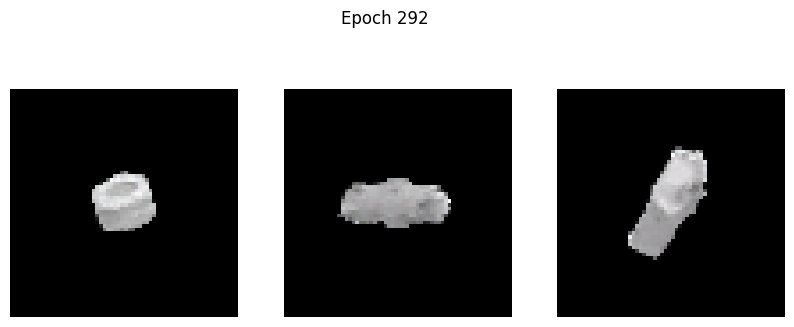

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0496 - g_loss: 4.1025
Epoch 293/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1142 - g_loss: 4.3785

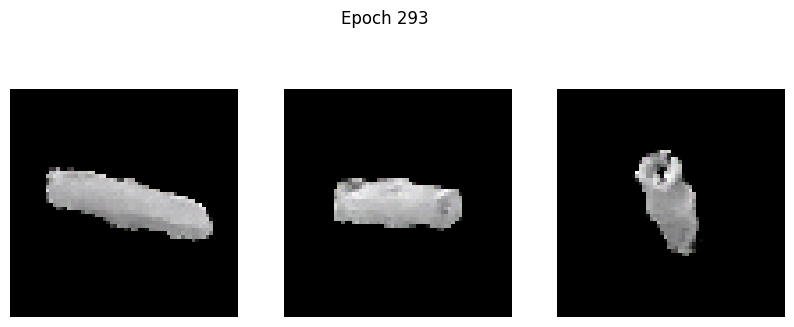

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1139 - g_loss: 4.3771
Epoch 294/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0954 - g_loss: 4.2933

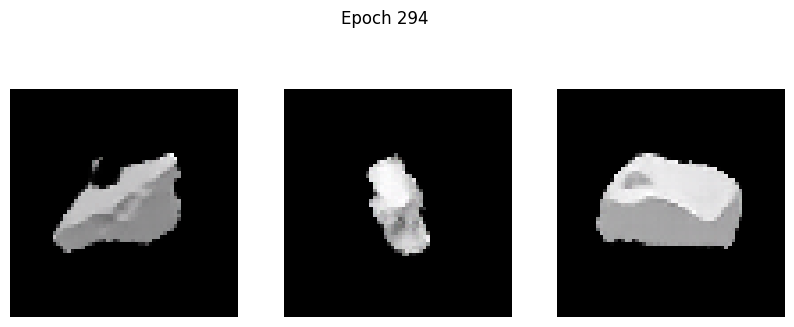

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0952 - g_loss: 4.2927
Epoch 295/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0872 - g_loss: 4.4412

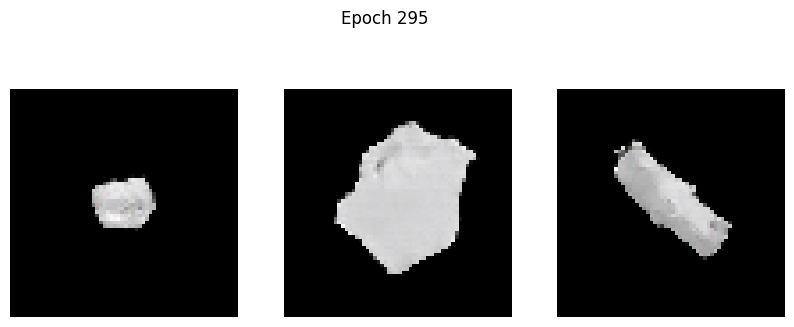

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0870 - g_loss: 4.4398
Epoch 296/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0932 - g_loss: 4.4472

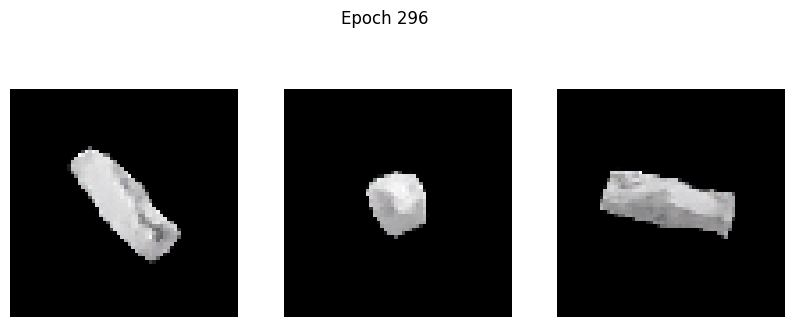

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0931 - g_loss: 4.4462
Epoch 297/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0640 - g_loss: 4.3086

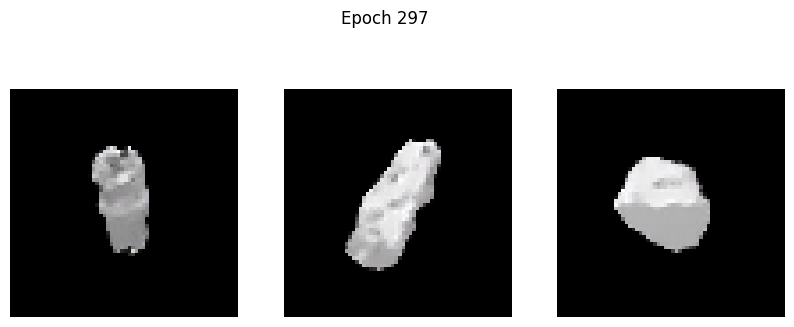

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0641 - g_loss: 4.3088
Epoch 298/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2731 - g_loss: 4.7837

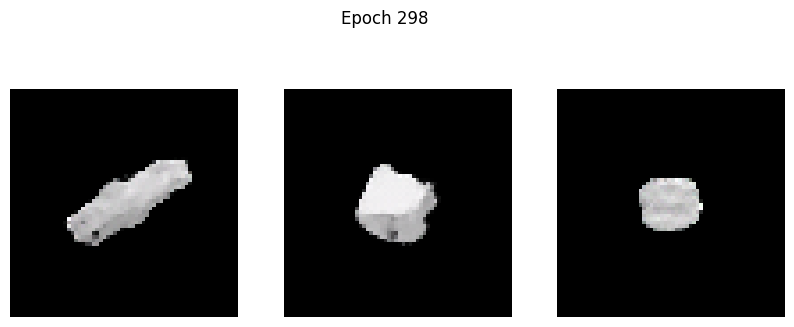

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2719 - g_loss: 4.7801
Epoch 299/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0564 - g_loss: 4.2359

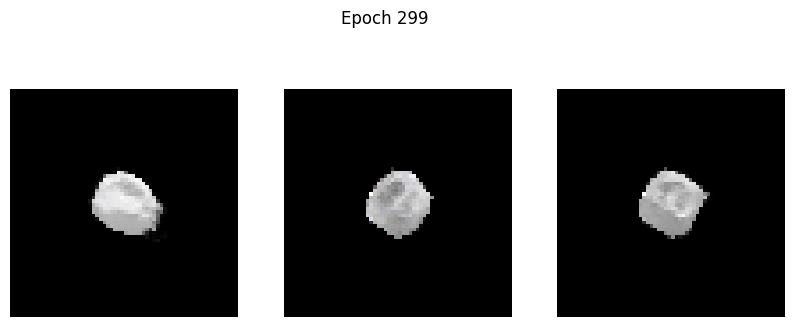

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0564 - g_loss: 4.2361
Epoch 300/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0546 - g_loss: 4.3856

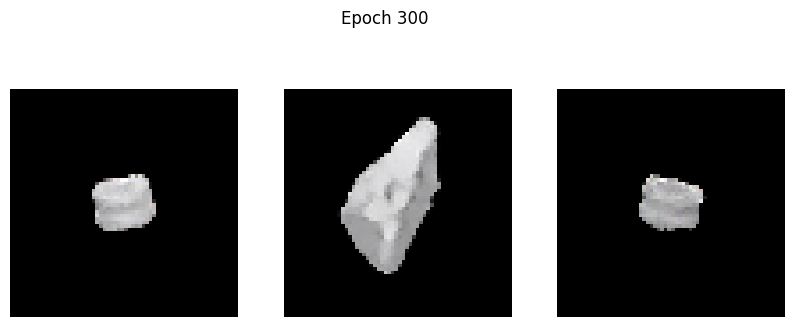

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0545 - g_loss: 4.3863
Epoch 301/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0704 - g_loss: 4.4168

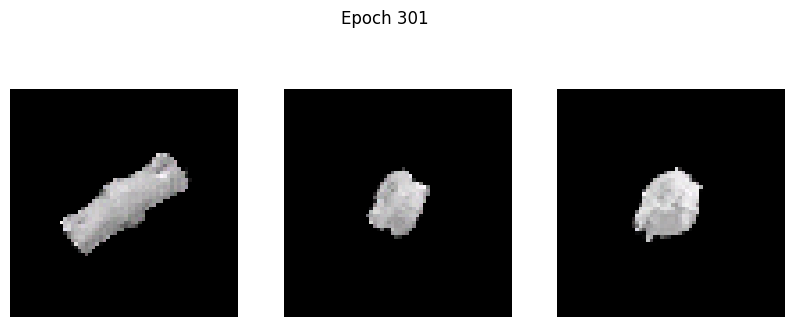

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0705 - g_loss: 4.4168
Epoch 302/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0759 - g_loss: 4.4218

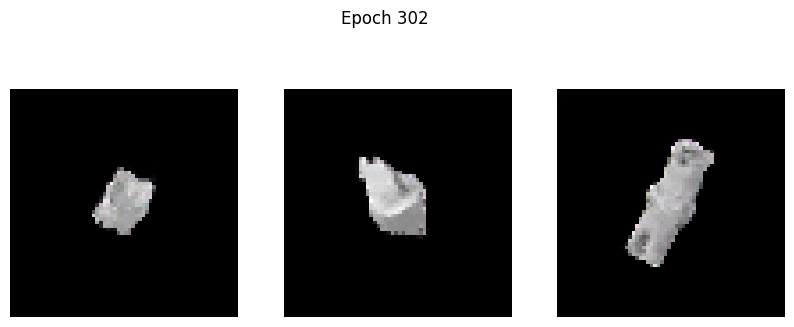

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0768 - g_loss: 4.4241
Epoch 303/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0514 - g_loss: 4.3639

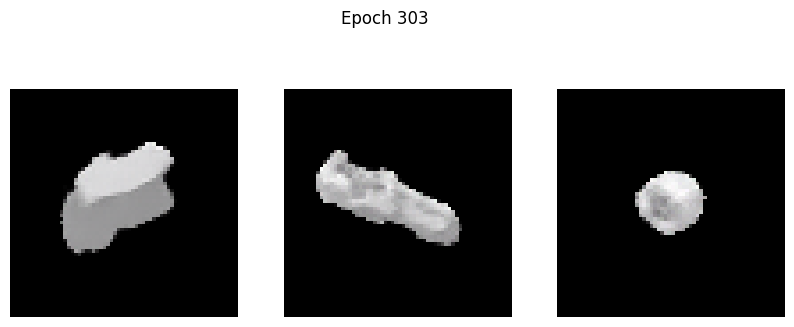

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0514 - g_loss: 4.3630
Epoch 304/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0315 - g_loss: 4.3474

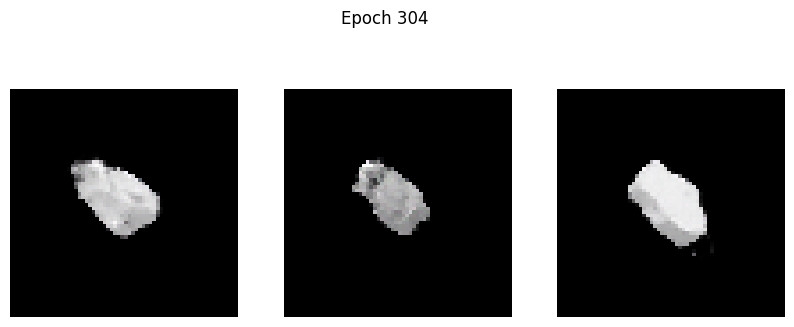

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0316 - g_loss: 4.3472
Epoch 305/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0851 - g_loss: 4.5719

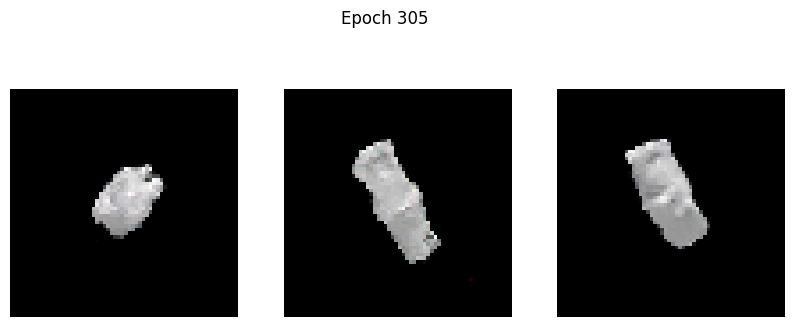

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0854 - g_loss: 4.5731
Epoch 306/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.3698 - g_loss: 5.0800

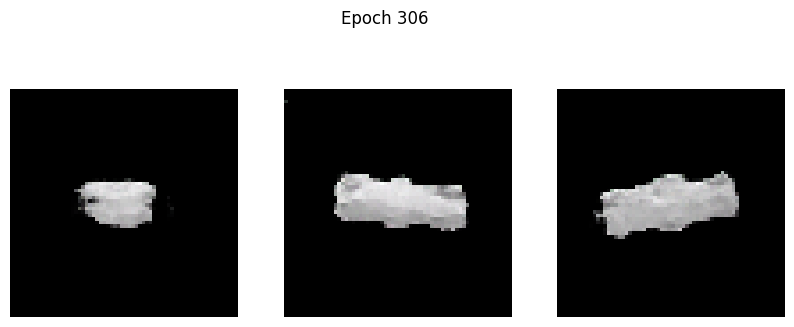

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.3679 - g_loss: 5.0749
Epoch 307/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0608 - g_loss: 4.2886

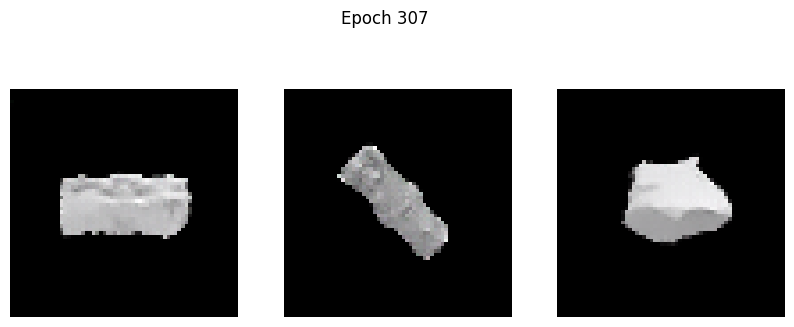

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0609 - g_loss: 4.2892
Epoch 308/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1606 - g_loss: 4.4493

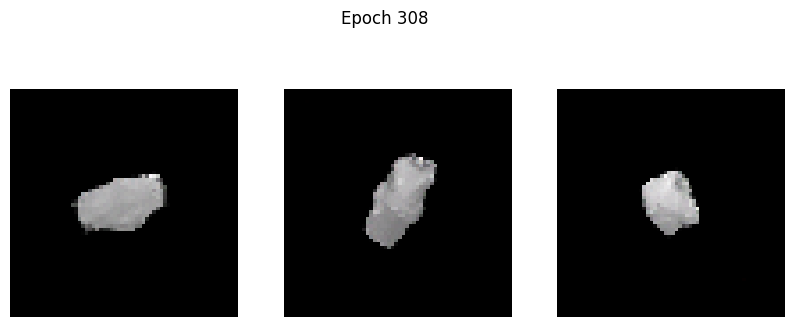

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1605 - g_loss: 4.4493
Epoch 309/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0503 - g_loss: 4.3668

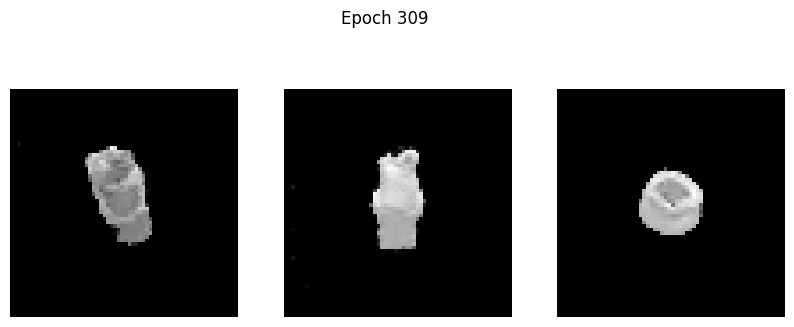

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0502 - g_loss: 4.3656
Epoch 310/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0489 - g_loss: 4.4035

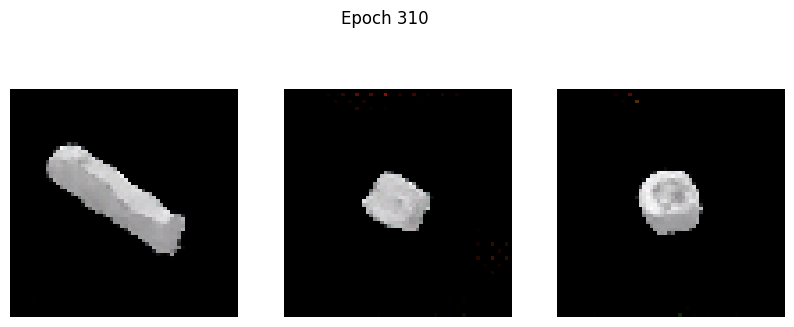

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0490 - g_loss: 4.4033
Epoch 311/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0699 - g_loss: 4.5054

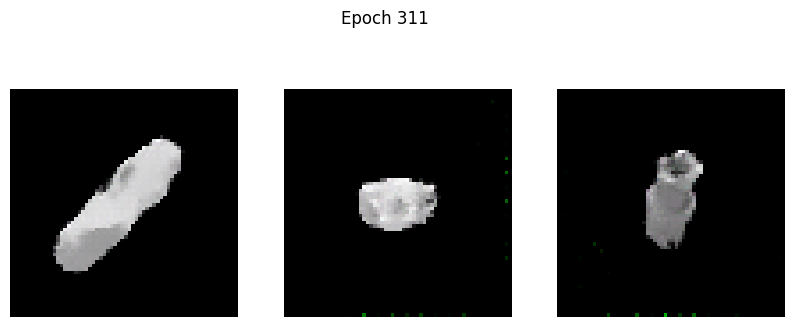

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0698 - g_loss: 4.5047
Epoch 312/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0324 - g_loss: 4.3657

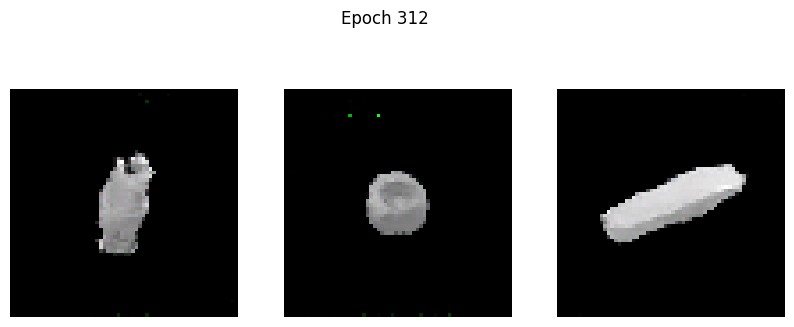

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0324 - g_loss: 4.3657
Epoch 313/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1234 - g_loss: 4.8671

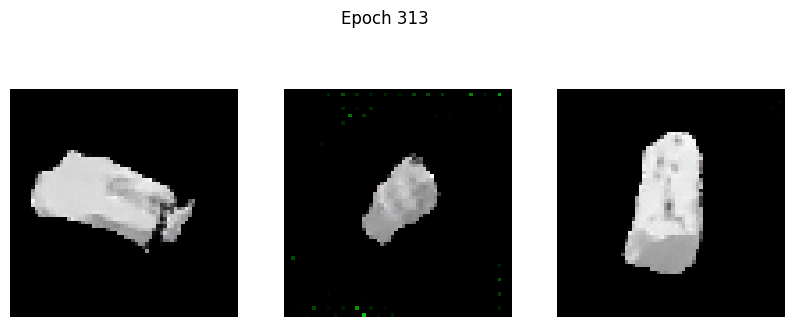

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1231 - g_loss: 4.8643
Epoch 314/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0781 - g_loss: 4.5491

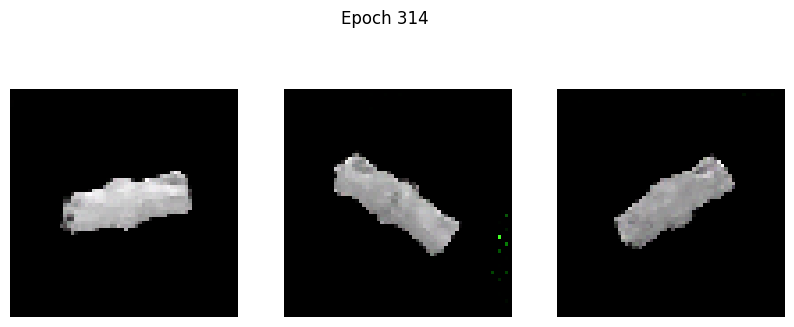

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0781 - g_loss: 4.5485
Epoch 315/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0457 - g_loss: 4.3828

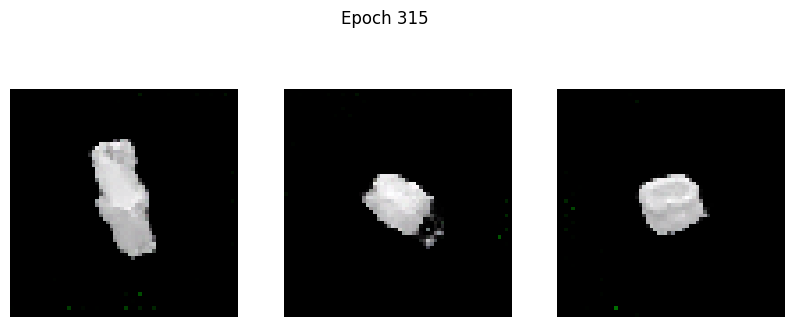

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0459 - g_loss: 4.3842
Epoch 316/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0664 - g_loss: 4.3936

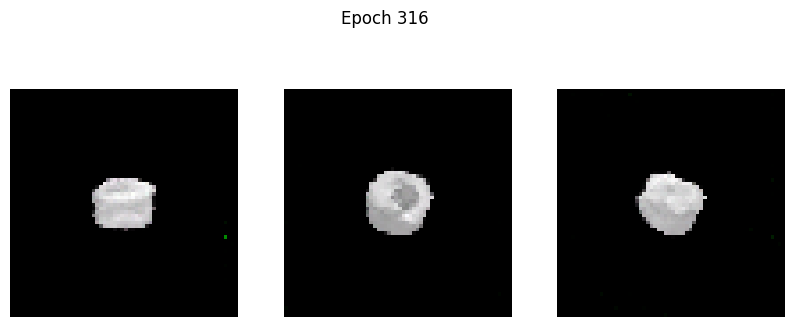

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0664 - g_loss: 4.3940
Epoch 317/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0517 - g_loss: 4.5486

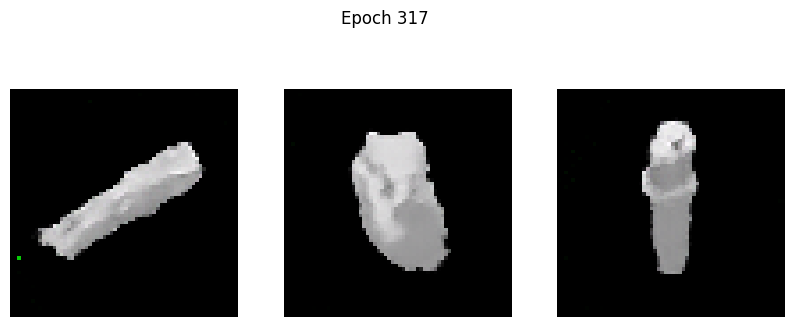

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0517 - g_loss: 4.5478
Epoch 318/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0594 - g_loss: 4.4392

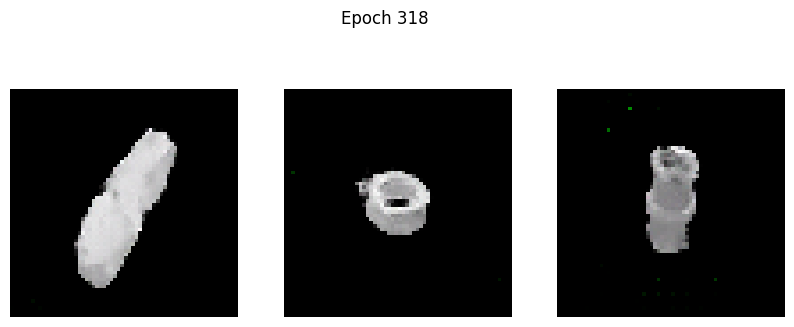

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0596 - g_loss: 4.4396
Epoch 319/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0490 - g_loss: 4.6187

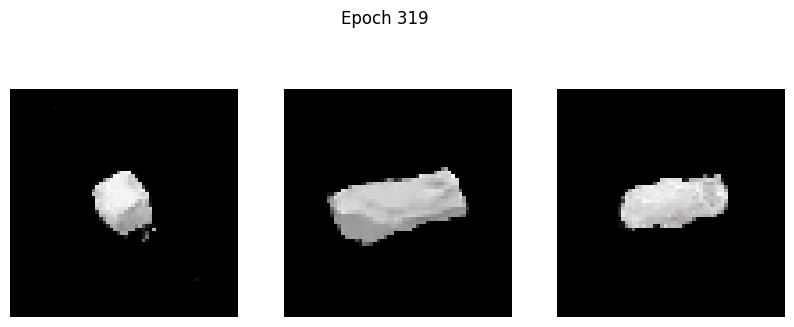

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0490 - g_loss: 4.6182
Epoch 320/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0328 - g_loss: 4.6131

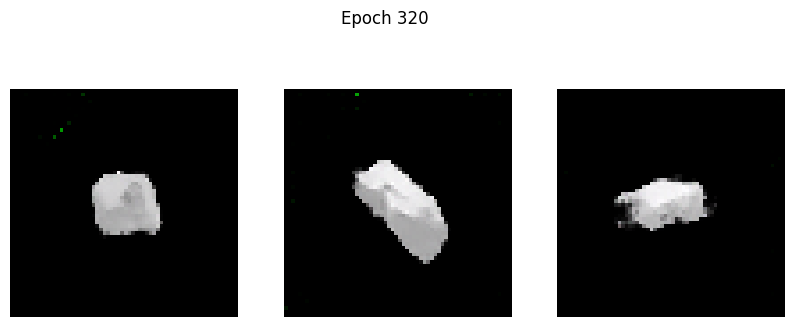

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0331 - g_loss: 4.6139
Epoch 321/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0770 - g_loss: 4.6200

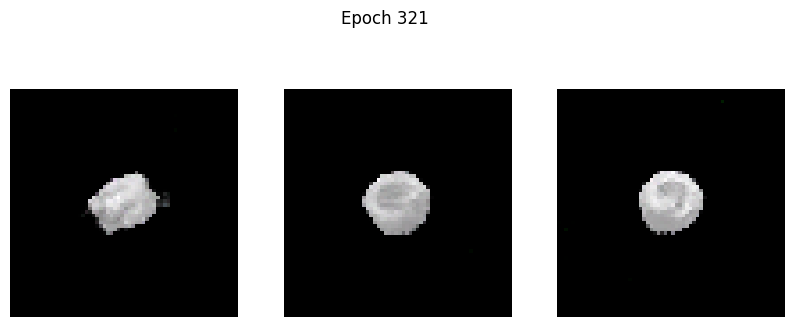

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - d_loss: 0.0770 - g_loss: 4.6199
Epoch 322/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0815 - g_loss: 4.6305

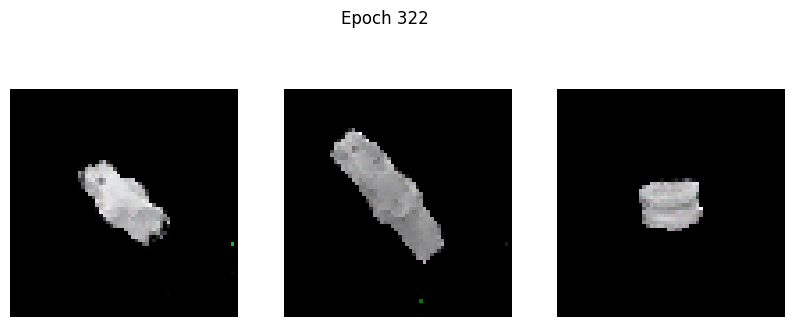

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0819 - g_loss: 4.6312
Epoch 323/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0350 - g_loss: 4.5080

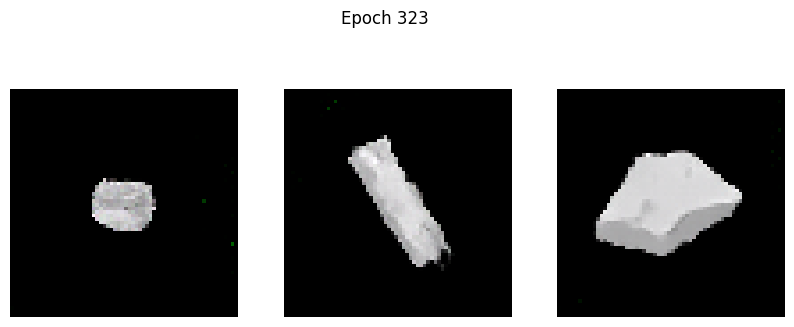

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0350 - g_loss: 4.5080
Epoch 324/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0462 - g_loss: 4.5451

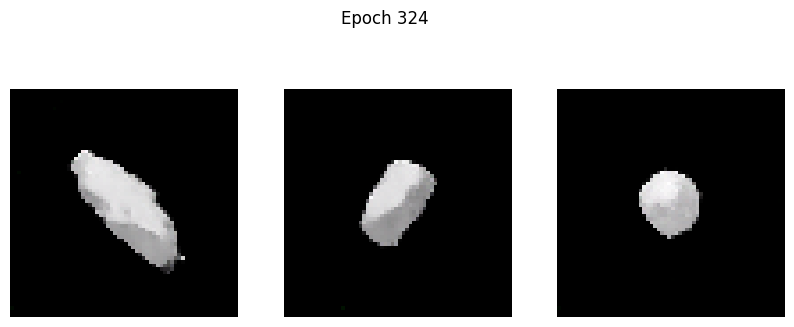

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0462 - g_loss: 4.5448
Epoch 325/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0381 - g_loss: 4.6598

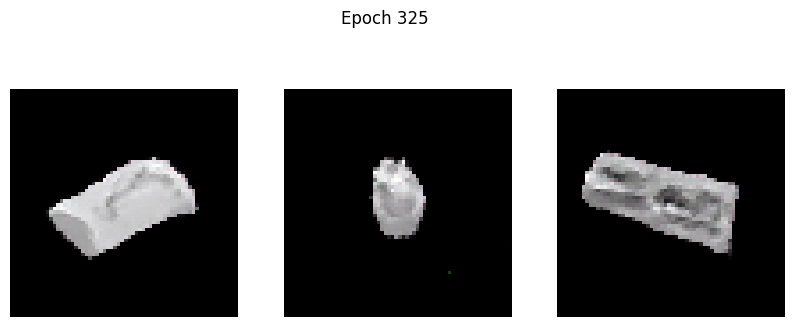

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0382 - g_loss: 4.6597
Epoch 326/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1364 - g_loss: 4.7190

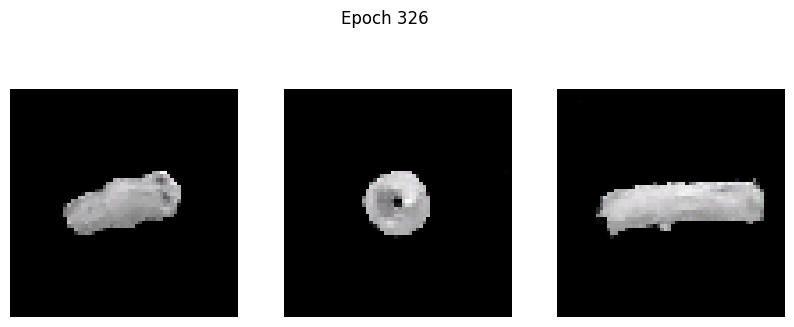

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1366 - g_loss: 4.7196
Epoch 327/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0157 - g_loss: 4.4790

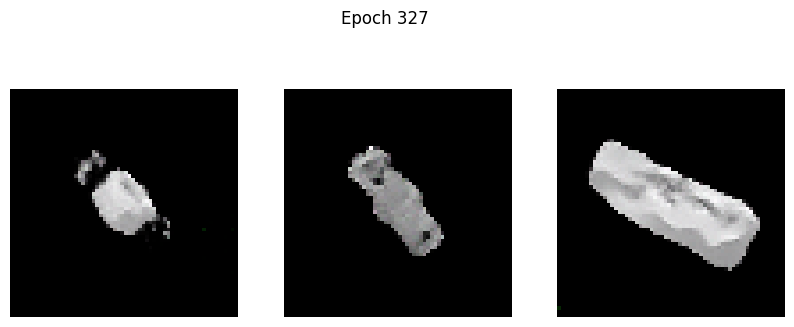

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0158 - g_loss: 4.4788
Epoch 328/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1146 - g_loss: 4.8218

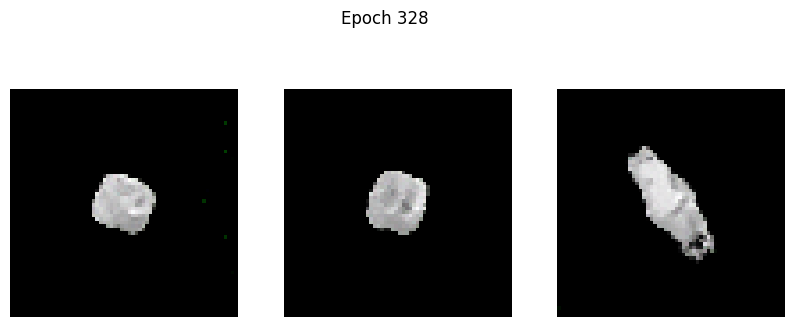

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1143 - g_loss: 4.8206
Epoch 329/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0100 - g_loss: 4.4044

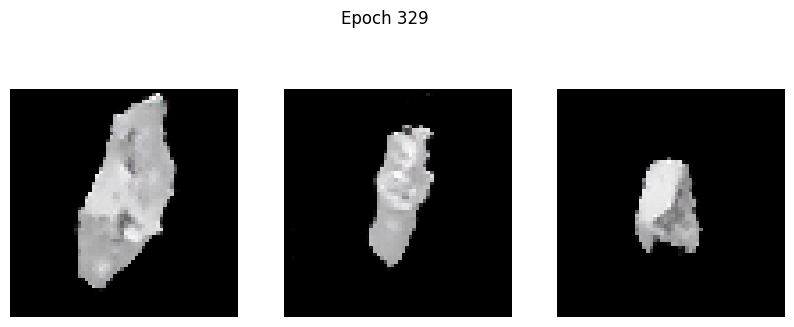

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0101 - g_loss: 4.4056
Epoch 330/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1312 - g_loss: 4.8873

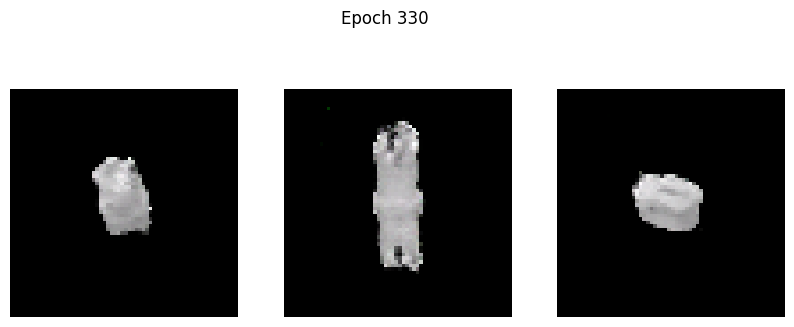

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1307 - g_loss: 4.8863
Epoch 331/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0173 - g_loss: 4.4994

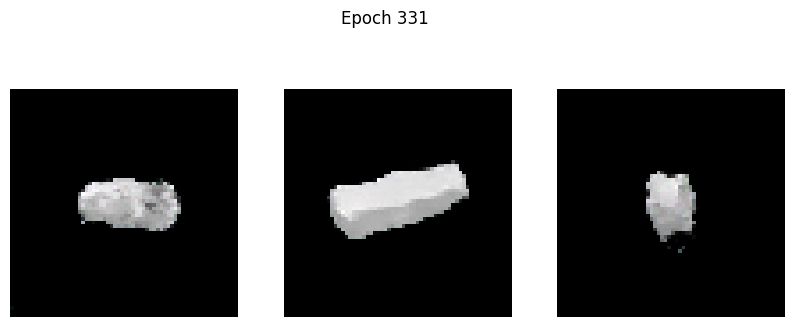

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0176 - g_loss: 4.5009
Epoch 332/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.0567 - g_loss: 4.6928

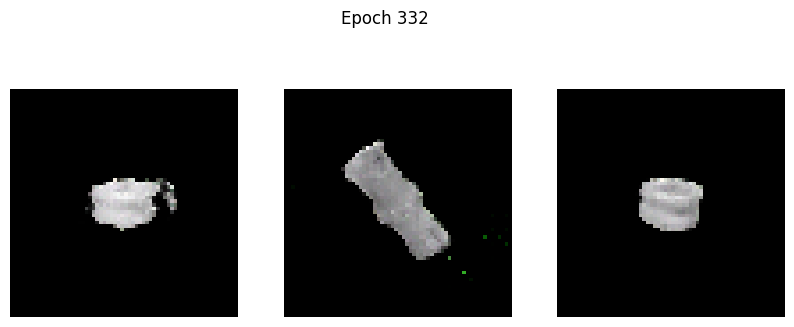

100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - d_loss: 0.0569 - g_loss: 4.6933
Epoch 333/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - d_loss: 0.1739 - g_loss: 4.8126

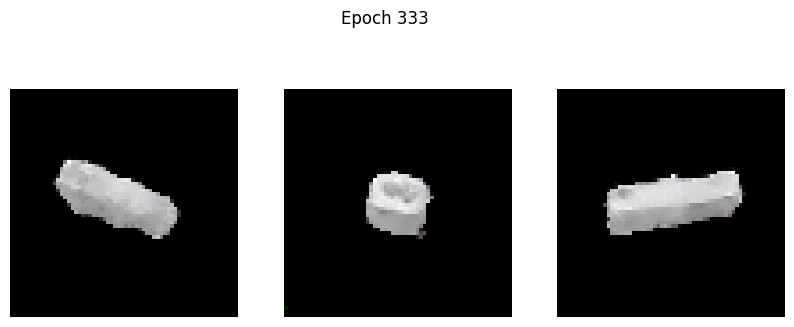

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - d_loss: 0.1734 - g_loss: 4.8121
Epoch 334/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - d_loss: 0.0453 - g_loss: 4.4902

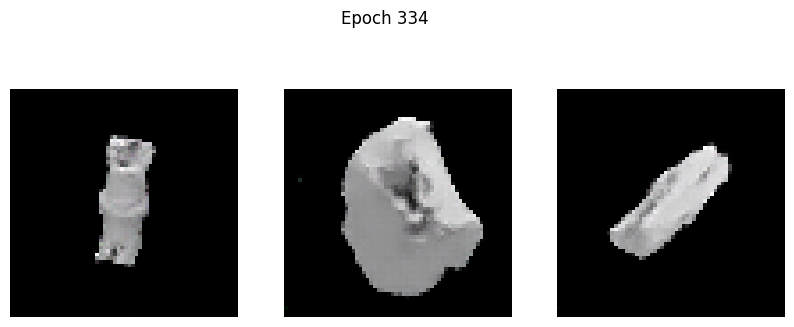

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - d_loss: 0.0453 - g_loss: 4.4909
Epoch 335/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0357 - g_loss: 4.6883

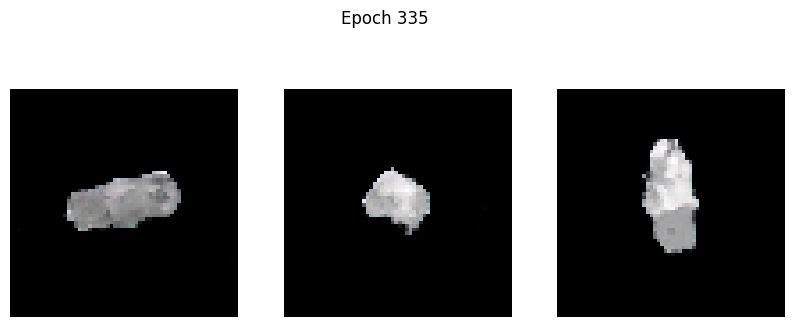

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0361 - g_loss: 4.6890
Epoch 336/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.1598 - g_loss: 4.7536

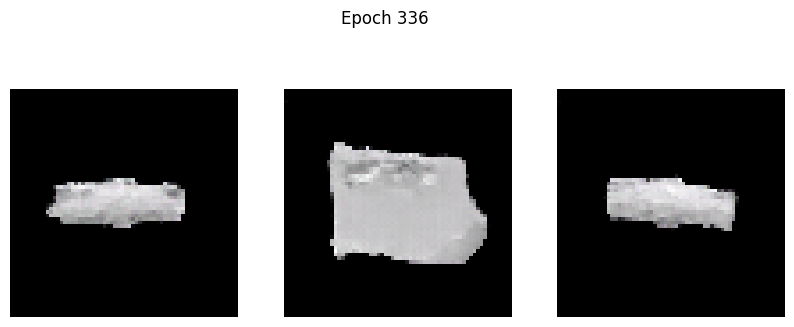

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.1594 - g_loss: 4.7543
Epoch 337/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.0278 - g_loss: 4.5220

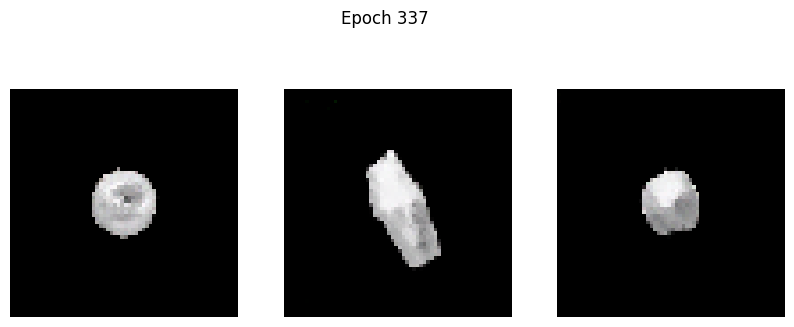

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.0277 - g_loss: 4.5221
Epoch 338/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - d_loss: 0.0222 - g_loss: 4.5734

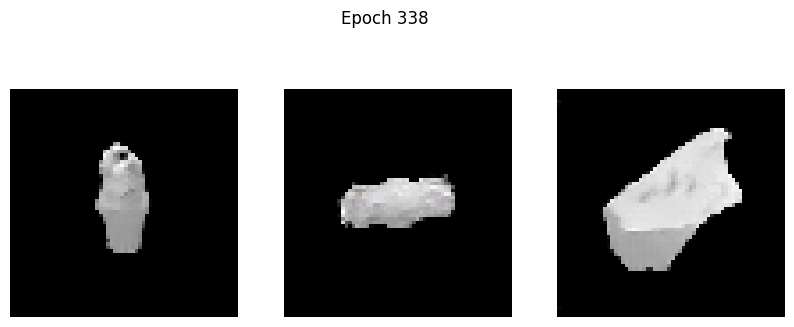

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - d_loss: 0.0222 - g_loss: 4.5737
Epoch 339/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0894 - g_loss: 4.8562

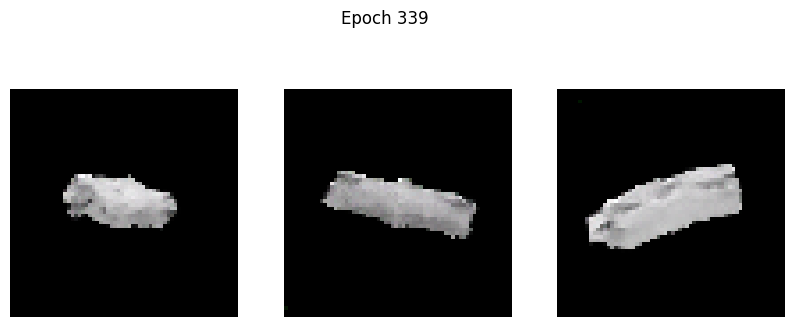

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0895 - g_loss: 4.8565
Epoch 340/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0236 - g_loss: 4.5277

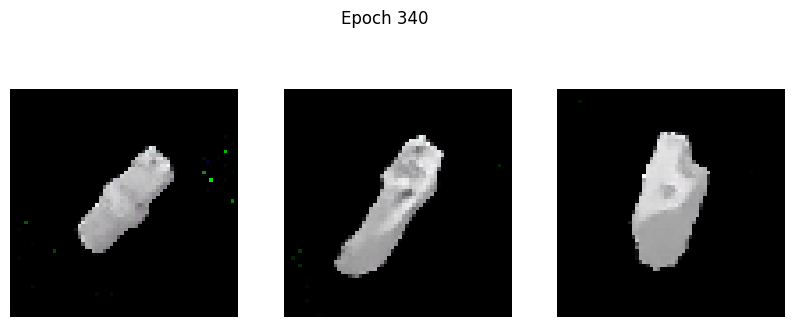

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.0236 - g_loss: 4.5289
Epoch 341/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0625 - g_loss: 4.8316

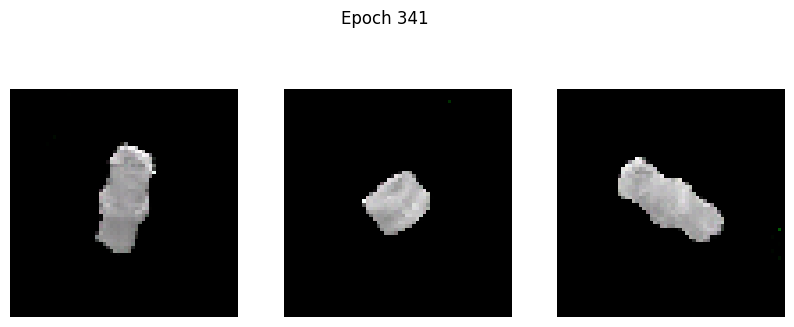

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0623 - g_loss: 4.8299
Epoch 342/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.2655 - g_loss: 5.2709

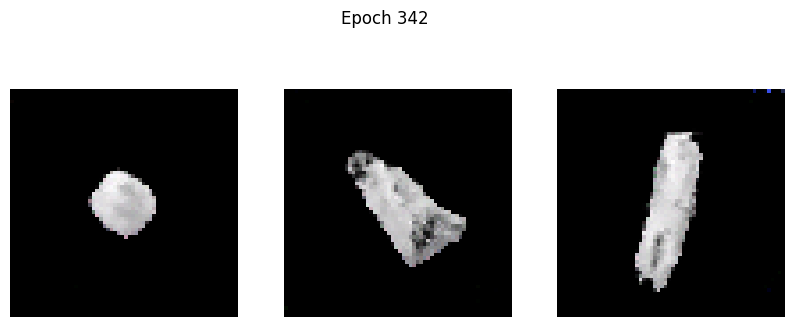

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.2669 - g_loss: 5.2716
Epoch 343/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0272 - g_loss: 4.2755

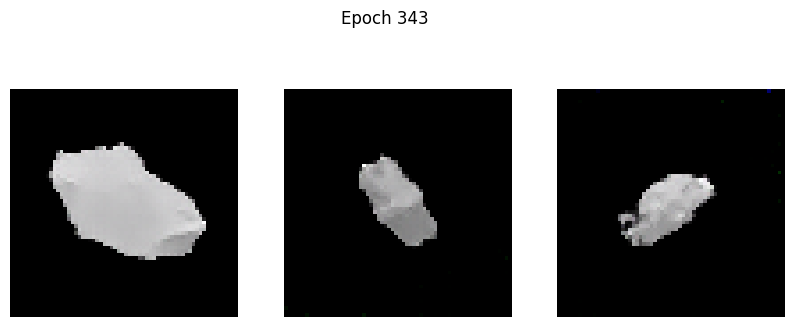

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0272 - g_loss: 4.2764
Epoch 344/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0125 - g_loss: 4.6280

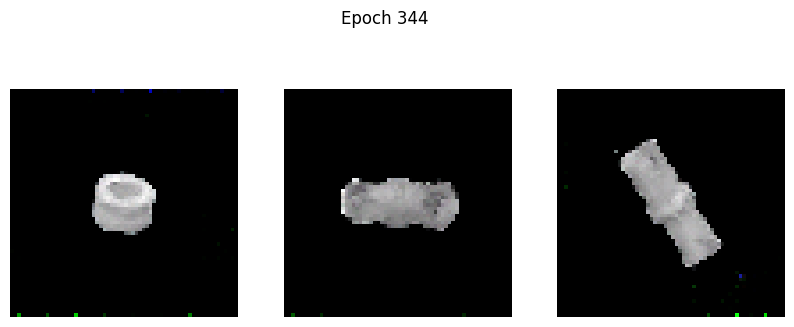

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0126 - g_loss: 4.6278
Epoch 345/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0063 - g_loss: 4.6368

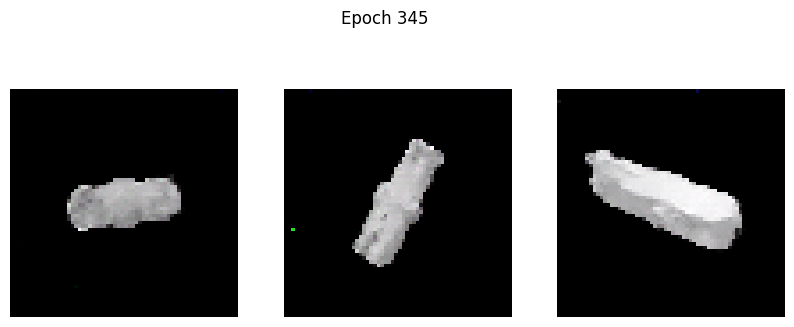

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0064 - g_loss: 4.6365
Epoch 346/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0292 - g_loss: 4.6203

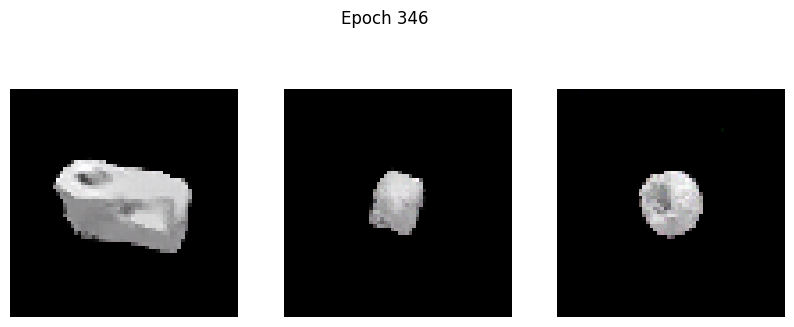

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0292 - g_loss: 4.6220
Epoch 347/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0136 - g_loss: 4.7875

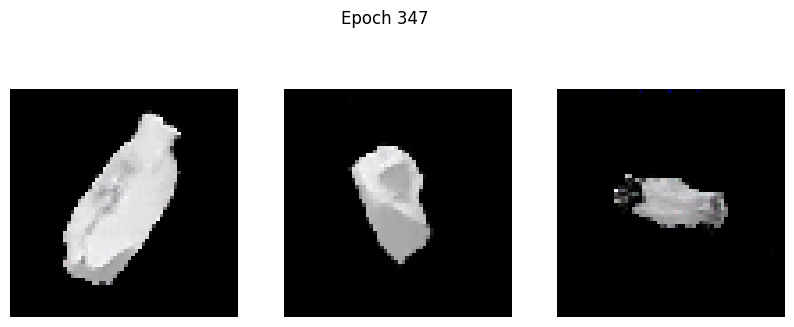

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0137 - g_loss: 4.7873
Epoch 348/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0594 - g_loss: 4.9781

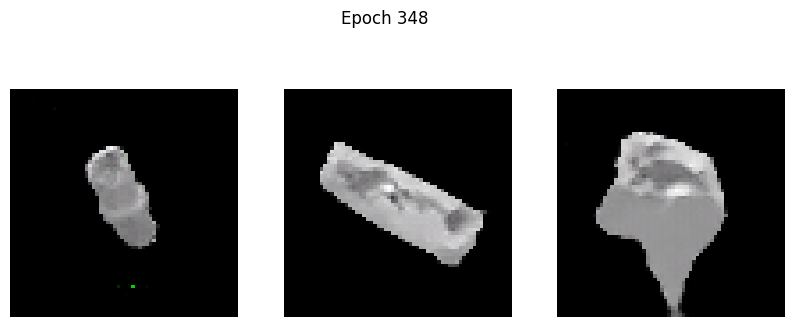

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0592 - g_loss: 4.9768
Epoch 349/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.1206 - g_loss: 5.0184

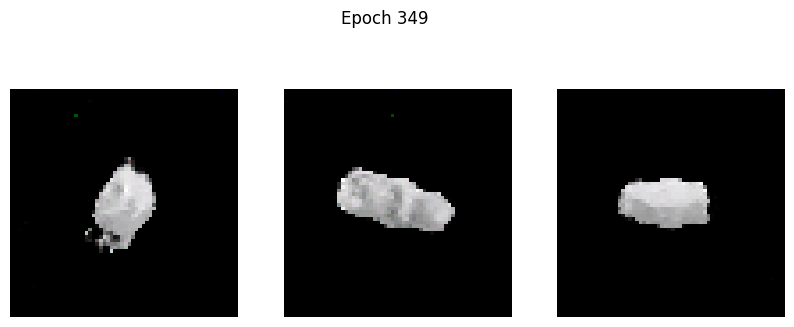

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1204 - g_loss: 5.0181
Epoch 350/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0154 - g_loss: 4.7112

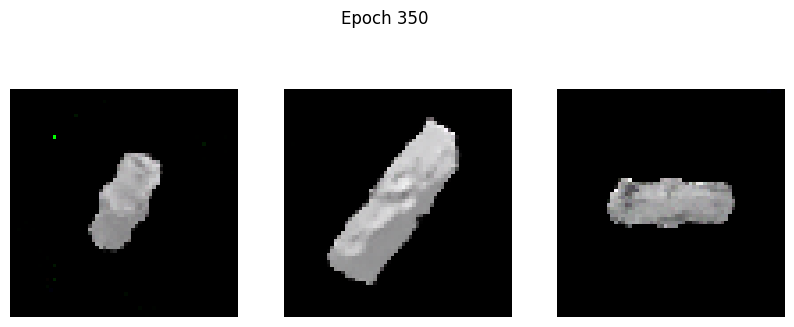

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0154 - g_loss: 4.7111
Epoch 351/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0307 - g_loss: 4.8351

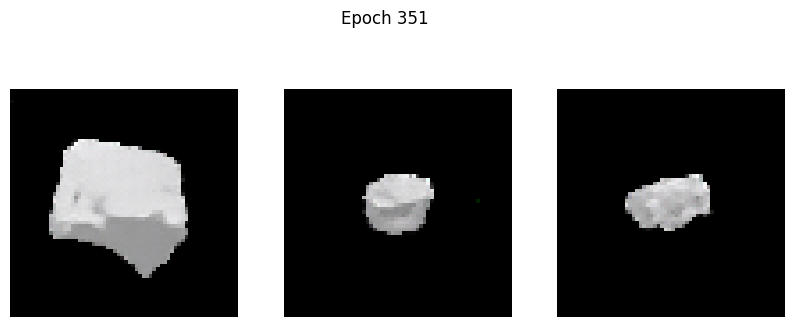

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0307 - g_loss: 4.8346
Epoch 352/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0862 - g_loss: 5.0010

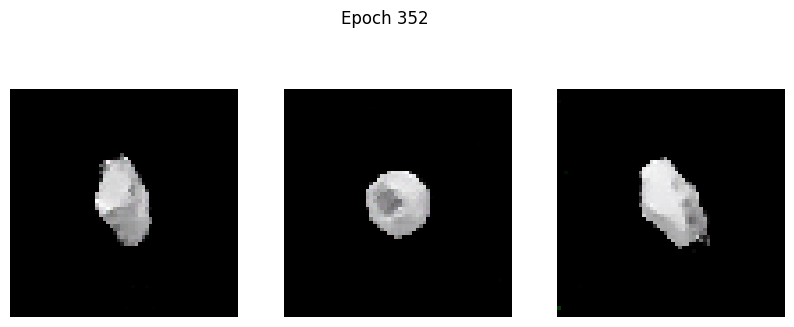

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0859 - g_loss: 5.0005
Epoch 353/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0896 - g_loss: 5.0012

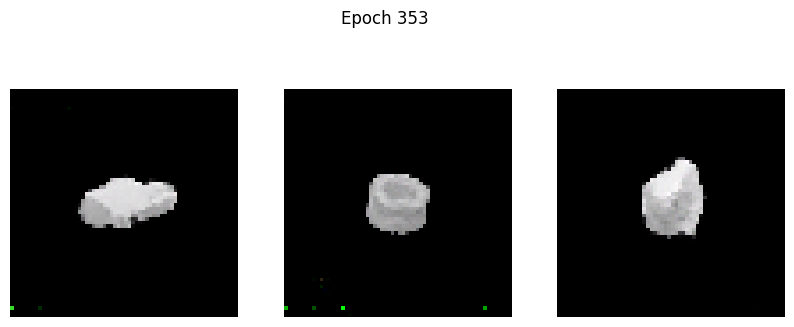

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0896 - g_loss: 5.0021
Epoch 354/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0086 - g_loss: 4.6021

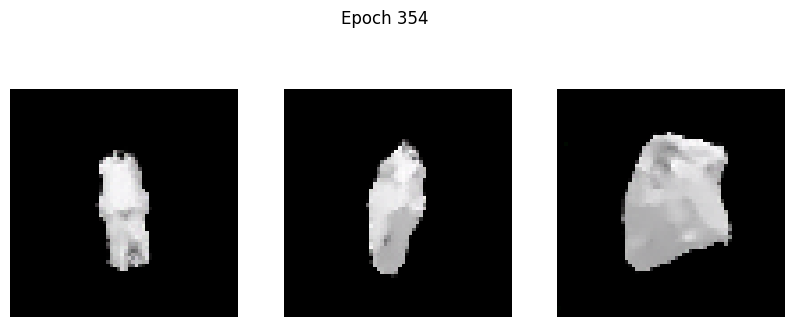

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0088 - g_loss: 4.6033
Epoch 355/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0857 - g_loss: 5.2297

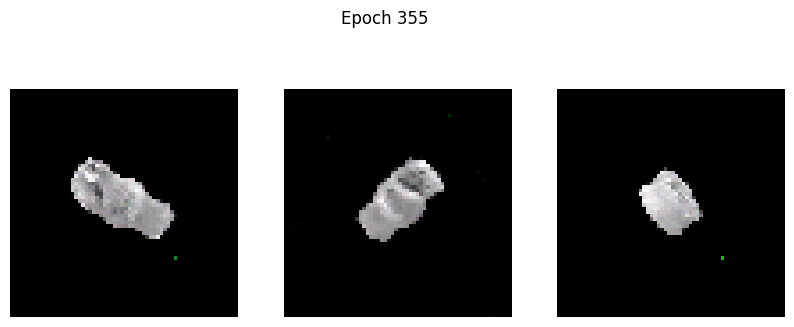

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0854 - g_loss: 5.2274
Epoch 356/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0398 - g_loss: 4.8962

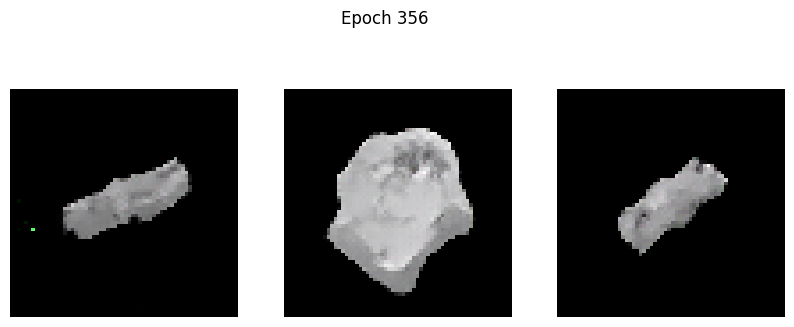

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0399 - g_loss: 4.8963
Epoch 357/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0179 - g_loss: 4.8281

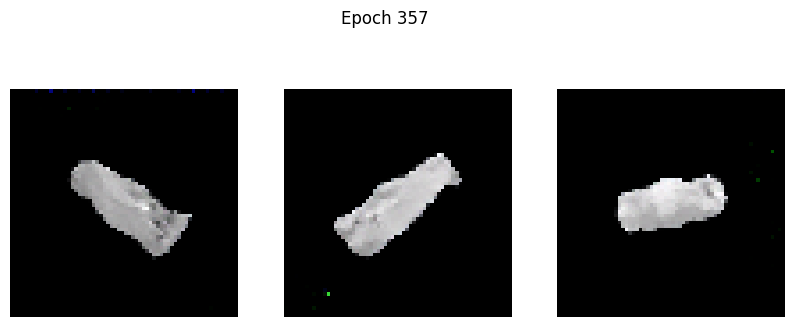

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0178 - g_loss: 4.8278
Epoch 358/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0383 - g_loss: 4.8809

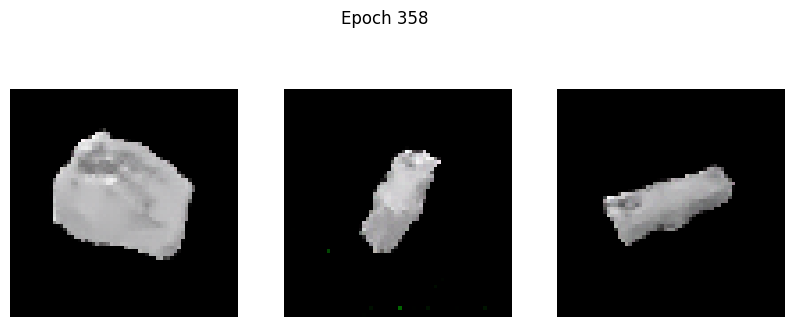

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0382 - g_loss: 4.8813
Epoch 359/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0179 - g_loss: 5.0658

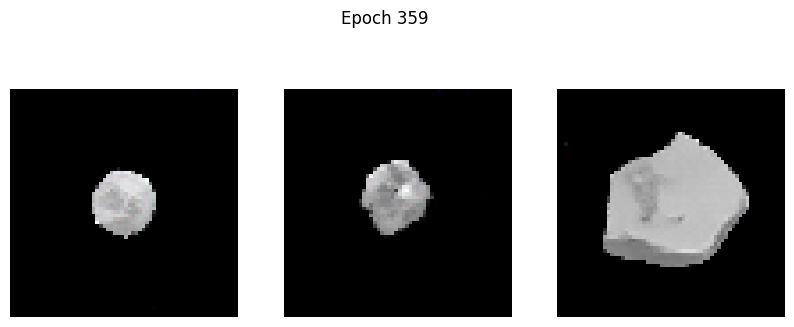

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0180 - g_loss: 5.0652
Epoch 360/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0501 - g_loss: 5.1333

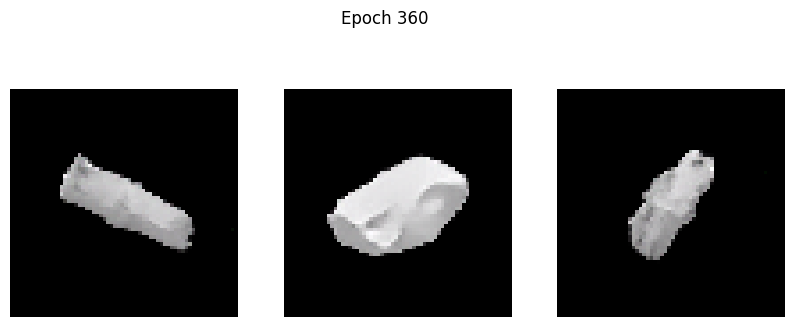

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0503 - g_loss: 5.1332
Epoch 361/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0691 - g_loss: 5.1965

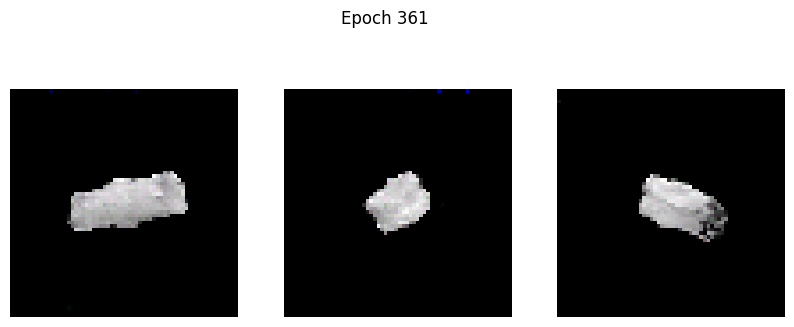

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0688 - g_loss: 5.1952
Epoch 362/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0326 - g_loss: 4.9760

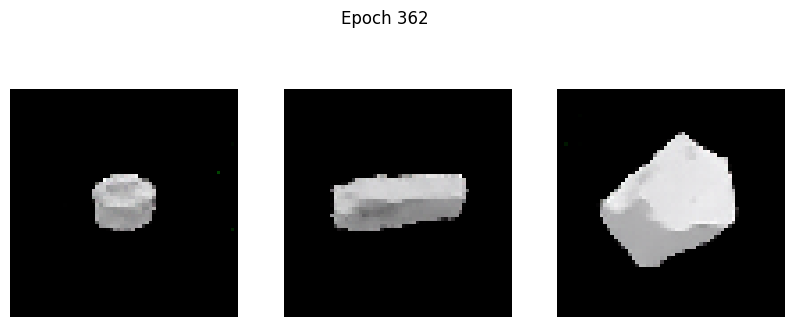

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0325 - g_loss: 4.9756
Epoch 363/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0710 - g_loss: 5.0165

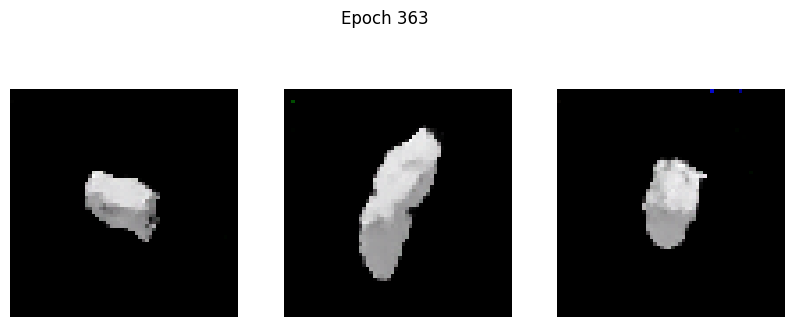

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0707 - g_loss: 5.0160
Epoch 364/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0674 - g_loss: 5.1895

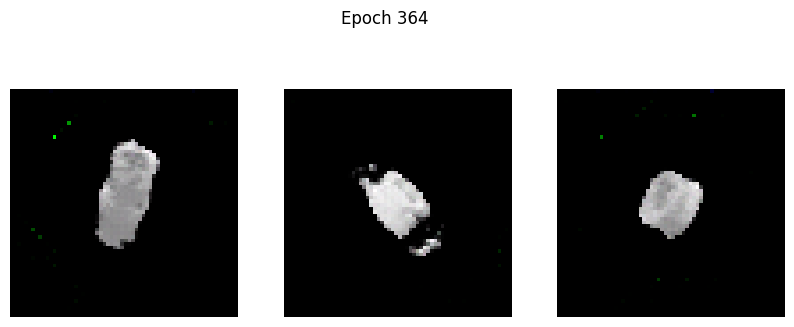

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0673 - g_loss: 5.1880
Epoch 365/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0476 - g_loss: 5.0768

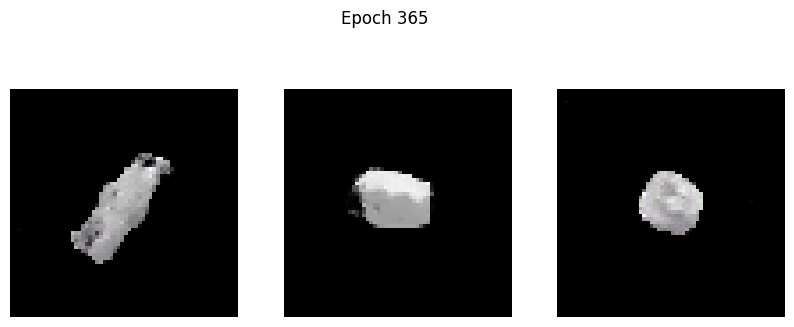

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0481 - g_loss: 5.0789
Epoch 366/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0620 - g_loss: 4.9404

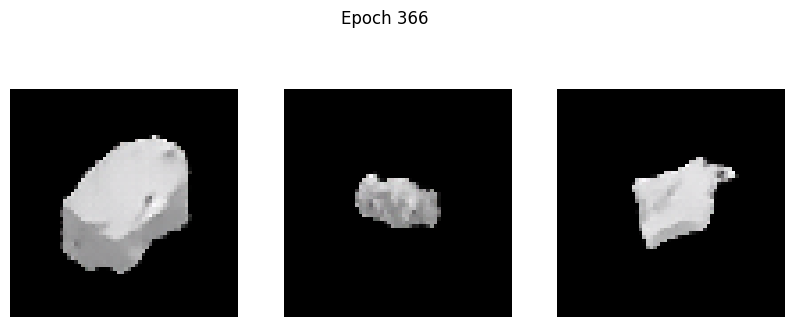

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0617 - g_loss: 4.9395
Epoch 367/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0340 - g_loss: 5.0481

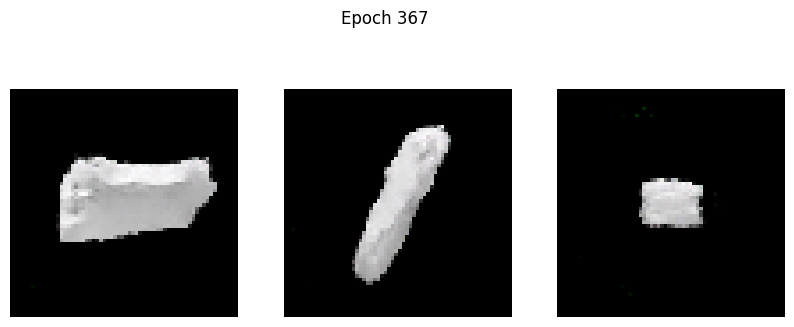

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0341 - g_loss: 5.0479
Epoch 368/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0056 - g_loss: 4.6640

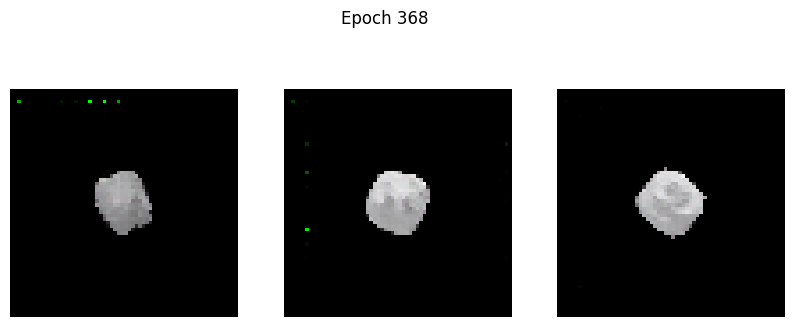

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0055 - g_loss: 4.6657
Epoch 369/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0367 - g_loss: 5.0026

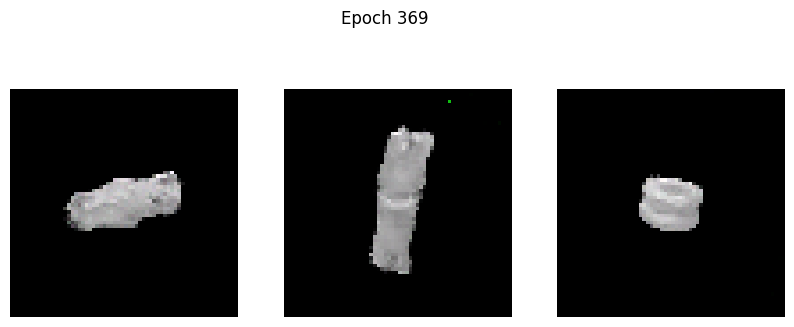

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0370 - g_loss: 5.0031
Epoch 370/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0178 - g_loss: 5.0447

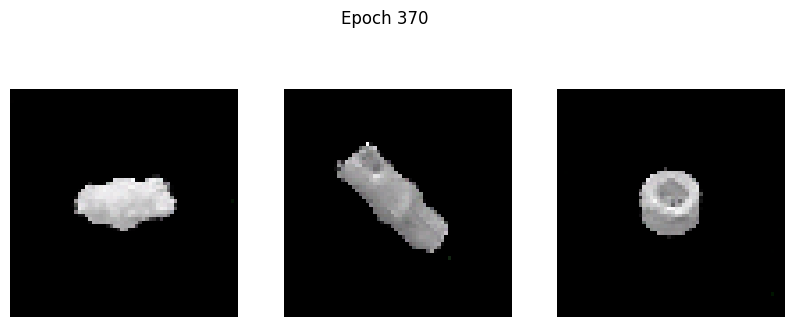

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0179 - g_loss: 5.0437
Epoch 371/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0484 - g_loss: 5.1009

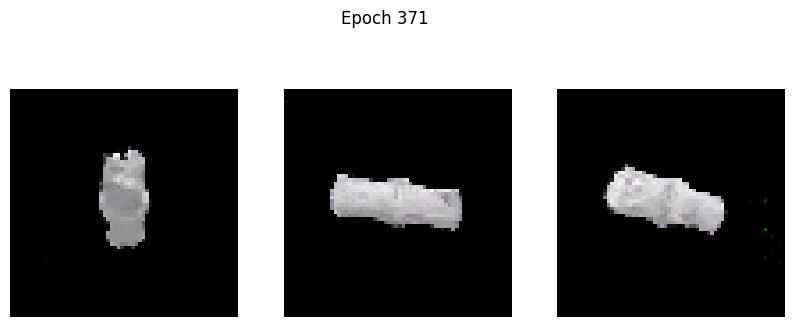

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.0487 - g_loss: 5.1022
Epoch 372/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0255 - g_loss: 4.8777

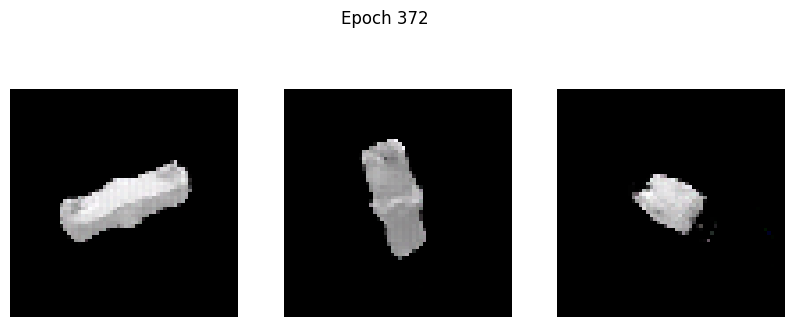

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0256 - g_loss: 4.8793
Epoch 373/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0124 - g_loss: 4.8628

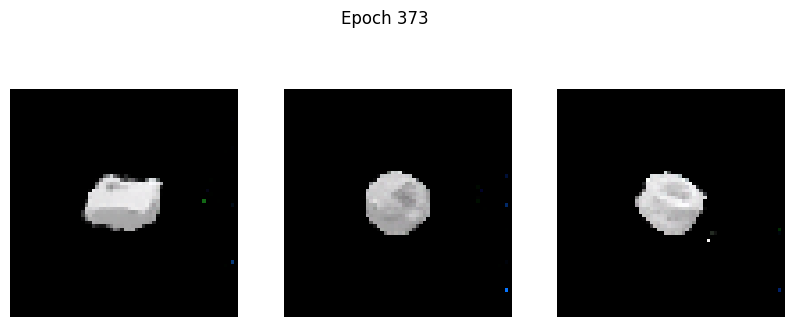

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0126 - g_loss: 4.8633
Epoch 374/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0082 - g_loss: 4.8685

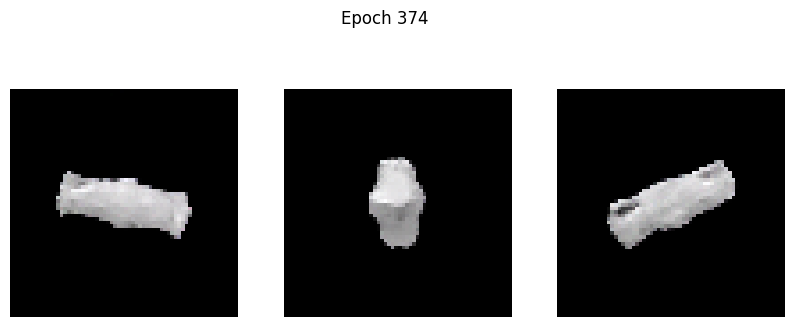

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0081 - g_loss: 4.8694
Epoch 375/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0083 - g_loss: 5.0044

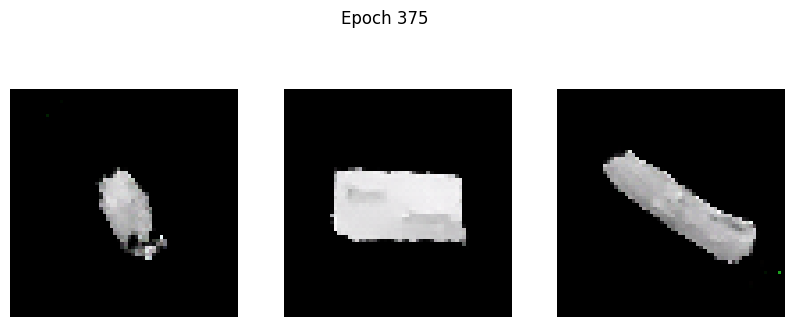

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0084 - g_loss: 5.0044
Epoch 376/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1416 - g_loss: 5.4177

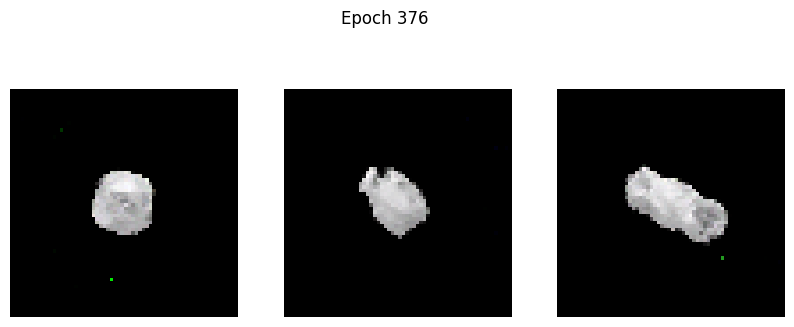

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.1409 - g_loss: 5.4157
Epoch 377/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0186 - g_loss: 5.0139

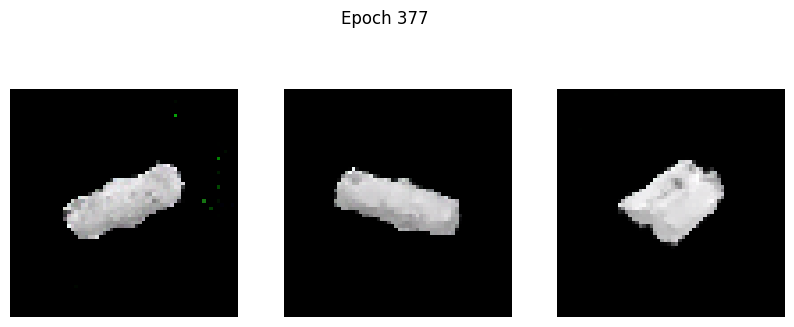

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: 0.0185 - g_loss: 5.0145
Epoch 378/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.4564 - g_loss: 6.1345

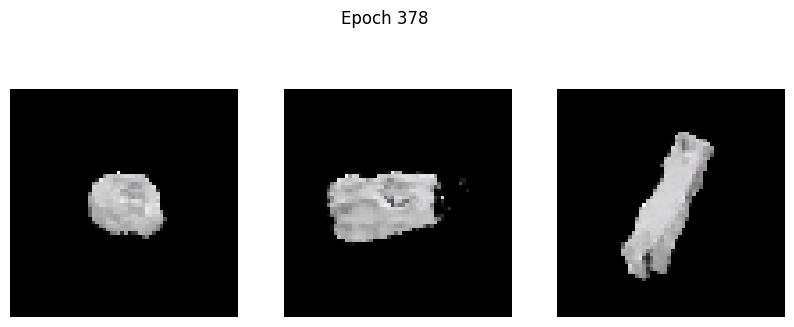

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.4541 - g_loss: 6.1283
Epoch 379/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0082 - g_loss: 4.7903

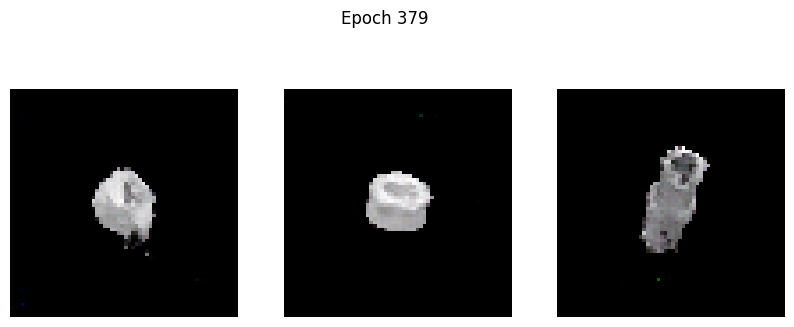

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0083 - g_loss: 4.7912
Epoch 380/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0043 - g_loss: 4.9911

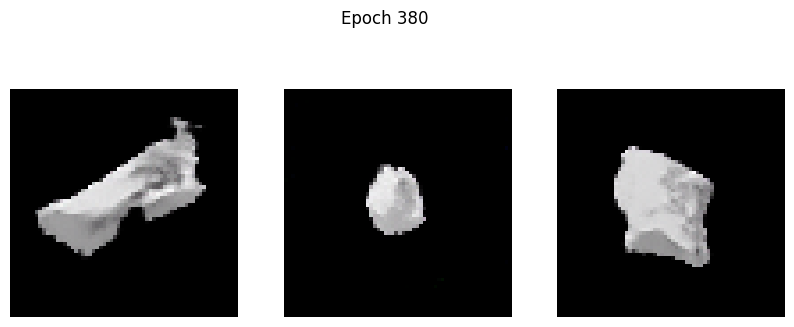

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0046 - g_loss: 4.9921
Epoch 381/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0315 - g_loss: 5.2975

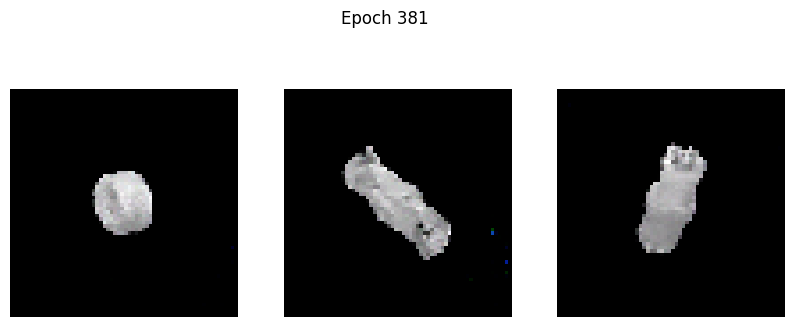

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0315 - g_loss: 5.2964
Epoch 382/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0464 - g_loss: 4.9693

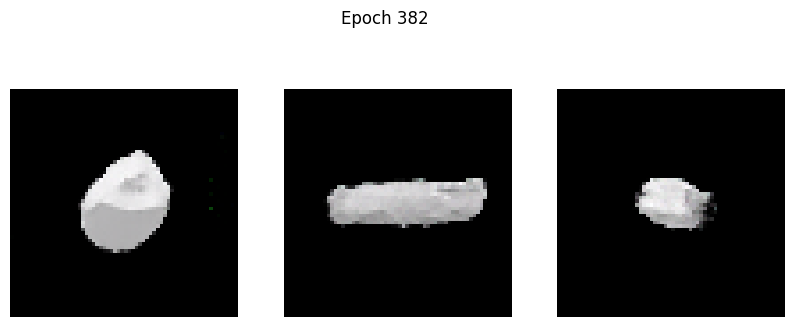

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0460 - g_loss: 4.9690
Epoch 383/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0306 - g_loss: 4.9918

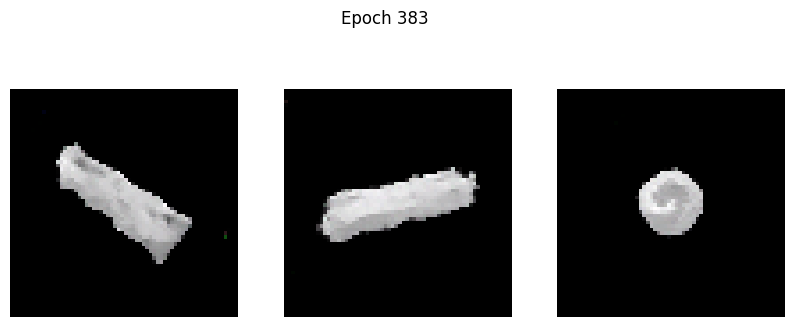

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0304 - g_loss: 4.9920
Epoch 384/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0175 - g_loss: 5.1501

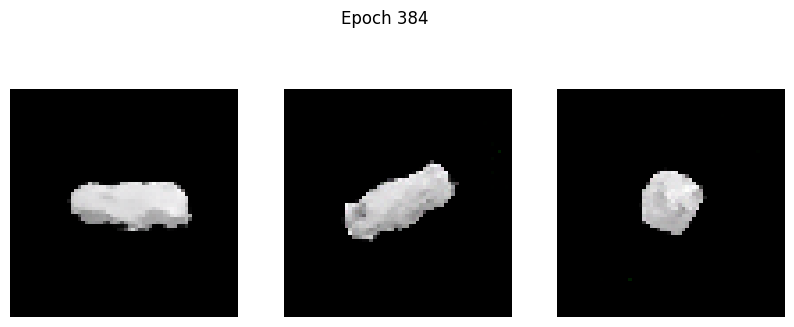

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0173 - g_loss: 5.1509
Epoch 385/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0313 - g_loss: 5.2976

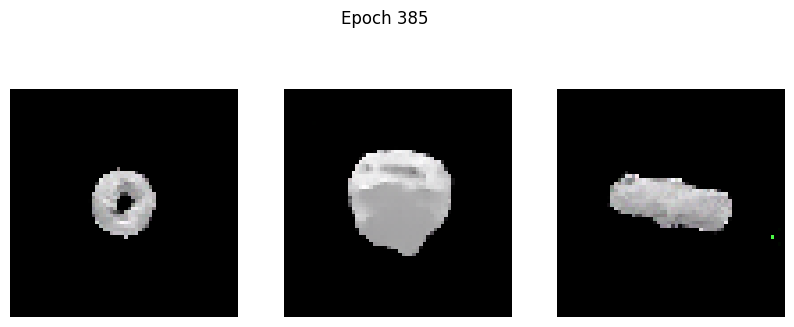

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0315 - g_loss: 5.2974
Epoch 386/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0796 - g_loss: 5.6831

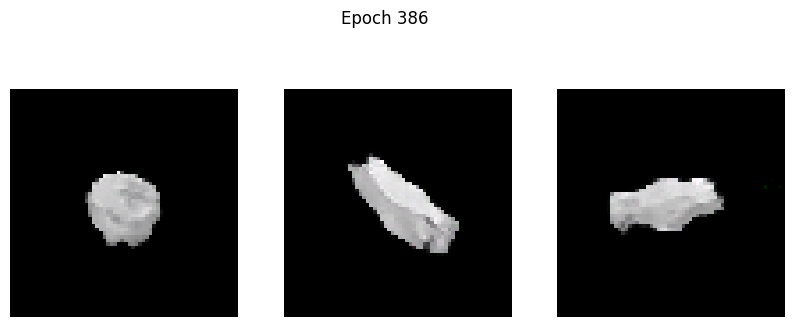

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - d_loss: 0.0795 - g_loss: 5.6819
Epoch 387/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0121 - g_loss: 5.0815

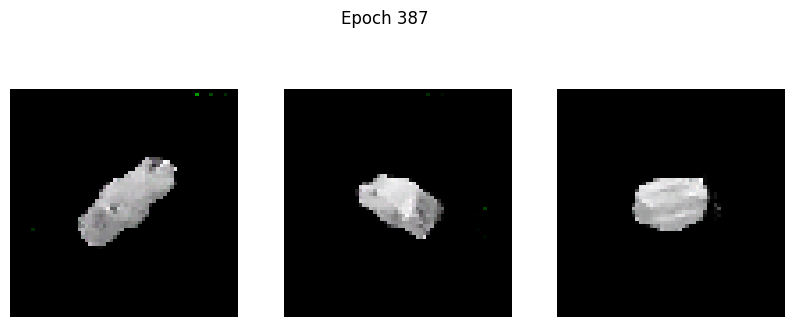

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0118 - g_loss: 5.0828
Epoch 388/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0061 - g_loss: 5.1241

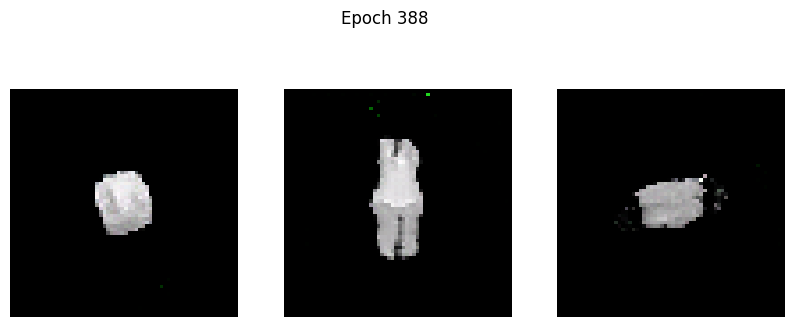

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0060 - g_loss: 5.1246
Epoch 389/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0155 - g_loss: 5.1727

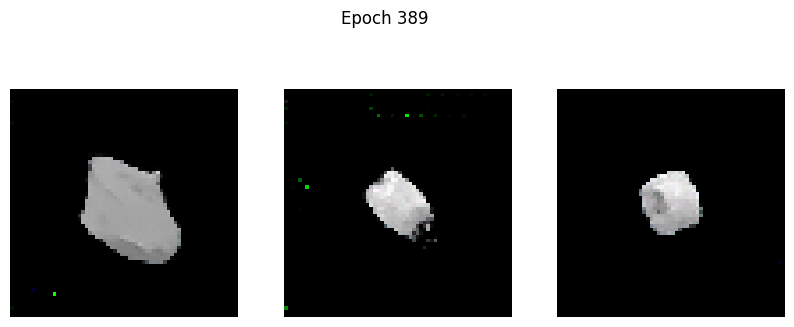

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0154 - g_loss: 5.1734
Epoch 390/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.1758 - g_loss: 5.5306

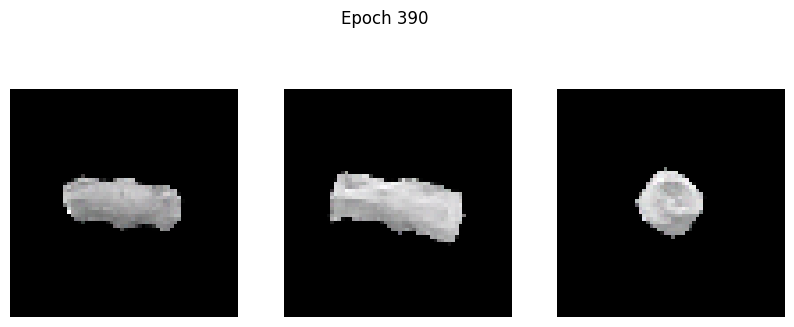

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.1756 - g_loss: 5.5292
Epoch 391/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0534 - g_loss: 5.2321

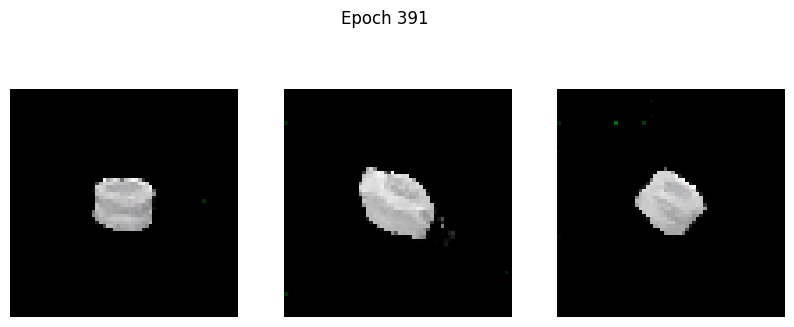

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0533 - g_loss: 5.2319
Epoch 392/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0206 - g_loss: 5.2725

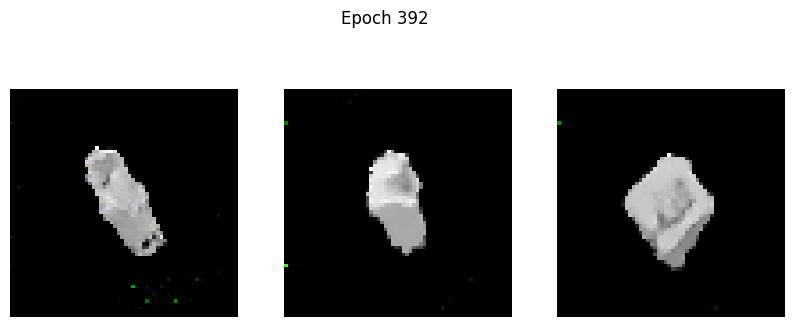

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0209 - g_loss: 5.2718
Epoch 393/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0691 - g_loss: 5.2688

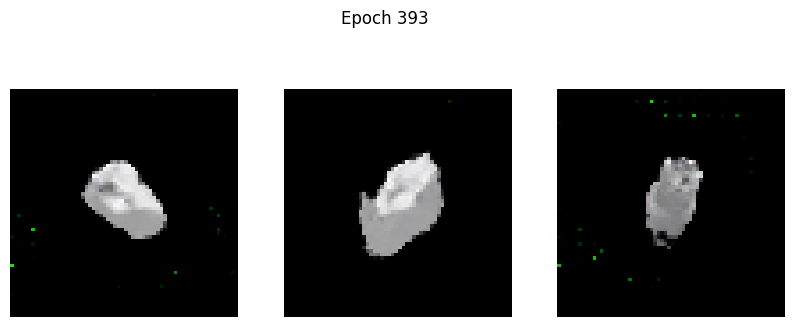

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0686 - g_loss: 5.2678
Epoch 394/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0266 - g_loss: 5.0031

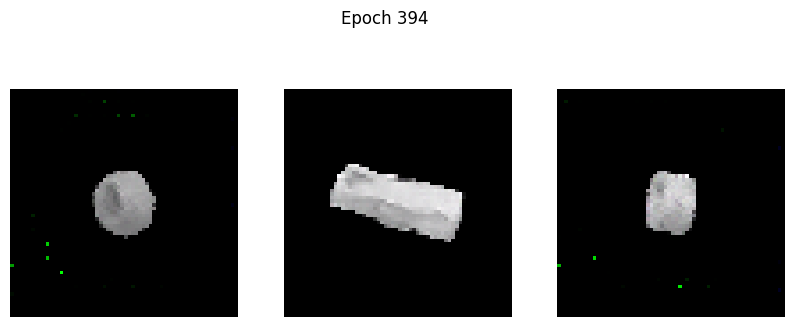

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0265 - g_loss: 5.0048
Epoch 395/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0072 - g_loss: 5.2128

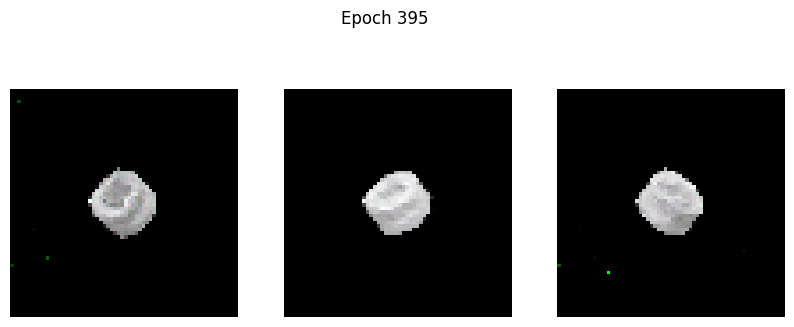

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0072 - g_loss: 5.2136
Epoch 396/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0201 - g_loss: 5.1655

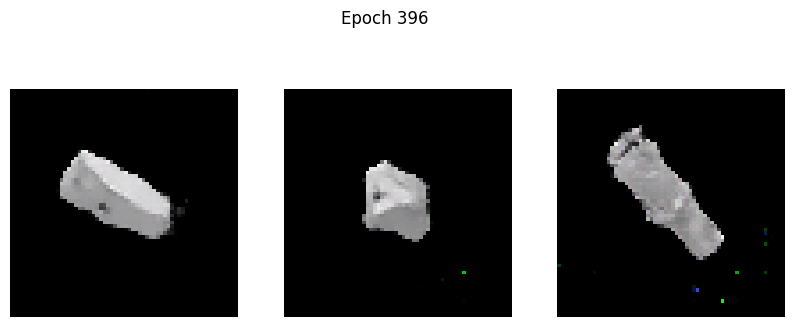

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0200 - g_loss: 5.1656
Epoch 397/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0073 - g_loss: 5.2032

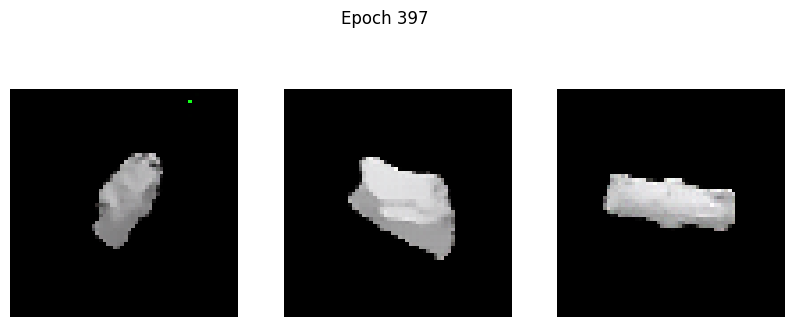

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0070 - g_loss: 5.2036
Epoch 398/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0801 - g_loss: 5.4774

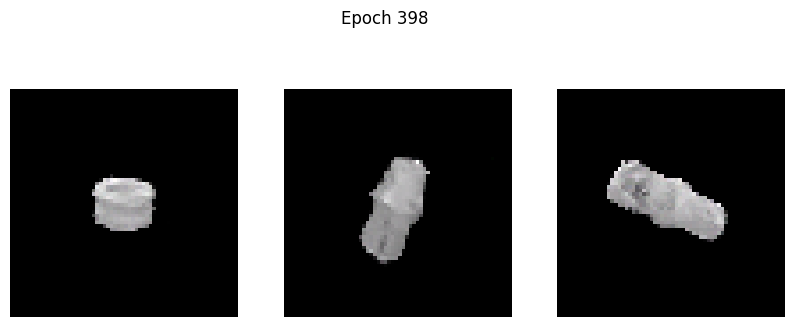

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0801 - g_loss: 5.4768
Epoch 399/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0110 - g_loss: 5.1900

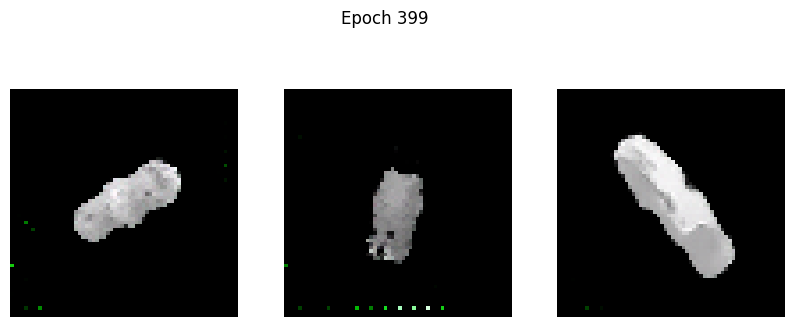

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0107 - g_loss: 5.1896
Epoch 400/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 5.6945e-04 - g_loss: 5.3180

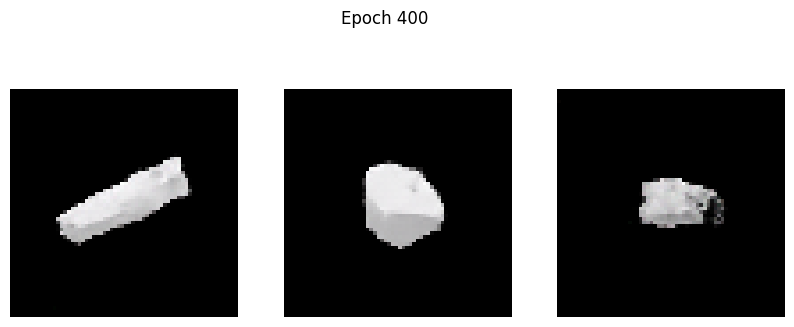

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 4.5052e-04 - g_loss: 5.3166
Epoch 401/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0352 - g_loss: 5.1331

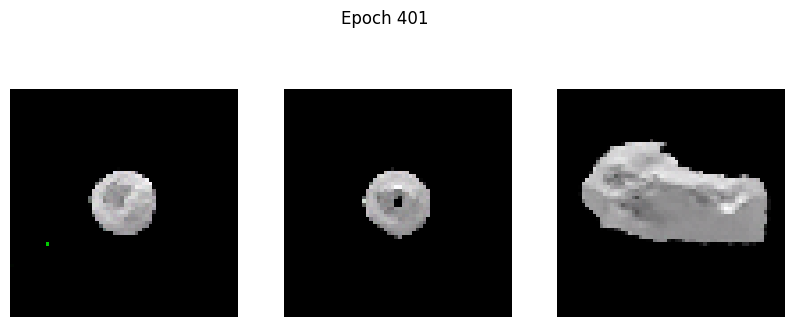

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0354 - g_loss: 5.1329
Epoch 402/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0751 - g_loss: 5.9146

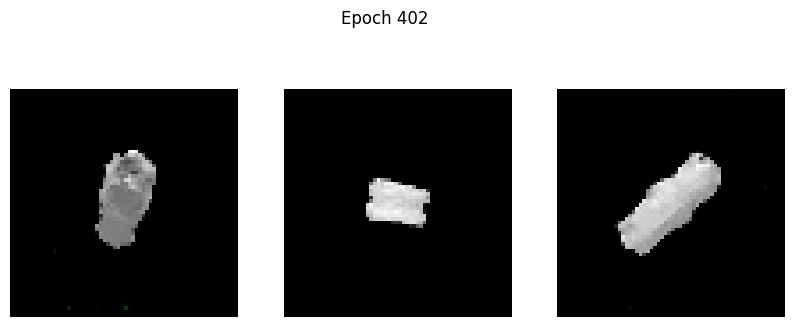

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0749 - g_loss: 5.9125
Epoch 403/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0237 - g_loss: 5.7532

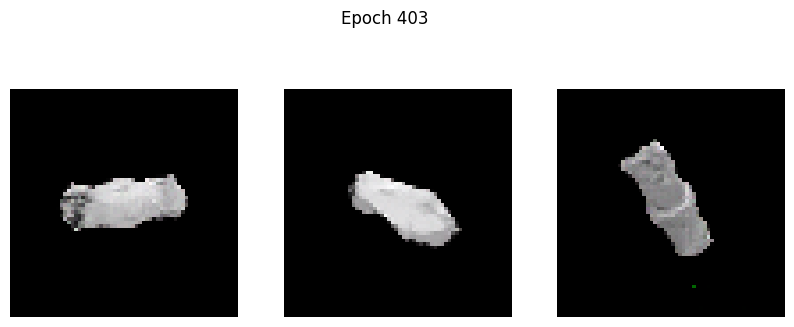

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0237 - g_loss: 5.7523
Epoch 404/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0028 - g_loss: 5.2709

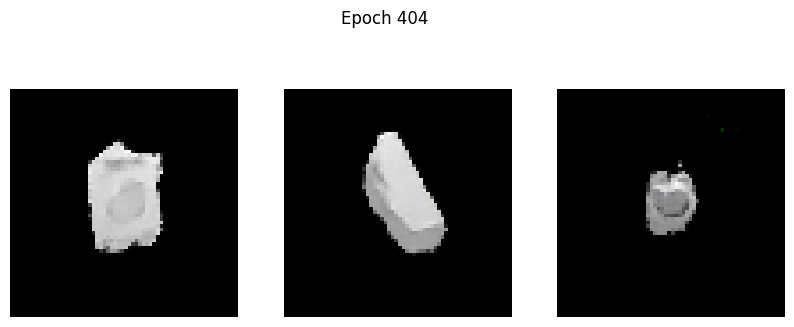

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0027 - g_loss: 5.2728
Epoch 405/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0409 - g_loss: 5.4285

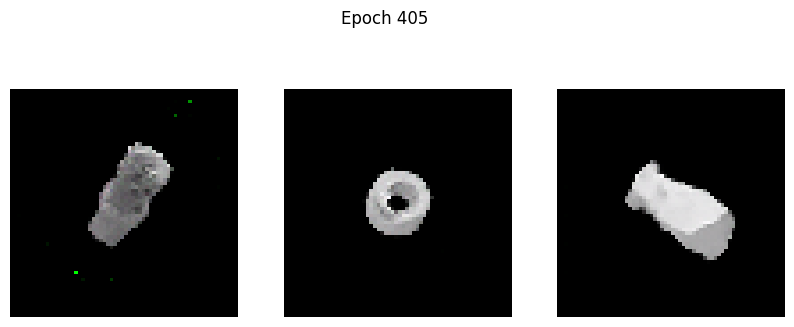

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0409 - g_loss: 5.4294
Epoch 406/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0443 - g_loss: 5.3773

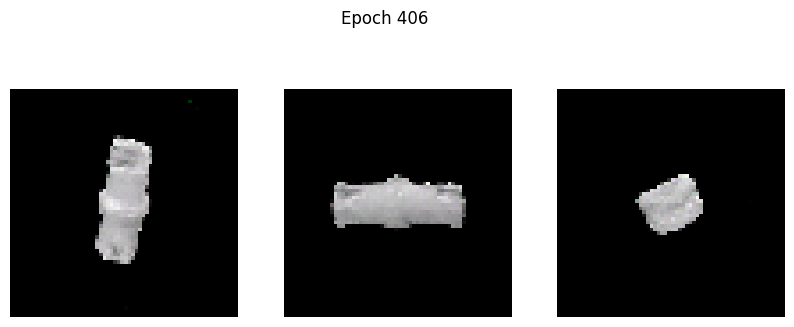

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0444 - g_loss: 5.3761
Epoch 407/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0918 - g_loss: 6.0131

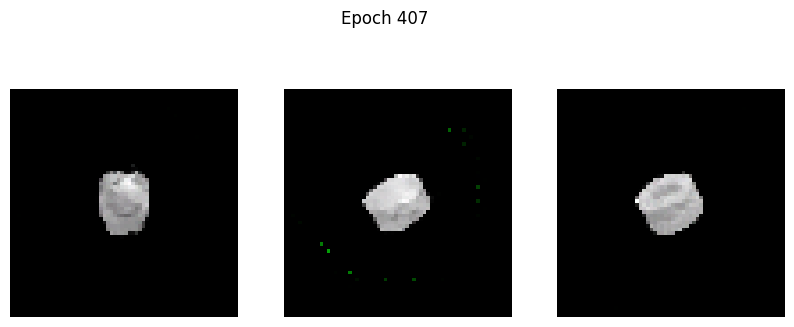

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0911 - g_loss: 6.0085
Epoch 408/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0353 - g_loss: 5.4110

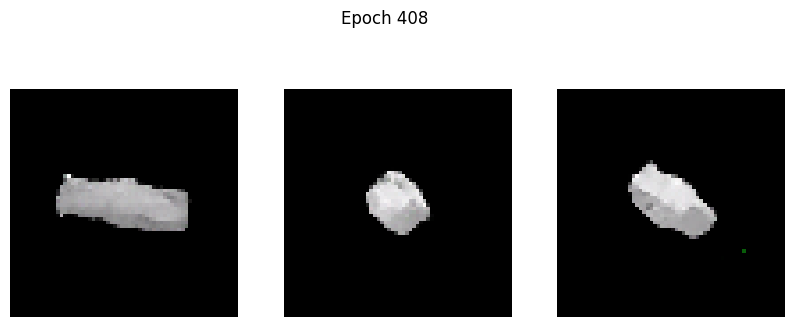

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0352 - g_loss: 5.4118
Epoch 409/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0954 - g_loss: 5.9196

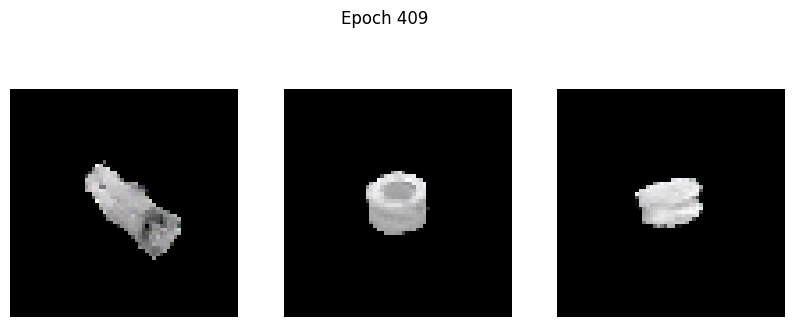

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0953 - g_loss: 5.9171
Epoch 410/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0054 - g_loss: 5.8054

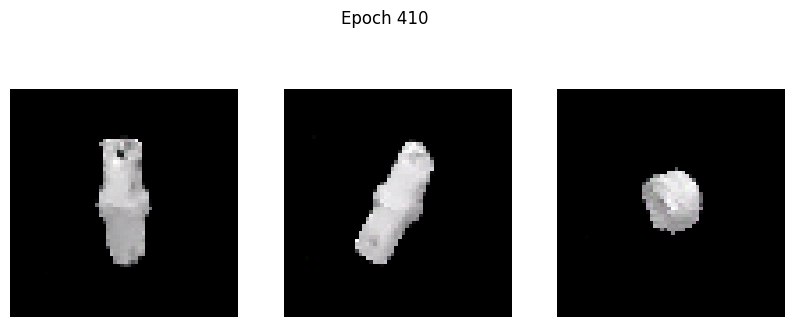

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0055 - g_loss: 5.8028
Epoch 411/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0118 - g_loss: 5.3076

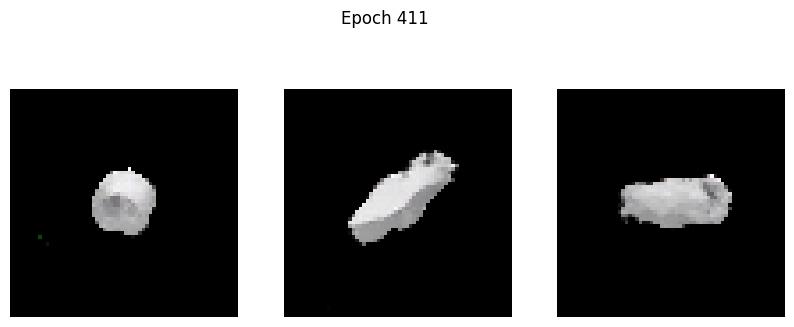

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0117 - g_loss: 5.3085
Epoch 412/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0047 - g_loss: 5.4345

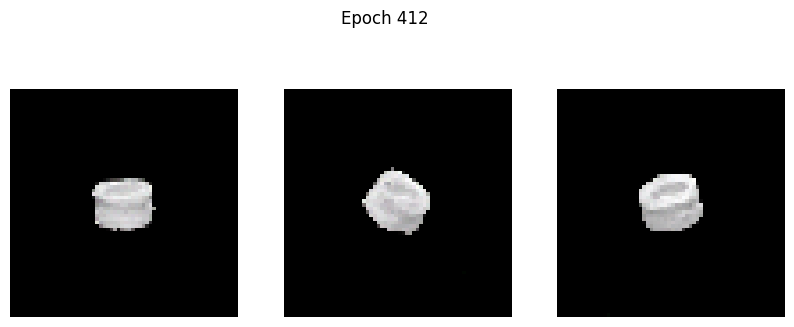

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0044 - g_loss: 5.4357
Epoch 413/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0409 - g_loss: 5.8663

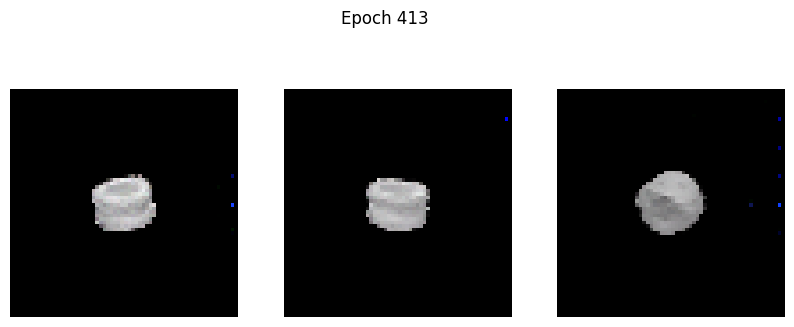

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0409 - g_loss: 5.8636
Epoch 414/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0018 - g_loss: 5.6505

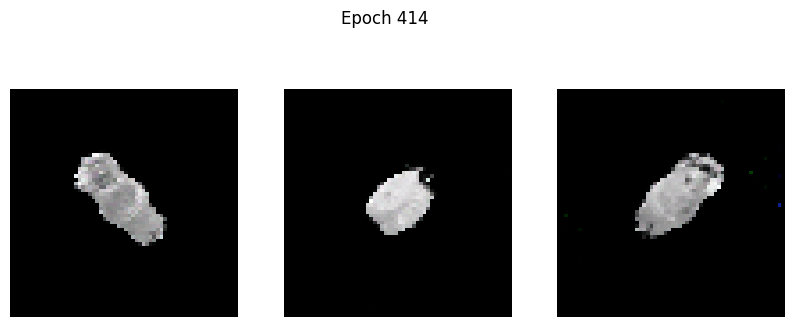

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0018 - g_loss: 5.6505
Epoch 415/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0472 - g_loss: 5.4817

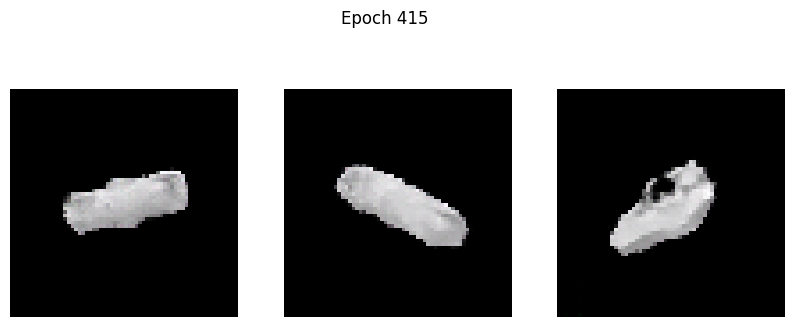

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0470 - g_loss: 5.4823
Epoch 416/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0190 - g_loss: 5.2898

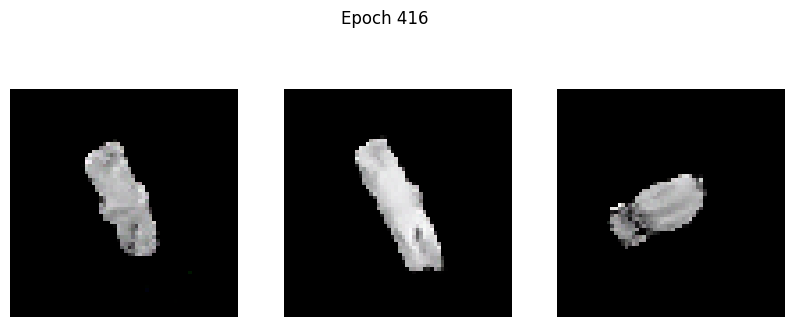

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0189 - g_loss: 5.2926
Epoch 417/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0062 - g_loss: 5.8618

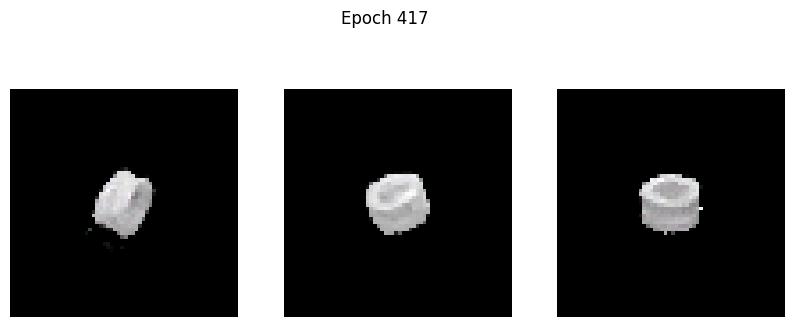

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0061 - g_loss: 5.8610
Epoch 418/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0399 - g_loss: 5.8775

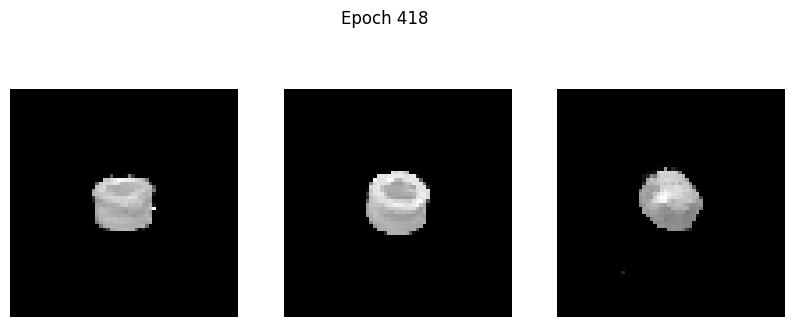

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0395 - g_loss: 5.8742
Epoch 419/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0549 - g_loss: 5.7493

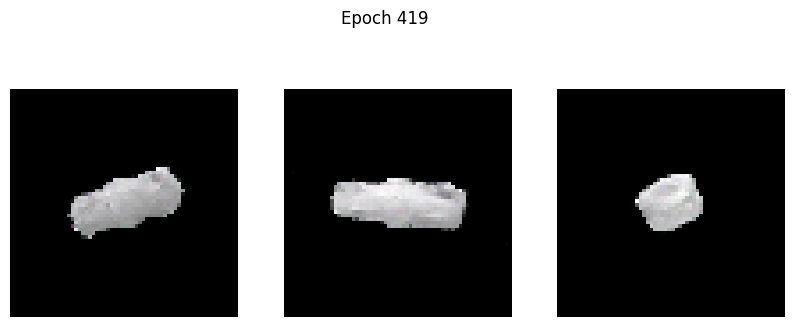

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0549 - g_loss: 5.7477
Epoch 420/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0106 - g_loss: 6.1550

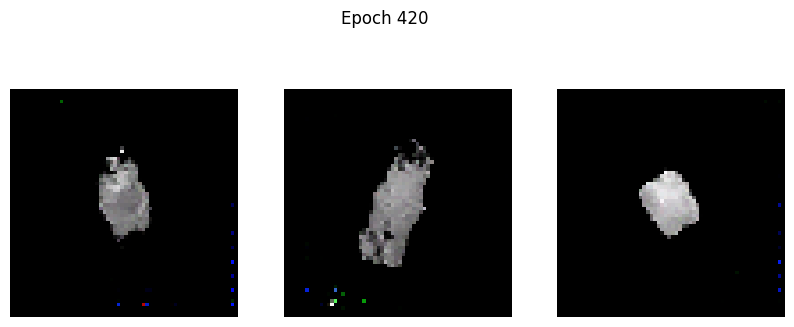

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0105 - g_loss: 6.1519
Epoch 421/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0857 - g_loss: 5.6885

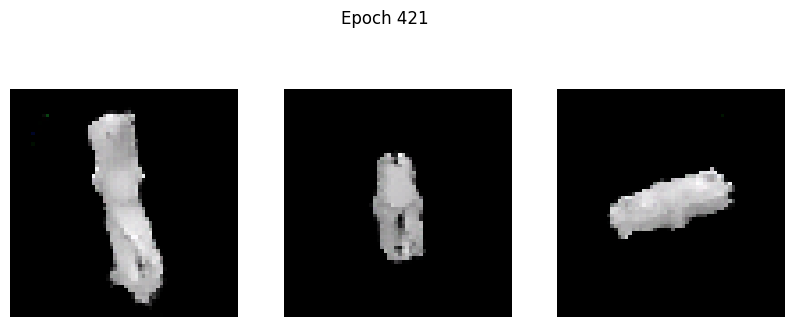

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0852 - g_loss: 5.6894
Epoch 422/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0369 - g_loss: 5.6839

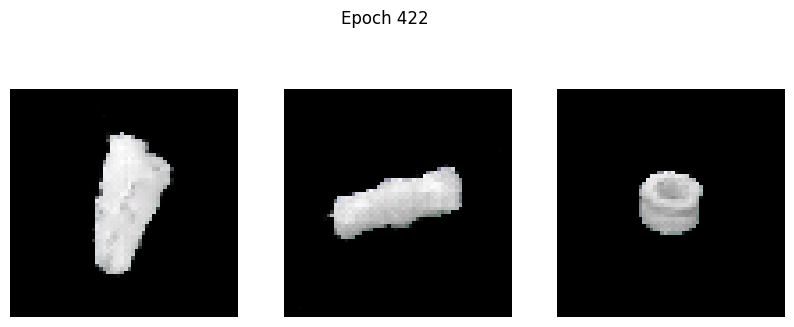

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0341 - g_loss: 5.6929
Epoch 423/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 2.2012 - g_loss: 14.1519

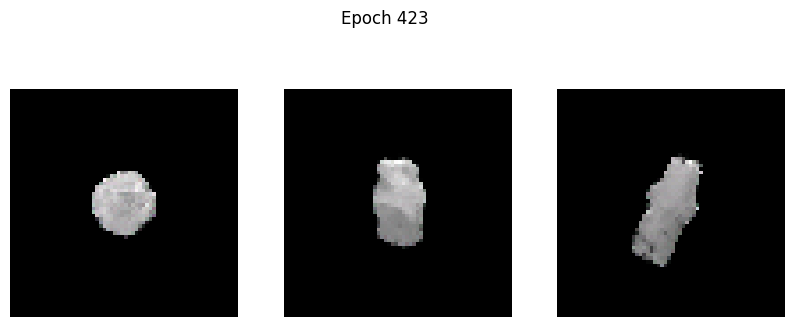

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 2.1870 - g_loss: 14.0985
Epoch 424/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0478 - g_loss: 5.1421

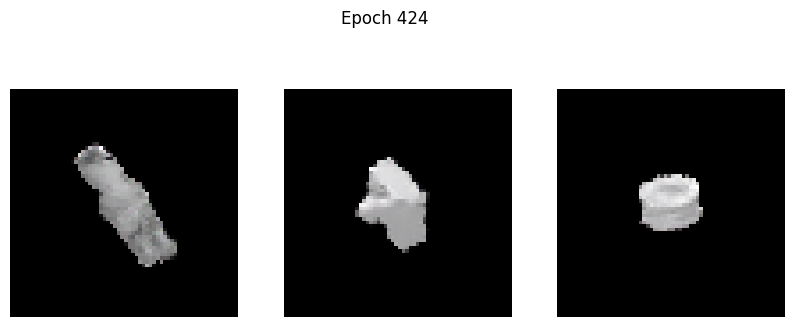

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0478 - g_loss: 5.1417
Epoch 425/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0620 - g_loss: 5.1124

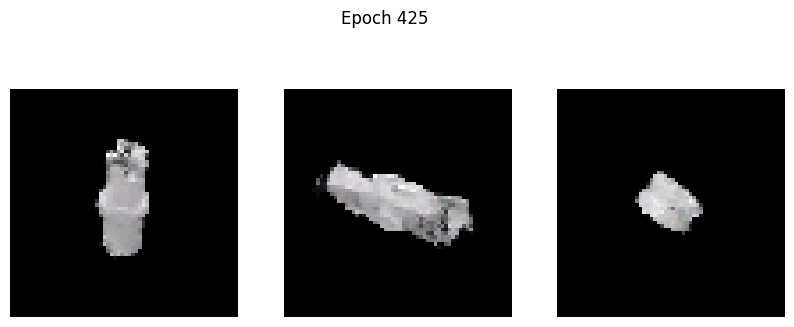

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0619 - g_loss: 5.1137
Epoch 426/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0402 - g_loss: 5.1934

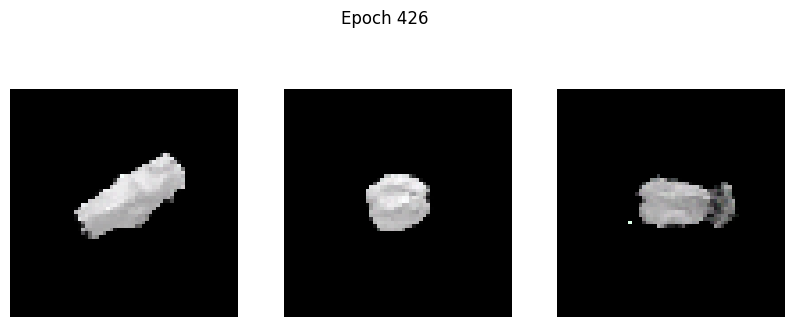

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0404 - g_loss: 5.1937
Epoch 427/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0534 - g_loss: 5.2068

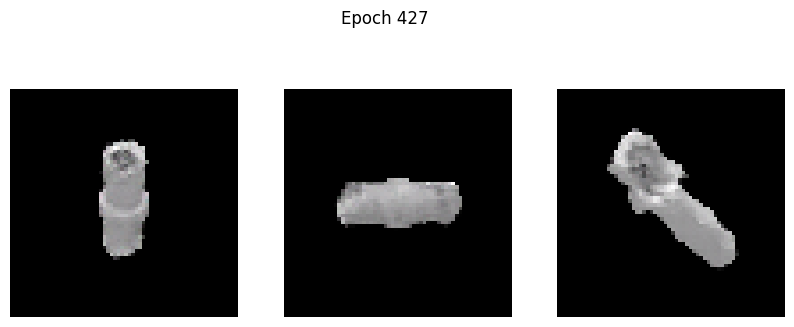

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0532 - g_loss: 5.2085
Epoch 428/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0244 - g_loss: 5.6479

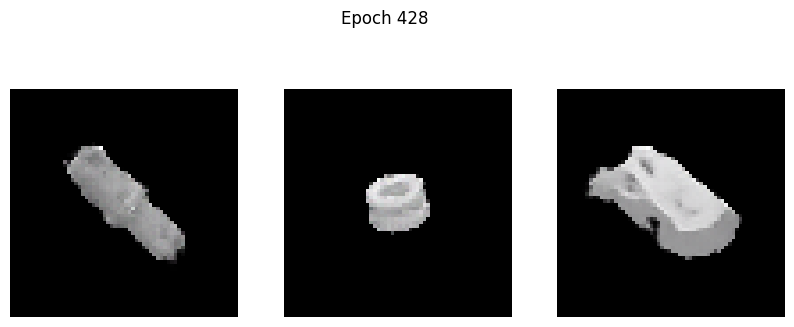

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0243 - g_loss: 5.6494
Epoch 429/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0344 - g_loss: 5.4875

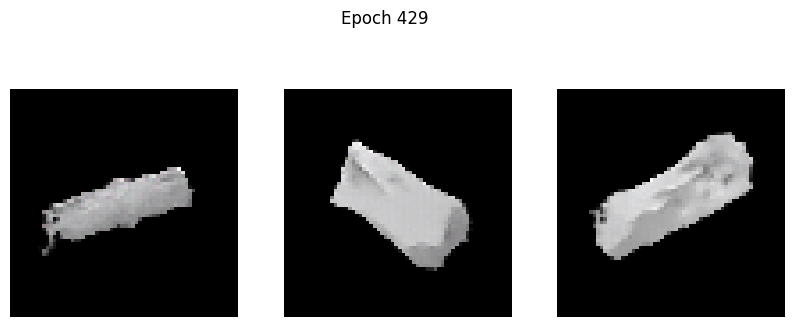

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0343 - g_loss: 5.4886
Epoch 430/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0358 - g_loss: 5.5017

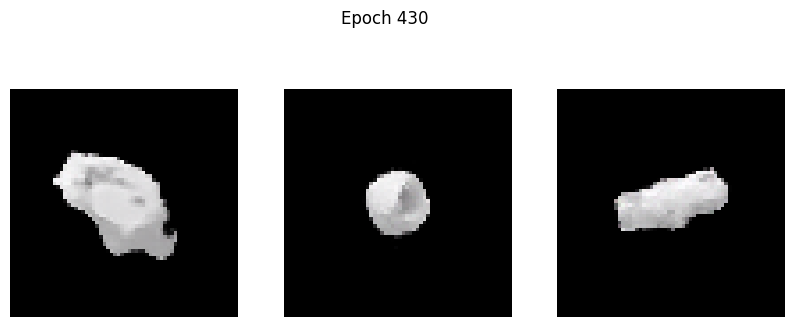

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0358 - g_loss: 5.5012
Epoch 431/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0664 - g_loss: 5.5983

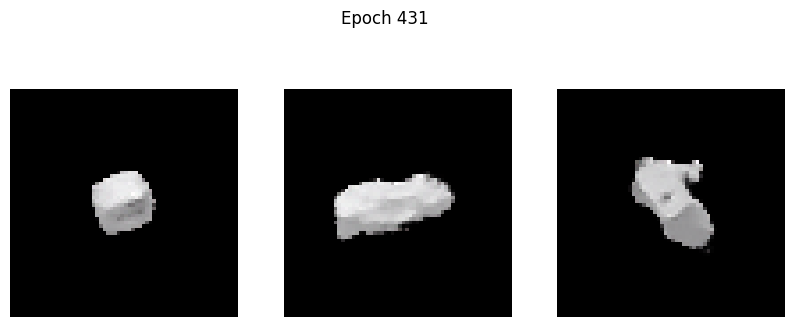

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0661 - g_loss: 5.5992
Epoch 432/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0242 - g_loss: 5.8354

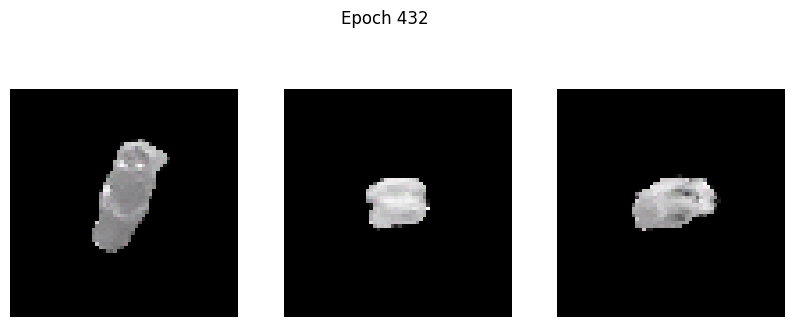

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0241 - g_loss: 5.8360
Epoch 433/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0809 - g_loss: 5.5963

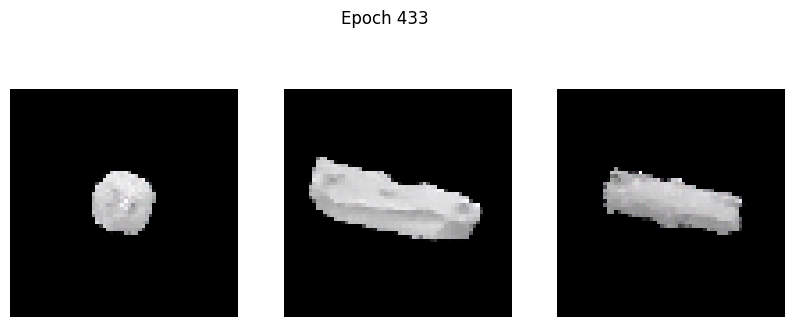

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0808 - g_loss: 5.5968
Epoch 434/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0265 - g_loss: 5.7021

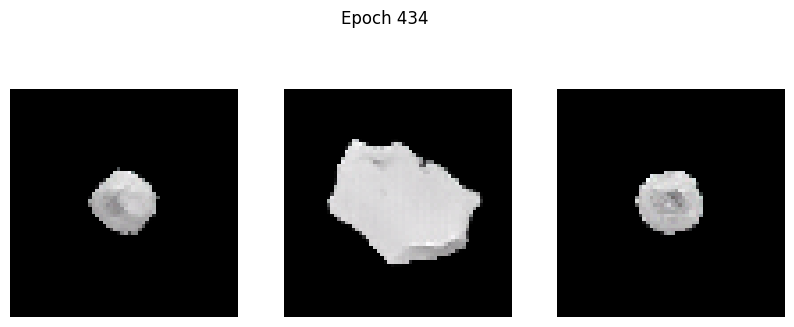

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0262 - g_loss: 5.7029
Epoch 435/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0681 - g_loss: 5.5810

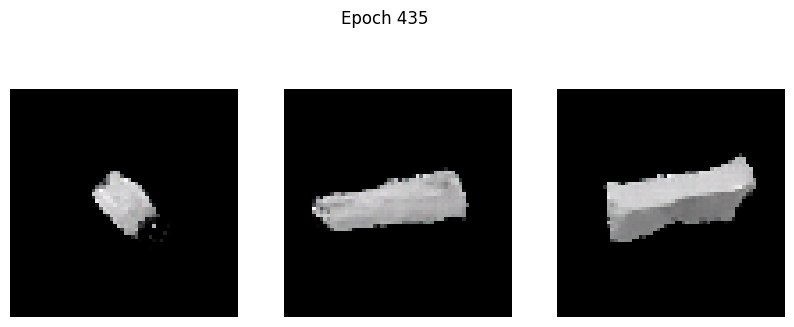

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0678 - g_loss: 5.5826
Epoch 436/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0177 - g_loss: 5.9904

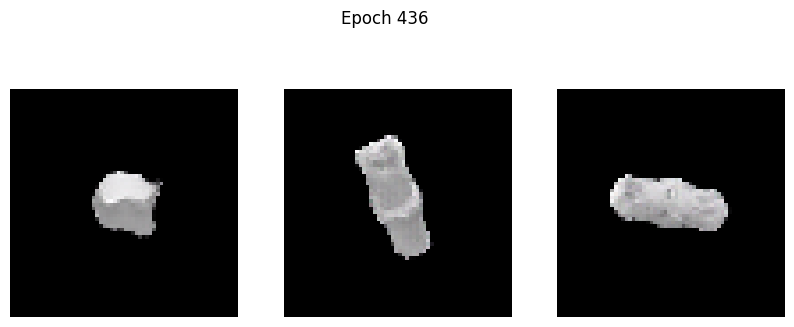

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0172 - g_loss: 5.9862
Epoch 437/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0832 - g_loss: 5.7073

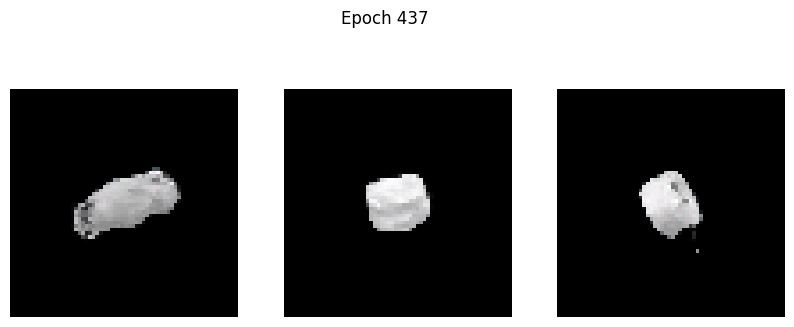

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0827 - g_loss: 5.7091
Epoch 438/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0695 - g_loss: 5.6439

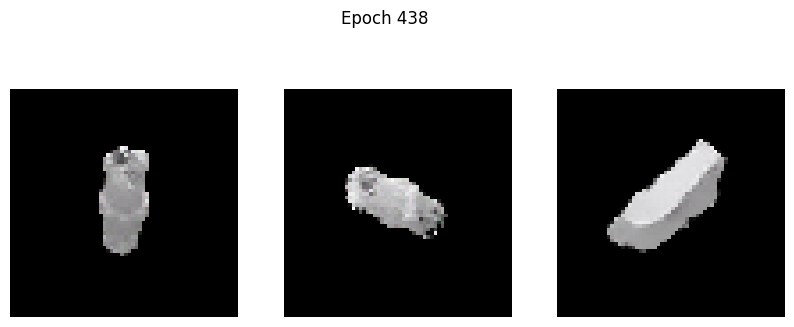

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0692 - g_loss: 5.6457
Epoch 439/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0112 - g_loss: 6.0646

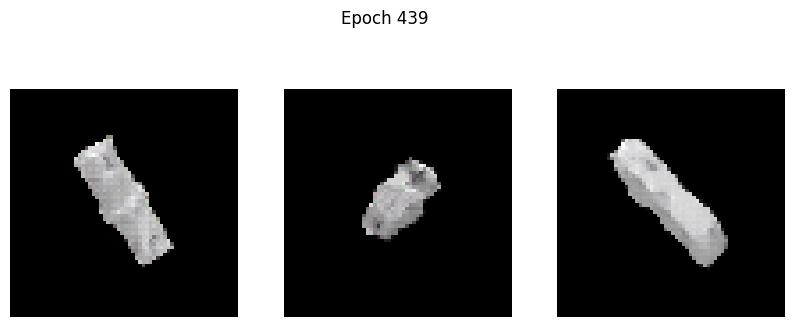

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0109 - g_loss: 6.0633
Epoch 440/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0046 - g_loss: 6.1767

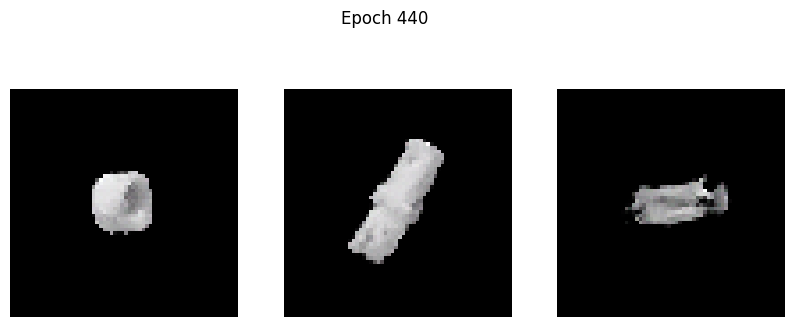

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0051 - g_loss: 6.1744
Epoch 441/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0246 - g_loss: 6.0243

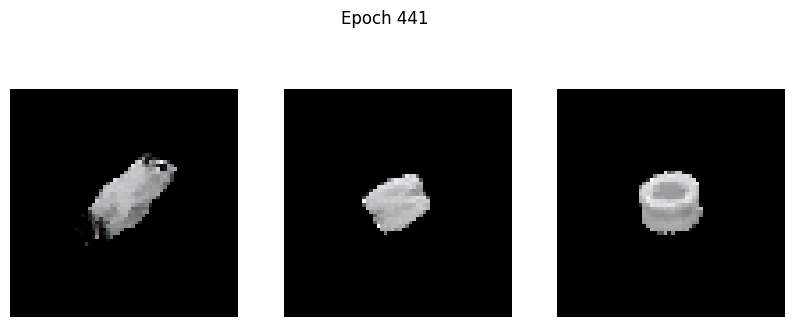

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0246 - g_loss: 6.0233
Epoch 442/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0275 - g_loss: 5.8635

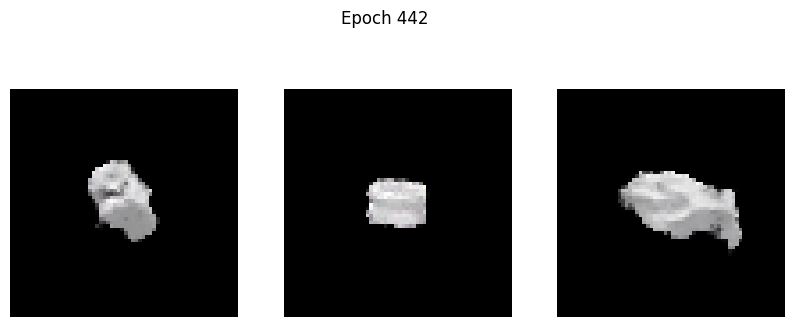

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0273 - g_loss: 5.8644
Epoch 443/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0573 - g_loss: 5.6826

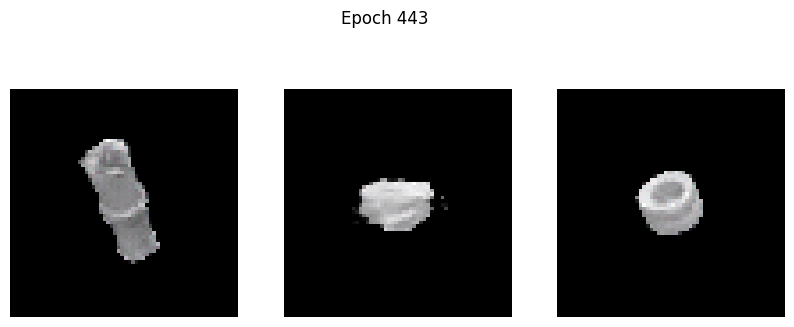

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0576 - g_loss: 5.6823
Epoch 444/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0205 - g_loss: 6.0785

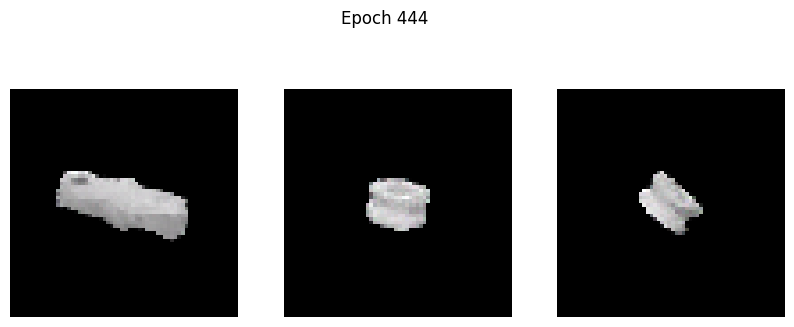

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0204 - g_loss: 6.0793
Epoch 445/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -2.5408e-04 - g_loss: 6.0262

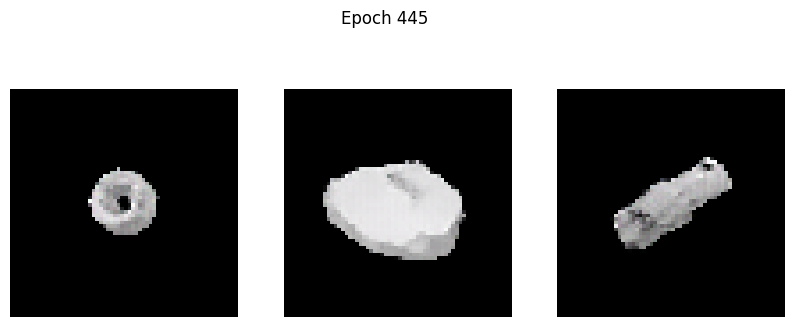

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -3.8798e-04 - g_loss: 6.0258
Epoch 446/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0471 - g_loss: 5.7353

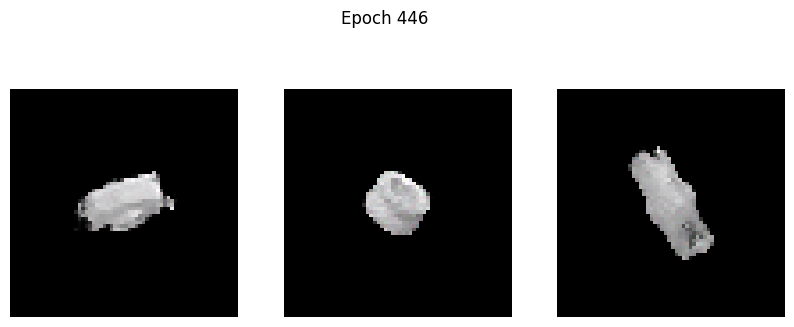

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0466 - g_loss: 5.7379
Epoch 447/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0979 - g_loss: 5.5564

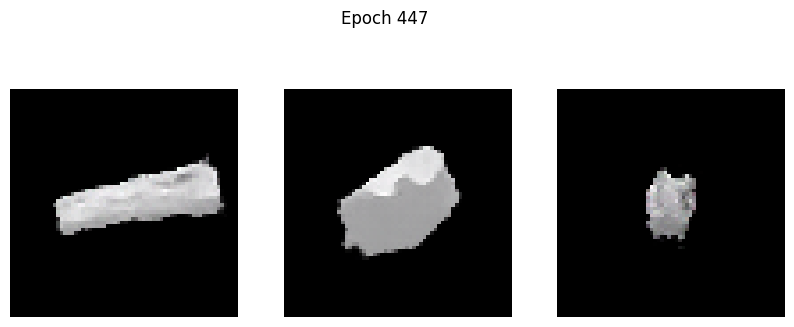

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0979 - g_loss: 5.5572
Epoch 448/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0769 - g_loss: 5.9458

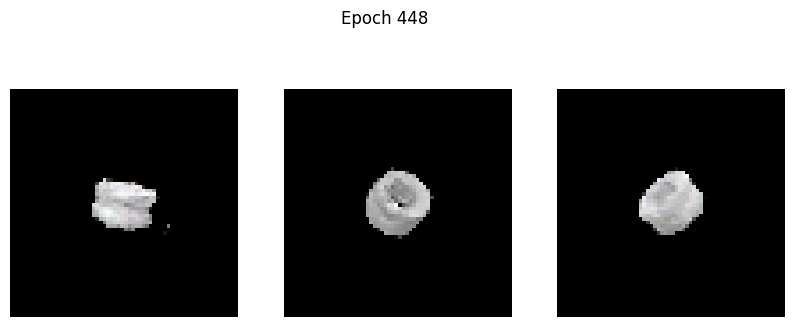

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0758 - g_loss: 5.9499
Epoch 449/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0100 - g_loss: 6.0894

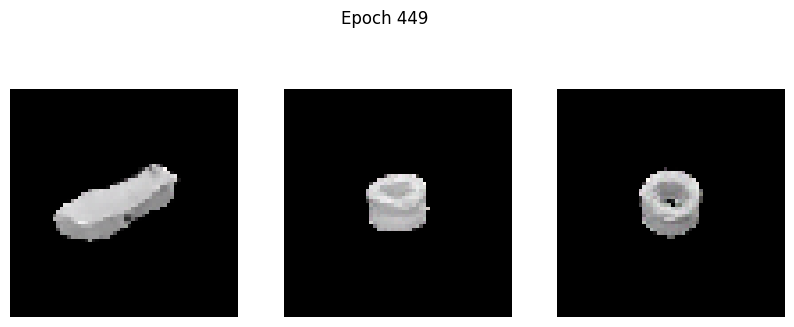

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0097 - g_loss: 6.0894
Epoch 450/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0623 - g_loss: 5.8076

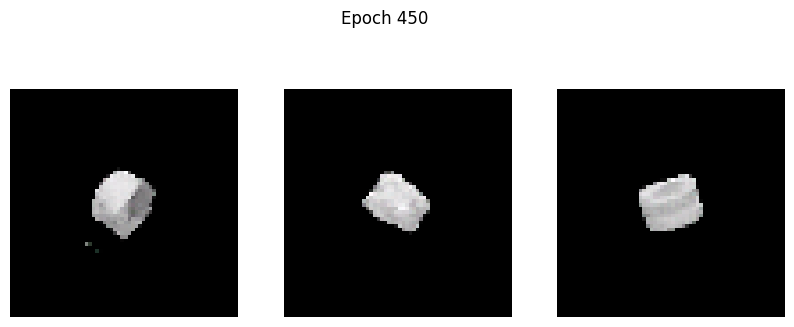

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0622 - g_loss: 5.8084
Epoch 451/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0861 - g_loss: 5.8352

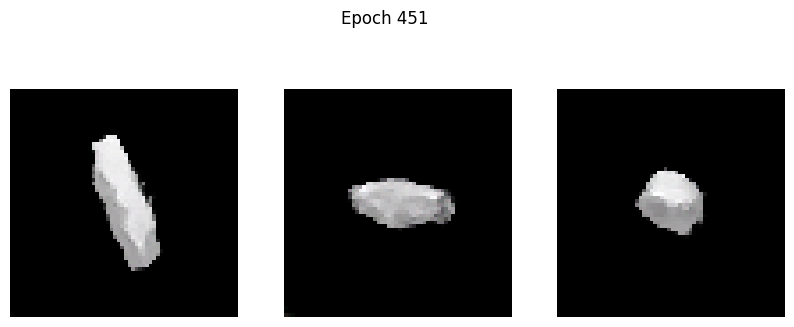

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0859 - g_loss: 5.8365
Epoch 452/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0659 - g_loss: 6.0674

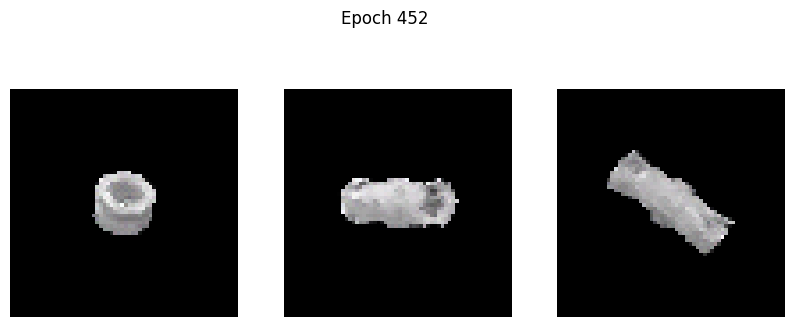

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - d_loss: -0.0651 - g_loss: 6.0696
Epoch 453/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0480 - g_loss: 5.6842

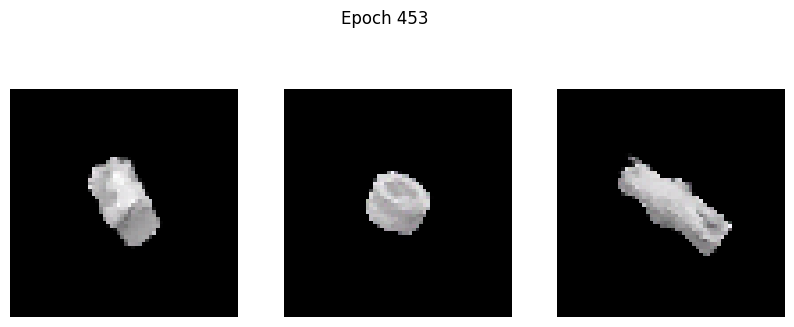

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0480 - g_loss: 5.6860
Epoch 454/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0850 - g_loss: 5.7302

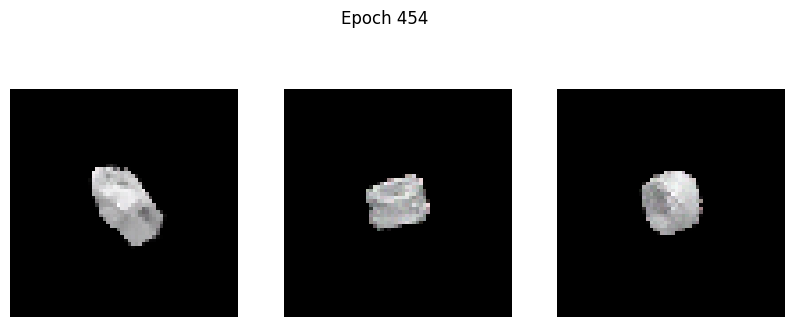

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0851 - g_loss: 5.7301
Epoch 455/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0867 - g_loss: 6.0066

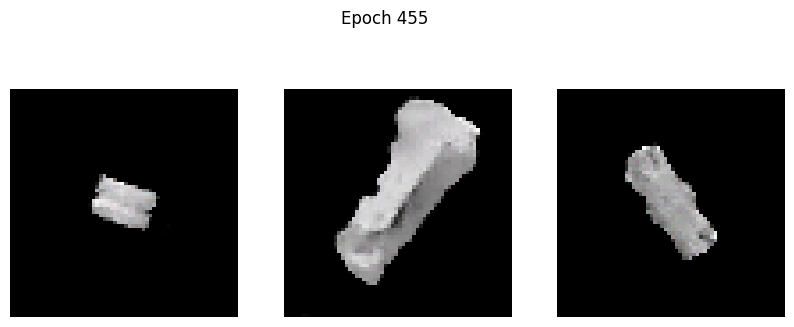

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0865 - g_loss: 6.0068
Epoch 456/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0073 - g_loss: 6.8782

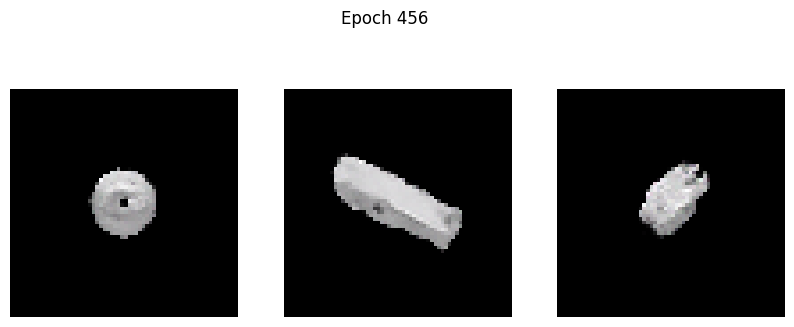

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0077 - g_loss: 6.8749
Epoch 457/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0571 - g_loss: 6.8454

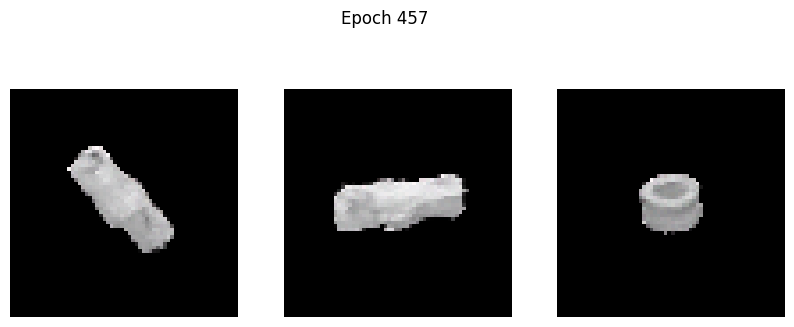

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: 0.0566 - g_loss: 6.8409
Epoch 458/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0082 - g_loss: 6.1026

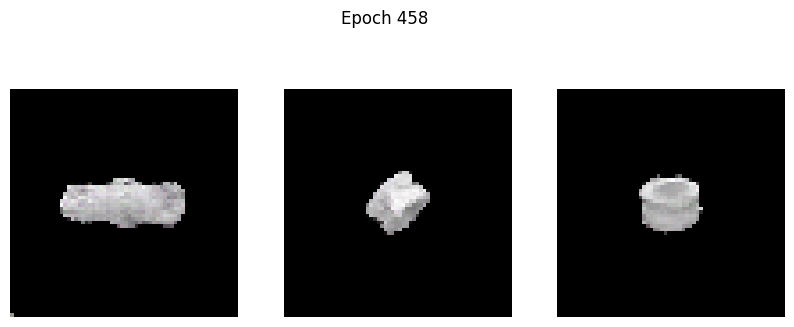

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0084 - g_loss: 6.1029
Epoch 459/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0793 - g_loss: 6.3399

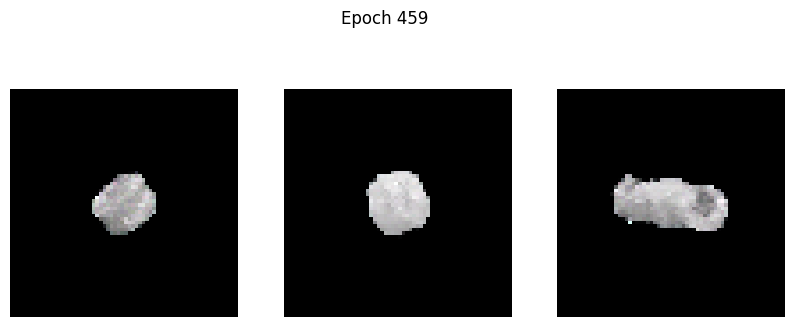

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0792 - g_loss: 6.3366
Epoch 460/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1059 - g_loss: 5.8107

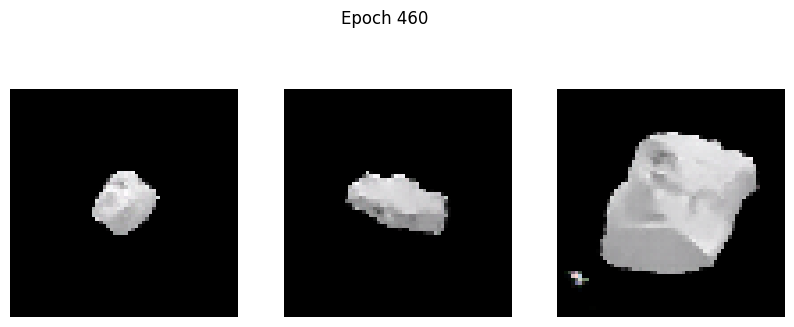

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1056 - g_loss: 5.8134
Epoch 461/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0443 - g_loss: 6.3882

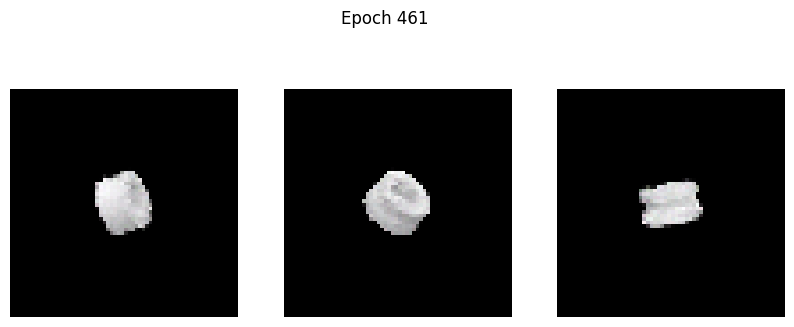

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0445 - g_loss: 6.3870
Epoch 462/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1145 - g_loss: 5.8777

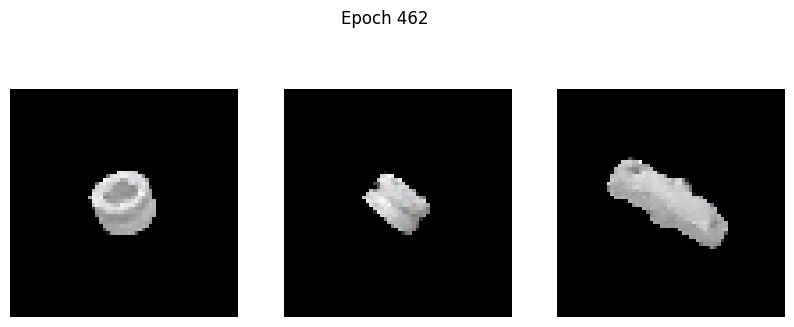

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1142 - g_loss: 5.8792
Epoch 463/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0326 - g_loss: 6.5461

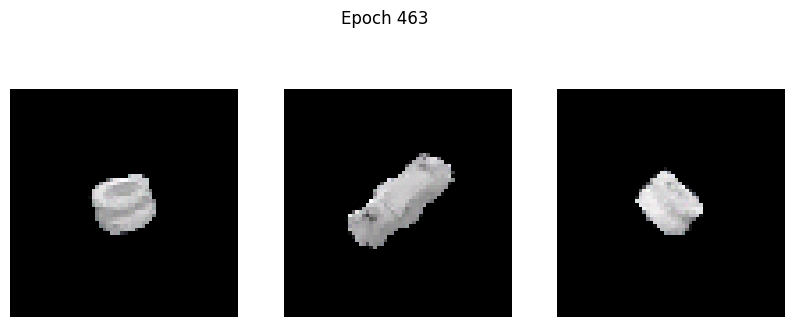

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0323 - g_loss: 6.5467
Epoch 464/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0784 - g_loss: 6.1245

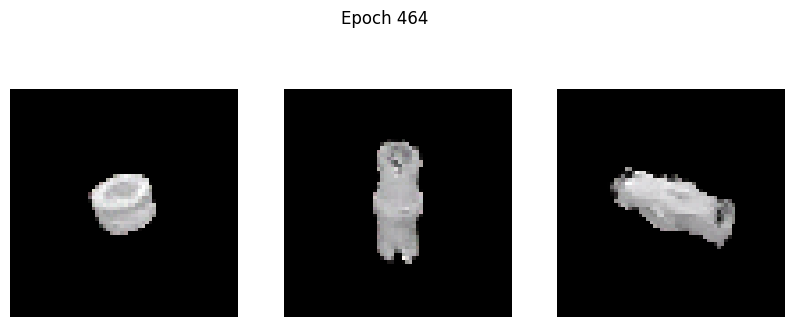

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0783 - g_loss: 6.1241
Epoch 465/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1003 - g_loss: 6.0545

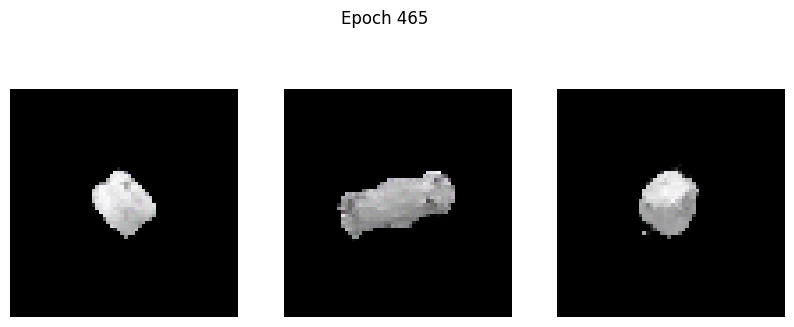

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1002 - g_loss: 6.0564
Epoch 466/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0100 - g_loss: 6.9522

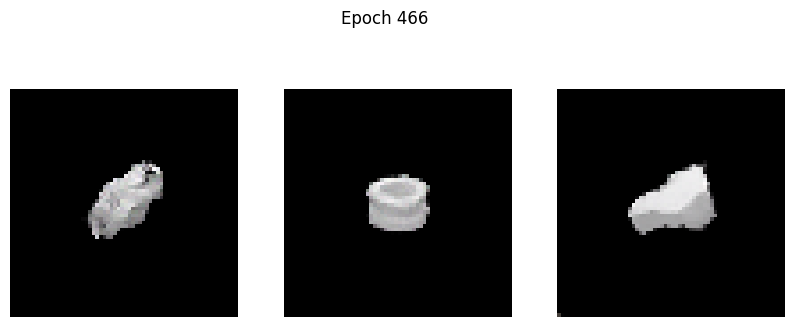

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0103 - g_loss: 6.9480
Epoch 467/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1258 - g_loss: 5.8182

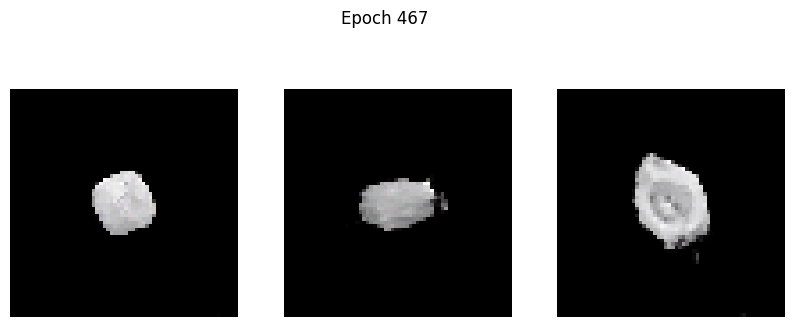

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1255 - g_loss: 5.8211
Epoch 468/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.0016 - g_loss: 6.9036

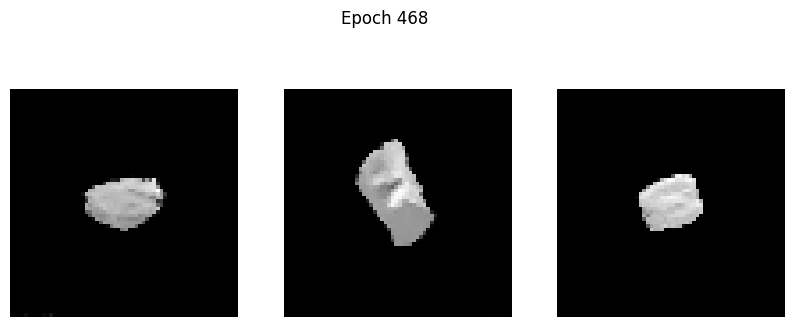

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 9.9392e-04 - g_loss: 6.8998
Epoch 469/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0272 - g_loss: 6.7693

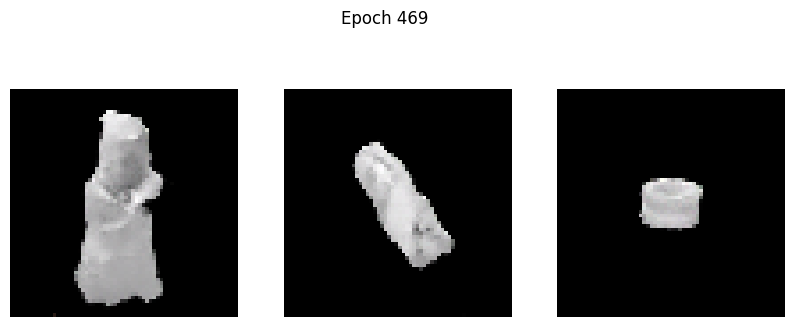

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0267 - g_loss: 6.7693
Epoch 470/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0937 - g_loss: 6.5113

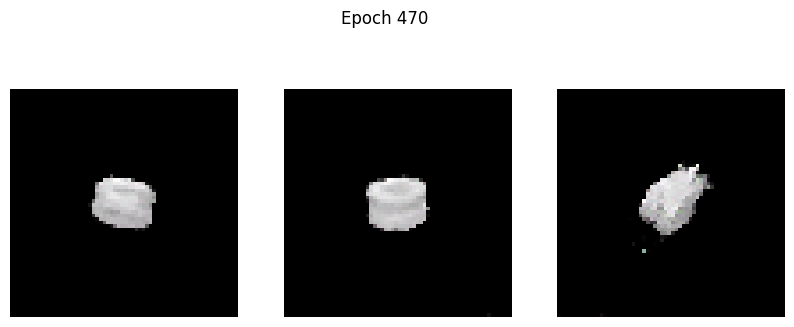

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0935 - g_loss: 6.5101
Epoch 471/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1465 - g_loss: 5.9615

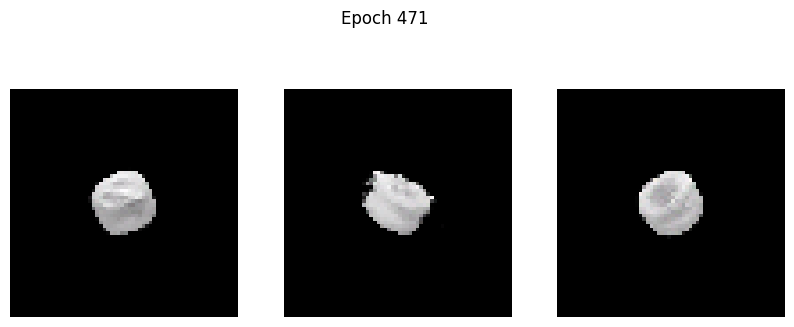

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1463 - g_loss: 5.9626
Epoch 472/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0851 - g_loss: 6.3601

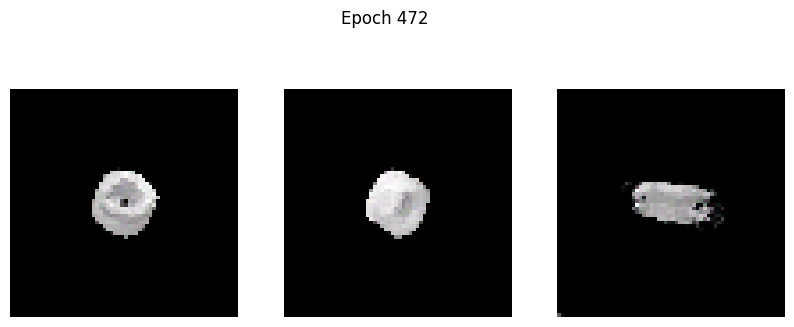

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0850 - g_loss: 6.3618
Epoch 473/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1178 - g_loss: 6.1262

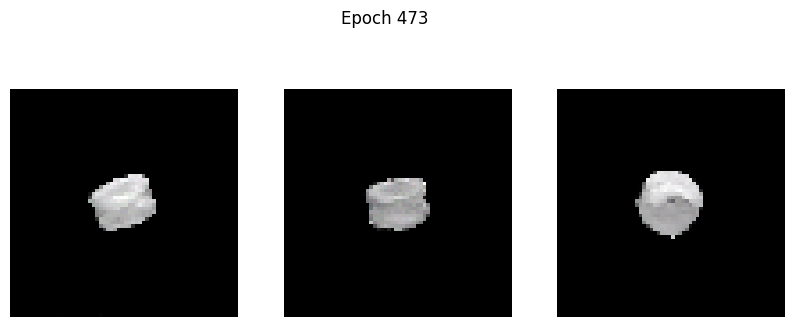

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1174 - g_loss: 6.1295
Epoch 474/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1100 - g_loss: 6.6274

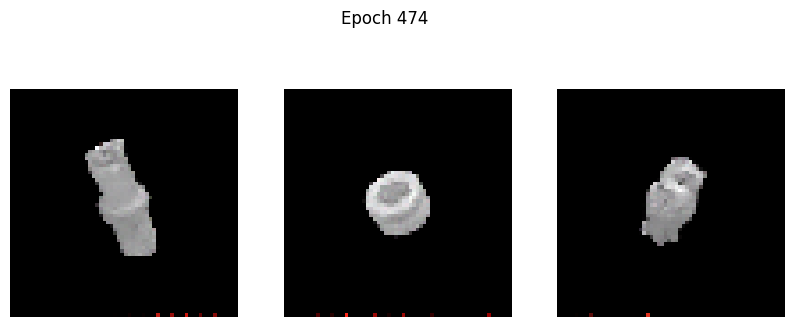

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1098 - g_loss: 6.6266
Epoch 475/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0486 - g_loss: 6.9495

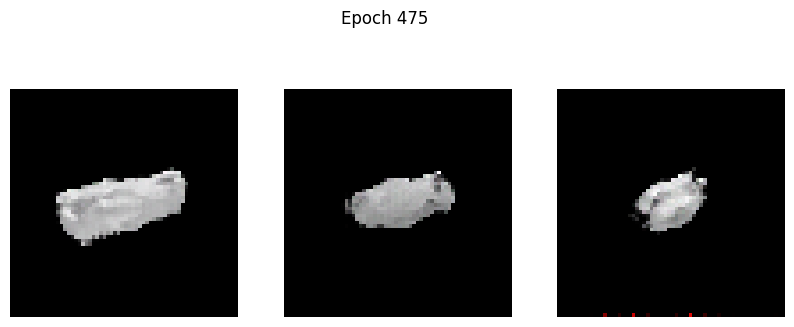

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0483 - g_loss: 6.9506
Epoch 476/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0947 - g_loss: 6.6559

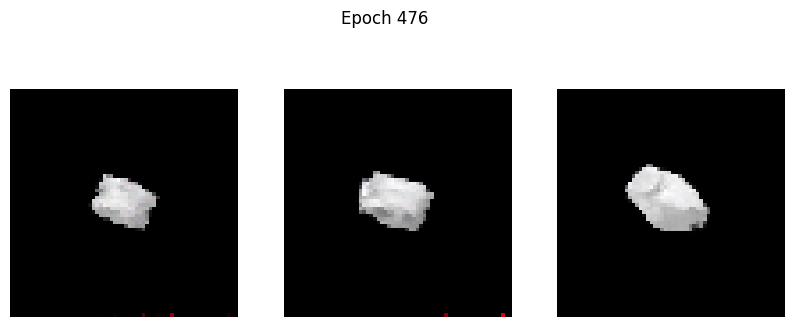

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0946 - g_loss: 6.6544
Epoch 477/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0455 - g_loss: 7.2875

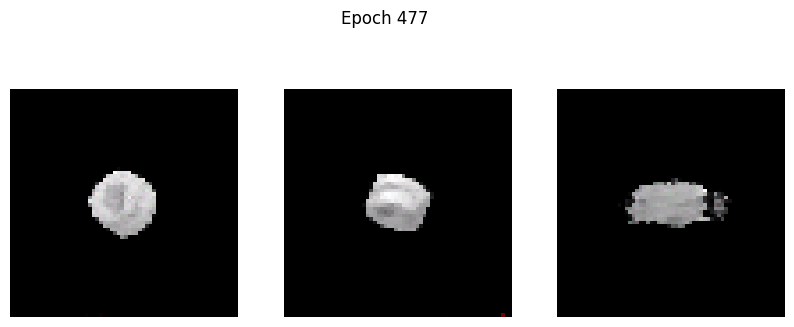

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0460 - g_loss: 7.2830
Epoch 478/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0603 - g_loss: 7.3265

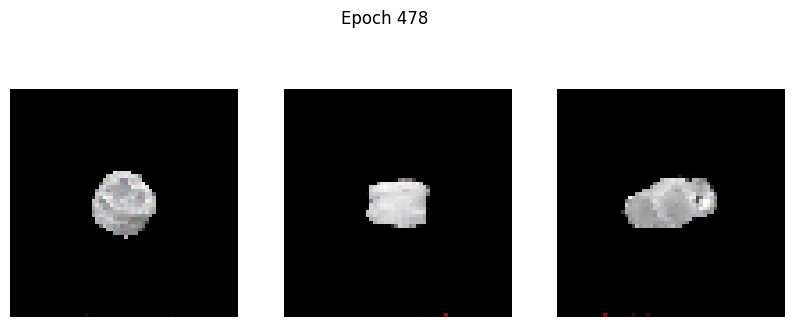

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0606 - g_loss: 7.3223
Epoch 479/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0644 - g_loss: 6.4701

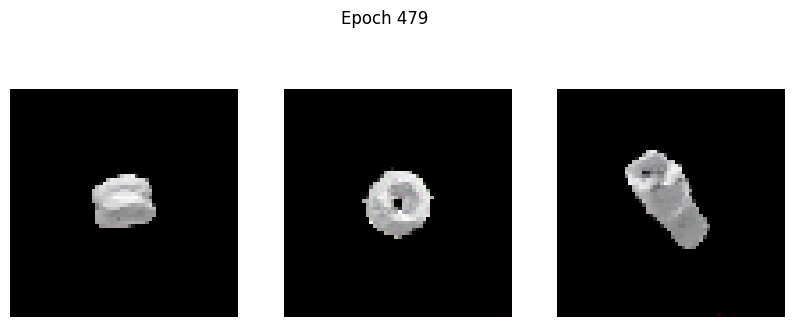

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0647 - g_loss: 6.4701
Epoch 480/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0622 - g_loss: 6.8083

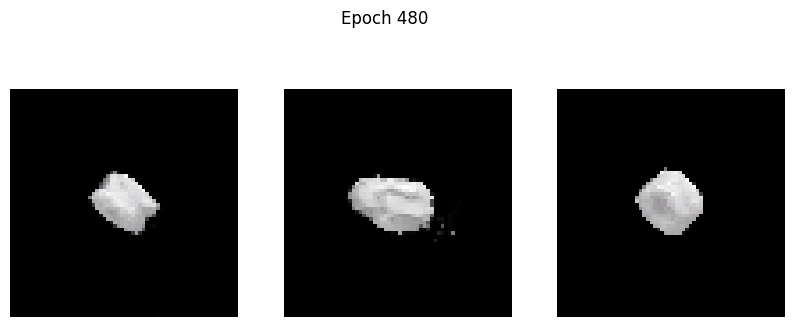

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0622 - g_loss: 6.8085
Epoch 481/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1290 - g_loss: 6.2105

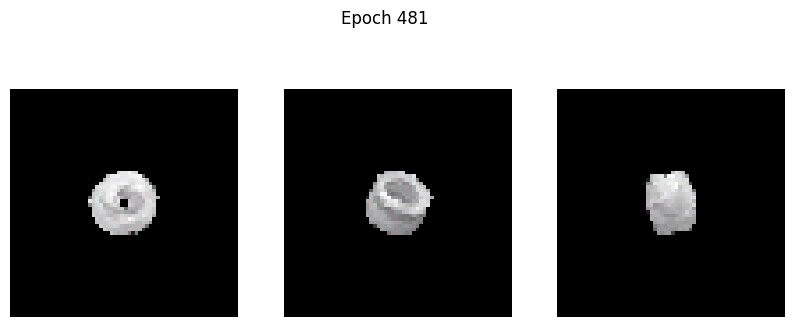

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1290 - g_loss: 6.2098
Epoch 482/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0581 - g_loss: 8.1543

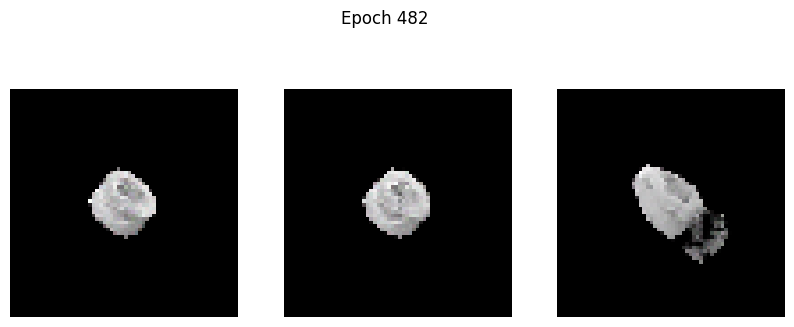

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0571 - g_loss: 8.1436
Epoch 483/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.1296 - g_loss: 6.6062

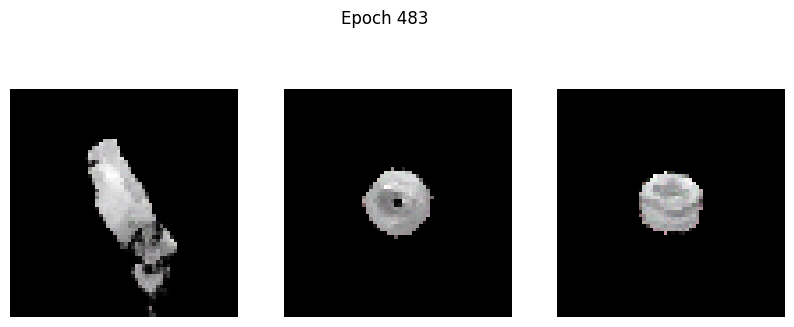

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.1292 - g_loss: 6.6078
Epoch 484/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0883 - g_loss: 6.6910

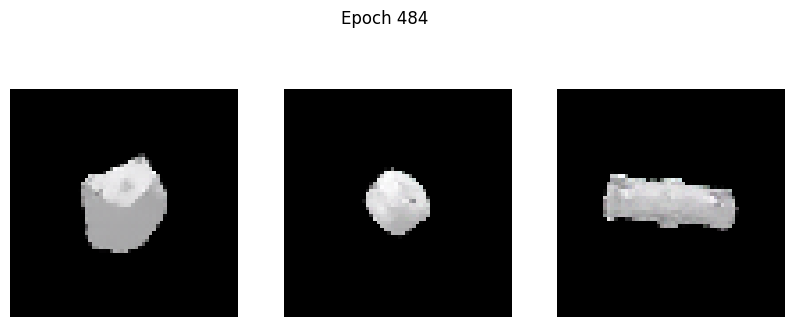

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0885 - g_loss: 6.6910
Epoch 485/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0525 - g_loss: 6.7982

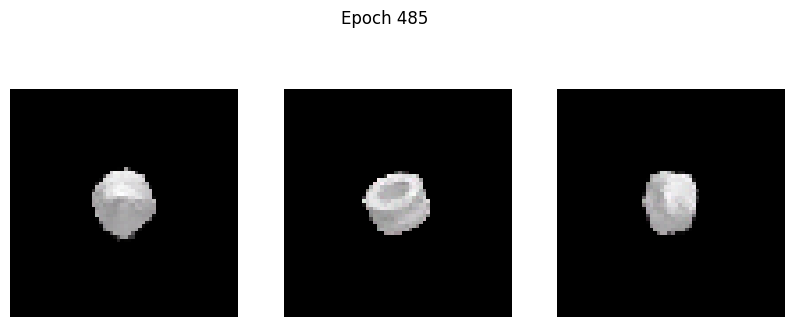

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0525 - g_loss: 6.7979
Epoch 486/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1124 - g_loss: 7.1440

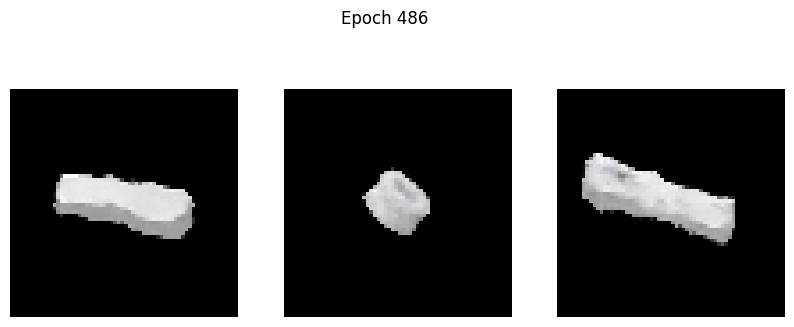

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1118 - g_loss: 7.1452
Epoch 487/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1406 - g_loss: 6.3614

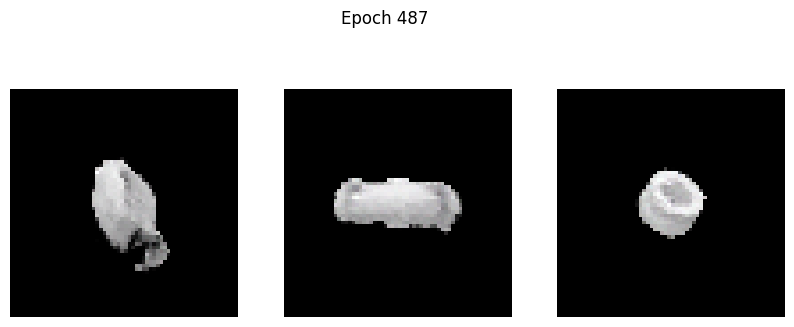

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.1403 - g_loss: 6.3664
Epoch 488/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0690 - g_loss: 7.4127

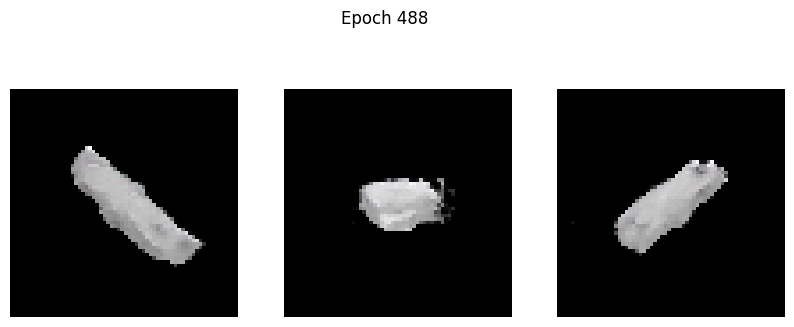

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0698 - g_loss: 7.4040
Epoch 489/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.1600 - g_loss: 6.4309

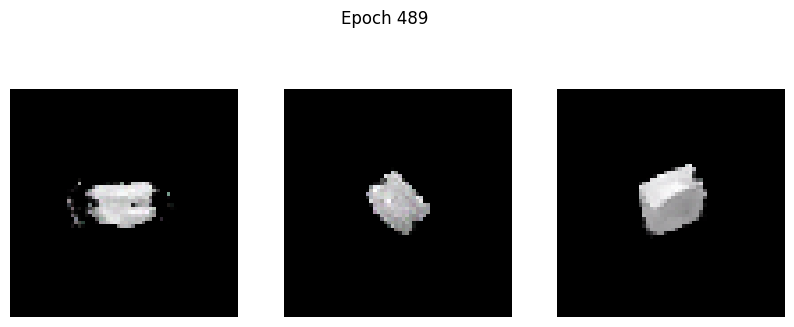

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.1601 - g_loss: 6.4321
Epoch 490/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0574 - g_loss: 7.4304

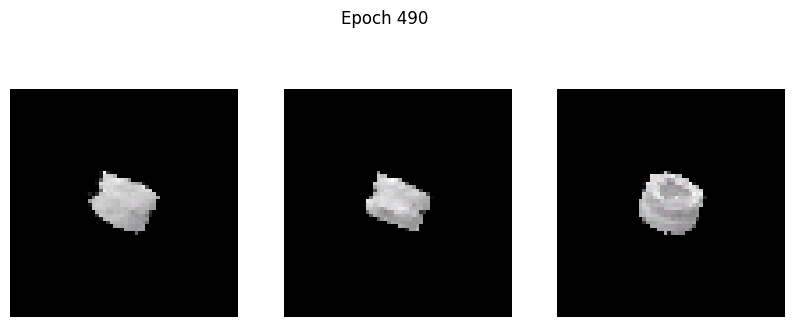

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0575 - g_loss: 7.4284
Epoch 491/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.0284 - g_loss: 7.3454

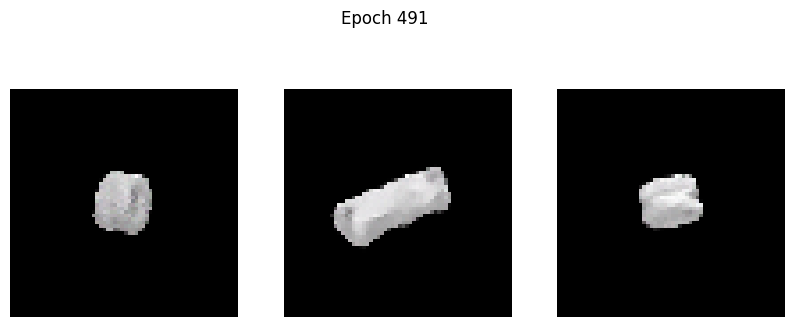

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.0293 - g_loss: 7.3412
Epoch 492/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0351 - g_loss: 7.4828

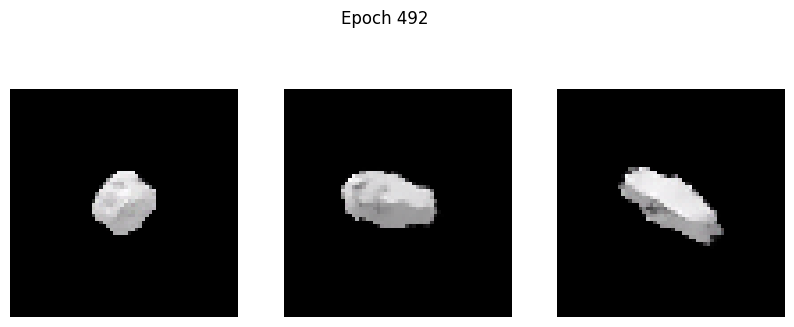

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0353 - g_loss: 7.4840
Epoch 493/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.2159 - g_loss: 6.2598

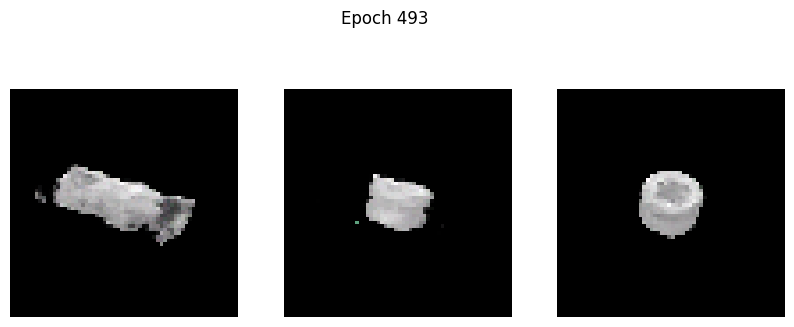

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.2155 - g_loss: 6.2620
Epoch 494/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0940 - g_loss: 6.9506

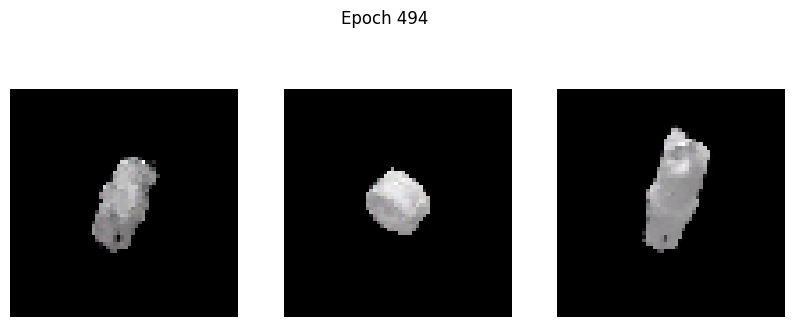

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.0941 - g_loss: 6.9498
Epoch 495/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.0393 - g_loss: 7.5098

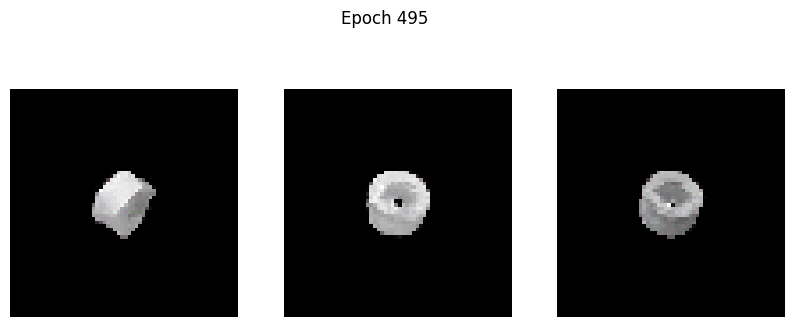

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - d_loss: -0.0395 - g_loss: 7.5122
Epoch 496/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 0.0327 - g_loss: 7.9835

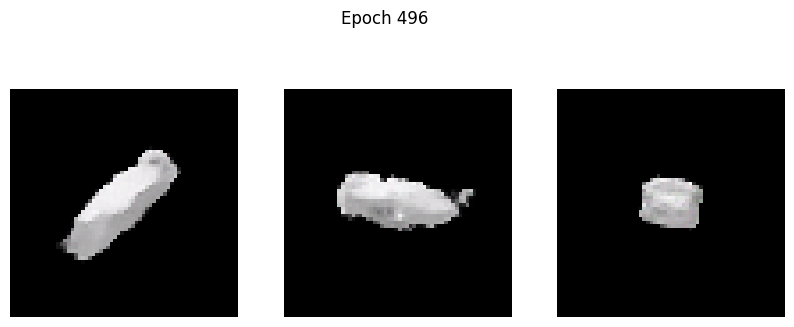

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: 0.0318 - g_loss: 7.9802
Epoch 497/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: -0.1479 - g_loss: 7.4108

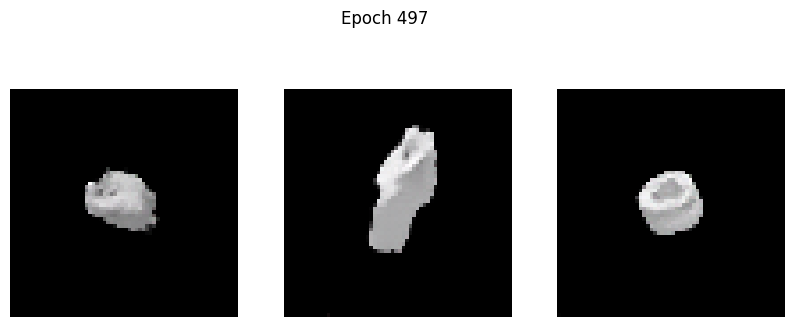

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - d_loss: -0.1479 - g_loss: 7.4067
Epoch 498/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1935 - g_loss: 6.8998

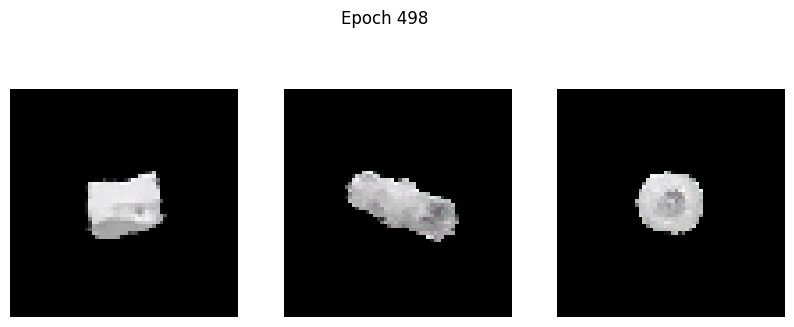

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1934 - g_loss: 6.9000
Epoch 499/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1492 - g_loss: 6.5987

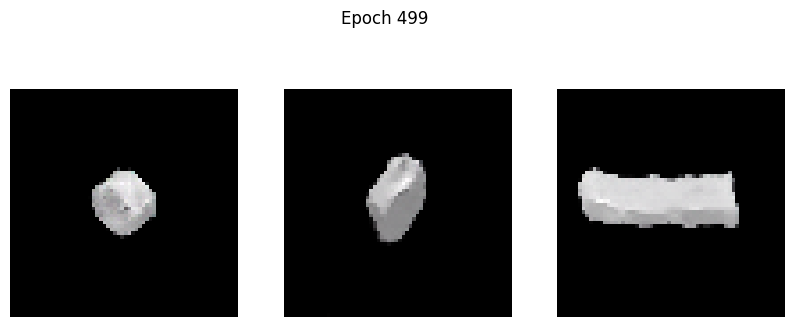

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1496 - g_loss: 6.6036
Epoch 500/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: -0.1752 - g_loss: 6.8533

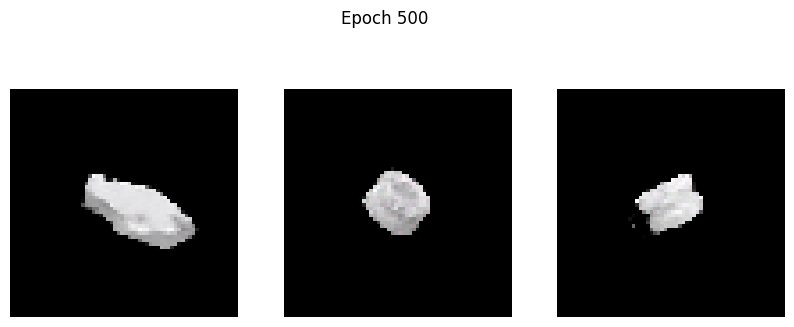

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - d_loss: -0.1755 - g_loss: 6.8534


In [9]:
# Hyperparameters
EPOCHS = 500  # Tambahkan jumlah epoch untuk hasil lebih baik (misal: 100-200)
lr_generator = 0.0002
lr_discriminator = 0.0002

# Inisialisasi DCGAN
dcgan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)

# Compile
dcgan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=lr_discriminator, beta_1=0.5),
    g_optimizer=keras.optimizers.Adam(learning_rate=lr_generator, beta_1=0.5),
    loss_fn=keras.losses.BinaryCrossentropy(from_logits=True),
)

# Jalankan Training
print("Mulai Training...")
dcgan.fit(
    train_dataset,
    epochs=EPOCHS,
    callbacks=[GANMonitor(num_img=3, latent_dim=latent_dim)]
)

In [10]:
generator.save('generator model.keras')
print("Generator model saved successfully as 'generator model.keras'")

Generator model saved successfully as 'generator model.keras'


In [11]:
import keras
import numpy as np
from PIL import Image
import os
# ... (impor lainnya)

# --- Konfigurasi ---
MODEL_PATH = '/content/generator model.keras' # Nama file baru tanpa spasi dan tanda kurung
NUM_IMAGES = 5

def generate_and_save_images():
    # 1. Muat model generator
    try:
        # Pemuatan model menggunakan path yang dikonstruksi
        generator = keras.saving.load_model(MODEL_PATH)
    except Exception as e:
        print(f"Error loading model '{MODEL_PATH}': {e}")
        return

    # Deteksi dimensi laten
    latent_dim = generator.input_shape[1]

    # 2. Hasilkan 5 vektor laten acak (noise)
    # Menggunakan distribusi normal standar (umum untuk GAN)
    noise = np.random.normal(size=(NUM_IMAGES, latent_dim)).astype(np.float32)

    # 3. Hasilkan gambar
    generated_data = generator.predict(noise, verbose=0)

    # 4. Proses dan simpan gambar

    # Rescale dari rentang [-1, 1] (asumsi umum GAN) ke [0, 255]
    if generated_data.min() < 0:
      generated_images_scaled = 0.5 * generated_data + 0.5
    else:
      generated_images_scaled = generated_data

    generated_images_scaled = (generated_images_scaled * 255).astype(np.uint8)

    # Deteksi dimensi output (H, W, C)
    output_shape = generator.output_shape
    H, W, C = output_shape[1:]

    for i in range(NUM_IMAGES):
        img_array = generated_images_scaled[i]

        # Atur mode PIL berdasarkan jumlah channel
        # Parameter mode tidak lagi diperlukan karena Image.fromarray dapat menginfer mode dengan benar
        # dari bentuk dan tipe data array NumPy.
        if C == 1:
            img_array = img_array.squeeze(axis=-1) # Hapus dimensi channel jika hanya satu
            img = Image.fromarray(img_array) # Pillow akan infer 'L' (grayscale)
        elif C == 3:
            img = Image.fromarray(img_array) # Pillow akan infer 'RGB' (warna)
        else:
            print(f"Peringatan: Gambar {i+1} memiliki {C} channel. Diskip.")
            continue

        filename = f'generated_image_{i+1}.png'
        img.save(filename)
        print(f"Tersimpan: {filename}")

# Jalankan fungsi
generate_and_save_images()

Tersimpan: generated_image_1.png
Tersimpan: generated_image_2.png
Tersimpan: generated_image_3.png
Tersimpan: generated_image_4.png
Tersimpan: generated_image_5.png


Menampilkan 5 gambar baru (64x64x3)...


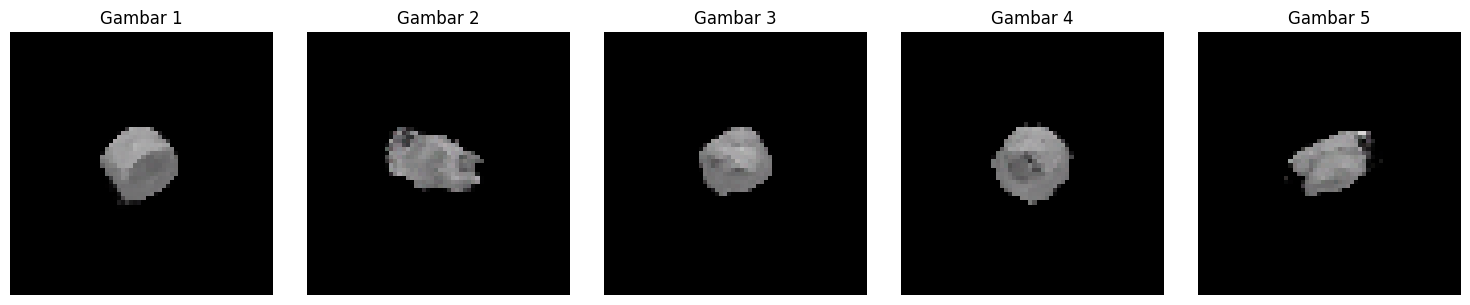

In [12]:
import keras
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt # Pustaka utama untuk plotting
import os

# --- Konfigurasi ---
MODEL_PATH = '/content/generator model.keras'
NUM_IMAGES = 5
ROWS = 1 # Jumlah baris di grid output
COLS = 5 # Jumlah kolom di grid output (karena ada 5 gambar)

def generate_and_display_images():
    # 1. Muat model generator (Langkah yang sama)
    try:
        generator = keras.saving.load_model(MODEL_PATH)
    except Exception as e:
        print(f"Error: Gagal memuat model Keras '{MODEL_PATH}'. Error: {e}")
        return

    latent_dim = generator.input_shape[1]

    # 2. Hasilkan vektor laten acak dan gambar (Langkah yang sama)
    noise = np.random.normal(size=(NUM_IMAGES, latent_dim)).astype(np.float32)
    generated_data = generator.predict(noise, verbose=0)

    # Rescale dari rentang [-1, 1] ke [0, 255] (Langkah yang sama)
    if generated_data.min() < 0:
      generated_images_scaled = 0.5 * generated_data + 0.5
    else:
      generated_images_scaled = generated_data

    # TIDAK PERLU diubah ke np.uint8 jika akan diplot dengan Matplotlib
    # Biarkan dalam rentang [0, 1] atau float

    # Deteksi dimensi output (H, W, C)
    output_shape = generator.output_shape
    H, W, C = output_shape[1:]

    # 3. Tampilkan Gambar menggunakan Matplotlib
    print(f"Menampilkan {NUM_IMAGES} gambar baru ({H}x{W}x{C})...")

    # Buat figure dan subplot (grid)
    plt.figure(figsize=(15, 3)) # Atur ukuran figure agar gambar terlihat jelas (lebar 15, tinggi 3)

    for i in range(NUM_IMAGES):
        # Tambahkan subplot ke grid (1 baris, 5 kolom, posisi ke-i+1)
        plt.subplot(ROWS, COLS, i + 1)

        img_array = generated_images_scaled[i]

        # Jika Grayscale (C=1), hapus dimensi channel agar Matplotlib menampilkannya dengan benar
        if C == 1:
            img_array = img_array.squeeze(axis=-1)
            # Gunakan colormap 'gray' untuk tampilan grayscale
            plt.imshow(img_array, cmap='gray')
        else: # Untuk RGB (C=3)
            plt.imshow(img_array)

        # Sembunyikan sumbu X dan Y agar gambar terlihat bersih
        plt.axis('off')
        plt.title(f"Gambar {i+1}")

    plt.tight_layout() # Sesuaikan layout
    plt.show() # Tampilkan semua plot

# Jalankan fungsi baru
generate_and_display_images()